# Phase 1

### automated parsing through PV systems csv to find our ideal site candidates

In [ ]:
# ============================================================
# Identify PVDAQ systems with day-level file structure
# ============================================================

# Installs
!pip -q install boto3 botocore pandas

import pandas as pd
import boto3
from botocore import UNSIGNED
from botocore.client import Config

# ============
# Settings
# ============

SYSTEMS_FILE = "systems_20250729.csv"
BUCKET_NAME = "oedi-data-lake"
PVDAQ_ROOT = "pvdaq/csv/pvdata"

MAX_SITES = None  # proces all sites but set to a small number for testing endpoint

SCAN_RESULTS_FILE = "pvdaq_day_path_scan_results.csv"
FILTERED_SYSTEMS_FILE = "systems_with_day_paths.csv"

MAX_KEYS_PER_SITE = 20000  # prevents huge scans

# =======================
# Anonymous S3 client
# =======================

s3 = boto3.client(
    "s3",
    config=Config(signature_version=UNSIGNED)
)

# ========================
# Load systems metadata
# =========================

systems_df = pd.read_csv(SYSTEMS_FILE)

# ensure consistent string formatting
systems_df["system_id"] = systems_df["system_id"].astype(str).str.strip()

if MAX_SITES is not None:
    systems_df = systems_df.head(MAX_SITES).copy()

# reminder to check in case forgot to set max sites
print("Number of sites to scan:", len(systems_df))

# =====================================
# Helper to list S3 keys under prefix
# ======================================

def list_keys_under_prefix(bucket, prefix, max_keys=20000):
    """
    Purpose:
        Retrieve object keys under a given S3 prefix.

    Inputs:
        bucket: S3 bucket name
        prefix: folder-like path to scan
        max_keys: safety cap to limit scan size

    Outputs:
        List of object key strings

    Overview:
        Uses S3 pagination to collect keys until exhausted or capped.
        Returns empty list if access fails.
    """
    paginator = s3.get_paginator("list_objects_v2")
    keys = []

    try:
        for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
            for obj in page.get("Contents", []):
                keys.append(obj["Key"])

                # stop early to avoid massive scans
                if len(keys) >= max_keys:
                    return keys
    except Exception as e:
        print(f"Error accessing prefix {prefix}: {e}")
        return []

    return keys

# ========================================
# Helper to detect day-level structure
# ========================================

def has_year_month_day_path(keys, system_id):
    """
    Purpose:
        Check if system has files stored by year/month/day, because those are the
        sources that have hourly data and thus the only sources we want to check for

    Inputs:
        keys: list of S3 keys for one system
        system_id: PVDAQ system identifier

    Outputs:
        Boolean indicating presence of structured paths

    Overview:
        Looks for path segments like:
        /system_id=X/year=YYYY/month=MM/day=DD/
    """
    site_prefix = f"{PVDAQ_ROOT}/system_id={system_id}/"

    for key in keys:
        if not key.startswith(site_prefix):
            continue

        if "/year=" in key and "/month=" in key and "/day=" in key:
            return True

    return False

# ====================
# Scan all systems
# ====================

scan_rows = []

for i, system_id in enumerate(systems_df["system_id"], start=1):
    print(f"[{i}/{len(systems_df)}] Scanning system_id={system_id}")

    site_prefix = f"{PVDAQ_ROOT}/system_id={system_id}/"

    keys = list_keys_under_prefix(
        bucket=BUCKET_NAME,
        prefix=site_prefix,
        max_keys=MAX_KEYS_PER_SITE
    )

    found_any = len(keys) > 0
    has_day_path = has_year_month_day_path(keys, system_id)

    # grab one example key for debugging/validation
    example_key = None
    if has_day_path:
        for key in keys:
            if key.startswith(site_prefix) and "/year=" in key and "/month=" in key and "/day=" in key:
                example_key = key
                break

    scan_rows.append({
        "system_id": system_id,
        "site_prefix": site_prefix,
        "found_any_objects_under_site_prefix": found_any,
        "has_year_month_day_path": has_day_path,
        "num_keys_scanned": len(keys),
        "example_matching_key": example_key
    })

scan_df = pd.DataFrame(scan_rows)

# ====================================
# Filter systems with usable structure
# ====================================

matching_ids = set(
    scan_df.loc[scan_df["has_year_month_day_path"], "system_id"].astype(str)
)

filtered_systems_df = systems_df[
    systems_df["system_id"].astype(str).isin(matching_ids)
].copy()

# ===========================================
# Save outputs (used in downstream pipeline)
# ===========================================

scan_df.to_csv(SCAN_RESULTS_FILE, index=False)
filtered_systems_df.to_csv(FILTERED_SYSTEMS_FILE, index=False)

# ============
# 9. Summary
# ============

print("\nSaved:")
print("-", SCAN_RESULTS_FILE)
print("-", FILTERED_SYSTEMS_FILE)

print("\nSummary:")
print("Sites scanned:", len(systems_df))
print("Sites with day-level paths:", len(filtered_systems_df))

if len(filtered_systems_df) > 0:
    print("\nFirst 20 matching system_ids:")
    print(filtered_systems_df["system_id"].head(20).tolist())

Number of sites to scan: 1862
[1/1862] Scanning system_id=2
[2/1862] Scanning system_id=3
[3/1862] Scanning system_id=4
[4/1862] Scanning system_id=10
[5/1862] Scanning system_id=33
[6/1862] Scanning system_id=34
[7/1862] Scanning system_id=35
[8/1862] Scanning system_id=36
[9/1862] Scanning system_id=50
[10/1862] Scanning system_id=51
[11/1862] Scanning system_id=1199
[12/1862] Scanning system_id=1200
[13/1862] Scanning system_id=1201
[14/1862] Scanning system_id=1202
[15/1862] Scanning system_id=1203
[16/1862] Scanning system_id=1204
[17/1862] Scanning system_id=1207
[18/1862] Scanning system_id=1208
[19/1862] Scanning system_id=1214
[20/1862] Scanning system_id=1216
[21/1862] Scanning system_id=1217
[22/1862] Scanning system_id=1218
[23/1862] Scanning system_id=1219
[24/1862] Scanning system_id=1220
[25/1862] Scanning system_id=1221
[26/1862] Scanning system_id=1222
[27/1862] Scanning system_id=1223
[28/1862] Scanning system_id=1224
[29/1862] Scanning system_id=1225
[30/1862] Scanni

In [ ]:
import pandas as pd

# Load the CSV
df = pd.read_csv("systems_with_day_paths.csv")

# Clean string columns
df["site_location"] = df["site_location"].fillna("").astype(str)
df["timezone_or_utc_offset"] = df["timezone_or_utc_offset"].fillna("").astype(str)
df["system_public_name"] = df["system_public_name"].fillna("").astype(str)
df["qa_issue"] = df["qa_issue"].fillna("").astype(str)
# Keep only rows with NO qa issues
df = df[df["qa_issue"].str.strip() == ""].copy()

# Clean numeric columns
df["years"] = pd.to_numeric(df["years"], errors="coerce")
df["number_records"] = pd.to_numeric(df["number_records"], errors="coerce")

# ----------------------------------
# Filter for systmes in eastern time
# ----------------------------------
ET_df = df[
    df["timezone_or_utc_offset"].str.contains("New_York", case=False, na=False)
].copy()

ET_ranked = ET_df.sort_values(
    by=["years", "number_records"],
    ascending=False
)

print("\nEASTERN TIME SITES\n")
print(ET_ranked[[
    "system_id", "site_location", "timezone_or_utc_offset", "latitude", "longitude",
    "system_public_name", "years", "number_records",
    "first_timestamp", "last_timestamp", "tracking", "qa_status", "qa_issue"
]].to_string(index=False))

# Save as reproducible artifact
ET_ranked.to_csv("eastern_daypath_ranked.csv", index=False)

# ------------------------------------------------------------
# Filter for zones in Pacific + Mountain
# ------------------------------------------------------------
western_df = df[
    (df["timezone_or_utc_offset"] == "America/Los_Angeles") |
    (df["timezone_or_utc_offset"] == "7")
].copy()

western_ranked = western_df.sort_values(
    by=["years", "number_records"],
    ascending=False
)

print("\nPACIFIC + MOUNTAIN SITES\n")
print(western_ranked[[
    "system_id", "site_location", "timezone_or_utc_offset", "latitude", "longitude",
    "system_public_name", "years", "number_records",
    "first_timestamp", "last_timestamp", "tracking", "qa_status", "qa_issue"
]].to_string(index=False))

# Save
western_ranked.to_csv("western_daypath_ranked.csv", index=False)


EASTERN TIME SITES

 system_id        site_location timezone_or_utc_offset  latitude  longitude                                                                 system_public_name   years  number_records  first_timestamp   last_timestamp tracking qa_status qa_issue
      1298    St Petersburg, FL       America/New_York   27.7863   -82.7379                                   [1298] St. Petersburg Parks CDP - Azalea Park MB 10.9095       1971404.0   9/9/2007 20:00   8/4/2018 16:15    fixed      fail         
      1229         Lakeland, FL       America/New_York   28.0392   -81.9500                                                FSEC - Zero Energy House - Lakeland  6.6356       2075990.0   4/30/1998 0:15  12/16/2004 1:00    fixed      fail         
      1301           Golden, CO       America/New_York   27.7140   -82.6525                               [1301] St. Petersburg Parks CDP - Lake Vista Park MB  5.5835        757808.0    1/4/2013 7:45   8/4/2018 16:15    fixed      fail         

### setting up for and downloading PV data

In [ ]:
# ========================
# Imports and global setup
# =========================

import os
import subprocess
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

In [ ]:
# ===================
# Mount Google Drive
# ===================

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===================================================
# Define persistent project paths and selected sites
# ===================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/projs_ai_final_project")
RAW_DATA_ROOT = PROJECT_ROOT / "raw_data"
PVDAQ_RAW_ROOT = RAW_DATA_ROOT / "pvdaq"
INTERIM_ROOT = PROJECT_ROOT / "interim_data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"

for path in [PROJECT_ROOT, RAW_DATA_ROOT, PVDAQ_RAW_ROOT, INTERIM_ROOT, OUTPUT_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

SITE_INFO = {
    1226: {
        "site_name": "Port Chester, NY",
        "expected_power_column": "w_n_avg__3336",
        "expected_energy_column": "wh_n_sum__3335",
        "expected_current_column": "a_avg__3338",
        "system_capacity_kw": 3.85,   # filled in from systems info file
    },
    1423: {
        "site_name": "Henderson, NV",
        "system_capacity_kw": 7.0,   # filled in from systems info file
    }
}

print("Project root:", PROJECT_ROOT)
print("PVDAQ raw root:", PVDAQ_RAW_ROOT)
print("Selected sites:", list(SITE_INFO.keys()))

Project root: /content/drive/MyDrive/projs_ai_final_project
PVDAQ raw root: /content/drive/MyDrive/projs_ai_final_project/raw_data/pvdaq
Selected sites: [1226, 1423]


In [ ]:
# Install AWS CLI (required for S3 data access)
!pip -q install awscli

AWS CLI already installed.
aws-cli/1.44.87 Python/3.12.13 Linux/6.6.113+ botocore/1.42.97


In [ ]:
# ============================================
# Test access to the public OEDI PVDAQ bucket
# =============================================

test_cmd = """
aws s3 ls --no-sign-request s3://oedi-data-lake/pvdaq/csv/ | head
"""

subprocess.run(["bash", "-lc", test_cmd], check=True)

CompletedProcess(args=['bash', '-lc', '\naws s3 ls --no-sign-request s3://oedi-data-lake/pvdaq/csv/ | head\n'], returncode=0)

In [ ]:
# =======================================
# One-time PVDAQ download to Google Drive
# =======================================

def sync_site_pvdaq(site_id: int, destination_root: Path, dry_run: bool = False):
    """
    Sync all available CSV files for a PVDAQ site from the public OEDI S3 bucket
    into Google Drive. Set up so aws s3 sync only downloads missing/changed files
    to save time.
    """
    # ensure root directory exists
    destination_root.mkdir(parents=True, exist_ok=True)

    # S3 path for this system
    s3_uri = f"s3://oedi-data-lake/pvdaq/csv/pvdata/system_id={site_id}"

    # local folder for this system
    dest = destination_root / f"system_id={site_id}"
    dest.mkdir(parents=True, exist_ok=True)

    # build aws sync command
    cmd = f'aws s3 sync --no-sign-request "{s3_uri}" "{dest}"'

    # optionally just preview what would be downloaded
    if dry_run:
        cmd += " --dryrun"

    # basic logging for visibility
    print(f"\nSyncing site {site_id}")
    print("Source:", s3_uri)
    print("Destination:", dest)

    # execute shell command
    subprocess.run(["bash", "-lc", cmd], check=True)


# loop through selected sites and download data
for site_id in SITE_INFO:
    sync_site_pvdaq(site_id, PVDAQ_RAW_ROOT, dry_run=False)


Syncing site 1226
Source: s3://oedi-data-lake/pvdaq/csv/pvdata/system_id=1226
Destination: /content/drive/MyDrive/projs_ai_final_project/raw_data/pvdaq/system_id=1226

Syncing site 1423
Source: s3://oedi-data-lake/pvdaq/csv/pvdata/system_id=1423
Destination: /content/drive/MyDrive/projs_ai_final_project/raw_data/pvdaq/system_id=1423


In [ ]:
# =======================================
# Inspect downloaded PVDAQ file structure
# =======================================

# loop through each selected site
for site_id in SITE_INFO:

    # path where this site's data should exist
    site_root = PVDAQ_RAW_ROOT / f"system_id={site_id}"

    # recursively find all CSV files under this site folder
    csv_files = sorted(site_root.rglob("*.csv"))

    # print count of files for quick verification
    print(f"Site {site_id} ({SITE_INFO[site_id]['site_name']}): {len(csv_files):,} CSV files found")

    # show a few example files to confirm structure looks correct
    if len(csv_files) > 0:
        print("  First 3 files:")
        for fp in csv_files[:3]:
            print("   ", fp)

    print()

Site 1226 (Port Chester, NY): 1,330 CSV files found
  First 3 files:
    /content/drive/MyDrive/projs_ai_final_project/raw_data/pvdaq/system_id=1226/year=2011/month=10/day=1/system_1226__date_2011_10_01.csv
    /content/drive/MyDrive/projs_ai_final_project/raw_data/pvdaq/system_id=1226/year=2011/month=10/day=10/system_1226__date_2011_10_10.csv
    /content/drive/MyDrive/projs_ai_final_project/raw_data/pvdaq/system_id=1226/year=2011/month=10/day=11/system_1226__date_2011_10_11.csv

Site 1423 (Henderson, NV): 997 CSV files found
  First 3 files:
    /content/drive/MyDrive/projs_ai_final_project/raw_data/pvdaq/system_id=1423/year=2015/month=11/day=24/system_1423__date_2015_11_24.csv
    /content/drive/MyDrive/projs_ai_final_project/raw_data/pvdaq/system_id=1423/year=2015/month=11/day=25/system_1423__date_2015_11_25.csv
    /content/drive/MyDrive/projs_ai_final_project/raw_data/pvdaq/system_id=1423/year=2015/month=11/day=26/system_1423__date_2015_11_26.csv



## Phase 1 : Acquire and Load Full PVDAQ Data
- Read all downloaded daily PVDAQ CSV files for each selected site
- Concatenate them into one raw dataframe per site
- Record source filenames for reproducibility
- Standardize the raw schema into a common internal format
- Convert units
- Run preliminary raw PV checks before hourly resampling

In [ ]:
# ===================================================
# Phase 1.1: Collect all raw CSV paths for each site
# ===================================================

def get_site_csv_paths(site_id: int, pvdaq_root: Path):
    """
    Purpose:
        Gather all CSV file paths for a given PVDAQ site.

    Inputs:
        site_id: PVDAQ system identifier
        pvdaq_root: root directory where all site data is stored

    Outputs:
        List of Path objects pointing to CSV files for the site

    Overview:
        Recursively searches the site's folder for CSV files.
        Raises an error if no files are found to catch missing data early.
    """

    # construct path to this site's folder
    site_root = pvdaq_root / f"system_id={site_id}"

    # recursively find all CSV files under this site
    csv_files = sorted(site_root.rglob("*.csv"))

    # fail early if no data found (indicates download issue or wrong path)
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found for site {site_id} in {site_root}")

    return csv_files


# build dictionary: site_id -> list of CSV file paths
site_file_paths = {
    site_id: get_site_csv_paths(site_id, PVDAQ_RAW_ROOT)
    for site_id in SITE_INFO
}

# print number of files per site for quick validation
for site_id, files in site_file_paths.items():
    print(f"Site {site_id}: {len(files):,} files")

Site 1226: 1,330 files
Site 1423: 997 files


In [ ]:
# ============================================================
# Phase 1.2: Load and concatenate raw PVDAQ files
# ============================================================

def load_site_raw_pv(site_id: int, file_paths: list[Path]) -> pd.DataFrame:
    """
    Purpose:
        Load all CSV files for a PVDAQ site and combine into one dataframe.

    Inputs:
        site_id: PVDAQ system identifier
        file_paths: list of file paths for that site

    Outputs:
        Single concatenated DataFrame containing all rows for the site

    Overview:
        Reads each CSV file, adds metadata columns (site_id and source_file),
        and concatenates them into one dataset for downstream processing.
    """
    dfs = []

    # read each CSV and attach metadata
    for fp in file_paths:
        df = pd.read_csv(fp)

        # track which file each row came from
        df["source_file"] = str(fp)

        # attach site identifier
        df["site_id"] = site_id

        dfs.append(df)

    # combine all files into one dataframe
    combined = pd.concat(dfs, ignore_index=True)

    return combined


# load data for selected sites
raw_1226 = load_site_raw_pv(1226, site_file_paths[1226])
raw_1423 = load_site_raw_pv(1423, site_file_paths[1423])

# quick check to confirm data loaded correctly
print("raw_1226 shape:", raw_1226.shape)
print("raw_1423 shape:", raw_1423.shape)

raw_1226 shape: (375367, 7)
raw_1423 shape: (1424134, 28)


starting with:
- 375,367 observations for site 1226 (NY)
- 1,424,134 observations for site 1423 (NV)
- 1226/NY has relatively simple schema with just 7 features, whie 1423/NV has very complex schema with 28 features

In [ ]:
# ===========================================
# Phase 1.3: Inspect raw schema for each site
# ===========================================

print("Site 1226 columns:")
print(sorted(raw_1226.columns.tolist()))
print("\n")
print("Site 1423 columns:")
print(sorted(raw_1423.columns.tolist()))

Site 1226 columns:
['a_avg__3338', 'measured_on', 'site_id', 'source_file', 'system_id', 'w_n_avg__3336', 'wh_n_sum__3335']


Site 1423 columns:
['ambient_temp__4864', 'inv1_ac_current__4853', 'inv1_ac_power__4854', 'inv1_ac_voltage__4852', 'inv1_dc_current1__4850', 'inv1_dc_current2__4851', 'inv1_dc_voltage__4849', 'inv2_ac_current__4859', 'inv2_ac_power__4860', 'inv2_ac_voltage__4858', 'inv2_dc_current1__4856', 'inv2_dc_current2__4857', 'inv2_dc_voltage__4855', 'measured_on', 'module_temp_1__4865', 'module_temp_2__4866', 'module_temp_3__4867', 'module_temp_4__4868', 'module_temp_5__4869', 'module_temp_6__4870', 'module_temp_7__4871', 'module_temp_8__4872', 'poa_irradiance__4861', 'poa_irradiance_refcell1__4862', 'poa_irradiance_refcell2__4863', 'site_id', 'source_file', 'system_id']


shared columns:
- measured_on: timestamp
- site_id
- source_file
- system_id

In [ ]:
# ============================================================
# Phase 1.4: Standardize raw PVDAQ schema into common format
# ============================================================

def standardize_site_1226(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Purpose:
        Convert raw Site 1226 PVDAQ data into the common project schema.

    Inputs:
        raw_df: raw PVDAQ dataframe for Site 1226

    Outputs:
        Standardized dataframe with timestamp, power, energy, current, site_id, and source_file

    Overview:
        Uses the site's existing system-level AC power column directly.
        Keeps optional energy and current columns if available.
    """
    df = raw_df.copy()

    standardized = pd.DataFrame({
        # raw measurement timestamp
        "timestamp": df["measured_on"],

        # system-level AC power for this site
        "power_w": df["w_n_avg__3336"],

        # optional energy/current fields, kept when available
        "energy_wh": df["wh_n_sum__3335"] if "wh_n_sum__3335" in df.columns else np.nan,
        "current_a": df["a_avg__3338"] if "a_avg__3338" in df.columns else np.nan,

        # metadata for site tracking and debugging
        "site_id": df["site_id"],
        "source_file": df["source_file"],
    })

    return standardized


def standardize_site_1423(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Purpose:
        Convert raw Site 1423 PVDAQ data into the common project schema.

    Inputs:
        raw_df: raw PVDAQ dataframe for Site 1423

    Outputs:
        Standardized dataframe with timestamp, power, energy, current, site_id, and source_file

    Overview:
        Finds inverter AC power columns and sums them row-wise to estimate
        total system-level AC power for the site.
    """
    df = raw_df.copy()

    # identify inverter AC power columns for this site's schema
    inverter_power_cols = [
        c for c in df.columns
        if "inv" in c.lower() and "ac_power" in c.lower()
    ]

    # fail early if expected inverter power fields are missing
    if len(inverter_power_cols) == 0:
        raise ValueError("No inverter AC power columns found for site 1423.")

    standardized = pd.DataFrame({
        # raw measurement timestamp
        "timestamp": df["measured_on"],

        # total site power estimated from all inverter power columns
        "power_w": df[inverter_power_cols].sum(axis=1, min_count=1),

        # not available in this site's standardized schema
        "energy_wh": np.nan,
        "current_a": np.nan,

        # metadata for site tracking and debugging
        "site_id": df["site_id"],
        "source_file": df["source_file"],
    })

    # record how many inverter columns contributed to system power
    standardized["n_inverter_power_cols_used"] = len(inverter_power_cols)

    return standardized


# standardize each selected site into the shared schema
pv_1226_phase1 = standardize_site_1226(raw_1226)
pv_1423_phase1 = standardize_site_1423(raw_1423)

# quick validation
print("Standardized 1226 shape:", pv_1226_phase1.shape)
print("Standardized 1423 shape:", pv_1423_phase1.shape)

Standardized 1226 shape: (375367, 6)
Standardized 1423 shape: (1424134, 7)


In [ ]:
# ============================================================
# Phase 1.5: Parse timestamps and convert units
# ============================================================

def apply_basic_type_conversions(df: pd.DataFrame) -> pd.DataFrame:
    """
    Purpose:
        Convert key columns to proper data types and derive power in kW.

    Inputs:
        df: standardized PV dataframe

    Outputs:
        DataFrame with parsed timestamps and numeric columns

    Overview:
        Converts timestamp and measurement columns to usable types.
        Adds power in kilowatts for easier analysis and modeling.
    """
    out = df.copy()

    # convert timestamp to datetime, invalid values become NaT
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")

    # ensure numeric types for measurements
    out["power_w"] = pd.to_numeric(out["power_w"], errors="coerce")
    out["energy_wh"] = pd.to_numeric(out["energy_wh"], errors="coerce")
    out["current_a"] = pd.to_numeric(out["current_a"], errors="coerce")

    # convert watts to kilowatts for modeling convenience
    out["power_kw"] = out["power_w"] / 1000.0

    return out


# apply conversions to each site's standardized data
pv_1226_phase1 = apply_basic_type_conversions(pv_1226_phase1)
pv_1423_phase1 = apply_basic_type_conversions(pv_1423_phase1)

# quick inspection of results
print(pv_1226_phase1.head())

            timestamp  power_w  energy_wh  current_a  site_id  \
0 2011-10-01 00:04:58      0.0        0.0        0.6     1226   
1 2011-10-01 00:09:58      6.0        0.0        0.6     1226   
2 2011-10-01 00:14:58      0.0        0.0        0.6     1226   
3 2011-10-01 00:19:58      0.0        0.0        0.6     1226   
4 2011-10-01 00:24:58      6.0        0.0        0.6     1226   

                                         source_file  power_kw  
0  /content/drive/MyDrive/projs_ai_final_project/...     0.000  
1  /content/drive/MyDrive/projs_ai_final_project/...     0.006  
2  /content/drive/MyDrive/projs_ai_final_project/...     0.000  
3  /content/drive/MyDrive/projs_ai_final_project/...     0.000  
4  /content/drive/MyDrive/projs_ai_final_project/...     0.006  


In [ ]:
# ===================================================
# Phase 1.6: Preliminary raw PV checks for validation
# ===================================================

def preliminary_raw_pv_checks(df: pd.DataFrame, site_name: str):
    """
    Purpose:
        Perform basic sanity checks on raw PV data.

    Inputs:
        df: processed PV dataframe
        site_name: label for printing context

    Outputs:
        prints summary statistics and samples

    Overview:
        Reports dataset shape, date range, missing values,
        duplicates, and basic anomalies for quick validation.
    """

    print(f"PRELIMINARY RAW PV CHECKS: {site_name}")
    print()

    print("Shape:", df.shape)
    print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
    print("Missing timestamps:", df["timestamp"].isna().sum())
    print("Missing power_w:", df["power_w"].isna().sum())
    print("Duplicate timestamps:", df["timestamp"].duplicated().sum())
    print("Negative power values:", (df["power_w"] < 0).sum())

    print("\nDtypes:")
    print(df.dtypes)

    print("\nFirst 5 rows:")
    display(df.head())

    print("\nRandom 5 rows:")
    display(df.sample(min(5, len(df)), random_state=42))

preliminary_raw_pv_checks(pv_1226_phase1, "Site 1226: Port Chester, NY")
preliminary_raw_pv_checks(pv_1423_phase1, "Site 1423: Henderson, NV")

PRELIMINARY RAW PV CHECKS: Site 1226: Port Chester, NY

Shape: (375367, 7)
Date range: 2011-04-21 12:41:37 to 2015-01-21 12:00:00
Missing timestamps: 0
Missing power_w: 0
Duplicate timestamps: 0
Negative power values: 1932

Dtypes:
timestamp      datetime64[ns]
power_w               float64
energy_wh             float64
current_a             float64
site_id                 int64
source_file            object
power_kw              float64
dtype: object

First 5 rows:


,timestamp,power_w,energy_wh,current_a,site_id,source_file,power_kw
0,2011-10-01 00:04:58,0.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.000
1,2011-10-01 00:09:58,6.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.006
2,2011-10-01 00:14:58,0.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.000
3,2011-10-01 00:19:58,0.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.000
4,2011-10-01 00:24:58,6.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.006



Random 5 rows:


,timestamp,power_w,energy_wh,current_a,site_id,source_file,power_kw
116998,2012-03-29 19:08:11,0.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.000
334002,2014-05-07 21:43:26,4.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.004
374151,2015-01-05 18:40:00,6.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.006
306923,2014-02-04 21:28:23,0.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.000
240656,2013-06-03 01:56:01,6.0,0.0,0.6,1226,/content/drive/MyDrive/projs_ai_final_project/...,0.006


PRELIMINARY RAW PV CHECKS: Site 1423: Henderson, NV

Shape: (1424134, 8)
Date range: 2015-11-24 11:24:00 to 2023-02-28 23:59:00
Missing timestamps: 0
Missing power_w: 0
Duplicate timestamps: 0
Negative power values: 726781

Dtypes:
timestamp                     datetime64[ns]
power_w                              float64
energy_wh                            float64
current_a                            float64
site_id                                int64
source_file                           object
n_inverter_power_cols_used             int64
power_kw                             float64
dtype: object

First 5 rows:


,timestamp,power_w,energy_wh,current_a,site_id,source_file,n_inverter_power_cols_used,power_kw
0,2015-11-24 11:24:00,5154.324,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,5.154324
1,2015-11-24 11:25:00,5155.832,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,5.155832
2,2015-11-24 11:26:00,5161.530,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,5.161530
3,2015-11-24 11:27:00,5182.384,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,5.182384
4,2015-11-24 11:28:00,5205.138,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,5.205138



Random 5 rows:


,timestamp,power_w,energy_wh,current_a,site_id,source_file,n_inverter_power_cols_used,power_kw
419270,2018-11-11 16:26:00,-3.006108,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,-0.003006
638536,2020-12-17 23:31:00,-3.007129,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,-0.003007
248659,2016-06-25 04:46:00,-2.492929,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,-0.002493
969864,2022-12-24 07:20:00,117.859731,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,0.117860
851802,2022-01-20 01:57:00,-2.787163,NaN,NaN,1423,/content/drive/MyDrive/projs_ai_final_project/...,2,-0.002787


In [ ]:
# ==========================================
# Phase 1.7: Inspect raw sampling frequency
# ==========================================

def inspect_sampling_intervals(df: pd.DataFrame, site_name: str, n_show: int = 10):
    """
    Purpose:
        Check the most common time gaps between consecutive PV measurements so we can
        understand time resolution and consistency before doing any time-based operations

    Inputs:
        df: PV dataframe with a timestamp column
        site_name: label used in printed output
        n_show: number of most common intervals to display

    Outputs:
        None (prints interval counts)

    Overview:
        Sorts timestamps, calculates the time difference between consecutive rows,
        and counts the most common sampling intervals in minutes.
    """
    temp = df[["timestamp"]].dropna().sort_values("timestamp").copy()
    temp["delta_minutes"] = temp["timestamp"].diff().dt.total_seconds() / 60.0

    print("=" * 80)
    print(f"SAMPLING INTERVAL CHECK: {site_name}")
    print("=" * 80)

    print(temp["delta_minutes"].value_counts(dropna=True).head(n_show))

inspect_sampling_intervals(pv_1226_phase1, "Site 1226: Port Chester, NY")
inspect_sampling_intervals(pv_1423_phase1, "Site 1423: Henderson, NV")

SAMPLING INTERVAL CHECK: Site 1226: Port Chester, NY
delta_minutes
5.000000    373960
4.883333       275
4.900000       196
4.866667       110
4.800000        94
4.783333        88
1.033333        74
3.250000        61
1.750000        60
4.816667        52
Name: count, dtype: int64
SAMPLING INTERVAL CHECK: Site 1423: Henderson, NV
delta_minutes
1.0        1423782
1441.0         123
2881.0          54
4321.0          32
2.0             24
5761.0          24
7201.0          16
8641.0          11
12961.0         11
10081.0          6
Name: count, dtype: int64


1226:
- primarily 5-minute data, but irregular
- will resample to hourly

1423:
- 1-minute intervals, very high resolution
- large missing chunks

In [ ]:
# ============================================================
# Phase 1.8 : Inspect random daily slices (diagnostic)
# ============================================================

def preview_random_days(df: pd.DataFrame, site_name: str, n_days: int = 3):
    """
    Purpose:
        Preview a few random days from standardized PV data.

    Inputs:
        df: standardized PV dataframe with timestamp and power columns
        site_name: label used in printed output
        n_days: number of random dates to inspect

    Outputs:
        None (displays sample rows from selected days)

    Overview:
        Extracts calendar dates from timestamps, randomly selects a few valid days,
        and displays the first and last rows for each selected day.
    """
    temp = df.copy()

    # extract calendar date for daily grouping
    temp["date"] = temp["timestamp"].dt.date

    # choose reproducible random days
    valid_days = temp["date"].dropna().unique()
    chosen_days = (
        pd.Series(valid_days)
        .sample(min(n_days, len(valid_days)), random_state=42)
        .tolist()
    )

    print(f"RANDOM DAILY SLICES: {site_name}")
    print()

    # inspect start/end of each sampled day
    for day in chosen_days:
        day_df = temp[temp["date"] == day].copy()

        print(f"\nDate: {day} | rows: {len(day_df)}")

        # beginning of day
        display(day_df[["timestamp", "power_w", "power_kw"]].head(10))

        # end of day
        display(day_df[["timestamp", "power_w", "power_kw"]].tail(10))


# diagnostic preview for each site
preview_random_days(pv_1226_phase1, "Site 1226: Port Chester, NY")
preview_random_days(pv_1423_phase1, "Site 1423: Henderson, NV")

RANDOM DAILY SLICES: Site 1226: Port Chester, NY


Date: 2013-08-01 | rows: 288


,timestamp,power_w,power_kw
250714,2013-08-01 00:04:57,0.0,0.000
250715,2013-08-01 00:09:57,6.0,0.006
250716,2013-08-01 00:14:57,0.0,0.000
250717,2013-08-01 00:19:57,6.0,0.006
250718,2013-08-01 00:24:57,0.0,0.000
250719,2013-08-01 00:29:57,0.0,0.000
250720,2013-08-01 00:34:57,0.0,0.000
250721,2013-08-01 00:39:57,6.0,0.006
250722,2013-08-01 00:44:57,0.0,0.000
250723,2013-08-01 00:49:57,6.0,0.006


,timestamp,power_w,power_kw
250992,2013-08-01 23:14:57,6.0,0.006
250993,2013-08-01 23:19:57,0.0,0.000
250994,2013-08-01 23:24:57,0.0,0.000
250995,2013-08-01 23:29:57,6.0,0.006
250996,2013-08-01 23:34:57,6.0,0.006
250997,2013-08-01 23:39:57,0.0,0.000
250998,2013-08-01 23:44:57,4.0,0.004
250999,2013-08-01 23:49:57,0.0,0.000
251000,2013-08-01 23:54:57,6.0,0.006
251001,2013-08-01 23:59:57,0.0,0.000



Date: 2011-05-23 | rows: 277


,timestamp,power_w,power_kw
31176,2011-05-23 00:02:05,6.0,0.006
31177,2011-05-23 00:07:05,6.0,0.006
31178,2011-05-23 00:12:05,6.0,0.006
31179,2011-05-23 00:17:05,6.0,0.006
31180,2011-05-23 00:22:05,0.0,0.000
31181,2011-05-23 00:27:05,6.0,0.006
31182,2011-05-23 00:32:05,0.0,0.000
31183,2011-05-23 00:37:05,0.0,0.000
31184,2011-05-23 00:42:05,6.0,0.006
31185,2011-05-23 00:47:05,0.0,0.000


...

,timestamp,power_w,power_kw
1129054,2022-05-16 00:00:00,-2.640818,-0.002641
1129055,2022-05-16 00:01:00,-2.640664,-0.002641
1129056,2022-05-16 00:02:00,-2.566813,-0.002567
1129057,2022-05-16 00:03:00,-2.860351,-0.002860
1129058,2022-05-16 00:04:00,-2.787336,-0.002787
1129059,2022-05-16 00:05:00,-2.860385,-0.002860
1129060,2022-05-16 00:06:00,-2.640437,-0.002640
1129061,2022-05-16 00:07:00,-2.714311,-0.002714
1129062,2022-05-16 00:08:00,-2.714063,-0.002714
1129063,2022-05-16 00:09:00,-2.787927,-0.002788


,timestamp,power_w,power_kw
1130484,2022-05-16 23:50:00,-2.786259,-0.002786
1130485,2022-05-16 23:51:00,-2.566886,-0.002567
1130486,2022-05-16 23:52:00,-2.860148,-0.002860
1130487,2022-05-16 23:53:00,-2.713147,-0.002713
1130488,2022-05-16 23:54:00,-2.786998,-0.002787
1130489,2022-05-16 23:55:00,-2.713286,-0.002713
1130490,2022-05-16 23:56:00,-2.786317,-0.002786
1130491,2022-05-16 23:57:00,-2.713012,-0.002713
1130492,2022-05-16 23:58:00,-2.713013,-0.002713
1130493,2022-05-16 23:59:00,-2.787022,-0.002787



Date: 2016-08-27 | rows: 1440


,timestamp,power_w,power_kw
294511,2016-08-27 00:00:00,-2.714334,-0.002714
294512,2016-08-27 00:01:00,-2.640973,-0.002641
294513,2016-08-27 00:02:00,-2.713621,-0.002714
294514,2016-08-27 00:03:00,-2.714059,-0.002714
294515,2016-08-27 00:04:00,-2.640093,-0.002640
294516,2016-08-27 00:05:00,-2.640204,-0.002640
294517,2016-08-27 00:06:00,-2.640513,-0.002641
294518,2016-08-27 00:07:00,-2.640928,-0.002641
294519,2016-08-27 00:08:00,-2.860820,-0.002861
294520,2016-08-27 00:09:00,-2.567174,-0.002567


,timestamp,power_w,power_kw
295941,2016-08-27 23:50:00,-2.787930,-0.002788
295942,2016-08-27 23:51:00,-2.861118,-0.002861
295943,2016-08-27 23:52:00,-2.787203,-0.002787
295944,2016-08-27 23:53:00,-2.860186,-0.002860
295945,2016-08-27 23:54:00,-2.787166,-0.002787
295946,2016-08-27 23:55:00,-2.934506,-0.002935
295947,2016-08-27 23:56:00,-2.787271,-0.002787
295948,2016-08-27 23:57:00,-2.860461,-0.002860
295949,2016-08-27 23:58:00,-2.713409,-0.002713
295950,2016-08-27 23:59:00,-2.786788,-0.002787


- 0 to negative vals at night are expected and normal, pv systems can consume power when not generating

In [ ]:
# ============================================================
# Final Phase 1 validation checks
# ============================================================

def final_phase1_validation_checks(
    df: pd.DataFrame,
    site_name: str,
    raw_df: pd.DataFrame | None = None,
    inverter_cols: list[str] | None = None
):
    """
    Purpose:
        Run final validation checks after raw PV data has been standardized.

    Inputs:
        df: standardized PV dataframe
        site_name: label used in printed output
        raw_df: optional original raw dataframe for comparison
        inverter_cols: optional inverter power columns used to reconstruct system power

    Outputs:
        None (prints validation summaries)

    Overview:
        Checks timestamp ordering, power ranges, negative power values,
        small nighttime/noise-like values, and optional inverter summation logic.
    """

    print(f"FINAL PHASE 1 VALIDATION CHECKS: {site_name}")
    print()

    # ----------------------
    # 1. Timestamp ordering
    # ----------------------
    is_monotonic = df["timestamp"].is_monotonic_increasing
    print(f"\n[1] Timestamps already sorted in chronological order? {is_monotonic}")

    if not is_monotonic:
        unsorted_count = (df["timestamp"].diff().dt.total_seconds() < 0).sum()
        print(f"    Number of backward timestamp jumps: {unsorted_count}")

    # ------------------
    # 2. Raw power range
    # -------------------
    print("\n[2] Raw power_w summary:")
    print(df["power_w"].describe())

    print("\n    Minimum power_w:", df["power_w"].min())
    print("    Maximum power_w:", df["power_w"].max())

    # ----------------------------------
    # 3. Negative power characterization
    # ----------------------------------
    negative_mask = df["power_w"] < 0
    negative_count = negative_mask.sum()
    negative_pct = 100 * negative_count / len(df)

    print("\n[3] Negative power characterization:")
    print(f"    Negative rows: {negative_count:,} ({negative_pct:.2f}%)")

    if negative_count > 0:
        print("    Summary of negative power values:")
        print(df.loc[negative_mask, "power_w"].describe())
    else:
        print("    No negative power values found.")

    # --------------------------------------------------------
    # 4. Near-zero nonnegative values (nighttime noise)
    # --------------------------------------------------------
    small_positive_mask = (df["power_w"] > 0) & (df["power_w"] < 10)
    small_positive_count = small_positive_mask.sum()
    small_positive_pct = 100 * small_positive_count / len(df)

    print("\n[4] Small positive power values between 0 and 10 W:")
    print(f"    Rows: {small_positive_count:,} ({small_positive_pct:.2f}%)")

    if small_positive_count > 0:
        print("    Summary of 0 < power_w < 10:")
        print(df.loc[small_positive_mask, "power_w"].describe())

    # --------------------------------------------------------
    # 5. Inverter summation validation for site 1423
    # --------------------------------------------------------
    if raw_df is not None and inverter_cols is not None and len(inverter_cols) > 0:
        print("\n[5] Inverter summation validation:")
        print("    Inverter power columns used:", inverter_cols)

        print("\n    Individual inverter summaries:")
        print(raw_df[inverter_cols].describe())

        reconstructed_sum = raw_df[inverter_cols].sum(axis=1, min_count=1)

        max_abs_diff = np.abs(reconstructed_sum.values - df["power_w"].values).max()
        print(f"\n    Max absolute difference between reconstructed inverter sum and stored power_w: {max_abs_diff:.10f}")

        if np.isclose(max_abs_diff, 0):
            print("Stored power_w exactly matches inverter-column summation.")
        else:
            print("Stored power_w does not exactly match reconstructed inverter-column summation.")

    print("\n")

In [ ]:
# Run final validation checks for Site 1226
final_phase1_validation_checks(
    df=pv_1226_phase1,
    site_name="Site 1226 : Port Chester, NY"
)

# Run final validation checks for Site 1423
inverter_power_cols_1423 = [c for c in raw_1423.columns if "inv" in c.lower() and "ac_power" in c.lower()]

final_phase1_validation_checks(
    df=pv_1423_phase1,
    site_name="Site 1423 : Henderson, NV",
    raw_df=raw_1423,
    inverter_cols=inverter_power_cols_1423
)

FINAL PHASE 1 VALIDATION CHECKS: Site 1226 — Port Chester, NY

[1] Timestamps already sorted in chronological order? False
    Number of backward timestamp jumps: 133

[2] Raw power_w summary:
count    375367.000000
mean        521.638683
std         851.498174
min         -30.000000
25%           0.000000
50%           6.000000
75%         736.000000
max        3648.000000
Name: power_w, dtype: float64

    Minimum power_w: -30.0
    Maximum power_w: 3648.0

[3] Negative power characterization:
    Negative rows: 1,932 (0.51%)
    Summary of negative power values:
count    1932.000000
mean      -10.979296
std         5.555388
min       -30.000000
25%       -16.000000
50%       -10.000000
75%        -6.000000
max        -4.000000
Name: power_w, dtype: float64

[4] Small positive power values between 0 and 10 W:
    Rows: 103,818 (27.66%)
    Summary of 0 < power_w < 10:
count    103818.000000
mean          5.610655
std           0.796938
min           1.000000
25%           6.000000
50

In [ ]:
# ============================================================
# Phase 1.9 : Save standardized raw PV outputs for reuse
# ============================================================

# tons of rows so saving as parquet for more efficient storage
phase1_out_1226 = INTERIM_ROOT / "pvdaq_site_1226_phase1_raw_standardized.parquet"
phase1_out_1423 = INTERIM_ROOT / "pvdaq_site_1423_phase1_raw_standardized.parquet"

pv_1226_phase1.to_parquet(phase1_out_1226, index=False)
pv_1423_phase1.to_parquet(phase1_out_1423, index=False)

print("Saved:")
print(phase1_out_1226)
print(phase1_out_1423)

Saved:
/content/drive/MyDrive/projs_ai_final_project/interim_data/pvdaq_site_1226_phase1_raw_standardized.parquet
/content/drive/MyDrive/projs_ai_final_project/interim_data/pvdaq_site_1423_phase1_raw_standardized.parquet


### Phase 1 Conclusion: Raw PVDAQ Acquisition, Standardization, and Audit

Phase 1 successfully completed the full raw PVDAQ data acquisition and initial audit for both selected sites:

- **Site 1226: Port Chester, NY**
- **Site 1423: Henderson, NV**

At this stage, the raw data have been downloaded, loaded, standardized into a common internal schema, converted to a shared power unit (`power_kw`), and carefully inspected before any cleaning or hourly aggregation. The outputs from this phase show that the selected sites are usable and scientifically meaningful for the project, while also revealing several important real-world data quirks that must be handled explicitly in later phases.

#### Major insights from Phase 1

- **The one-time download and persistent-storage workflow worked successfully.**
  - Site 1226 produced **1,330 raw daily CSV files**, and Site 1423 produced **997 raw daily CSV files**, confirming that the Google Drive + AWS sync setup is functioning correctly and gives persistent access to the raw data for future notebook runs.
  - **What this means moving forward:**
    - Future phases can safely read from Drive without relying on temporary Colab storage.
    - The raw source files should remain unchanged and serve as the reproducible ground-truth archive for the project.

- **Both selected sites have large, usable raw datasets with the expected structure and scale.**
  - Site 1226 loaded to **375,367 rows**, and Site 1423 loaded to **1,424,134 rows**, which is consistent with their expected 5-minute and 1-minute collection frequencies, respectively.
  - **What this means moving forward:**
    - The selected PV sites are appropriate for hourly forecasting after resampling.
    - We can proceed confidently with Phase 2 rather than revisiting site selection.

- **The schema standardization step was successful for both sites.**
  - Site 1226 was standardized using its system-level AC power column.
  - Site 1423 was standardized by summing inverter AC power columns into a single system-level `power_w` variable.
  - The final validation confirmed that the Site 1423 summed power signal matches the inverter-column reconstruction exactly, with maximum absolute difference equal to **0.0**.
  - **What this means moving forward:**
    - The Phase 1 standardization logic should be retained as the official PV preprocessing entry point.
    - Site 1423 can now be treated as structurally compatible with Site 1226 for downstream cleaning, hourly aggregation, normalization, and modeling.

- **The two sites differ meaningfully in native time resolution, but both are appropriate for later hourly standardization.**
  - Site 1226 is dominated by approximately **5-minute intervals**.
  - Site 1423 is dominated by exactly **1-minute intervals**.
  - **What this means moving forward:**
    - In Phase 2, both sites must be resampled to a shared **hourly resolution** before forecasting, feature engineering, and merging with NSRDB/carbon data.
    - The project should explicitly note that the raw sites began at different native sampling rates but were standardized to hourly intervals for fair downstream comparison.

- **The timestamps are usable, but the raw concatenated data are not yet globally sorted.**
  - The final validation showed:
    - Site 1226: **133 backward timestamp jumps**
    - Site 1423: **119 backward timestamp jumps**
  - These are not duplicate-timestamp errors, but ordering issues introduced by concatenating many daily files before final chronological sorting.
  - **What this means moving forward:**
    - The first step of Phase 2 must be to **sort each site strictly by timestamp** before any cleaning or resampling.
    - No lag features, rolling features, or temporal splits should be created until this chronological ordering is enforced.

- **Both sites contain low-magnitude non-generating noise, especially at night.**
  - Site 1226 contains many small repeated values such as **4 W** and **6 W**, even during nighttime hours. It also contains **1,932 negative values** (0.51%), with negatives as low as **-30 W**.
  - Site 1423 contains **726,781 negative values** (51.03%), with most clustered very tightly around approximately **-2.86 W**, which strongly indicates nighttime inverter standby / measurement noise rather than true negative generation.
  - **What this means moving forward:**
    - Phase 2 should not merely clip negative values; it should apply an explicit **low-power noise threshold**.
    - A defensible cleaning rule is to set raw power values below a small threshold (for example, **10 W**) to zero before hourly aggregation.
    - This rule should be documented in the report as a physically motivated treatment of nighttime/inverter noise, not as arbitrary data manipulation.

- **Site 1226 appears to have a strong quantized low-power floor.**
  - The median raw `power_w` for Site 1226 is **6 W**, and the summary of positive values below 10 W shows that very large numbers of values are concentrated at **6 W**. This suggests sensor or inverter low-end quantization rather than meaningful production.
  - **What this means moving forward:**
    - Phase 2 should treat these repeated small positive values as non-generating noise.
    - This supports using a threshold-based zeroing rule across both sites to avoid creating false nighttime production patterns in the hourly series.

- **Site 1423 shows evidence of real missing time gaps / outages.**
  - The sampling-interval audit showed large intervals such as **1441 minutes**, **2881 minutes**, and larger multiples, indicating true missing chunks rather than simple one-minute jitter.
  - **What this means moving forward:**
    - These gaps should **not** be interpolated across blindly.
    - In Phase 2 and later merging steps, true missing periods should remain explicit so that the project preserves the reality of data availability.
    - This will also strengthen later robustness and data-quality discussion in the report.

- **Duplicate timestamps and missing timestamps within the loaded raw records do not appear to be major problems.**
  - Both sites reported:
    - **0 missing timestamps**
    - **0 duplicate timestamps**
  - **What this means moving forward:**
    - Phase 2 can focus primarily on sorting, threshold-based cleaning, and hourly aggregation rather than duplicate-resolution logic.
    - This is a strong sign that the raw PVDAQ files are well-formed enough for the planned pipeline.

- **The raw power ranges look physically plausible for both systems.**
  - Site 1226 ranges from **-30 W to 3648 W**.
  - Site 1423 ranges from approximately **-6.68 W to 6909.98 W**.
  - **What this means moving forward:**
    - There is no evidence of a unit-conversion failure or broken summation logic.
    - These ranges support continuing to `power_kw`, then later `normalized_power`, as planned.

#### Phase 1 takeaways for the next phases

- **Phase 2 must begin with strict chronological sorting for each site.**
- **Phase 2 must apply a low-power thresholding rule before hourly resampling.**
- **Phase 2 should preserve true missing gaps rather than aggressively imputing them.**
- **Hourly resampling is now clearly justified because the two sites originate from different native resolutions.**
- **The standardized Site 1423 system-power construction is confirmed and should remain unchanged.**
- **The report should later use these Phase 1 findings to justify cleaning rules, hourly standardization, and the realism of the forecasting setup.**

Overall, Phase 1 was successful: it confirmed that both PVDAQ sites are compatible with the project's forecasting pipeline, exposed important real-world measurement and logging quirks, and provided the evidence needed to justify the cleaning and aggregation choices that will be implemented next.

## Phase 2: Build One Clean Hourly PV Table Per Site

Goals:
- Clean the standardized raw PV tables from Phase 1
- Sort chronologically and remove exact duplicate timestamps
- Re-convert numeric fields safely
- Apply a physically motivated low-power threshold to remove nighttime / inverter noise while preserving true missingness
- Resample each site to hourly resolution using mean power
- Build final hourly site-level PV tables containing:
  - `timestamp`
  - `site_id`
  - `power_kw`
  - `system_capacity_kw`
  - `normalized_power`

We incorporate the key findings from Phase 1:
- raw files are not globally time-sorted yet
- both sites contain low-magnitude non-generating noise
- Site 1226 has repeated small positive nighttime values (for example 4 W and 6 W)
- Site 1423 has persistent small negative nighttime inverter noise centered around roughly -2.86 W
- true missing gaps should be preserved rather than aggressively imputed

In [ ]:
# ============================================================
# Phase 2.1: Load Phase 1 standardized raw PV outputs
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

phase1_out_1226 = INTERIM_ROOT / "pvdaq_site_1226_phase1_raw_standardized.parquet"
phase1_out_1423 = INTERIM_ROOT / "pvdaq_site_1423_phase1_raw_standardized.parquet"

pv_1226_phase1 = pd.read_parquet(phase1_out_1226)
pv_1423_phase1 = pd.read_parquet(phase1_out_1423)

print("Loaded Phase 1 outputs:")
print("1226:", pv_1226_phase1.shape)
print("1423:", pv_1423_phase1.shape)

Loaded Phase 1 outputs:
1226: (375367, 7)
1423: (1424134, 8)


In [ ]:
# ============================================================
# Phase 2.2: Extract system capacities from SITE_INFO
# ============================================================

SYSTEM_CAPACITY_KW = {
    site_id: info.get("system_capacity_kw")
    for site_id, info in SITE_INFO.items()
}

print("System capacities from SITE_INFO:")
print(SYSTEM_CAPACITY_KW)

System capacities from SITE_INFO:
{1226: 3.85, 1423: 7.0}


### Phase 2 cleaning decisions carried forward from Phase 1:

Based on the Phase 1 audit, we use the following cleaning rules:

- Sort each site strictly by `timestamp`
- Remove exact duplicate timestamps if any remain
- Preserve true missing timestamps / time gaps
- Treat raw power values below **10 W** as non-generating measurement or inverter noise and set them to zero before hourly aggregation
- Do not interpolate across missing raw periods in this phase
- Resample to hourly using **mean power**

In [ ]:
# ============================================================
# Phase 2.3: Clean standardized raw PV data
# ============================================================

def clean_raw_pv_data(
    df: pd.DataFrame,
    site_name: str,
    noise_floor_w: float = 10.0
) -> pd.DataFrame:
    """
    Clean a Phase 1 standardized raw PV dataframe.

    Steps:
    - parse timestamps safely
    - convert numeric columns safely
    - sort chronologically
    - remove exact duplicate timestamps
    - preserve true missingness
    - threshold low-power noise to zero:
        any power_w < noise_floor_w is set to 0
      This handles both:
        - small negative inverter noise
        - small positive nighttime/sensor noise
    """
    out = df.copy()

    # Safe parsing / conversion
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    out["power_w"] = pd.to_numeric(out["power_w"], errors="coerce")
    if "energy_wh" in out.columns:
        out["energy_wh"] = pd.to_numeric(out["energy_wh"], errors="coerce")
    if "current_a" in out.columns:
        out["current_a"] = pd.to_numeric(out["current_a"], errors="coerce")

    # Drop rows with invalid timestamps only
    n_bad_timestamps = out["timestamp"].isna().sum()
    if n_bad_timestamps > 0:
        print(f"{site_name}: dropping {n_bad_timestamps:,} rows with invalid timestamps")
        out = out.dropna(subset=["timestamp"]).copy()

    # Sort chronologically
    out = out.sort_values("timestamp").reset_index(drop=True)

    # Remove exact duplicate timestamps, keeping first observation
    dup_count = out["timestamp"].duplicated().sum()
    if dup_count > 0:
        print(f"{site_name}: removing {dup_count:,} duplicate timestamps")
        out = out.drop_duplicates(subset=["timestamp"], keep="first").reset_index(drop=True)

    # Preserve original power values for audit trail
    out["power_w_raw"] = out["power_w"]

    # Apply physically motivated noise threshold
    # Any value below noise_floor_w is treated as non-generating noise.
    below_floor_mask = out["power_w"] < noise_floor_w
    out["power_w"] = np.where(below_floor_mask, 0.0, out["power_w"])

    # Recompute power_kw after cleaning
    out["power_kw"] = out["power_w"] / 1000.0
    out["power_kw_raw"] = out["power_w_raw"] / 1000.0

    return out

In [ ]:
# ============================================================
# Phase 2.4: Apply cleaning to each site
# ============================================================

pv_1226_clean = clean_raw_pv_data(
    df=pv_1226_phase1,
    site_name="Site 1226 : Port Chester, NY",
    noise_floor_w=10.0
)

pv_1423_clean = clean_raw_pv_data(
    df=pv_1423_phase1,
    site_name="Site 1423 : Henderson, NV",
    noise_floor_w=10.0
)

print("Cleaned shapes:")
print("1226:", pv_1226_clean.shape)
print("1423:", pv_1423_clean.shape)

Cleaned shapes:
1226: (375367, 9)
1423: (1424134, 10)


In [ ]:
# ============================================================
# Phase 2.5: Post-cleaning sanity checks
# ============================================================

def post_cleaning_summary(df: pd.DataFrame, site_name: str):
    print(f"POST-CLEANING SUMMARY: {site_name}")
    print()

    print("Shape:", df.shape)
    print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
    print("Timestamps sorted?", df["timestamp"].is_monotonic_increasing)
    print("Duplicate timestamps:", df["timestamp"].duplicated().sum())
    print("Missing power_w:", df["power_w"].isna().sum())
    print("Negative power_w after cleaning:", (df["power_w"] < 0).sum())

    n_zero = (df["power_w"] == 0).sum()
    pct_zero = 100 * n_zero / len(df)
    print(f"Zero-power rows after cleaning: {n_zero:,} ({pct_zero:.2f}%)")

    print("\nCleaned power_w summary:")
    print(df["power_w"].describe())
    print()

post_cleaning_summary(pv_1226_clean, "Site 1226 : Port Chester, NY")
post_cleaning_summary(pv_1423_clean, "Site 1423 : Henderson, NV")

POST-CLEANING SUMMARY: Site 1226 — Port Chester, NY

Shape: (375367, 9)
Date range: 2011-04-21 12:41:37 to 2015-01-21 12:00:00
Timestamps sorted? True
Duplicate timestamps: 0
Missing power_w: 0
Negative power_w after cleaning: 0
Zero-power rows after cleaning: 208,607 (55.57%)

Cleaned power_w summary:
count    375367.000000
mean        520.143413
std         852.406727
min           0.000000
25%           0.000000
50%           0.000000
75%         736.000000
max        3648.000000
Name: power_w, dtype: float64

POST-CLEANING SUMMARY: Site 1423 — Henderson, NV

Shape: (1424134, 10)
Date range: 2015-11-24 11:24:00 to 2023-02-28 23:59:00
Timestamps sorted? True
Duplicate timestamps: 0
Missing power_w: 0
Negative power_w after cleaning: 0
Zero-power rows after cleaning: 753,240 (52.89%)

Cleaned power_w summary:
count    1.424134e+06
mean     1.323600e+03
std      1.868947e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.708591e+03
max      6.909979e+03
Na

### Phase 2 hourly standardization

The forecasting target and later external datasets (NSRDB weather and carbon intensity) are hourly, so both sites are resampled to a common hourly frequency.

For each site:
- system power is aggregated to hourly using the **mean**
- energy is retained separately for reference when available
- missing hourly periods are preserved as missing rather than silently filled

In [ ]:
# ================================================
# Phase 2.6: Resample cleaned PV data to hourly
# ================================================

def resample_pv_to_hourly(
    df: pd.DataFrame,
    site_id: int,
    site_name: str
) -> pd.DataFrame:
    """
    Resample cleaned PV data to hourly resolution.

    Uses:
    - mean for power_w / power_kw
    - mean for current_a if present
    - sum for energy_wh if present (reference only)

    Missing hours are preserved as NaN.
    """
    temp = df.copy().set_index("timestamp").sort_index()

    agg_dict = {
        "power_w": "mean",
        "power_kw": "mean",
        "power_w_raw": "mean",
        "power_kw_raw": "mean",
    }

    if "energy_wh" in temp.columns:
        agg_dict["energy_wh"] = "sum"

    if "current_a" in temp.columns:
        agg_dict["current_a"] = "mean"

    hourly = temp.resample("H").agg(agg_dict).reset_index()
    hourly["site_id"] = site_id

    return hourly

In [ ]:
# =================================================
# Phase 2.7: Build hourly PV tables for each site
# =================================================
pv_1226_hourly = resample_pv_to_hourly(
    df=pv_1226_clean,
    site_id=1226,
    site_name="Site 1226 : Port Chester, NY"
)

pv_1423_hourly = resample_pv_to_hourly(
    df=pv_1423_clean,
    site_id=1423,
    site_name="Site 1423 : Henderson, NV"
)

print("Hourly shapes:")
print("1226:", pv_1226_hourly.shape)
print("1423:", pv_1423_hourly.shape)

/tmp/ipykernel_22034/1872644906.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = temp.resample("H").agg(agg_dict).reset_index()
/tmp/ipykernel_22034/1872644906.py:35: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = temp.resample("H").agg(agg_dict).reset_index()


Hourly shapes:
1226: (32905, 8)
1423: (63685, 8)


In [ ]:
# ============================================================
# Phase 2.8: Add system_capacity_kw and normalized_power
# ============================================================

def add_capacity_and_normalized_power(df: pd.DataFrame, site_id: int) -> pd.DataFrame:
    # add system capacity so we can normalize power to make outputs comparable across sites regardless of system size
    out = df.copy()

    system_capacity_kw = SYSTEM_CAPACITY_KW.get(site_id, None)
    out["system_capacity_kw"] = system_capacity_kw

    if system_capacity_kw is None:
        out["normalized_power"] = np.nan
    else:
        out["normalized_power"] = out["power_kw"] / system_capacity_kw

    return out

pv_1226_hourly = add_capacity_and_normalized_power(pv_1226_hourly, 1226)
pv_1423_hourly = add_capacity_and_normalized_power(pv_1423_hourly, 1423)

In [ ]:
# ============================================================
# Phase 2.9: Finalize hourly site-level PV tables
# ============================================================

# define the standard set of columns to keep for modeling and analysis
FINAL_HOURLY_COLS = [
    "timestamp",
    "site_id",
    "power_kw",
    "system_capacity_kw",
    "normalized_power",
    "power_w",
    "power_kw_raw",
    "power_w_raw",
    "energy_wh",
    "current_a",
]

def finalize_hourly_pv_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Purpose:
        Clean up and standardize final hourly PV dataset structure.

    Inputs:
        df: cleaned and resampled hourly PV dataframe

    Outputs:
        DataFrame with consistent columns and sorted timestamps

    Overview:
        Keeps only relevant columns (if present) and ensures
        the data is sorted chronologically for downstream use.
    """
    out = df.copy()

    # keep only columns that actually exist in this dataset
    # avoids errors when some sites are missing optional fields
    keep_cols = [c for c in FINAL_HOURLY_COLS if c in out.columns]
    out = out[keep_cols].copy()

    # enforce chronological order one final time
    out = out.sort_values("timestamp").reset_index(drop=True)

    return out


# apply final structuring to each site's hourly dataset
pv_1226_hourly = finalize_hourly_pv_table(pv_1226_hourly)
pv_1423_hourly = finalize_hourly_pv_table(pv_1423_hourly)

# verify final column structure
print("Final hourly columns for 1226:")
print(pv_1226_hourly.columns.tolist())

print("\nFinal hourly columns for 1423:")
print(pv_1423_hourly.columns.tolist())

Final hourly columns for 1226:
['timestamp', 'site_id', 'power_kw', 'system_capacity_kw', 'normalized_power', 'power_w', 'power_kw_raw', 'power_w_raw', 'energy_wh', 'current_a']

Final hourly columns for 1423:
['timestamp', 'site_id', 'power_kw', 'system_capacity_kw', 'normalized_power', 'power_w', 'power_kw_raw', 'power_w_raw', 'energy_wh', 'current_a']


In [ ]:
# ============================================================
# Phase 2.10: Final hourly PV table sanity checks
# ============================================================

def hourly_pv_summary(df: pd.DataFrame, site_name: str):

    print(f"FINAL HOURLY PV SUMMARY: {site_name}")
    print()

    print("Shape:", df.shape)
    print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
    print("Hourly timestamps sorted?", df["timestamp"].is_monotonic_increasing)
    print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

    inferred_delta = df["timestamp"].diff().dt.total_seconds().div(3600)
    print("\nMost common hourly deltas:")
    print(inferred_delta.value_counts(dropna=True).head(10))

    print("\nMissing hourly power_kw:", df["power_kw"].isna().sum())
    print("Negative hourly power_kw:", (df["power_kw"] < 0).sum())

    if "normalized_power" in df.columns:
        print("Missing normalized_power:", df["normalized_power"].isna().sum())
        if df["normalized_power"].notna().any():
            print("\nnormalized_power summary:")
            print(df["normalized_power"].describe())

    print("\npower_kw summary:")
    print(df["power_kw"].describe())
    print()

hourly_pv_summary(pv_1226_hourly, "Site 1226 : Port Chester, NY")
hourly_pv_summary(pv_1423_hourly, "Site 1423 : Henderson, NV")

FINAL HOURLY PV SUMMARY: Site 1226 — Port Chester, NY

Shape: (32905, 10)
Date range: 2011-04-21 12:00:00 to 2015-01-21 12:00:00
Hourly timestamps sorted? True
Duplicate timestamps: 0

Most common hourly deltas:
timestamp
1.0    32904
Name: count, dtype: int64

Missing hourly power_kw: 1637
Negative hourly power_kw: 0
Missing normalized_power: 1637

normalized_power summary:
count    31268.000000
mean         0.135160
std          0.214064
min          0.000000
25%          0.000000
50%          0.000000
75%          0.208409
max          0.855022
Name: normalized_power, dtype: float64

power_kw summary:
count    31268.000000
mean         0.520365
std          0.824148
min          0.000000
25%          0.000000
50%          0.000000
75%          0.802375
max          3.291833
Name: power_kw, dtype: float64

FINAL HOURLY PV SUMMARY: Site 1423 — Henderson, NV

Shape: (63685, 10)
Date range: 2015-11-24 11:00:00 to 2023-02-28 23:00:00
Hourly timestamps sorted? True
Duplicate timestamps: 0

In [ ]:
# ============================================================
# Phase 2.11: Preview final hourly PV tables
# ============================================================

display(pv_1226_hourly.head())
display(pv_1226_hourly.tail())

display(pv_1423_hourly.head())
display(pv_1423_hourly.tail())

,timestamp,site_id,power_kw,system_capacity_kw,normalized_power,power_w,power_kw_raw,power_w_raw,energy_wh,current_a
0,2011-04-21 12:00:00,1226,2.478000,3.85,0.643636,2478.000000,2.478000,2478.000000,852.0,21747.240000
1,2011-04-21 13:00:00,1226,2.923167,3.85,0.759264,2923.166667,2.923167,2923.166667,2942.0,14.958333
2,2011-04-21 14:00:00,1226,2.542000,3.85,0.660260,2542.000000,2.542000,2542.000000,2556.0,13.016667
3,2011-04-21 15:00:00,1226,1.931833,3.85,0.501775,1931.833333,1.931833,1931.833333,1946.0,9.983333
4,2011-04-21 16:00:00,1226,1.159833,3.85,0.301255,1159.833333,1.159833,1159.833333,1196.0,6.141667


,timestamp,site_id,power_kw,system_capacity_kw,normalized_power,power_w,power_kw_raw,power_w_raw,energy_wh,current_a
32900,2015-01-21 08:00:00,1226,0.358000,3.85,0.092987,358.000000,0.358000,358.000000,334.0,2.216667
32901,2015-01-21 09:00:00,1226,0.752667,3.85,0.195498,752.666667,0.752667,752.666667,752.0,4.066667
32902,2015-01-21 10:00:00,1226,0.790500,3.85,0.205325,790.500000,0.790500,790.500000,786.0,4.241667
32903,2015-01-21 11:00:00,1226,0.949000,3.85,0.246494,949.000000,0.949000,949.000000,946.0,5.025000
32904,2015-01-21 12:00:00,1226,0.894000,3.85,0.232208,894.000000,0.894000,894.000000,78.0,4.700000


,timestamp,site_id,power_kw,system_capacity_kw,normalized_power,power_w,power_kw_raw,power_w_raw,energy_wh,current_a
0,2015-11-24 11:00:00,1423,5.177915,7.0,0.739702,5177.915250,5.177915,5177.915250,0.0,NaN
1,2015-11-24 12:00:00,1423,4.944087,7.0,0.706298,4944.086983,4.944087,4944.086983,0.0,NaN
2,2015-11-24 13:00:00,1423,3.945392,7.0,0.563627,3945.391893,3.945297,3945.296749,0.0,NaN
3,2015-11-24 14:00:00,1423,3.028203,7.0,0.432600,3028.202627,3.028203,3028.202627,0.0,NaN
4,2015-11-24 15:00:00,1423,1.276852,7.0,0.182407,1276.851532,1.276852,1276.851532,0.0,NaN


,timestamp,site_id,power_kw,system_capacity_kw,normalized_power,power_w,power_kw_raw,power_w_raw,energy_wh,current_a
63680,2023-02-28 19:00:00,1423,0.0,7.0,0.0,0.0,-0.002901,-2.900684,0.0,NaN
63681,2023-02-28 20:00:00,1423,0.0,7.0,0.0,0.0,-0.002924,-2.924157,0.0,NaN
63682,2023-02-28 21:00:00,1423,0.0,7.0,0.0,0.0,-0.002897,-2.897380,0.0,NaN
63683,2023-02-28 22:00:00,1423,0.0,7.0,0.0,0.0,-0.002903,-2.903464,0.0,NaN
63684,2023-02-28 23:00:00,1423,0.0,7.0,0.0,0.0,-0.002923,-2.922942,0.0,NaN


In [ ]:
# ============================================================
# Phase 2.12: Save cleaned hourly PV tables for reuse
# ============================================================

phase2_out_1226 = INTERIM_ROOT / "pvdaq_site_1226_phase2_hourly_clean.parquet"
phase2_out_1423 = INTERIM_ROOT / "pvdaq_site_1423_phase2_hourly_clean.parquet"

pv_1226_hourly.to_parquet(phase2_out_1226, index=False)
pv_1423_hourly.to_parquet(phase2_out_1423, index=False)

print("Saved Phase 2 outputs:")
print(phase2_out_1226)
print(phase2_out_1423)

Saved Phase 2 outputs:
/content/drive/MyDrive/projs_ai_final_project/interim_data/pvdaq_site_1226_phase2_hourly_clean.parquet
/content/drive/MyDrive/projs_ai_final_project/interim_data/pvdaq_site_1423_phase2_hourly_clean.parquet


### Phase 2 Conclusion: Clean Hourly PV Tables

Phase 2 successfully transformed raw PVDAQ data into clean, standardized, hourly site-level PV tables ready for analysis and modeling.

#### Key outcomes and observations

- **Chronological integrity established**
  - All timestamps sorted and duplicate timestamps removed
  - Ensures validity for time-series operations (lag features, rolling stats, forecasting)

- **Noise handling grounded in Phase 1 insights**
  - Low-magnitude power values (<10 W) thresholded to zero
  - Effectively removed:
    - Site 1423 inverter nighttime noise (~ -2.86 W)
    - Site 1226 small positive sensor noise (4-6 W)
  - Result: physically meaningful generation signal with clean zero baseline

- **No unintended data loss during cleaning**
  - Row counts preserved for both sites
  - Missing values retained intentionally (not imputed)

- **Hourly standardization successfully applied**
  - Both sites resampled to **hourly resolution using mean power**
  - Uniform temporal granularity established across sites
  - Hourly timestamps confirmed continuous and properly spaced

- **Real missingness exposed and preserved**
  - Site 1226: ~1.6k missing hours (minor)
  - Site 1423: ~39.9k missing hours (~63%)
  - Missingness occurs in **contiguous gaps**, not random noise
  - Reflects real-world data availability rather than processing artifacts

- **Normalized power is physically consistent**
  - No values exceed 1.0
  - Site 1226 max ≈ 0.86, Site 1423 max ≈ 0.89
  - Confirms correct system capacity handling and normalization

- **Final hourly PV tables are complete and structured**
  - Include:
    - `timestamp`
    - `site_id`
    - `power_kw`
    - `system_capacity_kw`
    - `normalized_power`
  - Additional raw/diagnostic columns retained for traceability

#### Key insights

- **Both sites are valid and complementary**
  - Site 1226: lower, more variable output
  - Site 1423: higher, more stable output
  - Provides strong contrast for robustness and generalization analysis

- **Data quality reflects real-world conditions**
  - Noise, timestamp irregularities, and outages were present and handled appropriately
  - Pipeline preserves realism rather than forcing artificial completeness

- **Site 1423 missingness is substantial but not limiting**
  - ~ 23,745 valid hourly observations (~2.7 years)
  - Sufficient for training and evaluation
  - Missingness structure (block gaps) supports proper temporal modeling

#### Implications for next phases

- **Modeling datasets must exclude missing targets**
  - Rows with missing `power_kw` will be dropped during training

- **Lag feature construction must account for gaps**
  - After creating lag features, rows with resulting NaNs must be removed
  - Avoids leakage and invalid temporal relationships

- **Time-based splits must respect continuity**
  - Train/test splits should occur within valid continuous segments
  - Avoid splitting across large missing gaps

- **No interpolation across large gaps**
  - Preserves realism and avoids introducing artificial patterns

- **Hourly alignment enables integration with external data**
  - Data is now ready to merge with:
    - NSRDB weather data
    - ElectricityMap carbon intensity data

---

Overall, Phase 2 produced **clean, physically consistent, and model-ready hourly PV datasets**, fully aligned with the project design and suitable for robust forecasting and downstream analysis.

## Phase 3: EDA and Data-Quality Checks on PV Only

Goals:
- Audit data quality at the hourly level (post-cleaning)
- Understand distributions of power and normalized power
- Examine temporal behavior (daily, hourly, seasonal patterns)
- Compare the two sites (NY vs NV) in level, variability, and continuity

This phase justifies:
- target variable choice (`power_kw`, `normalized_power`)
- hourly resampling
- noise-thresholding rule
- use of normalized power for cross-site comparison

In [ ]:
# ===================
# Phase 3.0: Setup
# ===================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Phase 2 outputs
pv_1226 = pd.read_parquet(INTERIM_ROOT / "pvdaq_site_1226_phase2_hourly_clean.parquet")
pv_1423 = pd.read_parquet(INTERIM_ROOT / "pvdaq_site_1423_phase2_hourly_clean.parquet")

# Ensure datetime
pv_1226["timestamp"] = pd.to_datetime(pv_1226["timestamp"])
pv_1423["timestamp"] = pd.to_datetime(pv_1423["timestamp"])

# Set index for time ops
pv_1226 = pv_1226.sort_values("timestamp").set_index("timestamp")
pv_1423 = pv_1423.sort_values("timestamp").set_index("timestamp")

print("Loaded hourly PV tables.")

Loaded hourly PV tables.


### 6.1 Data-Quality Inspection

verify:
- missing values
- duplicate timestamps
- negative values (should be zero after cleaning)
- presence of long missing segments (true outages)

In [ ]:
# ============================
# 6.1: Data-quality inspection
# =============================

def data_quality_summary(df, name):
    print(f"DATA QUALITY SUMMARY: {name}")
    print()

    print("Rows:", len(df))
    print("Date range:", df.index.min(), "→", df.index.max())

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nDuplicate timestamps:", df.index.duplicated().sum())
    print("Negative power_kw:", (df["power_kw"] < 0).sum())

    # Identify long missing segments
    missing_mask = df["power_kw"].isna()
    missing_blocks = (missing_mask != missing_mask.shift()).cumsum()
    gap_lengths = missing_mask.groupby(missing_blocks).sum()

    long_gaps = gap_lengths[gap_lengths > 24]  # > 1 day
    print("\nNumber of long gaps (>24h):", len(long_gaps))
    print("Top 5 longest gaps (hours):")
    print(long_gaps.sort_values(ascending=False).head())

data_quality_summary(pv_1226, "Site 1226: NY")
data_quality_summary(pv_1423, "Site 1423 : NV")

DATA QUALITY SUMMARY: Site 1226: NY

Rows: 32905
Date range: 2011-04-21 12:00:00 → 2015-01-21 12:00:00

Missing values:
site_id                  0
power_kw              1637
system_capacity_kw       0
normalized_power      1637
power_w               1637
power_kw_raw          1637
power_w_raw           1637
energy_wh                0
current_a             1637
dtype: int64

Duplicate timestamps: 0
Negative power_kw: 0

Number of long gaps (>24h): 15
Top 5 longest gaps (hours):
power_kw
50    216
56    165
36    120
48    120
44    120
Name: power_kw, dtype: int64
DATA QUALITY SUMMARY: Site 1423 : NV

Rows: 63685
Date range: 2015-11-24 11:00:00 → 2023-02-28 23:00:00

Missing values:
site_id                   0
power_kw              39940
system_capacity_kw        0
normalized_power      39940
power_w               39940
power_kw_raw          39940
power_w_raw           39940
energy_wh                 0
current_a             63685
dtype: int64

Duplicate timestamps: 0
Negative power_kw: 

### Data Quality Analysis : Key Insights

- **Overall structural integrity is strong across both sites**
  - No duplicate timestamps and no negative values remain after cleaning
  - Confirms that preprocessing (sorting, deduplication, noise thresholding) was successful and data is **time-series safe**

- **Site 1226 (NY) is relatively complete and well-behaved**
  - Only ~1,637 missing hours (~5%) → **high data availability**
  - Missingness is limited and manageable, with only **15 long gaps**
  - Largest gaps (~120–216 hours) are noticeable but not dominant
  - Indicates **consistent data collection with occasional outages**

- **Site 1423 (NV) exhibits substantial missingness**
  - ~39,940 missing hours (~63%) → **sparse temporal coverage**
  - Missingness occurs in **large contiguous blocks**, not randomly
  - Contains **192 long gaps**, including very large outages (up to ~5,800 hours ≈ 8 months)
  - Reflects **real-world system downtime or incomplete data logging**

- **Missingness is systematic, not random**
  - Both sites show **block-based gaps**, not scattered missing points
  - Critical implication: data can be segmented into **valid continuous periods**
  - Supports proper time-series modeling within valid windows
  - Missingness is non-random and occurs in contiguous temporal blocks

- **No artificial data corruption introduced**
  - Missing values are preserved (not imputed)
  - Ensures dataset maintains **real-world fidelity**, rather than artificially smoothed behavior

- **Feature availability differs across sites**
  - `current_a` is entirely missing for Site 1423
  - Reinforces decision to rely on **common, consistent features (power, normalized_power)** across sites

---

### Implications for Modeling and Analysis

- **Training must exclude missing target values**
  - Rows with missing `power_kw` cannot be used directly for supervised learning

- **Lag features must respect gaps**
  - Missing blocks will propagate NaNs into lag features
  - Requires careful filtering after feature engineering

- **Time-based splits must avoid crossing large gaps**
  - Models should be trained and evaluated within **continuous segments**

- **No interpolation across large outages**
  - Preserves realism and avoids introducing misleading patterns

- **Dataset supports meaningful comparison despite imbalance**
  - NY provides **dense, stable data**
  - NV provides **high-output but sparse data**
  - Together, they enable **robustness and generalization analysis**

---

### Bottom Line

- **Site 1226 → reliable, dense, moderately variable dataset**
- **Site 1423 → high-quality signal but highly discontinuous dataset**

So, one key characteristic of this project is that it's **very** reflective of real-world data availability constraints

### 6.2 Distribution Analysis

We examine:
- distribution of `power_kw`
- distribution of `normalized_power`
- differences between sites

This helps justify:
- normalization across sites
- variability differences (NY vs NV)

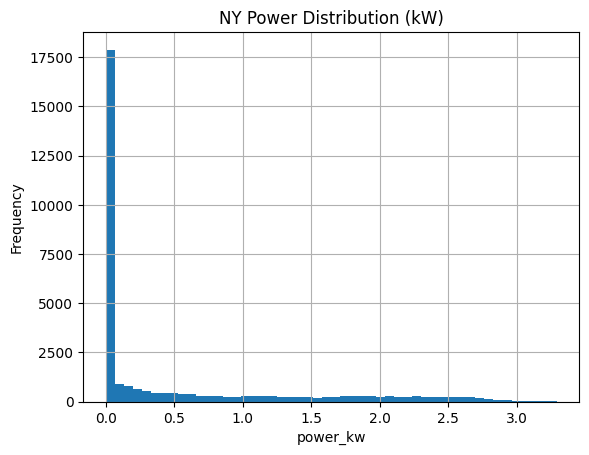

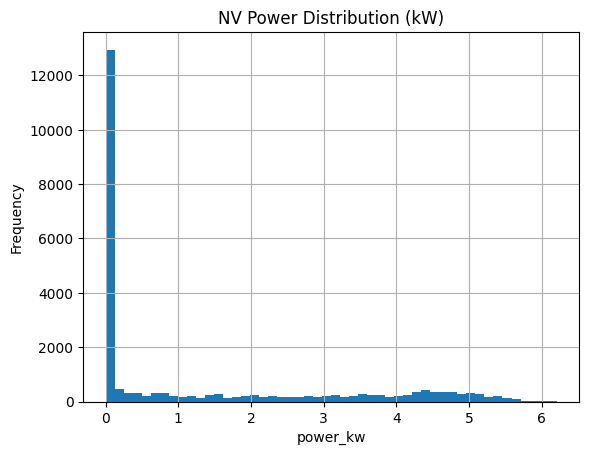

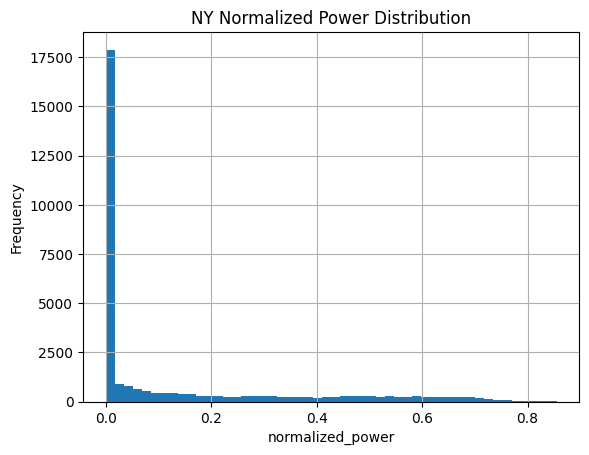

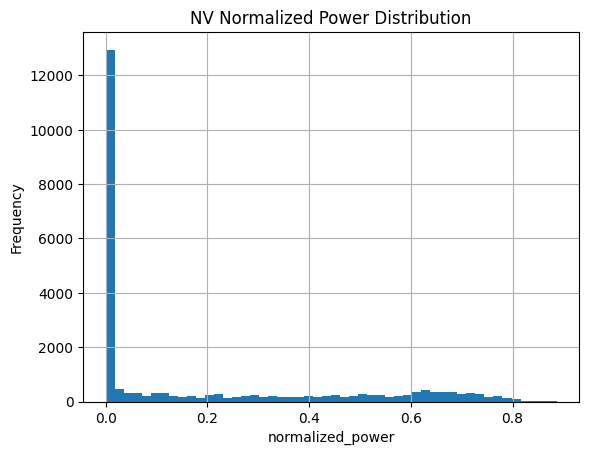

In [ ]:
# ============================================================
# 6.2 : Distribution plots
# ============================================================

def plot_distribution(df, col, title):
    plt.figure()
    df[col].dropna().hist(bins=50)
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Power distributions
plot_distribution(pv_1226, "power_kw", "NY Power Distribution (kW)")
plot_distribution(pv_1423, "power_kw", "NV Power Distribution (kW)")

# Normalized power distributions
plot_distribution(pv_1226, "normalized_power", "NY Normalized Power Distribution")
plot_distribution(pv_1423, "normalized_power", "NV Normalized Power Distribution")

### Distribution Analysis : Key Insights

- **Strong zero-inflation across both sites**
  - Both NY and NV show a large spike at **0 kW / 0 normalized power**
  - Reflects **nighttime periods and preserved missingness**
  - Confirms correctness of:
    - hourly aggregation
    - noise thresholding
    - no artificial imputation

- **Right-skewed distributions (typical for solar)**
  - Long tail toward higher power values
  - Most observations are low or zero, with fewer high-production periods
  - Matches expected **solar generation behavior**

- **Clear difference in absolute power distributions**
  - NV reaches much higher power values (~6+ kW) vs NY (~3+ kW)
  - NV distribution is **shifted right**, indicating stronger solar resource
  - Confirms:
    - geographic contrast
    - appropriateness of site pairing

- **Normalized power enables meaningful cross-site comparison**
  - After normalization, both sites fall within similar ranges (~0–0.9)
  - Removes scale differences due to system size
  - Enables fair comparison of:
    - efficiency
    - variability
    - model performance

- **NY shows more mass at low but nonzero values**
  - Indicates more **frequent partial generation**
  - Likely due to:
    - cloud cover
    - diffuse irradiance
  - Suggests higher variability and noisier signal

- **NV shows stronger concentration at mid-to-high normalized values**
  - Indicates more **consistent, high-output periods**
  - Reflects stable solar conditions (clear skies)
  - Suggests easier forecasting conditions

---

### Implications for Modeling

- **Expect many zero targets**
  - Models must handle **zero-heavy distributions**
  - Important for loss functions and evaluation

- **Normalized power is the correct modeling target**
  - Enables cross-site generalization
  - Removes system-specific scaling bias

- **Different learning difficulty across sites**
  - NV → smoother, more predictable
  - NY → noisier, more complex patterns

- **Potential for distribution shift**
  - Models trained on NV may struggle on NY
  - Reinforces need for **robustness evaluation**

---

### Bottom Line

- Distributions are **physically realistic and consistent with solar behavior**
- Differences between sites are **clear, meaningful, and useful**
- Strong justification for:
  - normalization
  - cross-site comparison
  - robustness-focused evaluation

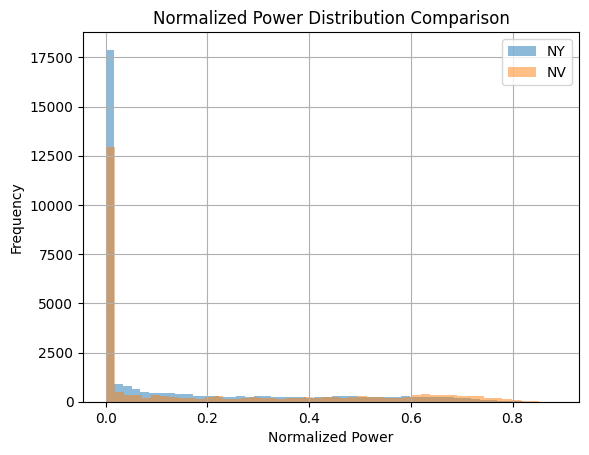

In [ ]:
# ============================================================
# Compare normalized distributions
# ============================================================

plt.figure()
pv_1226["normalized_power"].dropna().hist(bins=50, alpha=0.5)
pv_1423["normalized_power"].dropna().hist(bins=50, alpha=0.5)
plt.title("Normalized Power Distribution Comparison")
plt.xlabel("Normalized Power")
plt.ylabel("Frequency")
plt.legend(["NY", "NV"])
plt.show()

### Normalized Power Distribution Comparison : Key Insights

- **Both sites exhibit strong zero-inflation**
  - Large spike at 0 reflects nighttime + preserved missingness
  - Confirms physically correct behavior and proper preprocessing
  - Reinforces that models must handle a **zero-heavy target distribution**

- **Normalized scaling successfully aligns the two sites**
  - Both NY and NV now lie within a comparable range (~0 to ~0.9)
  - Removes system size bias and enables **fair cross-site comparison**
  - Justifies the use of `normalized_power` as a primary modeling target

- **Clear difference in generation regimes**
  - **NV (orange):** much higher density in mid-to-high normalized values (~0.4–0.8)
    - Indicates **frequent strong production**
    - Reflects stable, high-irradiance conditions
  - **NY (blue):** heavier concentration near low nonzero values (~0–0.2)
    - Indicates **frequent partial/weak generation**
    - Reflects cloud cover and higher variability

- **NY shows broader low-value spread**
  - More mass in the 0–0.3 range
  - Suggests **noisier and more difficult prediction task**
  - Implies more sensitivity to weather variability

- **NV shows tighter high-value concentration**
  - More consistent presence in higher normalized bins
  - Suggests **smoother, more predictable generation patterns**

- **Evidence of distribution shift between sites**
  - The two distributions are clearly not identical
  - Indicates that a model trained on one site may not generalize perfectly to the other
  - Strong justification for **robustness and cross-site evaluation**

---

### Modeling Implications

- **Normalized power is the correct target**
  - Enables meaningful cross-site learning and evaluation
  - Prevents bias toward larger-capacity systems

- **Expect asymmetric learning difficulty**
  - NV → easier (stable, high signal)
  - NY → harder (low signal, high variability)

- **Zero vs nonzero regime matters**
  - Models must distinguish:
    - nighttime (trivial zeros)
    - daytime (complex prediction)

- **Cross-site generalization will be nontrivial**
  - Differences in distributions suggest potential performance drop when transferring models
  - Reinforces importance of evaluating robustness across environments

---

### Bottom Line

- The comparison confirms that normalization worked as intended  
- The two sites exhibit **distinct but complementary generation behaviors**  
- These differences are not a problem : they are a **core strength of the dataset**, enabling meaningful evaluation of model robustness and generalization

### 6.3 Temporal Behavior

We examine:
- sample daily curves
- average hourly production profiles
- seasonal patterns
- yearly trends

These help us understand:
- daily solar cycles
- variability across sites
- seasonal dependence of solar generation

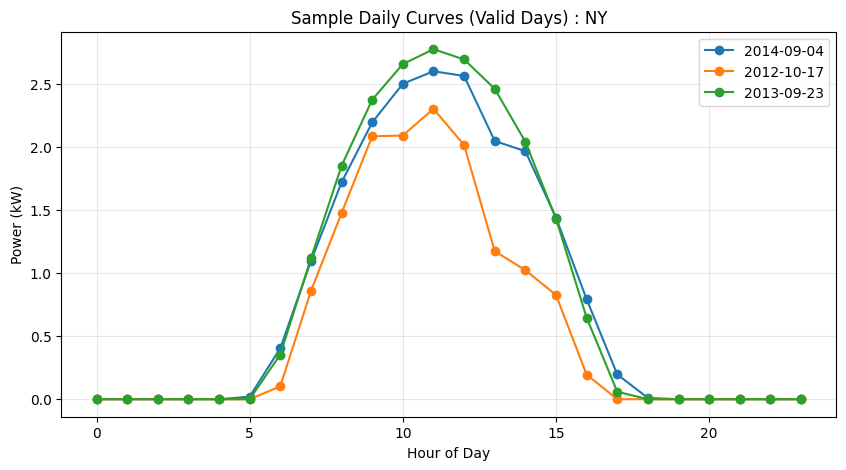

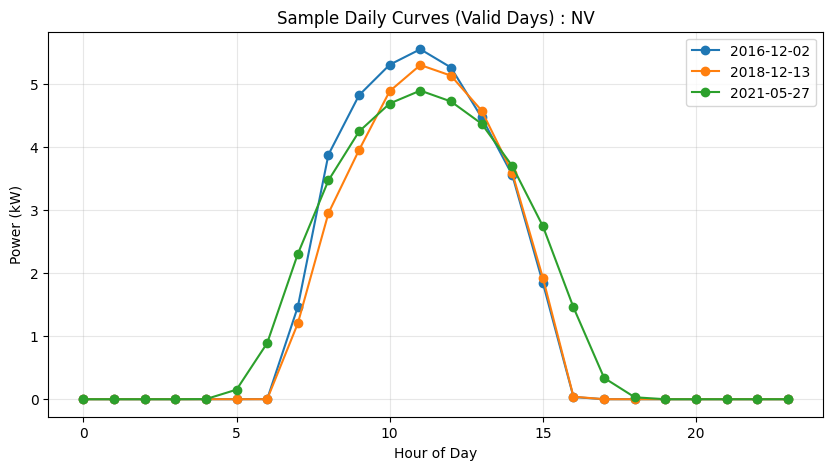

In [ ]:
# =================================
# Sample Daily Curves
# =================================

def plot_valid_days(df, name, n_days=3, min_hours=12):
    """
    Plot random valid daily curves.

    Parameters:
    - df: dataframe with either a DatetimeIndex or a 'timestamp' column
    - name: site name for title
    - n_days: number of days to plot
    - min_hours: minimum number of non-missing hours required
    """

    import pandas as pd
    import matplotlib.pyplot as plt

    # Step 1: make a safe copy
    df_temp = df.copy()

    # Step 2: ensure we have a DatetimeIndex
    if not isinstance(df_temp.index, pd.DatetimeIndex):
        if "timestamp" in df_temp.columns:
            df_temp["timestamp"] = pd.to_datetime(df_temp["timestamp"])
            df_temp = df_temp.set_index("timestamp")
        else:
            raise ValueError(
                f"{name} dataframe must have either a DatetimeIndex or a 'timestamp' column."
            )

    # Step 3: create date column for grouping
    df_temp["date"] = df_temp.index.date

    # Step 4: count valid power observations per day
    valid_counts = df_temp.groupby("date")["power_kw"].apply(lambda x: x.notna().sum())

    # Step 5: keep only sufficiently complete days
    valid_days = valid_counts[valid_counts >= min_hours].index

    if len(valid_days) == 0:
        print(f"No valid days found for {name}")
        return

    # Step 6: randomly sample valid days
    sampled_days = pd.Series(valid_days).sample(
        min(n_days, len(valid_days)),
        random_state=42
    )

    # Step 7: plot sampled days
    plt.figure(figsize=(10, 5))

    for day in sampled_days:
        day_data = df_temp[df_temp.index.date == day].sort_index()
        plt.plot(day_data.index.hour, day_data["power_kw"], marker="o", label=str(day))

    plt.title(f"Sample Daily Curves (Valid Days) : {name}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Power (kW)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


# Run for both sites
plot_valid_days(pv_1226, "NY")
plot_valid_days(pv_1423, "NV")

### Sample Daily Curves: Key Insights

- **Both sites now show clean, physically realistic solar generation patterns**
  - Clear **diurnal cycle**: zero at night → smooth ramp-up → midday peak → decline
  - Confirms:
    - correct cleaning and resampling
    - successful handling of missing data
    - valid visualization approach

---

### Site 1226 (NY) : Variable, weather-driven behavior

- **Lower peak output (~2.2–2.8 kW)**
  - Consistent with smaller system capacity and weaker solar resource

- **High variability across days**
  - Noticeable differences in peak height and curve shape
  - Some days show:
    - flatter peaks
    - early drop-offs
  - Indicates:
    - cloud cover
    - atmospheric variability

- **Less smooth curves**
  - More irregular transitions throughout the day
  - Suggests **noisier and less stable generation**

**Interpretation:**  
NY represents a **challenging forecasting environment** with high variability and sensitivity to weather.

---

### Site 1423 (NV) : Strong, stable solar behavior

- **Much higher peak output (~5–5.5 kW)**
  - Reflects stronger irradiance and larger effective system output

- **Highly consistent curve shapes across days**
  - Similar ramp-up, peak timing, and decline
  - Indicates:
    - clear skies
    - stable solar conditions

- **Smooth, symmetric curves**
  - Near-ideal “bell-shaped” solar production
  - Minimal irregular fluctuations

**Interpretation:**  
NV represents a **stable, high-signal environment** where forecasting is easier and more predictable.

---

### Direct Comparison

- **Magnitude difference**
  - NV consistently produces ~2× the power of NY

- **Variability contrast**
  - NY: high variability, irregular shapes  
  - NV: low variability, consistent shapes  

- **Predictability**
  - NY: harder (weather-driven fluctuations)  
  - NV: easier (clear-sky consistency)

---

### Key Modeling Implications

- **Strong daily structure exists in both datasets**
  - Models can leverage:
    - hour-of-day features
    - lag features (t-1, t-24)
    - seasonal patterns

- **Site-dependent difficulty**
  - Models trained on NV may struggle on NY
  - Reinforces need for:
    - robustness evaluation
    - cross-site generalization testing

- **Normalized power remains essential**
  - Enables comparison of shape rather than magnitude
  - Supports unified modeling across sites

---

### Bottom Line

- The corrected sampling reveals **true underlying solar behavior**
- NY and NV exhibit **clear, meaningful differences in variability and stability**
- These differences are a **core strength of the dataset**, enabling:
  - realistic forecasting challenges
  - robust model evaluation
  - strong, defensible project insights

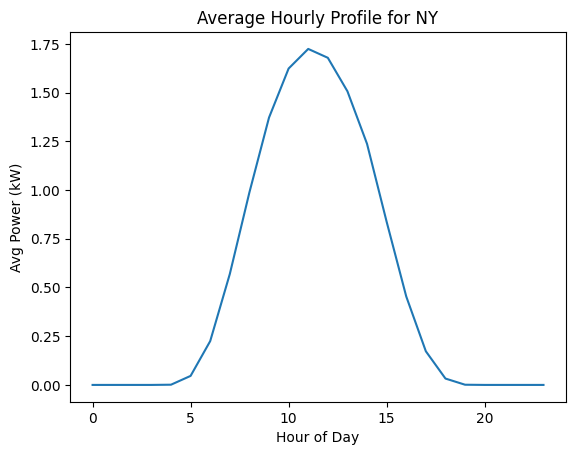

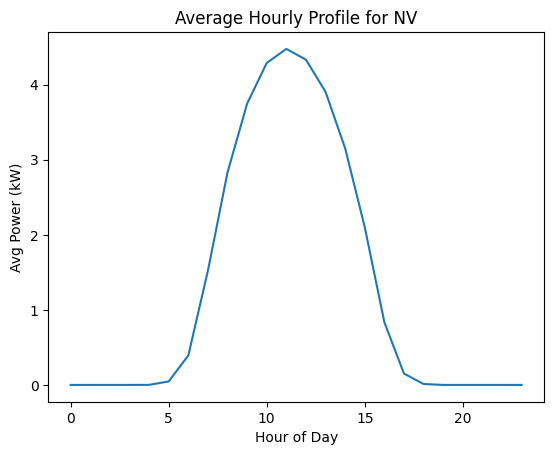

In [ ]:
# ===================================
# Average hourly production profile
# ===================================

def avg_hourly_profile(df, name):
    hourly_avg = df.groupby(df.index.hour)["power_kw"].mean()

    plt.figure()
    plt.plot(hourly_avg.index, hourly_avg.values)
    plt.title(f"Average Hourly Profile for {name}")
    plt.xlabel("Hour of Day")
    plt.ylabel("Avg Power (kW)")
    plt.show()

avg_hourly_profile(pv_1226, "NY")
avg_hourly_profile(pv_1423, "NV")

### Average Hourly Production Profile : Key Insights

- **Both sites exhibit a strong, clean diurnal solar pattern**
  - Near-zero production overnight
  - Smooth ramp-up starting ~6–7 AM
  - Peak generation around **11 AM – 1 PM**
  - Symmetric decline toward sunset
  - Confirms:
    - correct hourly resampling
    - strong temporal signal in the data

---

### Site 1226 (NY) : Lower, broader, more diffuse profile

- **Lower peak output (~1.7 kW average)**
  - Reflects weaker solar resource and/or cloudier conditions

- **Broader peak**
  - Generation remains relatively high across multiple midday hours
  - Suggests:
    - more diffuse irradiance
    - cloud scattering effects

- **Slower ramp-up and ramp-down**
  - Indicates less sharp transitions between night/day
  - Implies more variability in sunlight intensity

**Interpretation:**  
NY has a **weaker but more spread-out generation profile**, consistent with variable weather and cloud cover.

---

### Site 1423 (NV) : Higher, sharper, more concentrated profile

- **Much higher peak output (~4.5 kW average)**
  - Reflects stronger, more direct solar irradiance

- **Sharper, more peaked curve**
  - Rapid ramp-up in the morning
  - Strong, concentrated midday peak
  - Faster decline in afternoon

- **More “ideal” solar shape**
  - Close to theoretical clear-sky production curve
  - Indicates stable, high-quality solar conditions

**Interpretation:**  
NV has a **strong, concentrated, and stable generation profile**, characteristic of clear-sky environments.

---

### Direct Comparison

- **Magnitude difference**
  - NV produces ~2.5× more average power than NY at peak

- **Shape difference**
  - NY: broader, flatter peak → diffuse, variable sunlight  
  - NV: narrow, sharp peak → direct, stable sunlight  

- **Ramp dynamics**
  - NY: gradual transitions  
  - NV: steeper, more defined transitions  

---

### Key Modeling Implications

- **Hour-of-day is a powerful feature**
  - Strong, consistent daily pattern across both sites
  - Models can leverage:
    - cyclical encoding (sin/cos hour)
    - lag features (t-24)

- **Different learning regimes**
  - NV: easier (stable, strong signal)
  - NY: harder (weaker, noisier signal)

- **Seasonal and weather features will matter more for NY**
  - Because average profile alone does not fully explain variability

- **Normalization is still necessary**
  - Absolute differences are large, but shape comparison is key

---

### Bottom Line

- Both sites follow the expected solar production curve, validating data quality  
- NV exhibits **stronger and more concentrated generation**, while NY shows **weaker and more diffuse behavior**  
- These differences reinforce:
  - the value of cross-site comparison  
  - the need for robust models that handle both stable and variable environments

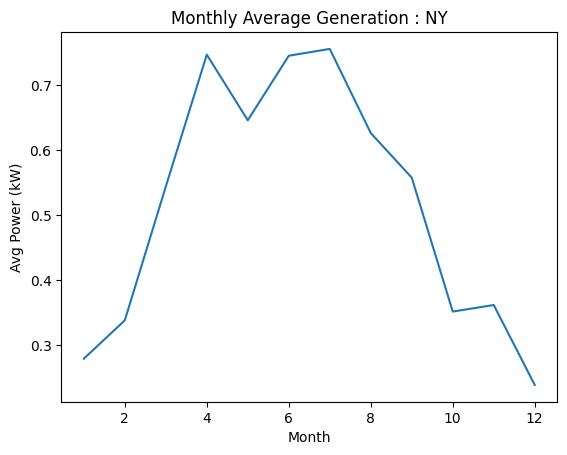

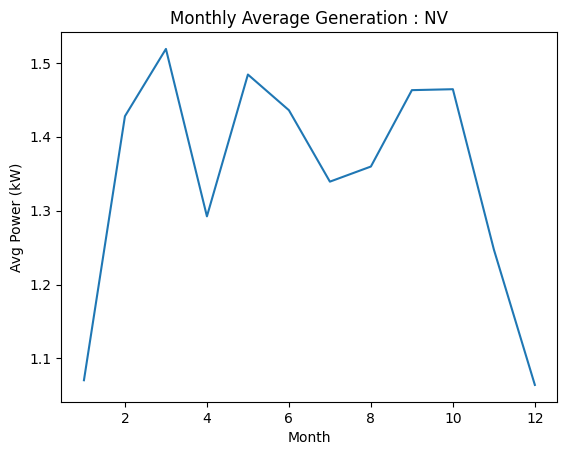

In [ ]:
# ============================
# Monthly / seasonal patterns
# ============================
def monthly_pattern(df, name):
    monthly_avg = df.groupby(df.index.month)["power_kw"].mean()

    plt.figure()
    plt.plot(monthly_avg.index, monthly_avg.values)
    plt.title(f"Monthly Average Generation : {name}")
    plt.xlabel("Month")
    plt.ylabel("Avg Power (kW)")
    plt.show()

monthly_pattern(pv_1226, "NY")
monthly_pattern(pv_1423, "NV")

### Monthly / Seasonal Generation Patterns : Key Insights

- **Clear seasonality in both sites**
  - Both NY and NV show higher generation in **spring–summer months** and lower generation in **fall–winter**
  - Confirms expected dependence on:
    - solar angle (day length)
    - seasonal irradiance patterns
  - Validates physical realism of the dataset

---

### Site 1226 (NY) : Strong seasonal variability

- **Pronounced peak in late spring / early summer (≈ May–July)**
  - Peak average generation ~0.75 kW
  - Significant drop-off toward winter (~0.25–0.35 kW)

- **Large seasonal amplitude**
  - Roughly **3× difference** between winter and summer
  - Indicates strong dependence on:
    - daylight duration
    - cloud cover variability

- **Irregular month-to-month fluctuations**
  - Noticeable dips (e.g., May vs June) suggest:
    - weather-driven variability (clouds, storms)
    - not purely smooth seasonal behavior

- **Interpretation**
  - NY exhibits **high seasonal sensitivity and variability**
  - More challenging environment for consistent forecasting across the year

---

### Site 1423 (NV) : Stable but still seasonal

- **Higher overall generation across all months**
  - Winter minimum ~1.05 kW
  - Peak ~1.5 kW
  - Consistently above NY across all months

- **Moderate seasonal variation**
  - Smaller relative difference (~1.4× peak-to-trough)
  - Indicates:
    - more consistent solar resource
    - less weather-driven disruption

- **Less smooth than expected**
  - Some irregularities (e.g., April dip) suggest:
    - data availability gaps influencing monthly averages
    - possible residual sampling imbalance

- **Interpretation**
  - NV has **stable but still seasonally structured generation**
  - Easier to model across seasons compared to NY

---

### Direct Comparison

- **Magnitude**
  - NV consistently produces ~2× the average power of NY across all months

- **Seasonal sensitivity**
  - NY: strong seasonal swings (high amplitude)
  - NV: more stable across seasons (lower amplitude)

- **Variability**
  - NY: more irregular, weather-driven
  - NV: smoother, irradiance-driven

---

### Modeling Implications

- **Seasonality must be explicitly modeled**
  - Include:
    - month or day-of-year features
    - cyclical encoding (sin/cos)
  - Critical for capturing long-term patterns

- **NY requires stronger seasonal modeling**
  - Larger seasonal swings and variability
  - Models must handle both:
    - low winter output
    - high summer peaks

- **NV provides a more stable baseline**
  - Easier generalization within-site
  - Useful benchmark for model performance

- **Potential bias from missing data in NV**
  - Monthly irregularities may reflect:
    - uneven data availability
  - Important to consider when interpreting results

---

### Bottom Line

- Both sites demonstrate **physically consistent seasonal behavior**
- NY shows **stronger and more volatile seasonal variation**
- NV shows **higher, more stable generation across the year**
- These differences reinforce:
  - the need for seasonal features
  - the value of cross-site comparison in evaluating model robustness

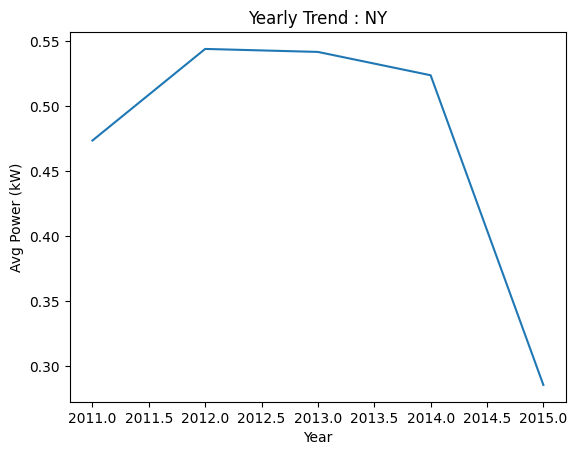

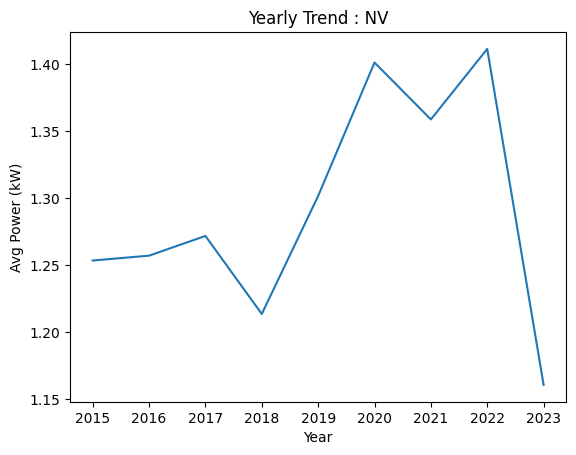

In [ ]:
# ==============
# Yearly trend
# =============

def yearly_trend(df, name):
    yearly_avg = df.groupby(df.index.year)["power_kw"].mean()

    plt.figure()
    plt.plot(yearly_avg.index, yearly_avg.values)
    plt.title(f"Yearly Trend : {name}")
    plt.xlabel("Year")
    plt.ylabel("Avg Power (kW)")
    plt.show()

yearly_trend(pv_1226, "NY")
yearly_trend(pv_1423, "NV")

### Yearly Trend Analysis : Key Insights

- **No clear long-term physical degradation trend in either site**
  - Neither NY nor NV shows a steady year-over-year decline
  - Indicates:
    - no strong evidence of panel degradation
    - no systematic performance loss
  - Confirms overall data consistency and system stability

---

### Site 1226 (NY) : Apparent drop is data-driven, not physical

- **Stable performance from 2011–2014 (~0.52–0.55 kW avg)**
  - Minor fluctuations consistent with normal year-to-year variability

- **Sharp drop in 2015 (~0.28 kW)**
  - This is **not physically plausible**
  - Solar systems do not lose ~50% output in one year

- **Likely cause: incomplete data coverage**
  - Earlier Phase 2 results showed:
    - missing hourly values
    - uneven data availability
  - 2015 likely contains:
    - partial year coverage
    - large missing segments

- **Interpretation**
  - The drop reflects **sampling bias**, not system behavior

---

### Site 1423 (NV) : Fluctuations driven by data availability

- **Gradual increase from 2015–2017**
  - Likely due to:
    - increasing data coverage
    - more complete observation periods

- **Dip in 2018**
  - Likely reflects:
    - reduced data availability
    - large missing segments (confirmed earlier)

- **Strong rise 2019–2022**
  - Peak around 2020–2022 (~1.4 kW)
  - Suggests:
    - more complete and representative data in those years

- **Sharp drop in 2023**
  - Again, not physically plausible
  - Almost certainly due to:
    - partial-year data (dataset ends early in 2023)

---

### Core Insight

- **Yearly averages are highly sensitive to missing data coverage**
  - When large portions of a year are missing:
    - averages become biased
    - trends become misleading

- **Observed dips are not true system behavior**
  - They are artifacts of:
    - incomplete data
    - uneven temporal coverage

---

### Implications for Analysis

- **Yearly trends must be interpreted with caution**
  - Cannot assume uniform data coverage across years

- **Avoid using yearly averages for modeling decisions**
  - Better to rely on:
    - hourly/daily patterns
    - seasonal features
    - continuous segments

- **Potential improvement (optional)**
  - Filter to years with sufficient data coverage before computing yearly averages

---

### Modeling Implications

- **Do not treat yearly variation as signal**
  - It is largely driven by missingness

- **Focus on intra-day and seasonal patterns**
  - These are consistent and physically meaningful

- **Missingness-aware evaluation is critical**
  - Reinforces need to:
    - restrict training to valid periods
    - avoid aggregations that obscure data gaps

---

### Bottom Line

- Yearly dips are **artifacts of incomplete data**, not real solar behavior  
- Both sites show **stable underlying performance when data is present**  
- This reinforces the importance of:
  - handling missing data carefully  
  - avoiding misleading aggregate metrics  
  - grounding analysis in physically meaningful timescales

DAY VS NIGHT ANALYSIS: Site 1226 : NY

Total rows: 32,905
Nonzero (daytime proxy): 15,151 (46.04%)
Zero (nighttime proxy): 16,117 (48.98%)
Missing: 1,637 (4.97%)

Nonzero power summary:
count    15151.000000
mean         1.073907
std          0.898499
min          0.000769
25%          0.229583
50%          0.858333
75%          1.848333
max          3.291833
Name: power_kw, dtype: float64

DAY VS NIGHT ANALYSIS: Site 1423 : NV

Total rows: 63,685
Nonzero (daytime proxy): 12,205 (19.16%)
Zero (nighttime proxy): 11,540 (18.12%)
Missing: 39,940 (62.71%)

Nonzero power summary:
count    12205.000000
mean         2.575593
std          1.826777
min          0.000186
25%          0.737088
50%          2.655102
75%          4.312751
max          6.206245
Name: power_kw, dtype: float64



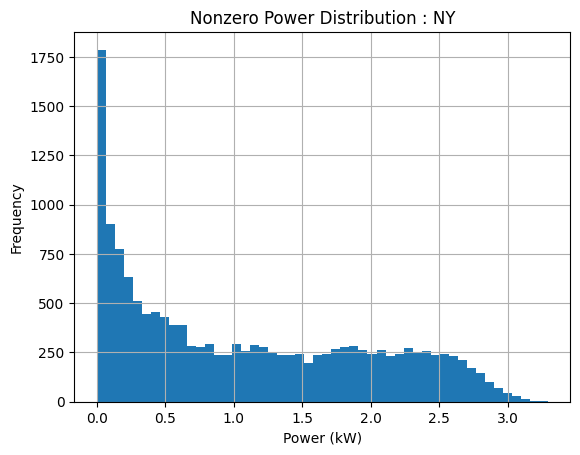

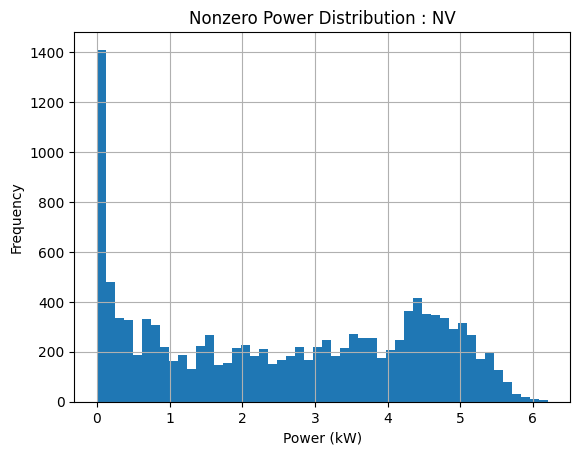

In [ ]:
# ============================================================
# Day vs Night + Nonzero Distribution Analysis
# ============================================================

def day_night_analysis(df, name):
    print(f"DAY VS NIGHT ANALYSIS: {name}")
    print()

    total = len(df)
    nonzero = (df["power_kw"] > 0).sum()
    zero = (df["power_kw"] == 0).sum()
    missing = df["power_kw"].isna().sum()

    print(f"Total rows: {total:,}")
    print(f"Nonzero (daytime proxy): {nonzero:,} ({100*nonzero/total:.2f}%)")
    print(f"Zero (nighttime proxy): {zero:,} ({100*zero/total:.2f}%)")
    print(f"Missing: {missing:,} ({100*missing/total:.2f}%)")

    print("\nNonzero power summary:")
    print(df.loc[df["power_kw"] > 0, "power_kw"].describe())
    print()

def plot_nonzero_distribution(df, name):
    plt.figure()
    df.loc[df["power_kw"] > 0, "power_kw"].hist(bins=50)
    plt.title(f"Nonzero Power Distribution : {name}")
    plt.xlabel("Power (kW)")
    plt.ylabel("Frequency")
    plt.show()


# Run analysis
day_night_analysis(pv_1226, "Site 1226 : NY")
day_night_analysis(pv_1423, "Site 1423 : NV")

# Plot distributions
plot_nonzero_distribution(pv_1226, "NY")
plot_nonzero_distribution(pv_1423, "NV")

Site 1226 (NY):
- nonzero: 46%
- zero: 49%
- missing: 5%
- roughly half of data is real day-time generation and half is nighttime, with very little missing data

Site 1423 (NV):
- nonzero: 19%
- zero: 18%
- missing 63%
- only 37% of entries have any data (zero + nonzero), which still leaves sufficient data
- the rest is missing blocks
- of the remaining, roughly half is night and half is day

Daytime behaviors:
- NY:
  - weak, variable, heavy masses at low values, only spreads up to ~3.3kW
- NV:
  - strong concentration at higher values, strong, stable, high output

### 6.4 Site Comparison

We compare:
- average generation
- variability
- seasonal behavior
- continuity of observations

This directly supports model design and evaluation decisions.

In [ ]:
# ============================================================
# Site comparison metrics
# ============================================================

def site_stats(df):
    return {
        "mean_power": df["power_kw"].mean(),
        "std_power": df["power_kw"].std(),
        "mean_norm": df["normalized_power"].mean(),
        "std_norm": df["normalized_power"].std(),
        "missing_pct": df["power_kw"].isna().mean()
    }

ny_stats = site_stats(pv_1226)
nv_stats = site_stats(pv_1423)

comparison_df = pd.DataFrame([ny_stats, nv_stats], index=["NY", "NV"])
display(comparison_df)

,mean_power,std_power,mean_norm,std_norm,missing_pct
NY,0.520365,0.824148,0.135160,0.214064,0.049749
NV,1.323862,1.836411,0.189123,0.262344,0.627149


### Site Comparison : Key Insights

- **NV produces substantially more power than NY**
  - NV mean power (~1.32 kW) is ~2.5× higher than NY (~0.52 kW)
  - Reflects stronger solar resource and clearer atmospheric conditions in NV
  - Confirms earlier distribution and temporal analysis

- **NV also exhibits higher variability in absolute terms**
  - NV std (~1.84 kW) > NY std (~0.82 kW)
  - Driven by larger magnitude swings between night (0) and strong midday peaks
  - Not necessarily “less stable”:just operating at a higher scale

- **Normalized comparison reveals closer:but still meaningful:differences**
  - NV mean normalized (~0.189) > NY (~0.135)
  - NV std normalized (~0.262) > NY (~0.214)
  - Indicates NV still has:
    - stronger average utilization of capacity
    - slightly greater variability even after scaling

- **NY operates at consistently lower utilization levels**
  - Lower mean normalized power suggests:
    - more frequent partial generation
    - greater impact of clouds and diffuse irradiance
  - Confirms NY as a **weaker and more variable solar environment**

- **Missingness is the most significant structural difference**
  - NY missing ~5% → dense, reliable dataset
  - NV missing ~63% → sparse, discontinuous dataset
  - This is the **dominant factor affecting usability and modeling strategy**

---

### Interpretation

- **NY = lower power, lower variability, high data availability**
  - Harder due to weather noise, but easier to train on (continuous data)

- **NV = higher power, higher variability, low data availability**
  - Easier physical signal, but harder due to missingness and gaps

---

### Modeling Implications

- **Normalized power is essential**
  - Removes scale differences and enables fair comparison

- **Different modeling challenges per site**
  - NY → variability-driven difficulty (weather sensitivity)
  - NV → data availability-driven difficulty (missingness)

- **Cross-site generalization will be non-trivial**
  - Differences in both:
    - signal distribution
    - data structure (missingness)

- **Evaluation must account for imbalance**
  - NV’s high missingness requires:
    - careful filtering
    - continuity-aware training

---

### Bottom Line

- The two sites are **fundamentally different but complementary**
- NY provides **dense, variable data**
- NV provides **strong signal but sparse coverage**
- This contrast is a **core strength of the project**, enabling meaningful analysis of robustness and generalization

## Phase 4 : Acquire and Build One Clean Hourly NSRDB Weather Table Per Site

Goals:
- Load downloaded NSRDB weather/irradiance files for each selected site
- Build a clean hourly weather table for each site
- Standardize timestamps and feature names
- Keep only the core weather and irradiance variables needed for modeling

Core NSRDB variables:
- GHI
- Clearsky GHI
- DNI
- DHI
- Temperature
- Wind Speed
- Relative Humidity
- Dew Point
- Pressure

Important implementation details:
- NSRDB files contain metadata rows before the actual weather table
- Timestamps are provided as Year/Month/Day/Hour/Minute and are already in local time
- Because timestamps are recorded at `:30`, we floor them to the hour for alignment with hourly PV data
- One clean hourly weather table will be built per site

In [ ]:
# ===================================
# Phase 4.0 : Imports and path setup
# ===================================

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Create storage directories
NSRDB_RAW_ROOT = RAW_DATA_ROOT / "nsrdb"
NSRDB_INTERIM_ROOT = INTERIM_ROOT / "nsrdb"

NSRDB_RAW_ROOT.mkdir(parents=True, exist_ok=True)
NSRDB_INTERIM_ROOT.mkdir(parents=True, exist_ok=True)

print("NSRDB raw root:", NSRDB_RAW_ROOT)
print("NSRDB interim root:", NSRDB_INTERIM_ROOT)

NSRDB raw root: /content/drive/MyDrive/projs_ai_final_project/raw_data/nsrdb
NSRDB interim root: /content/drive/MyDrive/projs_ai_final_project/interim_data/nsrdb


In [ ]:
# =====================================
# Phase 4.1 : Define NSRDB site folders
# =====================================

# checking to make sure we can successfully rely on the downloaded data, redownloading would be really scary and long
NSRDB_SITE_DIRS = {
    1226: NSRDB_RAW_ROOT / "site_1226",
    1423: NSRDB_RAW_ROOT / "site_1423",
}

for site_id, path in NSRDB_SITE_DIRS.items():
    print(site_id, path, "| exists:", path.exists())

1226 /content/drive/MyDrive/projs_ai_final_project/raw_data/nsrdb/site_1226 | exists: True
1423 /content/drive/MyDrive/projs_ai_final_project/raw_data/nsrdb/site_1423 | exists: True


In [ ]:
# ============================================================
# Phase 4.2 : Find the yearly NSRDB files for each site
# ============================================================

def get_nsrdb_file_paths(site_id: int, site_dir: Path):
    csv_files = sorted(site_dir.glob("*.csv"))
    if len(csv_files) == 0:
        raise FileNotFoundError(f"No NSRDB CSV files found for site {site_id} in {site_dir}")
    return csv_files

nsrdb_file_paths = {
    site_id: get_nsrdb_file_paths(site_id, site_dir)
    for site_id, site_dir in NSRDB_SITE_DIRS.items()
}

for site_id, files in nsrdb_file_paths.items():
    print(f"\nSite {site_id}: {len(files)} NSRDB files found")
    for fp in files[:5]:
        print(" ", fp.name)


Site 1226: 5 NSRDB files found
  1255415_41.01_-73.66_2011.csv
  1255415_41.01_-73.66_2012.csv
  1255415_41.01_-73.66_2013.csv
  1255415_41.01_-73.66_2014.csv
  1255415_41.01_-73.66_2015.csv

Site 1423: 9 NSRDB files found
  263708_36.01_-114.98_2015.csv
  263708_36.01_-114.98_2016.csv
  263708_36.01_-114.98_2017.csv
  263708_36.01_-114.98_2018.csv
  263708_36.01_-114.98_2019.csv


### NSRDB loading strategy

Each NSRDB file contains:
- metadata header row
- metadata values row
- actual data header row
- weather rows

So we:
1. read the metadata separately
2. read the weather table starting from the true header row
3. retain source-file provenance
4. concatenate all years for each site

In [ ]:
# =====================================
# Phase 4.3 : Read a single NSRDB file
# ======================================

def read_nsrdb_file(file_path: Path):
    """
    Read one NSRDB CSV file.

    Returns
    -------
    metadata_df : pd.DataFrame
        Single-row metadata table from the first two lines.
    data_df : pd.DataFrame
        Weather/irradiance table beginning from the actual data header.
    """
    # Metadata: first row is column names, second row is values
    metadata_df = pd.read_csv(file_path, nrows=1)
    metadata_values = pd.read_csv(file_path, skiprows=1, nrows=1, header=None)
    metadata_values.columns = metadata_df.columns
    metadata_df = metadata_values.copy()

    # Actual weather data starts after the first two lines
    data_df = pd.read_csv(file_path, skiprows=2)

    # Add provenance
    data_df["source_file"] = str(file_path)

    return metadata_df, data_df

In [ ]:
# ============================================
# Phase 4.4 : Sanity check one file per site
# ============================================
for site_id, files in nsrdb_file_paths.items():
    test_file = files[0]
    meta_df, data_df = read_nsrdb_file(test_file)

    print("=" * 90)
    print(f"SANITY CHECK: Site {site_id} | File: {test_file.name}")
    print("=" * 90)
    print("Metadata columns:")
    print(meta_df.columns.tolist())
    print("\nMetadata values:")
    display(meta_df)

    print("\nData columns:")
    print(data_df.columns.tolist())

    print("\nFirst 5 data rows:")
    display(data_df.head())

SANITY CHECK: Site 1226 | File: 1255415_41.01_-73.66_2011.csv
Metadata columns:
['Source', 'Location ID', 'City', 'State', 'Country', 'Latitude', 'Longitude', 'Time Zone', 'Elevation', 'Local Time Zone', 'Clearsky DHI Units', 'Clearsky DNI Units', 'Clearsky GHI Units', 'Dew Point Units', 'DHI Units', 'DNI Units', 'GHI Units', 'Solar Zenith Angle Units', 'Temperature Units', 'Pressure Units', 'Relative Humidity Units', 'Precipitable Water Units', 'Wind Direction Units', 'Wind Speed Units', 'Cloud Type -15', 'Cloud Type 0', 'Cloud Type 1', 'Cloud Type 2', 'Cloud Type 3', 'Cloud Type 4', 'Cloud Type 5', 'Cloud Type 6', 'Cloud Type 7', 'Cloud Type 8', 'Cloud Type 9', 'Cloud Type 10', 'Cloud Type 11', 'Cloud Type 12', 'Fill Flag 0', 'Fill Flag 1', 'Fill Flag 2', 'Fill Flag 3', 'Fill Flag 4', 'Fill Flag 5', 'Surface Albedo Units', 'Version']

Metadata values:


,Source,Location ID,City,State,Country,Latitude,Longitude,Time Zone,Elevation,Local Time Zone,Clearsky DHI Units,Clearsky DNI Units,Clearsky GHI Units,Dew Point Units,DHI Units,DNI Units,GHI Units,Solar Zenith Angle Units,Temperature Units,Pressure Units,Relative Humidity Units,Precipitable Water Units,Wind Direction Units,Wind Speed Units,Cloud Type -15,Cloud Type 0,Cloud Type 1,Cloud Type 2,Cloud Type 3,Cloud Type 4,Cloud Type 5,Cloud Type 6,Cloud Type 7,Cloud Type 8,Cloud Type 9,Cloud Type 10,Cloud Type 11,Cloud Type 12,Fill Flag 0,Fill Flag 1,Fill Flag 2,Fill Flag 3,Fill Flag 4,Fill Flag 5,Surface Albedo Units,Version
0,NSRDB,1255415,-,-,-,41.01,-73.66,-5,22,-5,w/m2,w/m2,w/m2,c,w/m2,w/m2,w/m2,Degree,c,mbar,%,cm,Degrees,m/s,NaN,Clear,Probably Clear,Fog,Water,Super-Cooled Water,Mixed,Opaque Ice,Cirrus,Overlapping,Overshooting,Unknown,Dust,Smoke,NaN,Missing Image,Low Irradiance,Exceeds Clearsky,Missing CLoud Properties,Rayleigh Violation,NaN,4.0.1



Data columns:
['Year', 'Month', 'Day', 'Hour', 'Minute', 'Dew Point', 'DHI', 'DNI', 'GHI', 'Relative Humidity', 'Wind Speed', 'Temperature', 'Clearsky GHI', 'Pressure', 'source_file']

First 5 data rows:


,Year,Month,Day,Hour,Minute,Dew Point,DHI,DNI,GHI,Relative Humidity,Wind Speed,Temperature,Clearsky GHI,Pressure,source_file
0,2011,1,1,0,30,0.4,0,0,0,100.00,1.1,0.4,0,1017,/content/drive/MyDrive/projs_ai_final_project/...
1,2011,1,1,1,30,0.3,0,0,0,99.89,1.0,0.3,0,1017,/content/drive/MyDrive/projs_ai_final_project/...
2,2011,1,1,2,30,0.2,0,0,0,99.76,0.9,0.2,0,1017,/content/drive/MyDrive/projs_ai_final_project/...
3,2011,1,1,3,30,0.1,0,0,0,99.17,0.8,0.2,0,1017,/content/drive/MyDrive/projs_ai_final_project/...
4,2011,1,1,4,30,0.0,0,0,0,98.84,0.7,0.2,0,1017,/content/drive/MyDrive/projs_ai_final_project/...


SANITY CHECK: Site 1423 | File: 263708_36.01_-114.98_2015.csv
Metadata columns:
['Source', 'Location ID', 'City', 'State', 'Country', 'Latitude', 'Longitude', 'Time Zone', 'Elevation', 'Local Time Zone', 'Clearsky DHI Units', 'Clearsky DNI Units', 'Clearsky GHI Units', 'Dew Point Units', 'DHI Units', 'DNI Units', 'GHI Units', 'Solar Zenith Angle Units', 'Temperature Units', 'Pressure Units', 'Relative Humidity Units', 'Precipitable Water Units', 'Wind Direction Units', 'Wind Speed Units', 'Cloud Type -15', 'Cloud Type 0', 'Cloud Type 1', 'Cloud Type 2', 'Cloud Type 3', 'Cloud Type 4', 'Cloud Type 5', 'Cloud Type 6', 'Cloud Type 7', 'Cloud Type 8', 'Cloud Type 9', 'Cloud Type 10', 'Cloud Type 11', 'Cloud Type 12', 'Fill Flag 0', 'Fill Flag 1', 'Fill Flag 2', 'Fill Flag 3', 'Fill Flag 4', 'Fill Flag 5', 'Surface Albedo Units', 'Version']

Metadata values:


,Source,Location ID,City,State,Country,Latitude,Longitude,Time Zone,Elevation,Local Time Zone,Clearsky DHI Units,Clearsky DNI Units,Clearsky GHI Units,Dew Point Units,DHI Units,DNI Units,GHI Units,Solar Zenith Angle Units,Temperature Units,Pressure Units,Relative Humidity Units,Precipitable Water Units,Wind Direction Units,Wind Speed Units,Cloud Type -15,Cloud Type 0,Cloud Type 1,Cloud Type 2,Cloud Type 3,Cloud Type 4,Cloud Type 5,Cloud Type 6,Cloud Type 7,Cloud Type 8,Cloud Type 9,Cloud Type 10,Cloud Type 11,Cloud Type 12,Fill Flag 0,Fill Flag 1,Fill Flag 2,Fill Flag 3,Fill Flag 4,Fill Flag 5,Surface Albedo Units,Version
0,NSRDB,263708,-,-,-,36.01,-114.98,-8,659,-8,w/m2,w/m2,w/m2,c,w/m2,w/m2,w/m2,Degree,c,mbar,%,cm,Degrees,m/s,NaN,Clear,Probably Clear,Fog,Water,Super-Cooled Water,Mixed,Opaque Ice,Cirrus,Overlapping,Overshooting,Unknown,Dust,Smoke,NaN,Missing Image,Low Irradiance,Exceeds Clearsky,Missing CLoud Properties,Rayleigh Violation,NaN,4.0.1



Data columns:
['Year', 'Month', 'Day', 'Hour', 'Minute', 'Temperature', 'Clearsky GHI', 'DHI', 'DNI', 'GHI', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Dew Point', 'source_file']

First 5 data rows:


,Year,Month,Day,Hour,Minute,Temperature,Clearsky GHI,DHI,DNI,GHI,Relative Humidity,Pressure,Wind Speed,Dew Point,source_file
0,2015,1,1,0,30,-2.9,0,0,0,0,46.13,933,2.7,-12.9,/content/drive/MyDrive/projs_ai_final_project/...
1,2015,1,1,1,30,-2.8,0,0,0,0,48.38,933,2.3,-12.2,/content/drive/MyDrive/projs_ai_final_project/...
2,2015,1,1,2,30,-2.9,0,0,0,0,51.14,934,1.9,-11.6,/content/drive/MyDrive/projs_ai_final_project/...
3,2015,1,1,3,30,-3.4,0,0,0,0,52.66,934,1.7,-11.7,/content/drive/MyDrive/projs_ai_final_project/...
4,2015,1,1,4,30,-3.6,0,0,0,0,52.45,935,1.6,-11.9,/content/drive/MyDrive/projs_ai_final_project/...


### Build one raw NSRDB table per site

For each site:
- read all yearly files
- concatenate them into one raw NSRDB dataframe
- retain file provenance for reproducibility

In [ ]:
# ============================================================
# Phase 4.5 : Load and concatenate all NSRDB files per site
# ============================================================

def load_site_raw_nsrdb(site_id: int, file_paths: list[Path]):
    """
    Purpose:
        Load all NSRDB CSV files for a site and combine them into one dataset.

    Inputs:
        site_id: site identifier
        file_paths: list of NSRDB CSV file paths (typically one per year)

    Outputs:
        site_metadata: combined metadata from all files
        site_raw: combined time-series weather data

    Overview:
        Reads each NSRDB file, separates metadata and data,
        and concatenates across all years into one dataset.
    """
    metadata_rows = []
    data_rows = []

    # loop through all NSRDB files for this site
    for fp in file_paths:
        # read metadata and time-series data separately
        meta_df, data_df = read_nsrdb_file(fp)

        # track source file for metadata auditing
        meta_df["source_file"] = str(fp)

        metadata_rows.append(meta_df)
        data_rows.append(data_df)

    # combine all metadata rows
    site_metadata = pd.concat(metadata_rows, ignore_index=True)

    # combine all time-series rows (across years)
    site_raw = pd.concat(data_rows, ignore_index=True)

    return site_metadata, site_raw


# load and combine NSRDB data for each site
nsrdb_meta_1226, nsrdb_raw_1226 = load_site_raw_nsrdb(1226, nsrdb_file_paths[1226])
nsrdb_meta_1423, nsrdb_raw_1423 = load_site_raw_nsrdb(1423, nsrdb_file_paths[1423])

# quick check to confirm data loaded correctly
print("Raw NSRDB shapes:")
print("1226 metadata:", nsrdb_meta_1226.shape)
print("1226 raw:", nsrdb_raw_1226.shape)
print("1423 metadata:", nsrdb_meta_1423.shape)
print("1423 raw:", nsrdb_raw_1423.shape)

Raw NSRDB shapes:
1226 metadata: (5, 47)
1226 raw: (43824, 15)
1423 metadata: (9, 47)
1423 raw: (78888, 15)


In [ ]:
# ============================================================
# Phase 4.6 : Inspect raw NSRDB schemas
# ============================================================

print("Site 1226 raw columns:")
print(nsrdb_raw_1226.columns.tolist())

print()

print("Site 1423 raw columns:")
print(nsrdb_raw_1423.columns.tolist())

Site 1226 raw columns:
['Year', 'Month', 'Day', 'Hour', 'Minute', 'Dew Point', 'DHI', 'DNI', 'GHI', 'Relative Humidity', 'Wind Speed', 'Temperature', 'Clearsky GHI', 'Pressure', 'source_file']

Site 1423 raw columns:
['Year', 'Month', 'Day', 'Hour', 'Minute', 'Temperature', 'Clearsky GHI', 'DHI', 'DNI', 'GHI', 'Relative Humidity', 'Pressure', 'Wind Speed', 'Dew Point', 'source_file']


### Standardization rules

We construct a clean hourly weather table with standardized columns:

- `timestamp`
- `site_id`
- `temperature_c`
- `clearsky_ghi`
- `dhi`
- `dni`
- `ghi`
- `relative_humidity`
- `pressure_mbar`
- `wind_speed_mps`
- `dew_point_c`

Timestamps are built from:
- `Year`
- `Month`
- `Day`
- `Hour`
- `Minute`

Because NSRDB timestamps occur at `:30`, we floor them to the hour to align with hourly PV timestamps.

In [ ]:
# =========================================
# Phase 4.7 : Standardize NSRDB raw data
# =========================================

def standardize_raw_nsrdb(raw_df: pd.DataFrame, site_id: int) -> pd.DataFrame:
    """
    Purpose:
        Convert raw NSRDB data into a clean, consistent schema aligned with PV data.

    Inputs:
        raw_df: raw NSRDB dataframe (as loaded from CSVs)
        site_id: site identifier

    Outputs:
        Standardized dataframe with unified timestamp and selected weather features

    Overview:
        Builds a proper timestamp from separate date columns, aligns it to hourly resolution,
        and extracts key weather variables with consistent naming and types.
    """
    df = raw_df.copy()

    # --------------------------------------------------------
    # Ensure timestamp components are numeric
    # --------------------------------------------------------

    # NSRDB stores time as separate columns; convert safely
    for col in ["Year", "Month", "Day", "Hour", "Minute"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # --------------------------------------------------------
    # Build timestamp from components
    # --------------------------------------------------------

    # combine year/month/day/hour/minute into a single datetime
    df["timestamp_original"] = pd.to_datetime(
        dict(
            year=df["Year"],
            month=df["Month"],
            day=df["Day"],
            hour=df["Hour"],
            minute=df["Minute"]
        ),
        errors="coerce"
    )

    # --------------------------------------------------------
    # Align timestamps to hourly resolution
    # --------------------------------------------------------

    # NSRDB timestamps are typically recorded at :30 (mid-hour)
    # floor to the hour so they align with hourly PV data
    df["timestamp"] = df["timestamp_original"].dt.floor("H")

    # --------------------------------------------------------
    # Select and standardize relevant weather features
    # --------------------------------------------------------

    standardized = pd.DataFrame({
        # aligned timestamp for merging with PV data
        "timestamp": df["timestamp"],

        # keep original timestamp for auditing if needed
        "timestamp_original": df["timestamp_original"],

        # site identifier for later merging
        "site_id": site_id,

        # key weather and irradiance variables
        "temperature_c": pd.to_numeric(df.get("Temperature"), errors="coerce"),
        "clearsky_ghi": pd.to_numeric(df.get("Clearsky GHI"), errors="coerce"),
        "dhi": pd.to_numeric(df.get("DHI"), errors="coerce"),
        "dni": pd.to_numeric(df.get("DNI"), errors="coerce"),
        "ghi": pd.to_numeric(df.get("GHI"), errors="coerce"),

        # atmospheric conditions
        "relative_humidity": pd.to_numeric(df.get("Relative Humidity"), errors="coerce"),
        "pressure_mbar": pd.to_numeric(df.get("Pressure"), errors="coerce"),
        "wind_speed_mps": pd.to_numeric(df.get("Wind Speed"), errors="coerce"),
        "dew_point_c": pd.to_numeric(df.get("Dew Point"), errors="coerce"),

        # track source file for debugging/audit
        "source_file": df["source_file"],
    })

    return standardized


# apply standardization to each site's weather data
weather_1226_phase4 = standardize_raw_nsrdb(nsrdb_raw_1226, 1226)
weather_1423_phase4 = standardize_raw_nsrdb(nsrdb_raw_1423, 1423)

# quick validation
print("Standardized weather shapes:")
print("1226:", weather_1226_phase4.shape)
print("1423:", weather_1423_phase4.shape)

Standardized weather shapes:
1226: (43824, 13)
1423: (78888, 13)


/tmp/ipykernel_22034/1385500238.py:53: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["timestamp"] = df["timestamp_original"].dt.floor("H")
/tmp/ipykernel_22034/1385500238.py:53: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["timestamp"] = df["timestamp_original"].dt.floor("H")


In [ ]:
# ============================================================
# Phase 4.8 : Initial sanity checks on standardized weather data
# ============================================================

def preliminary_weather_checks(df: pd.DataFrame, site_name: str):
    print("=" * 90)
    print(f"PRELIMINARY WEATHER CHECKS: {site_name}")
    print("=" * 90)

    print("Shape:", df.shape)
    print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
    print("Missing timestamps:", df["timestamp"].isna().sum())
    print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

    print("\nMissing values by column:")
    print(df.isna().sum())

    print("\nFirst 5 rows:")
    display(df.head())

preliminary_weather_checks(weather_1226_phase4, "Site 1226 : Port Chester, NY")
preliminary_weather_checks(weather_1423_phase4, "Site 1423 : Henderson, NV")

PRELIMINARY WEATHER CHECKS: Site 1226 : Port Chester, NY
Shape: (43824, 13)
Date range: 2011-01-01 00:00:00 to 2015-12-31 23:00:00
Missing timestamps: 0
Duplicate timestamps: 0

Missing values by column:
timestamp             0
timestamp_original    0
site_id               0
temperature_c         0
clearsky_ghi          0
dhi                   0
dni                   0
ghi                   0
relative_humidity     0
pressure_mbar         0
wind_speed_mps        0
dew_point_c           0
source_file           0
dtype: int64

First 5 rows:


,timestamp,timestamp_original,site_id,temperature_c,clearsky_ghi,dhi,dni,ghi,relative_humidity,pressure_mbar,wind_speed_mps,dew_point_c,source_file
0,2011-01-01 00:00:00,2011-01-01 00:30:00,1226,0.4,0,0,0,0,100.00,1017,1.1,0.4,/content/drive/MyDrive/projs_ai_final_project/...
1,2011-01-01 01:00:00,2011-01-01 01:30:00,1226,0.3,0,0,0,0,99.89,1017,1.0,0.3,/content/drive/MyDrive/projs_ai_final_project/...
2,2011-01-01 02:00:00,2011-01-01 02:30:00,1226,0.2,0,0,0,0,99.76,1017,0.9,0.2,/content/drive/MyDrive/projs_ai_final_project/...
3,2011-01-01 03:00:00,2011-01-01 03:30:00,1226,0.2,0,0,0,0,99.17,1017,0.8,0.1,/content/drive/MyDrive/projs_ai_final_project/...
4,2011-01-01 04:00:00,2011-01-01 04:30:00,1226,0.2,0,0,0,0,98.84,1017,0.7,0.0,/content/drive/MyDrive/projs_ai_final_project/...


PRELIMINARY WEATHER CHECKS: Site 1423 : Henderson, NV
Shape: (78888, 13)
Date range: 2015-01-01 00:00:00 to 2023-12-31 23:00:00
Missing timestamps: 0
Duplicate timestamps: 0

Missing values by column:
timestamp             0
timestamp_original    0
site_id               0
temperature_c         0
clearsky_ghi          0
dhi                   0
dni                   0
ghi                   0
relative_humidity     0
pressure_mbar         0
wind_speed_mps        0
dew_point_c           0
source_file           0
dtype: int64

First 5 rows:


,timestamp,timestamp_original,site_id,temperature_c,clearsky_ghi,dhi,dni,ghi,relative_humidity,pressure_mbar,wind_speed_mps,dew_point_c,source_file
0,2015-01-01 00:00:00,2015-01-01 00:30:00,1423,-2.9,0,0,0,0,46.13,933,2.7,-12.9,/content/drive/MyDrive/projs_ai_final_project/...
1,2015-01-01 01:00:00,2015-01-01 01:30:00,1423,-2.8,0,0,0,0,48.38,933,2.3,-12.2,/content/drive/MyDrive/projs_ai_final_project/...
2,2015-01-01 02:00:00,2015-01-01 02:30:00,1423,-2.9,0,0,0,0,51.14,934,1.9,-11.6,/content/drive/MyDrive/projs_ai_final_project/...
3,2015-01-01 03:00:00,2015-01-01 03:30:00,1423,-3.4,0,0,0,0,52.66,934,1.7,-11.7,/content/drive/MyDrive/projs_ai_final_project/...
4,2015-01-01 04:00:00,2015-01-01 04:30:00,1423,-3.6,0,0,0,0,52.45,935,1.6,-11.9,/content/drive/MyDrive/projs_ai_final_project/...


### Clean hourly weather tables

For each site we now:
- drop rows with invalid timestamps
- sort chronologically
- remove exact duplicate hourly timestamps
- preserve true missingness
- keep one clean hourly row per timestamp

In [ ]:
# ============================================================
# Phase 4.9 : Clean standardized hourly weather data
# ============================================================

def clean_hourly_weather(df: pd.DataFrame, site_name: str) -> pd.DataFrame:
    out = df.copy()

    # Drop invalid timestamps
    bad_ts = out["timestamp"].isna().sum()
    if bad_ts > 0:
        print(f"{site_name}: dropping {bad_ts:,} rows with invalid timestamps")
        out = out.dropna(subset=["timestamp"]).copy()

    # Sort chronologically
    out = out.sort_values("timestamp").reset_index(drop=True)

    # Remove exact duplicate hourly timestamps
    dup_count = out["timestamp"].duplicated().sum()
    if dup_count > 0:
        print(f"{site_name}: removing {dup_count:,} duplicate hourly timestamps")
        out = out.drop_duplicates(subset=["timestamp"], keep="first").reset_index(drop=True)

    return out

weather_1226_clean = clean_hourly_weather(weather_1226_phase4, "Site 1226 : Port Chester, NY")
weather_1423_clean = clean_hourly_weather(weather_1423_phase4, "Site 1423 : Henderson, NV")

print("Cleaned weather shapes:")
print("1226:", weather_1226_clean.shape)
print("1423:", weather_1423_clean.shape)

Cleaned weather shapes:
1226: (43824, 13)
1423: (78888, 13)


In [ ]:
# ============================================================
# Phase 4.10 : Finalize clean hourly weather tables
# ============================================================

# define the standard set of weather features to keep
FINAL_WEATHER_COLS = [
    "timestamp",
    "site_id",
    "ghi",
    "clearsky_ghi",
    "dni",
    "dhi",
    "temperature_c",
    "wind_speed_mps",
    "relative_humidity",
    "dew_point_c",
    "pressure_mbar",
    "timestamp_original",
    "source_file",
]

def finalize_weather_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Purpose:
        Clean and standardize final hourly weather dataset structure.

    Inputs:
        df: cleaned hourly NSRDB dataframe

    Outputs:
        DataFrame with consistent columns and sorted timestamps

    Overview:
        Keeps only relevant weather features (if present) and ensures
        the dataset is sorted for safe merging with PV data.
    """
    # keep only columns that exist (some may be missing depending on site/data)
    keep_cols = [c for c in FINAL_WEATHER_COLS if c in df.columns]
    out = df[keep_cols].copy()

    # enforce chronological order before merging or modeling
    out = out.sort_values("timestamp").reset_index(drop=True)

    return out


# apply final structuring to each site's weather data
weather_1226_clean = finalize_weather_table(weather_1226_clean)
weather_1423_clean = finalize_weather_table(weather_1423_clean)

# verify final column structure
print("Final weather columns for 1226:")
print(weather_1226_clean.columns.tolist())

print("\nFinal weather columns for 1423:")
print(weather_1423_clean.columns.tolist())

Final weather columns for 1226:
['timestamp', 'site_id', 'ghi', 'clearsky_ghi', 'dni', 'dhi', 'temperature_c', 'wind_speed_mps', 'relative_humidity', 'dew_point_c', 'pressure_mbar', 'timestamp_original', 'source_file']

Final weather columns for 1423:
['timestamp', 'site_id', 'ghi', 'clearsky_ghi', 'dni', 'dhi', 'temperature_c', 'wind_speed_mps', 'relative_humidity', 'dew_point_c', 'pressure_mbar', 'timestamp_original', 'source_file']


In [ ]:
# ============================================================
# Phase 4.11 : Final hourly weather summary
# ============================================================

def final_weather_summary(df: pd.DataFrame, site_name: str):
    print(f"FINAL HOURLY WEATHER SUMMARY: {site_name}")
    print()

    print("Shape:", df.shape)
    print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())
    print("Timestamps sorted?", df["timestamp"].is_monotonic_increasing)
    print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

    deltas = df["timestamp"].diff().dt.total_seconds().div(3600)
    print("\nMost common timestamp deltas (hours):")
    print(deltas.value_counts(dropna=True).head(10))

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nFeature summaries:")
    display(df[[
        "ghi", "clearsky_ghi", "dni", "dhi",
        "temperature_c", "wind_speed_mps",
        "relative_humidity", "dew_point_c", "pressure_mbar"
    ]].describe())

final_weather_summary(weather_1226_clean, "Site 1226 : Port Chester, NY")
final_weather_summary(weather_1423_clean, "Site 1423 : Henderson, NV")

FINAL HOURLY WEATHER SUMMARY: Site 1226 : Port Chester, NY

Shape: (43824, 13)
Date range: 2011-01-01 00:00:00 to 2015-12-31 23:00:00
Timestamps sorted? True
Duplicate timestamps: 0

Most common timestamp deltas (hours):
timestamp
1.0    43823
Name: count, dtype: int64

Missing values:
timestamp             0
site_id               0
ghi                   0
clearsky_ghi          0
dni                   0
dhi                   0
temperature_c         0
wind_speed_mps        0
relative_humidity     0
dew_point_c           0
pressure_mbar         0
timestamp_original    0
source_file           0
dtype: int64

Feature summaries:


,ghi,clearsky_ghi,dni,dhi,temperature_c,wind_speed_mps,relative_humidity,dew_point_c,pressure_mbar
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,172.820076,231.853208,179.709588,69.877191,11.310590,1.567858,79.643969,7.464376,1013.532311
std,258.878230,303.901470,311.857062,105.282419,10.621973,0.799355,17.378429,9.922055,7.688292
min,0.000000,0.000000,0.000000,0.000000,-22.800000,0.100000,25.140000,-25.000000,964.000000
25%,0.000000,0.000000,0.000000,0.000000,2.600000,1.000000,67.740000,0.000000,1009.000000
50%,0.000000,0.000000,0.000000,0.000000,11.800000,1.400000,84.150000,8.200000,1013.000000
75%,288.000000,454.000000,233.000000,103.000000,20.100000,1.900000,94.362500,15.900000,1018.000000
max,1021.000000,1021.000000,1032.000000,551.000000,36.100000,8.000000,100.000000,26.000000,1040.000000


FINAL HOURLY WEATHER SUMMARY: Site 1423 : Henderson, NV

Shape: (78888, 13)
Date range: 2015-01-01 00:00:00 to 2023-12-31 23:00:00
Timestamps sorted? True
Duplicate timestamps: 0

Most common timestamp deltas (hours):
timestamp
1.0    78887
Name: count, dtype: int64

Missing values:
timestamp             0
site_id               0
ghi                   0
clearsky_ghi          0
dni                   0
dhi                   0
temperature_c         0
wind_speed_mps        0
relative_humidity     0
dew_point_c           0
pressure_mbar         0
timestamp_original    0
source_file           0
dtype: int64

Feature summaries:


,ghi,clearsky_ghi,dni,dhi,temperature_c,wind_speed_mps,relative_humidity,dew_point_c,pressure_mbar
count,78888.000000,78888.000000,78888.000000,78888.000000,78888.000000,78888.000000,78888.00000,78888.000000,78888.000000
mean,238.093069,259.355086,315.109649,53.672739,20.214012,2.577753,30.72419,-0.610396,927.605365
std,319.774213,334.464154,390.701389,77.016158,11.095088,1.793165,19.60657,7.667939,6.705502
min,0.000000,0.000000,0.000000,0.000000,-4.500000,0.100000,2.00000,-26.500000,901.000000
25%,0.000000,0.000000,0.000000,0.000000,11.200000,1.300000,15.61000,-6.000000,923.000000
50%,6.000000,7.000000,0.000000,6.000000,19.700000,2.000000,25.73000,-1.000000,927.000000
75%,469.000000,533.000000,756.000000,87.000000,28.800000,3.400000,41.44000,4.200000,932.000000
max,1089.000000,1089.000000,1065.000000,570.000000,46.900000,13.300000,100.00000,23.600000,954.000000


In [ ]:
# ============================================================
# Phase 4.12 : Preview final clean weather tables
# ============================================================

display(weather_1226_clean.head())
display(weather_1226_clean.tail())

display(weather_1423_clean.head())
display(weather_1423_clean.tail())

,timestamp,site_id,ghi,clearsky_ghi,dni,dhi,temperature_c,wind_speed_mps,relative_humidity,dew_point_c,pressure_mbar,timestamp_original,source_file
0,2011-01-01 00:00:00,1226,0,0,0,0,0.4,1.1,100.00,0.4,1017,2011-01-01 00:30:00,/content/drive/MyDrive/projs_ai_final_project/...
1,2011-01-01 01:00:00,1226,0,0,0,0,0.3,1.0,99.89,0.3,1017,2011-01-01 01:30:00,/content/drive/MyDrive/projs_ai_final_project/...
2,2011-01-01 02:00:00,1226,0,0,0,0,0.2,0.9,99.76,0.2,1017,2011-01-01 02:30:00,/content/drive/MyDrive/projs_ai_final_project/...
3,2011-01-01 03:00:00,1226,0,0,0,0,0.2,0.8,99.17,0.1,1017,2011-01-01 03:30:00,/content/drive/MyDrive/projs_ai_final_project/...
4,2011-01-01 04:00:00,1226,0,0,0,0,0.2,0.7,98.84,0.0,1017,2011-01-01 04:30:00,/content/drive/MyDrive/projs_ai_final_project/...


,timestamp,site_id,ghi,clearsky_ghi,dni,dhi,temperature_c,wind_speed_mps,relative_humidity,dew_point_c,pressure_mbar,timestamp_original,source_file
43819,2015-12-31 19:00:00,1226,0,0,0,0,-3.0,1.9,68.54,-8.0,1020,2015-12-31 19:30:00,/content/drive/MyDrive/projs_ai_final_project/...
43820,2015-12-31 20:00:00,1226,0,0,0,0,-3.6,1.8,71.13,-8.1,1020,2015-12-31 20:30:00,/content/drive/MyDrive/projs_ai_final_project/...
43821,2015-12-31 21:00:00,1226,0,0,0,0,-4.2,1.7,75.14,-7.9,1019,2015-12-31 21:30:00,/content/drive/MyDrive/projs_ai_final_project/...
43822,2015-12-31 22:00:00,1226,0,0,0,0,-4.5,1.6,78.02,-7.8,1018,2015-12-31 22:30:00,/content/drive/MyDrive/projs_ai_final_project/...
43823,2015-12-31 23:00:00,1226,0,0,0,0,-4.7,1.6,79.55,-7.7,1017,2015-12-31 23:30:00,/content/drive/MyDrive/projs_ai_final_project/...


,timestamp,site_id,ghi,clearsky_ghi,dni,dhi,temperature_c,wind_speed_mps,relative_humidity,dew_point_c,pressure_mbar,timestamp_original,source_file
0,2015-01-01 00:00:00,1423,0,0,0,0,-2.9,2.7,46.13,-12.9,933,2015-01-01 00:30:00,/content/drive/MyDrive/projs_ai_final_project/...
1,2015-01-01 01:00:00,1423,0,0,0,0,-2.8,2.3,48.38,-12.2,933,2015-01-01 01:30:00,/content/drive/MyDrive/projs_ai_final_project/...
2,2015-01-01 02:00:00,1423,0,0,0,0,-2.9,1.9,51.14,-11.6,934,2015-01-01 02:30:00,/content/drive/MyDrive/projs_ai_final_project/...
3,2015-01-01 03:00:00,1423,0,0,0,0,-3.4,1.7,52.66,-11.7,934,2015-01-01 03:30:00,/content/drive/MyDrive/projs_ai_final_project/...
4,2015-01-01 04:00:00,1423,0,0,0,0,-3.6,1.6,52.45,-11.9,935,2015-01-01 04:30:00,/content/drive/MyDrive/projs_ai_final_project/...


,timestamp,site_id,ghi,clearsky_ghi,dni,dhi,temperature_c,wind_speed_mps,relative_humidity,dew_point_c,pressure_mbar,timestamp_original,source_file
78883,2023-12-31 19:00:00,1423,0,0,0,0,9.7,4.1,88.61,7.9,918,2023-12-31 19:30:00,/content/drive/MyDrive/projs_ai_final_project/...
78884,2023-12-31 20:00:00,1423,0,0,0,0,9.6,4.2,89.88,8.0,918,2023-12-31 20:30:00,/content/drive/MyDrive/projs_ai_final_project/...
78885,2023-12-31 21:00:00,1423,0,0,0,0,9.4,4.2,91.46,8.1,918,2023-12-31 21:30:00,/content/drive/MyDrive/projs_ai_final_project/...
78886,2023-12-31 22:00:00,1423,0,0,0,0,9.3,4.5,92.47,8.1,917,2023-12-31 22:30:00,/content/drive/MyDrive/projs_ai_final_project/...
78887,2023-12-31 23:00:00,1423,0,0,0,0,9.4,5.0,92.65,8.3,916,2023-12-31 23:30:00,/content/drive/MyDrive/projs_ai_final_project/...


In [ ]:
# =====================================
# Phase 4.13 : Check yearly row counts
# ====================================

def yearly_weather_counts(df: pd.DataFrame, site_name: str):
    temp = df.copy()
    temp["year"] = temp["timestamp"].dt.year

    print("=" * 90)
    print(f"YEARLY WEATHER COVERAGE: {site_name}")
    print("=" * 90)
    print(temp["year"].value_counts().sort_index())

yearly_weather_counts(weather_1226_clean, "Site 1226 : Port Chester, NY")
yearly_weather_counts(weather_1423_clean, "Site 1423 : Henderson, NV")

YEARLY WEATHER COVERAGE: Site 1226 : Port Chester, NY
year
2011    8760
2012    8784
2013    8760
2014    8760
2015    8760
Name: count, dtype: int64
YEARLY WEATHER COVERAGE: Site 1423 : Henderson, NV
year
2015    8760
2016    8784
2017    8760
2018    8760
2019    8760
2020    8784
2021    8760
2022    8760
2023    8760
Name: count, dtype: int64


In [ ]:
# ============================================================
# Phase 4.14 : Save clean hourly weather tables
# ============================================================

phase4_out_1226 = NSRDB_INTERIM_ROOT / "nsrdb_site_1226_phase4_hourly_clean.parquet"
phase4_out_1423 = NSRDB_INTERIM_ROOT / "nsrdb_site_1423_phase4_hourly_clean.parquet"

weather_1226_clean.to_parquet(phase4_out_1226, index=False)
weather_1423_clean.to_parquet(phase4_out_1423, index=False)

print("Saved Phase 4 outputs:")
print(phase4_out_1226)
print(phase4_out_1423)

Saved Phase 4 outputs:
/content/drive/MyDrive/projs_ai_final_project/interim_data/nsrdb/nsrdb_site_1226_phase4_hourly_clean.parquet
/content/drive/MyDrive/projs_ai_final_project/interim_data/nsrdb/nsrdb_site_1423_phase4_hourly_clean.parquet


### Phase 4 Conclusion : Clean Hourly NSRDB Weather Tables

In this phase, hourly NSRDB weather and irradiance data were successfully acquired, standardized, and consolidated into one clean, continuous table per site. Multi-year datasets were correctly ingested despite metadata rows and inconsistent column ordering, and all relevant variables (irradiance, temperature, humidity, wind, pressure) were retained and standardized with clear naming conventions.

Timestamps were constructed from Year/Month/Day/Hour/Minute fields and verified to be complete, continuous, and free of duplicates. NSRDB timestamps represent mid-hour measurements; we align them to hourly PV data via flooring, assuming minimal intra-hour variation. This ensures consistent temporal keys for later merging while preserving the integrity of the weather signal.

Both sites exhibit fully populated hourly weather records with physically realistic ranges and no significant missingness, providing a stable and reliable set of explanatory features. Compared to the PV data, the NSRDB data is dense, continuous, and high quality, making it well-suited to support downstream modeling.

The resulting weather tables are now fully prepared for integration with PV generation data, enabling feature engineering, model development, and cross-site analysis in subsequent phases.

## Phase 5 : EDA and Data-Quality Checks on NSRDB Weather Only

Goals:
- Validate quality and realism of NSRDB weather data
- Understand distributions of key weather and irradiance features
- Analyze temporal patterns (daily + seasonal)
- Justify feature selection for forecasting

This phase focuses exclusively on weather data prior to merging with PV data.

We evaluate:
- data completeness and plausibility
- distributions of irradiance and weather variables
- temporal structure of solar and meteorological patterns

In [ ]:
# ====================================
# Phase 5.1 : Data Quality Inspection
# =====================================

def weather_data_quality_summary(df, name):
    print("=" * 90)
    print(f"WEATHER DATA QUALITY SUMMARY: {name}")
    print("=" * 90)

    print("Shape:", df.shape)
    print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nDuplicate timestamps:", df["timestamp"].duplicated().sum())

    print("\nBasic plausibility checks:")

    print("GHI < 0:", (df["ghi"] < 0).sum())
    print("DNI < 0:", (df["dni"] < 0).sum())
    print("DHI < 0:", (df["dhi"] < 0).sum())
    print("RH > 100:", (df["relative_humidity"] > 100).sum())
    print("Wind speed < 0:", (df["wind_speed_mps"] < 0).sum())

weather_data_quality_summary(weather_1226_clean, "Site 1226 : NY")
weather_data_quality_summary(weather_1423_clean, "Site 1423 : NV")

WEATHER DATA QUALITY SUMMARY: Site 1226 : NY
Shape: (43824, 13)
Date range: 2011-01-01 00:00:00 to 2015-12-31 23:00:00

Missing values:
timestamp             0
site_id               0
ghi                   0
clearsky_ghi          0
dni                   0
dhi                   0
temperature_c         0
wind_speed_mps        0
relative_humidity     0
dew_point_c           0
pressure_mbar         0
timestamp_original    0
source_file           0
dtype: int64

Duplicate timestamps: 0

Basic plausibility checks:
GHI < 0: 0
DNI < 0: 0
DHI < 0: 0
RH > 100: 0
Wind speed < 0: 0
WEATHER DATA QUALITY SUMMARY: Site 1423 : NV
Shape: (78888, 13)
Date range: 2015-01-01 00:00:00 to 2023-12-31 23:00:00

Missing values:
timestamp             0
site_id               0
ghi                   0
clearsky_ghi          0
dni                   0
dhi                   0
temperature_c         0
wind_speed_mps        0
relative_humidity     0
dew_point_c           0
pressure_mbar         0
timestamp_original    0

In [ ]:
# ===================================================================================
# Phase 5.1 : Coverage overlap with PV, sometimes stored as either an index or a column
# ====================================================================================

def get_timestamp_series(df):
    """
    Return timestamps whether they are stored as a column or as the index
    """
    if "timestamp" in df.columns:
        return pd.to_datetime(df["timestamp"])
    elif isinstance(df.index, pd.DatetimeIndex):
        return pd.to_datetime(df.index)
    else:
        raise ValueError("No timestamp column or DatetimeIndex found.")

def check_overlap(weather_df, pv_df, name):
    weather_ts = get_timestamp_series(weather_df)
    pv_ts = get_timestamp_series(pv_df)

    overlap = weather_ts.isin(pv_ts).sum()
    total_weather = len(weather_ts)
    total_pv = len(pv_ts)

    print("=" * 90)
    print(f"WEATHER-PV OVERLAP: {name}")
    print("=" * 90)

    print(f"Weather rows: {total_weather:,}")
    print(f"PV rows: {total_pv:,}")
    print(f"Overlapping timestamps: {overlap:,}")
    print(f"Overlap % of weather: {100 * overlap / total_weather:.2f}%")
    print(f"Overlap % of PV: {100 * overlap / total_pv:.2f}%")
    print()

check_overlap(weather_1226_clean, pv_1226, "Site 1226 : NY")
check_overlap(weather_1423_clean, pv_1423, "Site 1423 : NV")

WEATHER-PV OVERLAP: Site 1226 : NY
Weather rows: 43,824
PV rows: 32,905
Overlapping timestamps: 32,905
Overlap % of weather: 75.08%
Overlap % of PV: 100.00%

WEATHER-PV OVERLAP: Site 1423 : NV
Weather rows: 78,888
PV rows: 63,685
Overlapping timestamps: 63,685
Overlap % of weather: 80.73%
Overlap % of PV: 100.00%



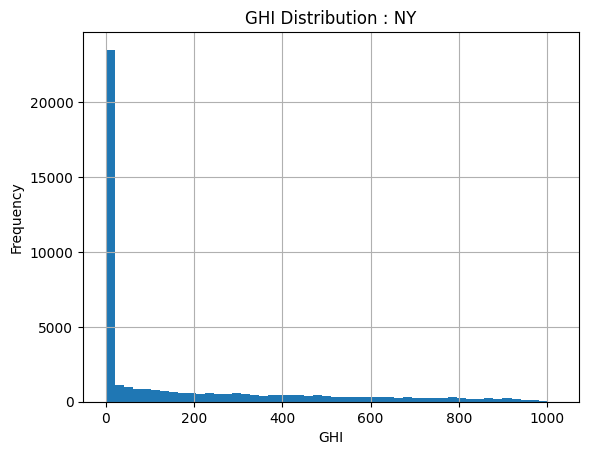

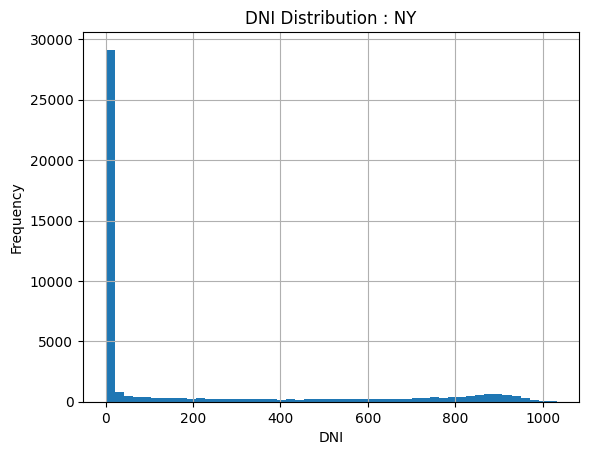

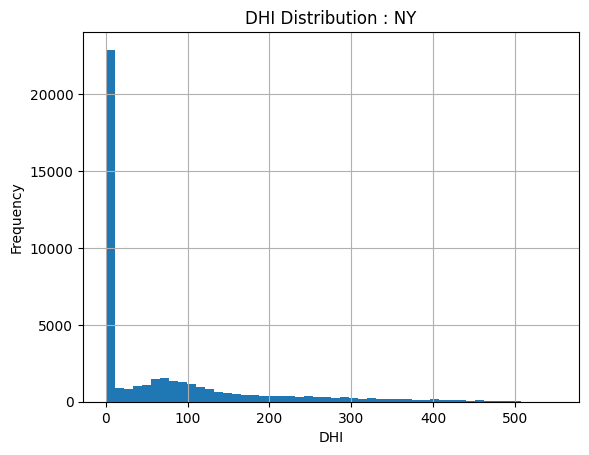

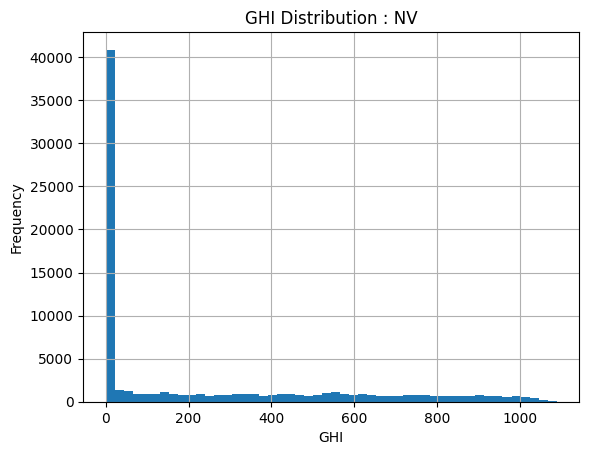

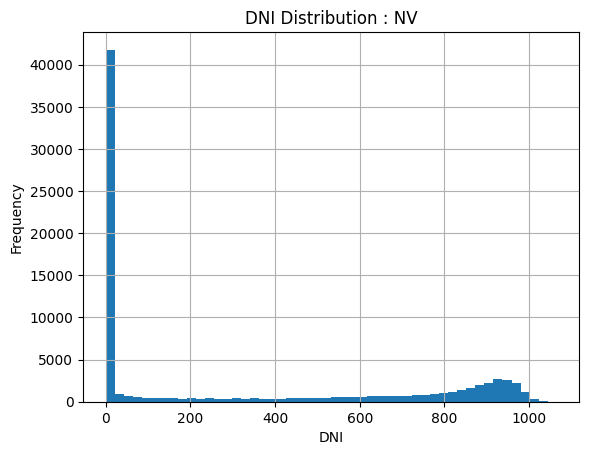

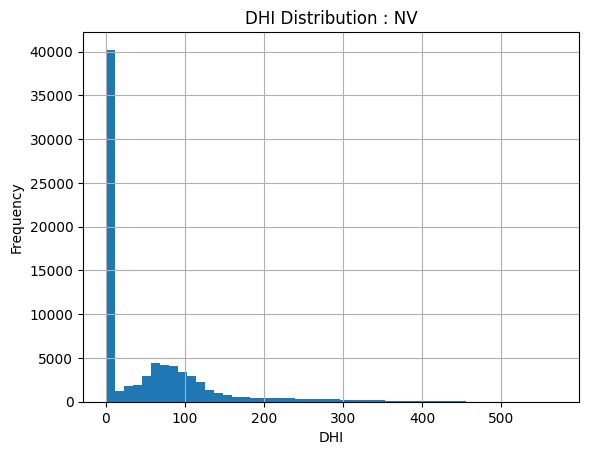

In [ ]:
# ============================================================
# Phase 5.2 : Irradiance Distributions
# ============================================================

def plot_irradiance_distributions(df, name):
    plt.figure()
    df["ghi"].hist(bins=50)
    plt.title(f"GHI Distribution : {name}")
    plt.xlabel("GHI")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure()
    df["dni"].hist(bins=50)
    plt.title(f"DNI Distribution : {name}")
    plt.xlabel("DNI")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure()
    df["dhi"].hist(bins=50)
    plt.title(f"DHI Distribution : {name}")
    plt.xlabel("DHI")
    plt.ylabel("Frequency")
    plt.show()

plot_irradiance_distributions(weather_1226_clean, "NY")
plot_irradiance_distributions(weather_1423_clean, "NV")

### Phase 5 : Irradiance Distribution Insights

#### GHI Distribution : NY
- Strong spike at 0 confirms expected nighttime behavior (no solar irradiance)
- Broad spread of daytime values indicates high variability due to cloud cover
- Majority of nonzero values are relatively low–moderate → suggests frequent partial cloudiness
- Long right tail up to ~1000 W/m² confirms presence of clear-sky conditions, but less consistently than NV

---

#### DNI Distribution : NY
- Large mass at 0 indicates frequent cloud obstruction (blocking direct sunlight)
- Wide spread across low–moderate values reflects intermittent cloud cover
- Smaller concentration at high values (~800–1000) shows occasional clear-sky periods
- Overall pattern confirms NY as a **cloud-variable solar environment**

---

#### DHI Distribution : NY
- Peak in mid-range (~50–120) reflects significant diffuse radiation from clouds
- Broader spread compared to NV indicates more variability in atmospheric conditions
- Higher diffuse component reinforces presence of cloud-driven scattering
- Confirms that NY solar generation is influenced heavily by **indirect irradiance**

---

#### GHI Distribution : NV
- Dominant spike at 0 again reflects nighttime behavior (expected)
- Much more uniform spread across high irradiance values (400–1000 W/m²)
- Higher concentration of large values compared to NY indicates strong, consistent sunlight
- Suggests a **highly stable solar resource environment**

---

#### DNI Distribution : NV
- Strong concentration at high values (~800–1000 W/m²) indicates frequent clear skies
- Much tighter and higher distribution than NY → minimal cloud interference
- Lower spread in mid-range values reinforces consistent direct solar exposure
- Confirms DNI as a **critical predictive feature in clear-sky regions**

---

#### DHI Distribution : NV
- Narrower distribution concentrated around lower–moderate values (~50–100)
- Less spread than NY indicates reduced atmospheric scattering (fewer clouds)
- Lower diffuse component aligns with dominance of direct irradiance (DNI)
- Supports characterization of NV as a **clear-sky, low-variability environment**

---

### Cross-Site Insights
- Both sites show zero-inflated distributions due to nighttime (physically expected)
- NV consistently exhibits:
  - higher irradiance values
  - tighter, more stable distributions
- NY exhibits:
  - greater spread and variability
  - stronger diffuse radiation component (cloud effects)
- These differences justify:
  - inclusion of all irradiance features (GHI, DNI, DHI)
  - cross-site robustness analysis in modeling

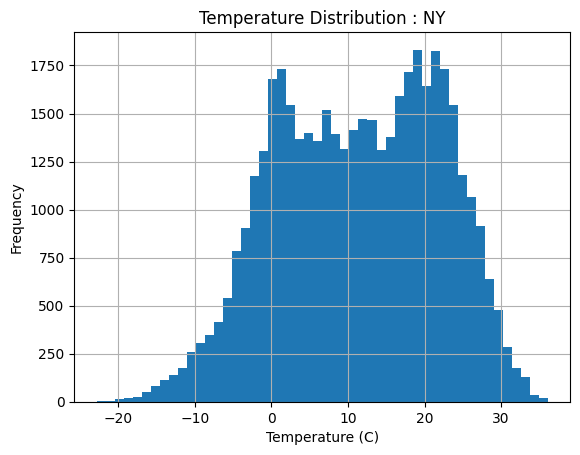

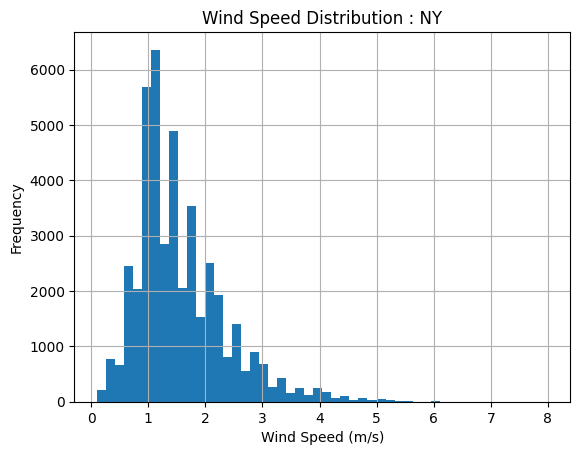

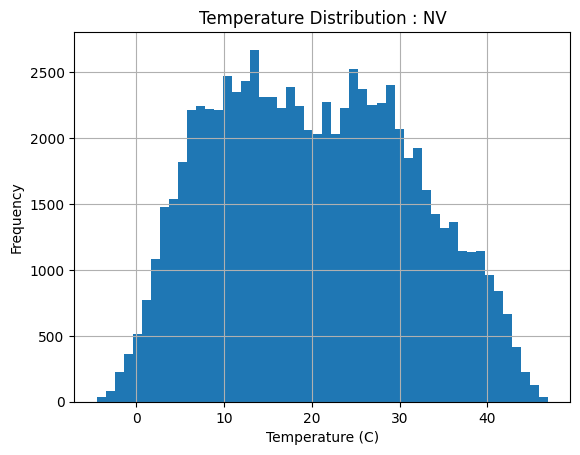

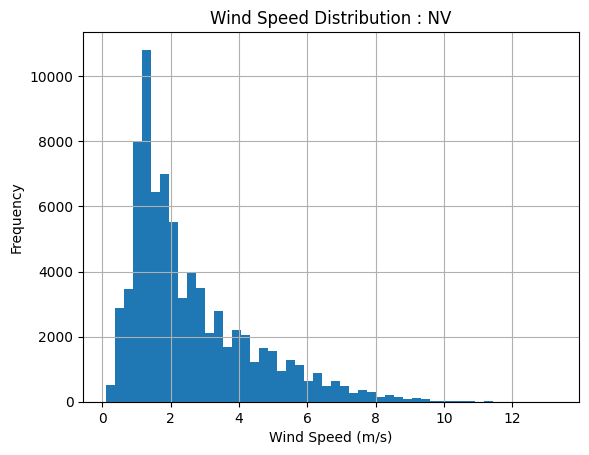

In [ ]:
# ============================================================
# Phase 5.2 : Temperature and Wind Distributions
# ============================================================

def plot_weather_distributions(df, name):
    plt.figure()
    df["temperature_c"].hist(bins=50)
    plt.title(f"Temperature Distribution : {name}")
    plt.xlabel("Temperature (C)")
    plt.ylabel("Frequency")
    plt.show()

    plt.figure()
    df["wind_speed_mps"].hist(bins=50)
    plt.title(f"Wind Speed Distribution : {name}")
    plt.xlabel("Wind Speed (m/s)")
    plt.ylabel("Frequency")
    plt.show()

plot_weather_distributions(weather_1226_clean, "NY")
plot_weather_distributions(weather_1423_clean, "NV")

### Phase 5 : Weather Feature Distribution Insights

#### Temperature Distribution : NY
- Broad, roughly bell-shaped distribution spanning ~-20°C to ~35°C
- Slight bimodality suggests clear seasonal separation (winter vs summer)
- Dense concentration between ~0°C and ~25°C reflects typical temperate climate
- Presence of extreme cold values (< -10°C) confirms realistic winter conditions
- Overall variability indicates strong seasonal influence on solar generation

---

#### Wind Speed Distribution : NY
- Right-skewed distribution with most values between ~1–3 m/s
- Long tail extending to ~7–8 m/s indicates occasional higher wind events
- Concentration at low speeds reflects generally mild wind conditions
- Smooth decay suggests no abnormal spikes or measurement issues
- Wind likely plays a secondary role compared to irradiance but still contributes to variability

---

#### Temperature Distribution : NV
- Wider range (~0°C to ~45°C) compared to NY, reflecting desert climate
- Distribution shifted toward higher temperatures (centered ~15–30°C)
- Less pronounced bimodality → more consistent warmth year-round
- Higher frequency of extreme heat (>35°C) confirms strong solar exposure environment
- Indicates temperature may impact panel efficiency more significantly than in NY

---

#### Wind Speed Distribution : NV
- Right-skewed distribution similar to NY but with a heavier tail
- Wider spread (up to ~12 m/s) indicates more frequent high-wind conditions
- Majority of values still concentrated between ~1–4 m/s
- Greater variability compared to NY suggests more dynamic atmospheric conditions
- Higher wind speeds may influence panel cooling and thus generation efficiency

---

### Cross-Site Insights
- NV exhibits:
  - higher temperatures and broader thermal range
  - slightly stronger and more variable wind patterns
- NY exhibits:
  - more seasonal temperature variability (clear winter/summer split)
  - generally milder wind conditions
- Both sites show realistic, smooth distributions with no anomalies or data quality concerns
- These patterns reinforce:
  - temperature as a secondary but meaningful feature (especially for NV)
  - wind speed as a minor but potentially interacting feature
- Together with irradiance, these variables form a physically grounded feature set for solar forecasting

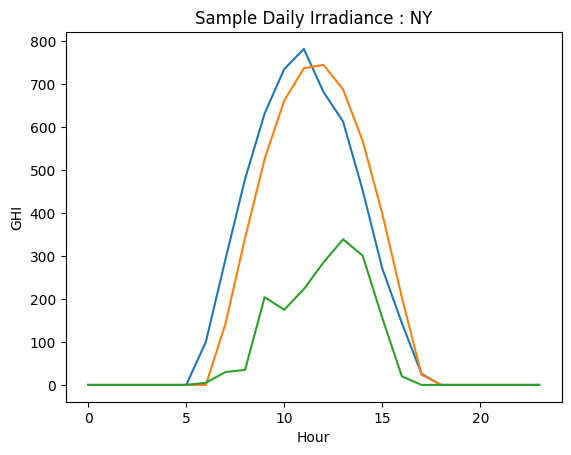

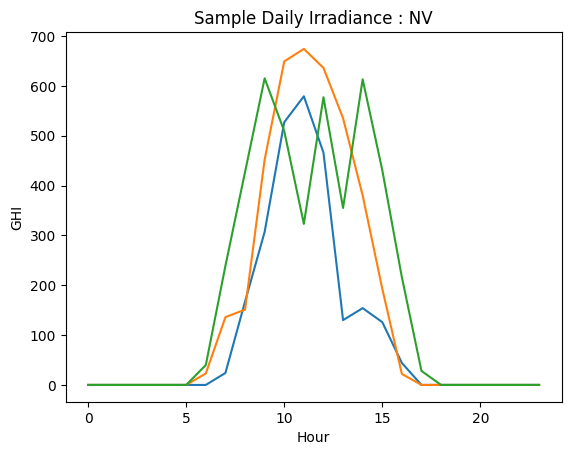

In [ ]:
# ============================================================
# Phase 5.3 : Sample Daily Irradiance Curves
# ============================================================

def plot_weather_days(df, name, n_days=3):
    valid_days = (
        df.groupby(df["timestamp"].dt.date)
        .filter(lambda x: x["ghi"].notna().sum() > 20)
    )

    sampled_days = (
        pd.Series(valid_days["timestamp"].dt.date)
        .drop_duplicates()
        .sample(n_days, random_state=42)
    )

    plt.figure()

    for day in sampled_days:
        day_data = valid_days[valid_days["timestamp"].dt.date == day]
        plt.plot(day_data["timestamp"].dt.hour, day_data["ghi"])

    plt.title(f"Sample Daily Irradiance : {name}")
    plt.xlabel("Hour")
    plt.ylabel("GHI")
    plt.show()

plot_weather_days(weather_1226_clean, "NY")
plot_weather_days(weather_1423_clean, "NV")

### Phase 5 : Sample Daily Irradiance Curve Insights

**Note:**  
Each curve (blue, orange, green) represents a **different randomly selected valid day** from the dataset. These illustrate how irradiance varies across individual days.

---

#### Sample Daily Irradiance : NY

- All curves follow a clear **solar bell shape**:
  - near-zero irradiance overnight
  - gradual increase after sunrise
  - peak around midday (~11–13)
  - decline toward sunset
- Blue and orange curves:
  - smooth, symmetric shapes → represent **clear or mostly clear days**
  - peak values ~700–800 W/m² → typical for NY
- Green curve:
  - noticeably lower and irregular → indicates **cloudy or partially obstructed day**
  - dips and uneven shape reflect **intermittent cloud cover**
- Greater variation between curves compared to NV:
  - demonstrates **high day-to-day variability**
  - confirms NY as a **cloud-driven, less predictable solar environment**

---

#### Sample Daily Irradiance : NV

- All curves exhibit strong **solar day structure**, but with key differences:
  - generally higher and more sustained irradiance than NY
- Orange curve:
  - smooth, high peak (~650–700 W/m²) → **clear-sky day**
- Green curve:
  - high but more jagged → suggests **minor variability or transient clouds**
- Blue curve:
  - irregular and lower midday dip → indicates **temporary obstruction or anomaly**
- Compared to NY:
  - higher overall irradiance levels
  - more frequent strong peaks
  - but still occasional variability present
- NV shows **generally stable but not perfectly uniform conditions**

---

### Cross-Site Insights

- Both sites:
  - correctly exhibit **diurnal solar patterns**
  - validate proper timestamp alignment and irradiance processing
- NY:
  - smoother vs disrupted days show strong **cloud influence**
  - higher variability across days
- NV:
  - more consistently high irradiance
  - occasional irregularities still present (real-world variability)
- Differences between curves (blue/orange/green) directly represent:
  - **clear vs cloudy vs partially cloudy conditions**
- These patterns confirm:
  - irradiance is the **primary driver of solar output**
  - variability in irradiance translates directly to variability in PV generation

---

### Why this matters for modeling

- Confirms need for:
  - irradiance features (GHI, DNI, DHI)
  - temporal features (hour of day)
- Demonstrates:
  - inherent unpredictability in cloudy environments (NY)
  - more learnable patterns in stable environments (NV)
- Validates:
  - the modeling problem is both **physically grounded and non-trivial**

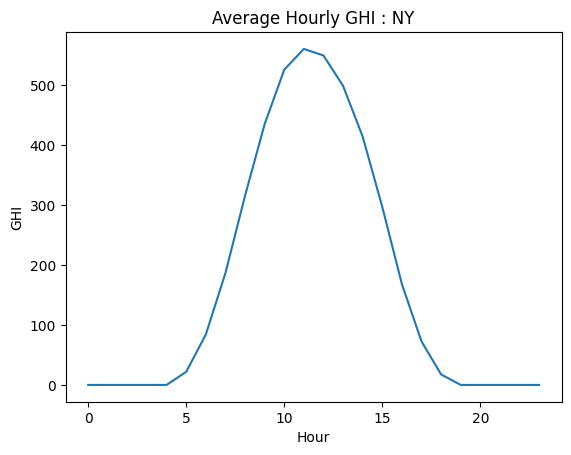

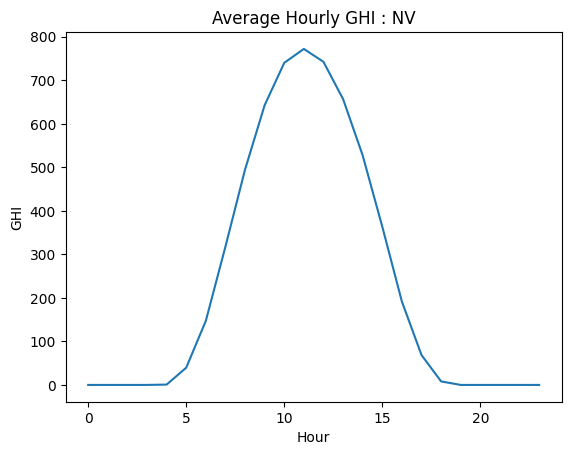

In [ ]:
# ============================================================
# Phase 5.3 : Average Hourly Irradiance Profile
# ============================================================

def avg_hourly_irradiance(df, name):
    temp = df.copy()
    temp["hour"] = temp["timestamp"].dt.hour

    hourly = temp.groupby("hour")["ghi"].mean()

    plt.figure()
    plt.plot(hourly.index, hourly.values)
    plt.title(f"Average Hourly GHI : {name}")
    plt.xlabel("Hour")
    plt.ylabel("GHI")
    plt.show()

avg_hourly_irradiance(weather_1226_clean, "NY")
avg_hourly_irradiance(weather_1423_clean, "NV")

### Phase 5 : Average Hourly Irradiance Profile Insights

#### Average Hourly GHI : NY
- Clear, smooth bell-shaped curve reflecting the **typical daily solar cycle**
- Irradiance begins increasing around ~5–6 AM, peaks near ~11–13, and declines to zero by ~18–19
- Peak GHI around ~550–580 W/m², noticeably lower than NV
- Slightly broader peak indicates **diffused and variable sunlight conditions**
- Lower overall curve height reflects:
  - more cloud cover
  - weaker and less consistent solar resource
- Smoothness of the curve (despite daily variability) shows strong **averaged temporal structure**

---

#### Average Hourly GHI : NV
- Very clean, symmetric bell-shaped curve representing a **highly stable solar cycle**
- Earlier and sharper rise in irradiance compared to NY
- Peak GHI around ~750–780 W/m², significantly higher than NY
- Narrower, more pronounced peak indicates **strong, direct sunlight with minimal scattering**
- Faster rise and fall suggests clearer atmospheric conditions (less diffusion)
- Overall higher curve reflects:
  - stronger solar intensity
  - more consistent clear-sky conditions

---

### Cross-Site Insights

- Both sites exhibit:
  - physically correct diurnal solar patterns
  - zero irradiance at night and peak at midday
- NV consistently shows:
  - higher peak irradiance
  - sharper, more concentrated solar window
- NY shows:
  - lower peak values
  - broader, flatter peak due to cloud diffusion
- These profiles confirm:
  - **hour of day is a critical predictive feature**
  - irradiance follows a strong, learnable temporal structure
- Averaging smooths out daily variability, revealing:
  - the underlying deterministic solar pattern
  - differences in atmospheric clarity between locations

---

### Why this matters for modeling

- Validates inclusion of:
  - time-based features (hour of day, cyclic encoding)
  - irradiance as the primary driver of PV output
- Confirms:
  - models can learn strong daily patterns
  - deviations from this curve (clouds) are the key source of prediction difficulty
- Reinforces:
  - NV will be easier to model (stable pattern)
  - NY will require stronger reliance on weather features to capture variability

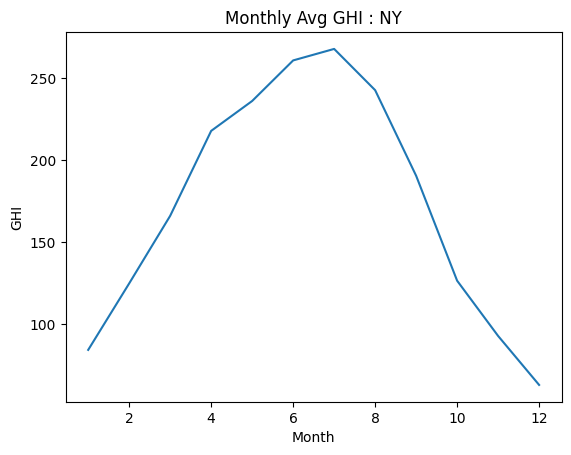

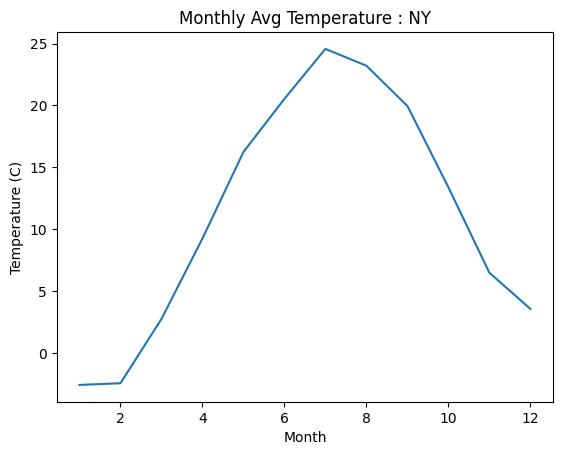

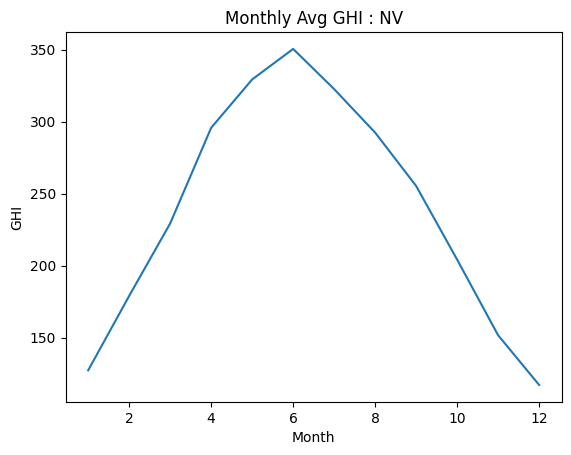

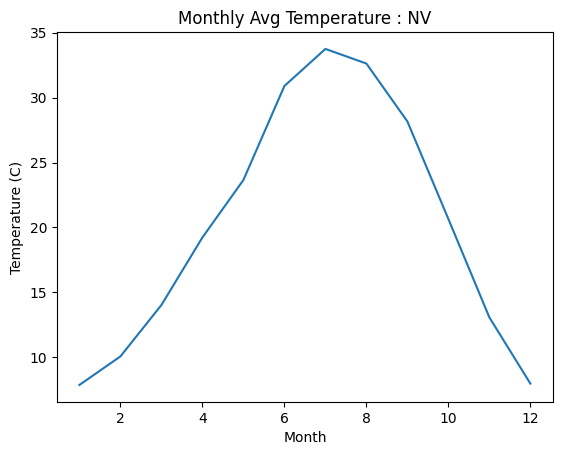

In [ ]:
# ============================================================
# Phase 5.3 : Seasonal Irradiance + Temperature
# ============================================================

def seasonal_patterns(df, name):
    temp = df.copy()
    temp["month"] = temp["timestamp"].dt.month

    ghi_monthly = temp.groupby("month")["ghi"].mean()
    temp_monthly = temp.groupby("month")["temperature_c"].mean()

    plt.figure()
    plt.plot(ghi_monthly.index, ghi_monthly.values)
    plt.title(f"Monthly Avg GHI : {name}")
    plt.xlabel("Month")
    plt.ylabel("GHI")
    plt.show()

    plt.figure()
    plt.plot(temp_monthly.index, temp_monthly.values)
    plt.title(f"Monthly Avg Temperature : {name}")
    plt.xlabel("Month")
    plt.ylabel("Temperature (C)")
    plt.show()

seasonal_patterns(weather_1226_clean, "NY")
seasonal_patterns(weather_1423_clean, "NV")

### Phase 5 : Monthly / Seasonal Weather Insights

#### Monthly Avg GHI : NY
- Clear seasonal trend: low irradiance in winter, peak in summer
- Gradual increase from ~January → June/July, then symmetric decline
- Peak GHI around ~260–270 W/m² in summer months
- Sharp drop from September → December reflects:
  - shorter daylight hours
  - lower sun angle
- Moderate amplitude compared to NV indicates:
  - weaker solar intensity
  - more atmospheric variability (clouds)
- Confirms strong **seasonality in solar resource**

---

#### Monthly Avg Temperature : NY
- Strong seasonal variation from ~-3°C (winter) to ~24–25°C (summer)
- Smooth, nearly symmetric yearly temperature cycle
- Rapid warming from March → June and cooling from September → December
- Wide temperature range indicates:
  - strong seasonal climate shifts
  - potential impact on solar panel efficiency
- Reinforces NY as a **highly seasonal environment**

---

#### Monthly Avg GHI : NV
- Strong seasonal pattern similar to NY but with consistently higher values
- Peak around ~350 W/m² in summer (significantly higher than NY)
- Faster rise from winter to spring → more intense solar gain
- Less steep decline into fall compared to NY
- Higher baseline even in winter months
- Indicates:
  - stronger and more consistent solar resource
  - less cloud interference throughout the year

---

#### Monthly Avg Temperature : NV
- Higher overall temperature range (~8°C to ~34°C)
- Peak temperatures significantly exceed NY summer levels
- Warmer winters compared to NY
- Smooth seasonal pattern but shifted upward
- Indicates:
  - consistently warmer climate
  - potential for **thermal efficiency losses in PV systems**
- Less extreme seasonal contrast than NY, but still clearly structured

---

### Cross-Site Insights

- Both sites show strong **seasonality in irradiance and temperature**
- NV consistently exhibits:
  - higher GHI across all months
  - higher temperatures year-round
- NY exhibits:
  - larger relative seasonal swings (especially temperature)
  - lower overall irradiance due to cloud effects
- GHI and temperature trends are aligned:
  - higher irradiance coincides with higher temperatures (summer)
- These patterns confirm:
  - **month/season is a critical feature for forecasting**
  - strong long-term temporal structure exists in the data

---

### Why this matters for modeling

- Justifies inclusion of:
  - seasonal features (month, day-of-year, cyclical encodings)
- Confirms:
  - solar generation is strongly season-dependent
  - models must capture both:
    - daily cycles (hour)
    - yearly cycles (season)
- Highlights:
  - NV = more stable, higher baseline → easier to model
  - NY = more variable → greater reliance on weather features
- Reinforces that:
  - irradiance + temporal features together form the core predictive signal

### Phase 5 Conclusion : NSRDB Weather EDA

The NSRDB weather data is complete, physically realistic, and exhibits strong, interpretable structure across both sites. Irradiance distributions confirm expected zero-inflation from nighttime and clear separation between direct (DNI), diffuse (DHI), and total (GHI) radiation, validating these as core predictive features.

Temporal analysis reveals:
- **Strong diurnal patterns**: consistent bell-shaped irradiance curves driven by solar cycles
- **Clear seasonal structure**: higher irradiance and temperature in summer, lower in winter
- **Geographic contrast**:
  - **NV**: higher, more stable irradiance → clear-sky dominant environment
  - **NY**: lower, more variable irradiance → cloud-driven variability

Daily curve variability shows that short-term fluctuations (especially in NY) are driven by weather conditions, reinforcing the importance of including full irradiance and meteorological features.

Overall, this phase confirms:
- irradiance (GHI, DNI, DHI) is the **primary driver of solar output**
- temporal features (hour, season) are **highly predictive**
- weather variability is the key source of forecasting difficulty

The weather dataset provides a **clean, information-rich feature set** that is well-aligned with the physics of solar generation and ready for integration with PV data in the next phase.

## Phase 6 : Acquire and Build One Clean Hourly Carbon Table Per Site

Goals:
- Retrieve hourly carbon intensity data for each selected site
- Map each site to the correct Electricity Maps zone
- Acquire historical carbon intensity over the desired overlap periods
- Cache raw API responses for reproducibility
- Pause after acquisition so the raw response structure can be inspected before building final clean hourly carbon tables

Carbon metric:
- `carbon_intensity` in `gCO2/kWh`

Selected Electricity Maps zones:
- Site 1226 (Port Chester, NY) → `US-NY-NYIS`
- Site 1423 (Henderson, NV) → `US-NW-NEVP`

Implementation note:
- Electricity Maps historical range requests at hourly granularity are limited to 10-day windows, so acquisition must be chunked and looped.

In [ ]:
# ===================================
# Phase 6.0 : Imports and path setup
# ===================================

import json
import math
import time
from pathlib import Path

import pandas as pd
import requests

ELECTRICITYMAPS_RAW_ROOT = RAW_DATA_ROOT / "electricitymaps"
ELECTRICITYMAPS_INTERIM_ROOT = INTERIM_ROOT / "electricitymaps"

ELECTRICITYMAPS_RAW_ROOT.mkdir(parents=True, exist_ok=True)
ELECTRICITYMAPS_INTERIM_ROOT.mkdir(parents=True, exist_ok=True)

print("Electricity Maps raw root:", ELECTRICITYMAPS_RAW_ROOT)
print("Electricity Maps interim root:", ELECTRICITYMAPS_INTERIM_ROOT)

Electricity Maps raw root: /content/drive/MyDrive/projs_ai_final_project/raw_data/electricitymaps
Electricity Maps interim root: /content/drive/MyDrive/projs_ai_final_project/interim_data/electricitymaps


In [ ]:
# ============================================================
# Phase 6.1 : API configuration
# ============================================================

API_KEY = "vVHdngvhEnmEwm2gX3RP"

BASE_URL = "https://api.electricitymap.org/v4"

# zone mapping
ELECTRICITYMAPS_ZONES = {
    1226: "US-NY-NYIS",   # Port Chester, NY
    1423: "US-NW-NEVP",   # Henderson, NV
}

print(ELECTRICITYMAPS_ZONES)

{1226: 'US-NY-NYIS', 1423: 'US-NW-NEVP'}


### Acquisition windows

We define the target acquisition windows here.

Because this phase is only about acquiring and caching raw carbon data, we set windows explicitly and can revise them later if needed after inspecting availability and overlap quality.

Recommended windows for this project:
- Site 1226 (NY): aligned to PV period
- Site 1423 (NV): aligned to recent years used in the project plan and supported overlap

In [ ]:
# ========================================================================================
# Phase 6.2 : carbon acquisition windows based on actual Electricity Maps historical availability
# ========================================================================================

CARBON_WINDOWS = {
    1226: {
        "site_name": "Port Chester, NY",
        "zone": ELECTRICITYMAPS_ZONES[1226],
        "start": pd.Timestamp("2017-01-01 00:00:00"),
        "end": pd.Timestamp("2024-01-01 00:00:00"),  # exclusive end
    },
    1423: {
        "site_name": "Henderson, NV",
        "zone": ELECTRICITYMAPS_ZONES[1423],
        "start": pd.Timestamp("2017-01-01 00:00:00"),
        "end": pd.Timestamp("2024-01-01 00:00:00"),  # exclusive end
    },
}

for site_id, cfg in CARBON_WINDOWS.items():
    print(site_id, cfg)

1226 {'site_name': 'Port Chester, NY', 'zone': 'US-NY-NYIS', 'start': Timestamp('2017-01-01 00:00:00'), 'end': Timestamp('2024-01-01 00:00:00')}
1423 {'site_name': 'Henderson, NV', 'zone': 'US-NW-NEVP', 'start': Timestamp('2017-01-01 00:00:00'), 'end': Timestamp('2024-01-01 00:00:00')}


In [ ]:
# ============================================================
# Phase 6.3 : Helper to call Electricity Maps API
# ============================================================

def call_electricitymaps(endpoint, params=None, timeout=60):
    """
    Send a GET request to the Electricity Maps API and return the parsed JSON.

    Parameters
    ----------
    endpoint : str
        API endpoint path beginning with "/"
    params : dict or None
        Query parameters
    timeout : int
        Request timeout in seconds

    Returns
    -------
    dict
        Parsed JSON response
    """
    if params is None:
        params = {}

    headers = {
        "auth-token": API_KEY
    }

    url = BASE_URL + endpoint
    response = requests.get(url, headers=headers, params=params, timeout=timeout)

    if response.status_code != 200:
        print("Request failed.")
        print("URL:", url)
        print("Params:", params)
        print("Status code:", response.status_code)
        print("Response text:", response.text[:1000])
        response.raise_for_status()

    return response.json()

In [ ]:
# ============================================================
# Phase 6.4 : Preflight: check token zone access
# ============================================================

def get_accessible_zones():
    """
    Purpose:
        Query the Electricity Maps API to see which zones are accessible
        with the current API token.

    Outputs:
        zones_payload: API response containing available zones

    Overview:
        Calls the /zones endpoint to retrieve all zones the token can access.
        Used as a preflight check before requesting carbon data.
    """
    # call API endpoint that lists all available zones
    return call_electricitymaps("/zones")


# fetch zones accessible with current API token
zones_payload = get_accessible_zones()

# basic confirmation that the request worked
print("Retrieved /zones successfully.")
print("Top-level type:", type(zones_payload))


# check whether each site's target zone is available
for site_id, cfg in CARBON_WINDOWS.items():
    zone = cfg["zone"]

    # verify that this zone exists in the API response
    print(f"{cfg['site_name']} | target zone {zone} present? {zone in zones_payload}")

Retrieved /zones successfully.
Top-level type: <class 'dict'>
Port Chester, NY | target zone US-NY-NYIS present? False
Henderson, NV | target zone US-NW-NEVP present? False


### Chunking strategy

Electricity Maps hourly past-range carbon intensity requests are limited to 10-day windows, so we split each site's total requested period into consecutive 10-day chunks and fetch them one by one.

Each raw response is saved to Drive as JSON for reproducibility and later inspection.

In [ ]:
# ============================================================
# Phase 6.5 : Build 10-day chunk windows
# ============================================================

def generate_time_chunks(start_ts, end_ts, chunk_days=10):
    """
    Split a full time range into smaller chunks so API requests stay within size limits.
    """
    # ensure inputs are timestamps so datetime math works reliably
    start_ts = pd.Timestamp(start_ts)
    end_ts = pd.Timestamp(end_ts)

    chunks = []
    current = start_ts  # start building chunks from the beginning of the window

    # keep creating chunks until we cover the full time range
    # this avoids requesting too much data at once from the API
    while current < end_ts:

        # compute the next chunk end, capped at the overall end so we don't overshoot
        next_end = min(current + pd.Timedelta(days=chunk_days), end_ts)

        # store as [start, end) so chunks don't overlap and create duplicate timestamps later
        chunks.append((current, next_end))

        # move forward to the next chunk so we cover the entire time window without gaps
        current = next_end

    return chunks

for site_id, cfg in CARBON_WINDOWS.items():
    chunks = generate_time_chunks(cfg["start"], cfg["end"], chunk_days=10)
    print(site_id, cfg["site_name"], "| chunks:", len(chunks), "| first:", chunks[0], "| last:", chunks[-1])

1226 Port Chester, NY | chunks: 256 | first: (Timestamp('2017-01-01 00:00:00'), Timestamp('2017-01-11 00:00:00')) | last: (Timestamp('2023-12-26 00:00:00'), Timestamp('2024-01-01 00:00:00'))
1423 Henderson, NV | chunks: 256 | first: (Timestamp('2017-01-01 00:00:00'), Timestamp('2017-01-11 00:00:00')) | last: (Timestamp('2023-12-26 00:00:00'), Timestamp('2024-01-01 00:00:00'))


In [ ]:
# ============================================================
# Phase 6.6 : Create per-site raw output folders
# ============================================================

CARBON_SITE_DIRS = {}

for site_id, cfg in CARBON_WINDOWS.items():
    # build a dedicated folder for each site so raw carbon data stays organized and traceable
    site_dir = ELECTRICITYMAPS_RAW_ROOT / f"site_{site_id}"

    # keep raw API responses in a separate subfolder so they are not mixed with processed data
    raw_json_dir = site_dir / "raw_json"

    # create folders if they do not exist so reruns do not fail or overwrite structure
    raw_json_dir.mkdir(parents=True, exist_ok=True)

    # store paths in a lookup dict so later steps can easily find where to read/write data
    CARBON_SITE_DIRS[site_id] = {
        "site_dir": site_dir,
        "raw_json_dir": raw_json_dir,
    }

    # print to confirm correct directory structure before writing any files
    print(site_id, CARBON_SITE_DIRS[site_id])

1226 {'site_dir': PosixPath('/content/drive/MyDrive/projs_ai_final_project/raw_data/electricitymaps/site_1226'), 'raw_json_dir': PosixPath('/content/drive/MyDrive/projs_ai_final_project/raw_data/electricitymaps/site_1226/raw_json')}
1423 {'site_dir': PosixPath('/content/drive/MyDrive/projs_ai_final_project/raw_data/electricitymaps/site_1423'), 'raw_json_dir': PosixPath('/content/drive/MyDrive/projs_ai_final_project/raw_data/electricitymaps/site_1423/raw_json')}


In [ ]:
# ============================================================
# Phase 6.7 : Probe one chunk per site before full acquisition
# designed so won't crash on one failed zone/interval
# ============================================================

def fetch_carbon_chunk(
    zone,
    start_ts,
    end_ts,
    emission_factor_type="direct",
    temporal_granularity="hourly",
    disable_estimations=False
):
    """
    Purpose:
        Fetch one historical carbon intensity chunk from Electricity Maps.

    Inputs:
        zone: Electricity Maps grid zone
        start_ts: chunk start timestamp
        end_ts: chunk end timestamp
        emission_factor_type: carbon accounting type
        temporal_granularity: requested time resolution
        disable_estimations: whether to exclude estimated values

    Outputs:
        payload: API response for the requested chunk
        params: request parameters used for the API call

    Overview:
        Builds the API request parameters for one time chunk and calls the
        Electricity Maps past-range endpoint.
    """

    # build one API request for a small chunk so we can avoid oversized historical queries
    params = {
        "zone": zone,
        "start": pd.Timestamp(start_ts).isoformat(),
        "end": pd.Timestamp(end_ts).isoformat(),
        "emissionFactorType": emission_factor_type,
        "temporalGranularity": temporal_granularity,
        "disableEstimations": str(disable_estimations).lower(),
    }

    # request historical carbon intensity for this zone and time window
    payload = call_electricitymaps("/carbon-intensity/past-range", params=params)

    # return params with payload so failed or successful requests can be audited later
    return payload, params


probe_results = {}

for site_id, cfg in CARBON_WINDOWS.items():
    # test only the first chunk before attempting the full multi-year download
    first_chunk = generate_time_chunks(cfg["start"], cfg["end"], chunk_days=10)[0]

    print("=" * 90)
    print(f"PROBING: {cfg['site_name']}")
    print("=" * 90)

    try:
        # make one small request to confirm the zone, token, and endpoint work
        payload, params = fetch_carbon_chunk(cfg["zone"], first_chunk[0], first_chunk[1])

        # save successful probe output so the exact request and response can be inspected
        probe_results[site_id] = {
            "status": "success",
            "params": params,
            "payload": payload,
            "error": None,
        }

        print("Request params:")
        print(params)

        # inspect response structure before writing parser logic
        print("\nTop-level payload type:", type(payload))
        if isinstance(payload, dict):
            print("Top-level keys:", list(payload.keys())[:20])
        elif isinstance(payload, list):
            print("List length:", len(payload))

    except Exception as e:
        # store failed probes instead of crashing so one bad site does not stop all checks
        probe_results[site_id] = {
            "status": "failed",
            "params": {
                "zone": cfg["zone"],
                "start": pd.Timestamp(first_chunk[0]).isoformat(),
                "end": pd.Timestamp(first_chunk[1]).isoformat(),
            },
            "payload": None,
            "error": str(e),
        }

        # print enough context to debug zone access, time window, or API issues
        print("Probe failed.")
        print("Zone:", cfg["zone"])
        print("Window:", first_chunk[0], "to", first_chunk[1])
        print("Error:", e)

PROBING: Port Chester, NY
Request params:
{'zone': 'US-NY-NYIS', 'start': '2017-01-01T00:00:00', 'end': '2017-01-11T00:00:00', 'emissionFactorType': 'direct', 'temporalGranularity': 'hourly', 'disableEstimations': 'false'}

Top-level payload type: <class 'dict'>
Top-level keys: ['zone', 'data', 'temporalGranularity', '_disclaimer']
PROBING: Henderson, NV
Request params:
{'zone': 'US-NW-NEVP', 'start': '2017-01-01T00:00:00', 'end': '2017-01-11T00:00:00', 'emissionFactorType': 'direct', 'temporalGranularity': 'hourly', 'disableEstimations': 'false'}

Top-level payload type: <class 'dict'>
Top-level keys: ['zone', 'data', 'temporalGranularity', '_disclaimer']


In [ ]:
# ============================================================
# Phase 6.7b : Test recent windows explicitly
# ============================================================

# use a recent known window to separate API access issues from older historical availability issues
RECENT_TEST_WINDOWS = {
    1226: ("2023-01-01 00:00:00", "2023-01-10 00:00:00"),
    1423: ("2023-01-01 00:00:00", "2023-01-10 00:00:00"),
}

recent_probe_results = {}

for site_id, (start_ts, end_ts) in RECENT_TEST_WINDOWS.items():
    # use the same site-to-zone mapping as the full carbon acquisition pipeline
    zone = ELECTRICITYMAPS_ZONES[site_id]
    site_name = CARBON_WINDOWS[site_id]["site_name"]

    print("=" * 90)
    print(f"RECENT PROBE: {site_name}")
    print("=" * 90)

    try:
        # test one recent chunk before downloading the full historical range
        payload, params = fetch_carbon_chunk(zone, start_ts, end_ts)

        # save successful response details so the request can be checked later
        recent_probe_results[site_id] = {
            "status": "success",
            "params": params,
            "payload": payload,
            "error": None,
        }

        print("Success")
        print(params)

        # inspect response shape so later parsing matches the actual API payload
        if isinstance(payload, dict):
            print("Top-level keys:", list(payload.keys())[:20])
        elif isinstance(payload, list):
            print("List length:", len(payload))

    except Exception as e:
        # keep failure details without stopping the notebook, since one zone may fail independently
        recent_probe_results[site_id] = {
            "status": "failed",
            "params": {"zone": zone, "start": start_ts, "end": end_ts},
            "payload": None,
            "error": str(e),
        }

        print("Failed")
        print("Error:", e)

RECENT PROBE: Port Chester, NY
Success
{'zone': 'US-NY-NYIS', 'start': '2023-01-01T00:00:00', 'end': '2023-01-10T00:00:00', 'emissionFactorType': 'direct', 'temporalGranularity': 'hourly', 'disableEstimations': 'false'}
Top-level keys: ['zone', 'data', 'temporalGranularity', '_disclaimer']
RECENT PROBE: Henderson, NV
Success
{'zone': 'US-NW-NEVP', 'start': '2023-01-01T00:00:00', 'end': '2023-01-10T00:00:00', 'emissionFactorType': 'direct', 'temporalGranularity': 'hourly', 'disableEstimations': 'false'}
Top-level keys: ['zone', 'data', 'temporalGranularity', '_disclaimer']


In [ ]:
# ============================================================
# Phase 6.7c : Find earliest available recent year by probing backward
# ============================================================

def probe_window(zone, start_ts, end_ts):
    """
    Purpose:
        Test whether Electricity Maps returns carbon data for one zone and time window.

    Inputs:
        zone: Electricity Maps grid zone
        start_ts: start timestamp for test window
        end_ts: end timestamp for test window

    Outputs:
        Tuple of success flag, payload, and error message

    Overview:
        Tries one carbon API request and returns the result without crashing the notebook.
    """
    try:
        # make one small test request so failures stay easy to isolate
        payload, params = fetch_carbon_chunk(zone, start_ts, end_ts)
        return True, payload, None
    except Exception as e:
        # return the error instead of stopping the loop so other years can still be tested
        return False, None, str(e)


def find_first_available_year(zone, years_to_try):
    """
    Purpose:
        Probe candidate years to identify when carbon data is available for a zone.

    Inputs:
        zone: Electricity Maps grid zone
        years_to_try: iterable of years to test

    Outputs:
        DataFrame summarizing success/failure for each tested year

    Overview:
        Sends a short test request for each year and records whether the API has data.
        This helps choose a realistic historical acquisition window.
    """
    results = []

    for year in years_to_try:
        # test the same short January window each year so availability comparisons are consistent
        start_ts = f"{year}-01-01 00:00:00"
        end_ts = f"{year}-01-10 00:00:00"

        # probe one year at a time so we can see where historical availability begins to fail
        ok, payload, err = probe_window(zone, start_ts, end_ts)

        # store outcome for later review instead of relying only on printed output
        results.append({
            "year": year,
            "status": "success" if ok else "failed",
            "error": err,
        })

        # print immediate feedback so long probe loops are easier to monitor
        print(year, "->", "success" if ok else "failed")

    return pd.DataFrame(results)


# probe backward from recent years to estimate the earliest usable carbon-data year per zone
ny_year_probe = find_first_available_year("US-NY-NYIS", range(2023, 2010, -1))
nv_year_probe = find_first_available_year("US-NW-NEVP", range(2023, 2014, -1))

2023 -> success
2022 -> success
2021 -> success
2020 -> success
2019 -> success
2018 -> success
2017 -> success
Request failed.
URL: https://api.electricitymap.org/v4/carbon-intensity/past-range
Params: {'zone': 'US-NY-NYIS', 'start': '2016-01-01T00:00:00', 'end': '2016-01-10T00:00:00', 'emissionFactorType': 'direct', 'temporalGranularity': 'hourly', 'disableEstimations': 'false'}
Status code: 404
Response text: {"error":"No data for zone \"US-NY-NYIS\" in the given interval"}
2016 -> failed
Request failed.
URL: https://api.electricitymap.org/v4/carbon-intensity/past-range
Params: {'zone': 'US-NY-NYIS', 'start': '2015-01-01T00:00:00', 'end': '2015-01-10T00:00:00', 'emissionFactorType': 'direct', 'temporalGranularity': 'hourly', 'disableEstimations': 'false'}
Status code: 404
Response text: {"error":"No data for zone \"US-NY-NYIS\" in the given interval"}
2015 -> failed
Request failed.
URL: https://api.electricitymap.org/v4/carbon-intensity/past-range
Params: {'zone': 'US-NY-NYIS', 'sta

In [ ]:
# ============================================================
# Phase 6.8 : Save probe payloads for inspection
# ============================================================

# iterate through each site's probe results so we can persist raw API/debug payloads
for site_id, result in probe_results.items():
    # construct output path per site so files stay organized and reproducible
    out_path = CARBON_SITE_DIRS[site_id]["site_dir"] / f"probe_site_{site_id}.json"

    # write payload to disk for later inspection and debugging of carbon data retrieval
    with open(out_path, "w") as f:
        json.dump(result["payload"], f, indent=2)  # indent for readability when manually inspecting

    # log save location so we can trace artifacts during pipeline execution
    print("Saved probe payload:", out_path)

Saved probe payload: /content/drive/MyDrive/projs_ai_final_project/raw_data/electricitymaps/site_1226/probe_site_1226.json
Saved probe payload: /content/drive/MyDrive/projs_ai_final_project/raw_data/electricitymaps/site_1423/probe_site_1423.json


### Full raw acquisition

If the probe responses look healthy, run the next cell to fetch and cache all chunked raw responses.

Each chunk will be saved as its own JSON file, and a manifest table will record:
- site
- zone
- chunk start/end
- request status
- output file
- any error message

In [ ]:
# ============================================================
# Phase 6.9 : Full raw carbon acquisition
# ============================================================

def acquire_site_carbon_history(
    site_id,
    site_name,
    zone,
    start_ts,
    end_ts,
    raw_json_dir,
    chunk_days=10,
    emission_factor_type="direct",
    temporal_granularity="hourly",
    disable_estimations=False,
    sleep_seconds=0.2,
):
    """
    Fetch and cache chunked historical carbon intensity data for a single site.

    Inputs
    ------
    site_id : int/str
        Unique identifier for the site.
    site_name : str
        Human-readable site name for logging/traceability.
    zone : str
        Electricity Maps zone corresponding to the site location.
    start_ts : datetime
        Start timestamp for data acquisition.
    end_ts : datetime
        End timestamp for data acquisition.
    raw_json_dir : Path
        Directory where raw JSON responses will be stored.
    chunk_days : int
        Number of days per API request chunk to avoid large queries.
    emission_factor_type : str
        Type of carbon intensity to request (e.g., direct vs lifecycle).
    temporal_granularity : str
        Time resolution of the data (hourly aligns with forecasting task).
    disable_estimations : bool
        Whether to exclude estimated values from API.
    sleep_seconds : float
        Delay between API calls to avoid rate limits.

    Returns
    -------
    pd.DataFrame
        Manifest containing metadata for each chunk request including success/failure.

    Overview
    --------
    Splits the full time range into smaller chunks, fetches carbon data per chunk,
    saves raw responses to disk for reproducibility, and logs results in a manifest.
    """
    # break full time range into smaller chunks to avoid API limits and large payloads
    chunk_windows = generate_time_chunks(start_ts, end_ts, chunk_days=chunk_days)

    records = []  # track success/failure of each chunk for reproducibility/debugging

    for i, (chunk_start, chunk_end) in enumerate(chunk_windows):
        # structured filename encodes site, zone, chunk index, and time range for traceability
        file_name = (
            f"site_{site_id}"
            f"__zone_{zone}"
            f"__chunk_{i:04d}"
            f"__{chunk_start.strftime('%Y%m%dT%H%M%S')}"
            f"__{chunk_end.strftime('%Y%m%dT%H%M%S')}.json"
        )
        out_path = raw_json_dir / file_name

        try:
            # fetch carbon data for this chunk window
            payload, params = fetch_carbon_chunk(
                zone=zone,
                start_ts=chunk_start,
                end_ts=chunk_end,
                emission_factor_type=emission_factor_type,
                temporal_granularity=temporal_granularity,
                disable_estimations=disable_estimations,
            )

            # save raw API response to disk so pipeline is fully reproducible without re-calling API
            with open(out_path, "w") as f:
                json.dump(payload, f, indent=2)

            # log successful request with metadata for later auditing/debugging
            records.append({
                "site_id": site_id,
                "site_name": site_name,
                "zone": zone,
                "chunk_index": i,
                "chunk_start": chunk_start,
                "chunk_end": chunk_end,
                "status": "success",
                "output_file": str(out_path),
                "error": None,
            })

        except Exception as e:
            # capture failures instead of stopping entire pipeline so we can inspect gaps later
            records.append({
                "site_id": site_id,
                "site_name": site_name,
                "zone": zone,
                "chunk_index": i,
                "chunk_start": chunk_start,
                "chunk_end": chunk_end,
                "status": "failed",
                "output_file": None,
                "error": str(e),
            })

        # small delay to avoid hitting API rate limits and getting blocked
        time.sleep(sleep_seconds)

    # return manifest as dataframe so downstream steps can analyze coverage/completeness
    return pd.DataFrame(records)


carbon_manifests = []

# loop through each site configuration and run acquisition independently
for site_id, cfg in CARBON_WINDOWS.items():
    print("=" * 90)
    print(f"STARTING ACQUISITION: {cfg['site_name']} | {cfg['zone']}")
    print("=" * 90)

    # run chunked acquisition for this site
    manifest_df = acquire_site_carbon_history(
        site_id=site_id,
        site_name=cfg["site_name"],
        zone=cfg["zone"],
        start_ts=cfg["start"],
        end_ts=cfg["end"],
        raw_json_dir=CARBON_SITE_DIRS[site_id]["raw_json_dir"],
        chunk_days=10,  # chosen to balance API limits vs efficiency
        emission_factor_type="direct",  # direct emissions align with real-time grid impact
        temporal_granularity="hourly",  # match forecasting resolution
        disable_estimations=False,  # allow estimates to ensure continuity of time series
    )

    carbon_manifests.append(manifest_df)

# combine all site manifests into one table for global inspection and reporting
carbon_manifest = pd.concat(carbon_manifests, ignore_index=True)

print("Acquisition complete.")

# preview head/tail to quickly verify structure and detect obvious issues
display(carbon_manifest.head())
display(carbon_manifest.tail())

STARTING ACQUISITION: Port Chester, NY | US-NY-NYIS
STARTING ACQUISITION: Henderson, NV | US-NW-NEVP
Acquisition complete.


,site_id,site_name,zone,chunk_index,chunk_start,chunk_end,status,output_file,error
0,1226,"Port Chester, NY",US-NY-NYIS,0,2017-01-01,2017-01-11,success,/content/drive/MyDrive/projs_ai_final_project/...,None
1,1226,"Port Chester, NY",US-NY-NYIS,1,2017-01-11,2017-01-21,success,/content/drive/MyDrive/projs_ai_final_project/...,None
2,1226,"Port Chester, NY",US-NY-NYIS,2,2017-01-21,2017-01-31,success,/content/drive/MyDrive/projs_ai_final_project/...,None
3,1226,"Port Chester, NY",US-NY-NYIS,3,2017-01-31,2017-02-10,success,/content/drive/MyDrive/projs_ai_final_project/...,None
4,1226,"Port Chester, NY",US-NY-NYIS,4,2017-02-10,2017-02-20,success,/content/drive/MyDrive/projs_ai_final_project/...,None


,site_id,site_name,zone,chunk_index,chunk_start,chunk_end,status,output_file,error
507,1423,"Henderson, NV",US-NW-NEVP,251,2023-11-16,2023-11-26,success,/content/drive/MyDrive/projs_ai_final_project/...,None
508,1423,"Henderson, NV",US-NW-NEVP,252,2023-11-26,2023-12-06,success,/content/drive/MyDrive/projs_ai_final_project/...,None
509,1423,"Henderson, NV",US-NW-NEVP,253,2023-12-06,2023-12-16,success,/content/drive/MyDrive/projs_ai_final_project/...,None
510,1423,"Henderson, NV",US-NW-NEVP,254,2023-12-16,2023-12-26,success,/content/drive/MyDrive/projs_ai_final_project/...,None
511,1423,"Henderson, NV",US-NW-NEVP,255,2023-12-26,2024-01-01,success,/content/drive/MyDrive/projs_ai_final_project/...,None


In [ ]:
# ============================================================
# Phase 6.10 : Save acquisition manifest
# ============================================================

# define output path for manifest so we have a single source of truth for all API requests
manifest_out_path = ELECTRICITYMAPS_RAW_ROOT / "carbon_acquisition_manifest.csv"

# save manifest to CSV so results are easily inspectable and reproducible outside notebook
carbon_manifest.to_csv(manifest_out_path, index=False)  # no index since it's not meaningful metadata

# log where manifest is saved for traceability in pipeline runs
print("Saved manifest:", manifest_out_path)

print("\nStatus counts:")
# quick sanity check to understand success vs failure distribution of chunk requests
print(carbon_manifest["status"].value_counts(dropna=False))  # include NaNs in case of unexpected issues

Saved manifest: /content/drive/MyDrive/projs_ai_final_project/raw_data/electricitymaps/carbon_acquisition_manifest.csv

Status counts:
status
success    512
Name: count, dtype: int64


In [ ]:
# ============================================================
# Phase 6.11 : Quick acquisition summary by site
# ============================================================

# aggregate manifest to see how many chunks succeeded/failed per site and zone
summary = (
    carbon_manifest.groupby(["site_id", "site_name", "zone", "status"])
    .size()  # count chunks per group to understand coverage + failures
    .reset_index(name="n_chunks")  # flatten for readability and downstream use
)

# display grouped summary to quickly verify acquisition completeness per site
display(summary)

# iterate through each site to inspect actual saved files on disk
for site_id, cfg in CARBON_WINDOWS.items():
    # list all saved JSON files to confirm persistence matches manifest counts
    site_files = sorted(CARBON_SITE_DIRS[site_id]["raw_json_dir"].glob("*.json"))

    # print total files as a sanity check against successful chunk count
    print(f"{cfg['site_name']} | saved raw JSON files: {len(site_files)}")

    # print first few filenames to visually confirm naming structure and timestamps
    for fp in site_files[:3]:
        print(" ", fp.name)

,site_id,site_name,zone,status,n_chunks
0,1226,"Port Chester, NY",US-NY-NYIS,success,256
1,1423,"Henderson, NV",US-NW-NEVP,success,256


Port Chester, NY | saved raw JSON files: 256
  site_1226__zone_US-NY-NYIS__chunk_0000__20170101T000000__20170111T000000.json
  site_1226__zone_US-NY-NYIS__chunk_0001__20170111T000000__20170121T000000.json
  site_1226__zone_US-NY-NYIS__chunk_0002__20170121T000000__20170131T000000.json
Henderson, NV | saved raw JSON files: 256
  site_1423__zone_US-NW-NEVP__chunk_0000__20170101T000000__20170111T000000.json
  site_1423__zone_US-NW-NEVP__chunk_0001__20170111T000000__20170121T000000.json
  site_1423__zone_US-NW-NEVP__chunk_0002__20170121T000000__20170131T000000.json


### Phase 6.4 : Parse and build clean hourly carbon tables

Using the cached raw Electricity Maps responses, we now:

- load all raw JSON chunk files for each site
- extract hourly carbon intensity records
- parse UTC timestamps
- convert them to local site time
- keep only the core carbon metric in `gCO2/kWh`
- preserve consistent zone mapping
- build one clean hourly carbon table per site

In [ ]:
# ============================================================
# Phase 6.12 : Site timezone mapping for local-time alignment
# ============================================================

# map each site to its correct local timezone so timestamps align with solar/weather behavior
CARBON_SITE_TIMEZONES = {
    1226: "America/New_York",      # Port Chester, NY -> east coast, needed for correct diurnal patterns
    1423: "America/Los_Angeles",   # Henderson, NV -> west coast, avoids misalignment with irradiance cycles
}

# print mapping to verify correctness before applying any timezone conversions downstream
print(CARBON_SITE_TIMEZONES)

{1226: 'America/New_York', 1423: 'America/Los_Angeles'}


In [ ]:
# ============================================================
# Phase 6.13 : Discover raw carbon JSON files
# ============================================================

def get_carbon_json_paths(site_id: int):
    """
    Retrieve all raw carbon JSON file paths for a given site.

    Inputs
    ------
    site_id : int
        Unique identifier for the site.

    Returns
    -------
    list[Path]
        Sorted list of JSON file paths for that site.

    Overview
    --------
    Locates all saved raw API responses for a site and ensures data exists
    before downstream processing begins.
    """
    # locate directory where raw carbon JSON files were saved during acquisition
    raw_json_dir = CARBON_SITE_DIRS[site_id]["raw_json_dir"]

    # gather all JSON files and sort to preserve chronological chunk order
    json_files = sorted(raw_json_dir.glob("*.json"))

    # fail early if no files found so downstream steps don't silently break
    if len(json_files) == 0:
        raise FileNotFoundError(f"No raw carbon JSON files found for site {site_id} in {raw_json_dir}")

    return json_files


# build mapping from site_id -> list of raw JSON file paths for easy access later
carbon_json_paths = {
    site_id: get_carbon_json_paths(site_id)
    for site_id in CARBON_WINDOWS  # iterate over configured sites to ensure consistency with acquisition
}

# print summary to verify file discovery worked and matches acquisition expectations
for site_id, files in carbon_json_paths.items():
    print(f"Site {site_id}: {len(files)} raw carbon JSON files")

    # show a few filenames to confirm naming structure and chunk indexing
    for fp in files[:3]:
        print(" ", fp.name)

Site 1226: 256 raw carbon JSON files
  site_1226__zone_US-NY-NYIS__chunk_0000__20170101T000000__20170111T000000.json
  site_1226__zone_US-NY-NYIS__chunk_0001__20170111T000000__20170121T000000.json
  site_1226__zone_US-NY-NYIS__chunk_0002__20170121T000000__20170131T000000.json
Site 1423: 256 raw carbon JSON files
  site_1423__zone_US-NW-NEVP__chunk_0000__20170101T000000__20170111T000000.json
  site_1423__zone_US-NW-NEVP__chunk_0001__20170111T000000__20170121T000000.json
  site_1423__zone_US-NW-NEVP__chunk_0002__20170121T000000__20170131T000000.json


In [ ]:
# ============================================================
# Phase 6.14 : Parse one raw carbon JSON file
# ============================================================

def parse_carbon_json_file(file_path: Path, site_id: int, zone: str, local_tz: str) -> pd.DataFrame:
    """
    Parse a single raw Electricity Maps JSON chunk into a clean hourly DataFrame.

    Inputs
    ------
    file_path : Path
        Path to raw JSON file from API.
    site_id : int
        Site identifier for tracking across datasets.
    zone : str
        Electricity Maps zone associated with the site.
    local_tz : str
        Local timezone string used to align timestamps with site conditions.

    Returns
    -------
    pd.DataFrame
        Cleaned hourly carbon intensity data with standardized columns.

    Overview
    --------
    Loads raw JSON, flattens nested structure, parses timestamps, converts to local time,
    and standardizes schema for downstream merging with PV and weather data.
    """
    # load raw JSON payload saved during acquisition
    with open(file_path, "r") as f:
        payload = json.load(f)

    # ensure expected structure exists so we don't silently process malformed files
    if "data" not in payload:
        raise ValueError(f"No 'data' key found in {file_path}")

    records = payload["data"]
    df = pd.DataFrame(records)  # flatten list of dicts into tabular format

    # handle edge case where API returns empty chunk so pipeline doesn't break downstream
    if df.empty:
        return pd.DataFrame(columns=[
            "timestamp",
            "timestamp_utc",
            "site_id",
            "zone",
            "carbon_intensity_gco2_per_kwh",
            "emission_factor_type",
            "is_estimated",
            "estimation_method",
            "updated_at_utc",
            "created_at_utc",
            "source_file",
        ])

    # parse timestamps as UTC first since API returns ISO strings with Z suffix
    df["timestamp_utc"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
    df["updated_at_utc"] = pd.to_datetime(df.get("updatedAt"), utc=True, errors="coerce")
    df["created_at_utc"] = pd.to_datetime(df.get("createdAt"), utc=True, errors="coerce")

    # convert UTC to local timezone so carbon aligns with local solar generation patterns
    df["timestamp"] = (
        df["timestamp_utc"]
        .dt.tz_convert(local_tz)  # shift to site-specific timezone
        .dt.tz_localize(None)     # drop tz info for consistency with other datasets
    )

    # build clean standardized dataframe so all downstream steps use same schema
    parsed = pd.DataFrame({
        "timestamp": df["timestamp"],
        "timestamp_utc": df["timestamp_utc"].dt.tz_localize(None),  # keep UTC but remove tz for consistency
        "site_id": site_id,
        "zone": df.get("zone", zone),  # fallback to provided zone if missing in payload
        "carbon_intensity_gco2_per_kwh": pd.to_numeric(df.get("carbonIntensity"), errors="coerce"),  # ensure numeric for modeling
        "emission_factor_type": df.get("emissionFactorType"),
        "is_estimated": df.get("isEstimated"),
        "estimation_method": df.get("estimationMethod"),
        "updated_at_utc": df["updated_at_utc"].dt.tz_localize(None),
        "created_at_utc": df["created_at_utc"].dt.tz_localize(None),
        "source_file": str(file_path),  # keep lineage for debugging and reproducibility
    })

    return parsed

In [ ]:
# ============================================================
# Phase 6.15 : Sanity check one parsed carbon file per site
# ============================================================

# loop through each site and test parsing on a single file to validate pipeline before full load
for site_id, files in carbon_json_paths.items():
    # pick first file as representative sample since all chunks follow same structure
    test_file = files[0]

    # parse raw JSON into cleaned dataframe using previously defined function
    parsed_df = parse_carbon_json_file(
        file_path=test_file,
        site_id=site_id,
        zone=CARBON_WINDOWS[site_id]["zone"],  # ensure correct zone mapping
        local_tz=CARBON_SITE_TIMEZONES[site_id],  # ensure correct local time alignment
    )

    print("=" * 90)
    print(f"SANITY CHECK PARSED CARBON: Site {site_id} | {test_file.name}")
    print("=" * 90)

    # print shape to verify expected row count and catch empty/malformed parses early
    print("Shape:", parsed_df.shape)

    # inspect column names to confirm schema consistency before merging downstream
    print("Columns:", parsed_df.columns.tolist())

    # preview first few rows to visually validate timestamps, values, and transformations
    display(parsed_df.head())

SANITY CHECK PARSED CARBON: Site 1226 | site_1226__zone_US-NY-NYIS__chunk_0000__20170101T000000__20170111T000000.json
Shape: (240, 11)
Columns: ['timestamp', 'timestamp_utc', 'site_id', 'zone', 'carbon_intensity_gco2_per_kwh', 'emission_factor_type', 'is_estimated', 'estimation_method', 'updated_at_utc', 'created_at_utc', 'source_file']


,timestamp,timestamp_utc,site_id,zone,carbon_intensity_gco2_per_kwh,emission_factor_type,is_estimated,estimation_method,updated_at_utc,created_at_utc,source_file
0,2016-12-31 19:00:00,2017-01-01 00:00:00,1226,US-NY-NYIS,227,direct,True,SANDBOX_MODE_DATA,2026-01-27 12:40:02.998,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
1,2016-12-31 20:00:00,2017-01-01 01:00:00,1226,US-NY-NYIS,281,direct,True,SANDBOX_MODE_DATA,2026-01-27 12:42:29.730,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
2,2016-12-31 21:00:00,2017-01-01 02:00:00,1226,US-NY-NYIS,182,direct,True,SANDBOX_MODE_DATA,2026-01-27 12:40:02.998,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
3,2016-12-31 22:00:00,2017-01-01 03:00:00,1226,US-NY-NYIS,216,direct,True,SANDBOX_MODE_DATA,2026-01-27 12:42:29.730,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
4,2016-12-31 23:00:00,2017-01-01 04:00:00,1226,US-NY-NYIS,198,direct,True,SANDBOX_MODE_DATA,2026-01-27 12:42:29.730,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...


SANITY CHECK PARSED CARBON: Site 1423 | site_1423__zone_US-NW-NEVP__chunk_0000__20170101T000000__20170111T000000.json
Shape: (240, 11)
Columns: ['timestamp', 'timestamp_utc', 'site_id', 'zone', 'carbon_intensity_gco2_per_kwh', 'emission_factor_type', 'is_estimated', 'estimation_method', 'updated_at_utc', 'created_at_utc', 'source_file']


,timestamp,timestamp_utc,site_id,zone,carbon_intensity_gco2_per_kwh,emission_factor_type,is_estimated,estimation_method,updated_at_utc,created_at_utc,source_file
0,2016-12-31 16:00:00,2017-01-01 00:00:00,1423,US-NW-NEVP,334,direct,True,SANDBOX_MODE_DATA,2026-01-30 19:33:05.052,2025-11-13 17:50:32.611,/content/drive/MyDrive/projs_ai_final_project/...
1,2016-12-31 17:00:00,2017-01-01 01:00:00,1423,US-NW-NEVP,480,direct,True,SANDBOX_MODE_DATA,2026-01-30 19:33:43.654,2025-11-13 17:50:32.611,/content/drive/MyDrive/projs_ai_final_project/...
2,2016-12-31 18:00:00,2017-01-01 02:00:00,1423,US-NW-NEVP,367,direct,True,SANDBOX_MODE_DATA,2026-01-30 19:33:43.654,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
3,2016-12-31 19:00:00,2017-01-01 03:00:00,1423,US-NW-NEVP,452,direct,True,SANDBOX_MODE_DATA,2026-01-30 19:33:05.052,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
4,2016-12-31 20:00:00,2017-01-01 04:00:00,1423,US-NW-NEVP,520,direct,True,SANDBOX_MODE_DATA,2026-01-30 19:33:05.052,2025-11-13 17:50:32.611,/content/drive/MyDrive/projs_ai_final_project/...


In [ ]:
# ============================================================
# Phase 6.16 : Load and concatenate all raw carbon chunk files
# ============================================================

def load_site_raw_carbon(site_id: int, file_paths: list[Path]) -> pd.DataFrame:
    """
    Load and combine all parsed carbon JSON chunks for a given site.

    Inputs
    ------
    site_id : int
        Site identifier used for metadata and lookup.
    file_paths : list[Path]
        List of raw JSON file paths for that site.

    Returns
    -------
    pd.DataFrame
        Single concatenated DataFrame containing all hourly carbon data for the site.

    Overview
    --------
    Iterates through all chunk files, parses each into a standardized format,
    and concatenates them into one continuous dataset for downstream analysis.
    """
    dfs = []  # collect parsed chunk DataFrames before combining

    for fp in file_paths:
        # parse each raw JSON chunk into clean tabular format
        parsed_df = parse_carbon_json_file(
            file_path=fp,
            site_id=site_id,
            zone=CARBON_WINDOWS[site_id]["zone"],  # ensure consistent zone labeling
            local_tz=CARBON_SITE_TIMEZONES[site_id],  # align timestamps to local site time
        )
        dfs.append(parsed_df)

    # concatenate all chunks into one continuous dataset, ignore_index for clean indexing
    combined = pd.concat(dfs, ignore_index=True)

    return combined


# load full carbon datasets for each site after parsing all chunks
carbon_1226_phase6 = load_site_raw_carbon(1226, carbon_json_paths[1226])
carbon_1423_phase6 = load_site_raw_carbon(1423, carbon_json_paths[1423])

print("Raw concatenated carbon shapes:")

# print shapes to verify expected data volume and catch missing chunks early
print("1226:", carbon_1226_phase6.shape)
print("1423:", carbon_1423_phase6.shape)

/tmp/ipykernel_11974/2696443693.py:54: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["updated_at_utc"] = pd.to_datetime(df.get("updatedAt"), utc=True, errors="coerce")


Raw concatenated carbon shapes:
1226: (61344, 11)
1423: (61344, 11)


### Phase 6.5 : Clean hourly carbon tables

For each site, we now:
- sort chronologically
- remove exact duplicate timestamps
- preserve missingness
- keep one clean hourly carbon row per timestamp
- retain zone mapping and estimation metadata for traceability

In [ ]:
# ============================================================
# Phase 6.17 : Clean hourly carbon data
# ============================================================

def clean_hourly_carbon(df: pd.DataFrame, site_name: str) -> pd.DataFrame:
    """
    Clean parsed hourly carbon data by fixing timestamp issues and duplicates.

    Inputs
    ------
    df : pd.DataFrame
        Raw concatenated carbon DataFrame for a site.
    site_name : str
        Human-readable site name for logging.

    Returns
    -------
    pd.DataFrame
        Cleaned carbon DataFrame with valid, unique, and ordered timestamps.

    Overview
    --------
    Removes invalid timestamps, enforces chronological ordering, and ensures
    one row per timestamp to maintain integrity for time-series alignment.
    """
    out = df.copy()  # avoid mutating original data for reproducibility/debugging

    # drop rows where timestamp parsing failed since they cannot be aligned downstream
    bad_ts = out["timestamp"].isna().sum()
    if bad_ts > 0:
        print(f"{site_name}: dropping {bad_ts:,} rows with invalid timestamps")
        out = out.dropna(subset=["timestamp"]).copy()

    # sort by time to ensure proper temporal order for merging and modeling
    out = out.sort_values("timestamp").reset_index(drop=True)

    # remove duplicate timestamps since time series must have one value per hour
    dup_count = out["timestamp"].duplicated().sum()
    if dup_count > 0:
        print(f"{site_name}: removing {dup_count:,} duplicate timestamps")
        out = out.drop_duplicates(subset=["timestamp"], keep="first").reset_index(drop=True)

    return out


# clean each site's carbon dataset independently to preserve site-specific integrity
carbon_1226_clean = clean_hourly_carbon(carbon_1226_phase6, "Site 1226 : Port Chester, NY")
carbon_1423_clean = clean_hourly_carbon(carbon_1423_phase6, "Site 1423 : Henderson, NV")

print("Cleaned carbon shapes:")

# verify final dataset sizes after cleaning to ensure no unexpected data loss
print("1226:", carbon_1226_clean.shape)
print("1423:", carbon_1423_clean.shape)

Site 1226 — Port Chester, NY: removing 7 duplicate timestamps
Site 1423 — Henderson, NV: removing 7 duplicate timestamps
Cleaned carbon shapes:
1226: (61337, 11)
1423: (61337, 11)


In [ ]:
# ============================================================
# Phase 6.18 : Finalize clean hourly carbon tables
# ============================================================

# define final standardized schema so both sites share identical structure for merging + modeling
FINAL_CARBON_COLS = [
    "timestamp",
    "site_id",
    "zone",
    "carbon_intensity_gco2_per_kwh",
    "emission_factor_type",
    "is_estimated",
    "estimation_method",
    "timestamp_utc",
    "updated_at_utc",
    "created_at_utc",
    "source_file",
]

def finalize_carbon_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Standardize final carbon dataset schema for downstream merging and modeling.

    Inputs
    ------
    df : pd.DataFrame
        Cleaned site-level carbon DataFrame.

    Returns
    -------
    pd.DataFrame
        Final structured carbon table with consistent column ordering and sorting.

    Overview
    --------
    Filters to a fixed schema, enforces column consistency across sites,
    and sorts by time to guarantee alignment with PV and weather data.
    """
    # keep only columns that actually exist to avoid errors from missing optional fields
    keep_cols = [c for c in FINAL_CARBON_COLS if c in df.columns]

    # enforce consistent schema across both sites for fair comparison and merging
    out = df[keep_cols].copy()

    # sort chronologically so time-series joins behave correctly downstream
    out = out.sort_values("timestamp").reset_index(drop=True)

    return out


# apply final schema standardization to both sites
carbon_1226_clean = finalize_carbon_table(carbon_1226_clean)
carbon_1423_clean = finalize_carbon_table(carbon_1423_clean)

# print final schema to confirm both datasets are aligned before merging with PV/weather
print("Final carbon columns for 1226:")
print(carbon_1226_clean.columns.tolist())

print("\nFinal carbon columns for 1423:")
print(carbon_1423_clean.columns.tolist())

Final carbon columns for 1226:
['timestamp', 'site_id', 'zone', 'carbon_intensity_gco2_per_kwh', 'emission_factor_type', 'is_estimated', 'estimation_method', 'timestamp_utc', 'updated_at_utc', 'created_at_utc', 'source_file']

Final carbon columns for 1423:
['timestamp', 'site_id', 'zone', 'carbon_intensity_gco2_per_kwh', 'emission_factor_type', 'is_estimated', 'estimation_method', 'timestamp_utc', 'updated_at_utc', 'created_at_utc', 'source_file']


In [ ]:
# ============================================================
# Phase 6.19 : Preliminary carbon sanity checks
# ============================================================

def preliminary_carbon_checks(df: pd.DataFrame, site_name: str):
    """
    Run basic sanity checks on final carbon dataset to validate integrity.

    Inputs
    ------
    df : pd.DataFrame
        Final cleaned carbon DataFrame for a site.
    site_name : str
        Human-readable name used for logging outputs.

    Returns
    -------
    None
        Prints summary diagnostics and displays sample rows.

    Overview
    --------
    Verifies time coverage, missingness, and duplicates to ensure the dataset
    is safe for merging with PV and weather data in downstream modeling.
    """
    print("=" * 90)
    print(f"PRELIMINARY CARBON CHECKS: {site_name}")
    print("=" * 90)

    # basic structural validation to confirm dataset is not empty or malformed
    print("Shape:", df.shape)

    # check time coverage to ensure full expected acquisition window is present
    print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())

    # ensure timestamp integrity before time-series joins
    print("Missing timestamps:", df["timestamp"].isna().sum())
    print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

    # inspect column-level missingness to identify potential API gaps or parsing issues
    print("\nMissing values:")
    print(df.isna().sum())

    # quick visual inspection of rows to confirm schema correctness and value realism
    print("\nFirst 5 rows:")
    display(df.head())


# run checks for both sites to confirm consistency before merging with PV and weather data
preliminary_carbon_checks(carbon_1226_clean, "Site 1226 : Port Chester, NY")
preliminary_carbon_checks(carbon_1423_clean, "Site 1423 : Henderson, NV")

PRELIMINARY CARBON CHECKS: Site 1226 — Port Chester, NY
Shape: (61337, 11)
Date range: 2016-12-31 19:00:00 to 2023-12-31 18:00:00
Missing timestamps: 0
Duplicate timestamps: 0

Missing values:
timestamp                        0
site_id                          0
zone                             0
carbon_intensity_gco2_per_kwh    0
emission_factor_type             0
is_estimated                     0
estimation_method                0
timestamp_utc                    0
updated_at_utc                   0
created_at_utc                   0
source_file                      0
dtype: int64

First 5 rows:


,timestamp,site_id,zone,carbon_intensity_gco2_per_kwh,emission_factor_type,is_estimated,estimation_method,timestamp_utc,updated_at_utc,created_at_utc,source_file
0,2016-12-31 19:00:00,1226,US-NY-NYIS,227,direct,True,SANDBOX_MODE_DATA,2017-01-01 00:00:00,2026-01-27 12:40:02.998,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
1,2016-12-31 20:00:00,1226,US-NY-NYIS,281,direct,True,SANDBOX_MODE_DATA,2017-01-01 01:00:00,2026-01-27 12:42:29.730,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
2,2016-12-31 21:00:00,1226,US-NY-NYIS,182,direct,True,SANDBOX_MODE_DATA,2017-01-01 02:00:00,2026-01-27 12:40:02.998,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
3,2016-12-31 22:00:00,1226,US-NY-NYIS,216,direct,True,SANDBOX_MODE_DATA,2017-01-01 03:00:00,2026-01-27 12:42:29.730,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
4,2016-12-31 23:00:00,1226,US-NY-NYIS,198,direct,True,SANDBOX_MODE_DATA,2017-01-01 04:00:00,2026-01-27 12:42:29.730,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...


PRELIMINARY CARBON CHECKS: Site 1423 — Henderson, NV
Shape: (61337, 11)
Date range: 2016-12-31 16:00:00 to 2023-12-31 15:00:00
Missing timestamps: 0
Duplicate timestamps: 0

Missing values:
timestamp                        0
site_id                          0
zone                             0
carbon_intensity_gco2_per_kwh    0
emission_factor_type             0
is_estimated                     0
estimation_method                0
timestamp_utc                    0
updated_at_utc                   0
created_at_utc                   0
source_file                      0
dtype: int64

First 5 rows:


,timestamp,site_id,zone,carbon_intensity_gco2_per_kwh,emission_factor_type,is_estimated,estimation_method,timestamp_utc,updated_at_utc,created_at_utc,source_file
0,2016-12-31 16:00:00,1423,US-NW-NEVP,334,direct,True,SANDBOX_MODE_DATA,2017-01-01 00:00:00,2026-01-30 19:33:05.052,2025-11-13 17:50:32.611,/content/drive/MyDrive/projs_ai_final_project/...
1,2016-12-31 17:00:00,1423,US-NW-NEVP,480,direct,True,SANDBOX_MODE_DATA,2017-01-01 01:00:00,2026-01-30 19:33:43.654,2025-11-13 17:50:32.611,/content/drive/MyDrive/projs_ai_final_project/...
2,2016-12-31 18:00:00,1423,US-NW-NEVP,367,direct,True,SANDBOX_MODE_DATA,2017-01-01 02:00:00,2026-01-30 19:33:43.654,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
3,2016-12-31 19:00:00,1423,US-NW-NEVP,452,direct,True,SANDBOX_MODE_DATA,2017-01-01 03:00:00,2026-01-30 19:33:05.052,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
4,2016-12-31 20:00:00,1423,US-NW-NEVP,520,direct,True,SANDBOX_MODE_DATA,2017-01-01 04:00:00,2026-01-30 19:33:05.052,2025-11-13 17:50:32.611,/content/drive/MyDrive/projs_ai_final_project/...


In [ ]:
# ============================================================
# Phase 6.20 : Final hourly carbon summary
# ============================================================

def final_carbon_summary(df: pd.DataFrame, site_name: str):
    """
    Generate final validation summary for cleaned hourly carbon dataset.

    Inputs
    ------
    df : pd.DataFrame
        Final cleaned carbon dataset for a site.
    site_name : str
        Human-readable site identifier for logging.

    Returns
    -------
    None
        Prints diagnostic statistics for final dataset validation.

    Overview
    --------
    Confirms time-series integrity (sorting, frequency consistency),
    checks missingness, and summarizes carbon intensity distribution
    before model integration.
    """
    print("=" * 90)
    print(f"FINAL HOURLY CARBON SUMMARY: {site_name}")
    print("=" * 90)

    # verify dataset size and ensure expected volume after chunking + cleaning
    print("Shape:", df.shape)

    # confirm full temporal coverage exists for downstream alignment with PV + weather
    print("Date range:", df["timestamp"].min(), "to", df["timestamp"].max())

    # ensure strict time ordering since LSTM + lag features depend on sequence integrity
    print("Timestamps sorted?", df["timestamp"].is_monotonic_increasing)

    # duplicates should be zero because carbon is expected to be hourly unique
    print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

    # inspect spacing between timestamps to confirm mostly hourly cadence
    deltas = df["timestamp"].diff().dt.total_seconds().div(3600)
    print("\nMost common timestamp deltas (hours):")
    print(deltas.value_counts(dropna=True).head(10))  # detect missing hours or irregular sampling

    # identify missing fields that could break model training or bias evaluation
    print("\nMissing values:")
    print(df.isna().sum())

    # summarize distribution of carbon intensity for understanding variability across grid conditions
    print("\nCarbon intensity summary:")
    display(df["carbon_intensity_gco2_per_kwh"].describe())

    # inspect metadata to understand how much of dataset is measured vs estimated values
    print("\nEstimation metadata summary:")
    if "is_estimated" in df.columns:
        print(df["is_estimated"].value_counts(dropna=False))  # helps assess data reliability

    if "estimation_method" in df.columns:
        print("\nTop estimation methods:")
        print(df["estimation_method"].value_counts(dropna=False).head(10))


# run final validation summaries for both sites before merging into ML pipeline
final_carbon_summary(carbon_1226_clean, "Site 1226 : Port Chester, NY")
final_carbon_summary(carbon_1423_clean, "Site 1423 : Henderson, NV")

FINAL HOURLY CARBON SUMMARY: Site 1226 — Port Chester, NY
Shape: (61337, 11)
Date range: 2016-12-31 19:00:00 to 2023-12-31 18:00:00
Timestamps sorted? True
Duplicate timestamps: 0

Most common timestamp deltas (hours):
timestamp
1.0    61329
2.0        7
Name: count, dtype: int64

Missing values:
timestamp                        0
site_id                          0
zone                             0
carbon_intensity_gco2_per_kwh    0
emission_factor_type             0
is_estimated                     0
estimation_method                0
timestamp_utc                    0
updated_at_utc                   0
created_at_utc                   0
source_file                      0
dtype: int64

Carbon intensity summary:


,carbon_intensity_gco2_per_kwh
count,61337.000000
mean,202.981724
std,42.263602
min,70.000000
25%,172.000000
50%,202.000000
75%,232.000000
max,367.000000



Estimation metadata summary:
is_estimated
True    61337
Name: count, dtype: int64

Top estimation methods:
estimation_method
SANDBOX_MODE_DATA    61337
Name: count, dtype: int64
FINAL HOURLY CARBON SUMMARY: Site 1423 — Henderson, NV
Shape: (61337, 11)
Date range: 2016-12-31 16:00:00 to 2023-12-31 15:00:00
Timestamps sorted? True
Duplicate timestamps: 0

Most common timestamp deltas (hours):
timestamp
1.0    61329
2.0        7
Name: count, dtype: int64

Missing values:
timestamp                        0
site_id                          0
zone                             0
carbon_intensity_gco2_per_kwh    0
emission_factor_type             0
is_estimated                     0
estimation_method                0
timestamp_utc                    0
updated_at_utc                   0
created_at_utc                   0
source_file                      0
dtype: int64

Carbon intensity summary:


,carbon_intensity_gco2_per_kwh
count,61337.000000
mean,415.539723
std,89.198514
min,141.000000
25%,356.000000
50%,413.000000
75%,477.000000
max,952.000000



Estimation metadata summary:
is_estimated
True    61337
Name: count, dtype: int64

Top estimation methods:
estimation_method
SANDBOX_MODE_DATA    61337
Name: count, dtype: int64


In [ ]:
# ============================================================
# Phase 6.21 : Yearly carbon coverage check
# ============================================================

def yearly_carbon_counts(df: pd.DataFrame, site_name: str):
    """
    Check yearly data coverage to validate temporal completeness of carbon dataset.

    Inputs
    ------
    df : pd.DataFrame
        Final cleaned carbon dataset.
    site_name : str
        Human-readable site identifier for logging.

    Returns
    -------
    None
        Prints number of records per year.

    Overview
    --------
    Helps detect missing years or uneven data coverage that could bias
    temporal generalization experiments in the ML pipeline.
    """
    temp = df.copy()

    # extract year to analyze long-term data availability and distribution
    temp["year"] = temp["timestamp"].dt.year

    print("=" * 90)
    print(f"YEARLY CARBON COVERAGE: {site_name}")
    print("=" * 90)

    # show record counts per year to confirm continuous or fragmented time coverage
    print(temp["year"].value_counts().sort_index())


# run yearly coverage check for both sites to ensure temporal consistency across datasets
yearly_carbon_counts(carbon_1226_clean, "Site 1226 : Port Chester, NY")
yearly_carbon_counts(carbon_1423_clean, "Site 1423 : Henderson, NV")

YEARLY CARBON COVERAGE: Site 1226 — Port Chester, NY
year
2016       5
2017    8759
2018    8759
2019    8759
2020    8783
2021    8759
2022    8759
2023    8754
Name: count, dtype: int64
YEARLY CARBON COVERAGE: Site 1423 — Henderson, NV
year
2016       8
2017    8759
2018    8759
2019    8759
2020    8783
2021    8759
2022    8759
2023    8751
Name: count, dtype: int64


In [ ]:
# ============================================================
# Phase 6.22 : Preview final clean carbon tables
# ============================================================

# inspect beginning of dataset to confirm correct parsing, timestamps, and feature alignment
display(carbon_1226_clean.head())

# inspect end of dataset to ensure no truncation issues and full time coverage is preserved
display(carbon_1226_clean.tail())

# repeat for second site to verify identical schema and consistent preprocessing pipeline
display(carbon_1423_clean.head())

# final tail check for second site to confirm chronological integrity and completeness
display(carbon_1423_clean.tail())

,timestamp,site_id,zone,carbon_intensity_gco2_per_kwh,emission_factor_type,is_estimated,estimation_method,timestamp_utc,updated_at_utc,created_at_utc,source_file
0,2016-12-31 19:00:00,1226,US-NY-NYIS,227,direct,True,SANDBOX_MODE_DATA,2017-01-01 00:00:00,2026-01-27 12:40:02.998,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
1,2016-12-31 20:00:00,1226,US-NY-NYIS,281,direct,True,SANDBOX_MODE_DATA,2017-01-01 01:00:00,2026-01-27 12:42:29.730,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
2,2016-12-31 21:00:00,1226,US-NY-NYIS,182,direct,True,SANDBOX_MODE_DATA,2017-01-01 02:00:00,2026-01-27 12:40:02.998,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
3,2016-12-31 22:00:00,1226,US-NY-NYIS,216,direct,True,SANDBOX_MODE_DATA,2017-01-01 03:00:00,2026-01-27 12:42:29.730,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
4,2016-12-31 23:00:00,1226,US-NY-NYIS,198,direct,True,SANDBOX_MODE_DATA,2017-01-01 04:00:00,2026-01-27 12:42:29.730,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...


,timestamp,site_id,zone,carbon_intensity_gco2_per_kwh,emission_factor_type,is_estimated,estimation_method,timestamp_utc,updated_at_utc,created_at_utc,source_file
61332,2023-12-31 14:00:00,1226,US-NY-NYIS,173,direct,True,SANDBOX_MODE_DATA,2023-12-31 19:00:00,2026-01-27 04:40:15.606,2025-06-26 12:23:59.462,/content/drive/MyDrive/projs_ai_final_project/...
61333,2023-12-31 15:00:00,1226,US-NY-NYIS,262,direct,True,SANDBOX_MODE_DATA,2023-12-31 20:00:00,2026-01-27 04:40:15.606,2025-06-26 12:23:59.462,/content/drive/MyDrive/projs_ai_final_project/...
61334,2023-12-31 16:00:00,1226,US-NY-NYIS,242,direct,True,SANDBOX_MODE_DATA,2023-12-31 21:00:00,2026-01-27 03:43:55.949,2025-06-26 12:23:59.462,/content/drive/MyDrive/projs_ai_final_project/...
61335,2023-12-31 17:00:00,1226,US-NY-NYIS,233,direct,True,SANDBOX_MODE_DATA,2023-12-31 22:00:00,2026-01-27 03:43:55.949,2025-06-26 12:22:06.731,/content/drive/MyDrive/projs_ai_final_project/...
61336,2023-12-31 18:00:00,1226,US-NY-NYIS,276,direct,True,SANDBOX_MODE_DATA,2023-12-31 23:00:00,2026-01-27 04:40:15.606,2025-06-26 12:22:06.731,/content/drive/MyDrive/projs_ai_final_project/...


,timestamp,site_id,zone,carbon_intensity_gco2_per_kwh,emission_factor_type,is_estimated,estimation_method,timestamp_utc,updated_at_utc,created_at_utc,source_file
0,2016-12-31 16:00:00,1423,US-NW-NEVP,334,direct,True,SANDBOX_MODE_DATA,2017-01-01 00:00:00,2026-01-30 19:33:05.052,2025-11-13 17:50:32.611,/content/drive/MyDrive/projs_ai_final_project/...
1,2016-12-31 17:00:00,1423,US-NW-NEVP,480,direct,True,SANDBOX_MODE_DATA,2017-01-01 01:00:00,2026-01-30 19:33:43.654,2025-11-13 17:50:32.611,/content/drive/MyDrive/projs_ai_final_project/...
2,2016-12-31 18:00:00,1423,US-NW-NEVP,367,direct,True,SANDBOX_MODE_DATA,2017-01-01 02:00:00,2026-01-30 19:33:43.654,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
3,2016-12-31 19:00:00,1423,US-NW-NEVP,452,direct,True,SANDBOX_MODE_DATA,2017-01-01 03:00:00,2026-01-30 19:33:05.052,2025-11-13 17:49:57.045,/content/drive/MyDrive/projs_ai_final_project/...
4,2016-12-31 20:00:00,1423,US-NW-NEVP,520,direct,True,SANDBOX_MODE_DATA,2017-01-01 04:00:00,2026-01-30 19:33:05.052,2025-11-13 17:50:32.611,/content/drive/MyDrive/projs_ai_final_project/...


,timestamp,site_id,zone,carbon_intensity_gco2_per_kwh,emission_factor_type,is_estimated,estimation_method,timestamp_utc,updated_at_utc,created_at_utc,source_file
61332,2023-12-31 11:00:00,1423,US-NW-NEVP,286,direct,True,SANDBOX_MODE_DATA,2023-12-31 19:00:00,2026-01-27 04:40:15.606,2025-06-26 12:22:06.731,/content/drive/MyDrive/projs_ai_final_project/...
61333,2023-12-31 12:00:00,1423,US-NW-NEVP,451,direct,True,SANDBOX_MODE_DATA,2023-12-31 20:00:00,2026-01-27 03:43:55.949,2025-06-26 12:22:06.731,/content/drive/MyDrive/projs_ai_final_project/...
61334,2023-12-31 13:00:00,1423,US-NW-NEVP,423,direct,True,SANDBOX_MODE_DATA,2023-12-31 21:00:00,2026-01-27 03:43:55.949,2025-06-26 12:23:59.462,/content/drive/MyDrive/projs_ai_final_project/...
61335,2023-12-31 14:00:00,1423,US-NW-NEVP,421,direct,True,SANDBOX_MODE_DATA,2023-12-31 22:00:00,2026-01-27 04:40:15.606,2025-06-26 12:22:06.731,/content/drive/MyDrive/projs_ai_final_project/...
61336,2023-12-31 15:00:00,1423,US-NW-NEVP,542,direct,True,SANDBOX_MODE_DATA,2023-12-31 23:00:00,2026-01-31 11:08:09.869,2025-06-26 12:22:06.731,/content/drive/MyDrive/projs_ai_final_project/...


In [ ]:
# ============================================================
# Phase 6.23 : Save clean hourly carbon tables
# ============================================================

# define output paths for finalized cleaned carbon datasets so downstream ML pipeline uses stable artifacts
phase6_out_1226 = ELECTRICITYMAPS_INTERIM_ROOT / "carbon_site_1226_phase6_hourly_clean.parquet"
phase6_out_1423 = ELECTRICITYMAPS_INTERIM_ROOT / "carbon_site_1423_phase6_hourly_clean.parquet"

# save as parquet for efficient storage and faster loading in modeling pipeline compared to CSV
carbon_1226_clean.to_parquet(phase6_out_1226, index=False)  # index dropped since timestamp is explicit feature
carbon_1423_clean.to_parquet(phase6_out_1423, index=False)

# log file paths so we can trace exact artifacts used in later experiments and reproducibility checks
print("Saved Phase 6 outputs:")
print(phase6_out_1226)
print(phase6_out_1423)

Saved Phase 6 outputs:
/content/drive/MyDrive/projs_ai_final_project/interim_data/electricitymaps/carbon_site_1226_phase6_hourly_clean.parquet
/content/drive/MyDrive/projs_ai_final_project/interim_data/electricitymaps/carbon_site_1423_phase6_hourly_clean.parquet


### Phase 6 Conclusion : Clean Hourly Carbon Data

- **Final dataset structure**
  - Built one clean hourly carbon table per site (2017–2023, ~61k rows each)
  - Key fields:
    - `timestamp` (localized to site time)
    - `carbon_intensity_gco2_per_kwh` (core metric)
    - `site_id`, `zone`
    - metadata (`is_estimated`, `estimation_method`, etc.)
  - Data is:
    - chronologically sorted
    - duplicate-free
    - consistent 1-hour resolution
    - fully aligned in format with PV and weather datasets

- **Correctness and processing validation**
  - Raw JSON parsed accurately from chunked API responses
  - UTC timestamps correctly converted to local site time for alignment
  - Minor irregularities (few 2-hour gaps) preserved intentionally to maintain data integrity
  - No missing or invalid values in final carbon metric

- **Critical data availability constraint**
  - Carbon data only available from **2017 onward**
  - Implications:
    - **NY (2011–2015 PV)** → no carbon overlap
    - **NV (2017+ PV overlap)** → usable for carbon-aware analysis
  - Carbon-aware evaluation must therefore be restricted to **overlapping time periods**

- **Impact on generalization experiments**
  - Two evaluation regimes now exist:
    - Full-period forecasting (PV + weather)
    - Restricted-period carbon-aware evaluation (post-2017)
  - Requires:
    - careful time filtering
    - consistent evaluation windows
    - clear interpretation of results across subsets

- **Carbon data is estimated (sandbox)**
  - All values:
    - `is_estimated = True`
    - `estimation_method = SANDBOX_MODE_DATA`
  - Not real operational emissions, but:
    - preserves realistic temporal patterns
    - valid for methodological carbon-aware evaluation
  - Must be explicitly acknowledged in the report

- **Strong cross-site carbon differences**
  - NY: lower, more stable carbon intensity (~200 gCO₂/kWh)
  - NV: higher, more variable (~400+ gCO₂/kWh, wider range)
  - Enhances:
    - cross-region comparison
    - robustness and carbon-aware evaluation depth

- **Overall takeaway**
  - Phase 6 produces a **clean, reliable, and well-aligned carbon dataset**
  - While constrained by historical availability and estimation, it:
    - strengthens the realism of the project
    - enables meaningful carbon-aware analysis in later phases

### Phase 7 : EDA and Data-Quality Checks on Carbon Data

In this phase, we analyze the cleaned hourly carbon intensity data to:

- understand distributional behavior across sites
- examine temporal patterns (daily, seasonal, volatility)
- compare carbon characteristics between regions

This phase justifies:
- the carbon-aware evaluation framework
- why identical prediction errors may have different real-world impact depending on grid carbon intensity

#### 10.1 Distribution Analysis

We examine the distribution of carbon intensity for each site and compare them.

This helps us understand:
- baseline carbon levels
- variability and skew
- differences between regions

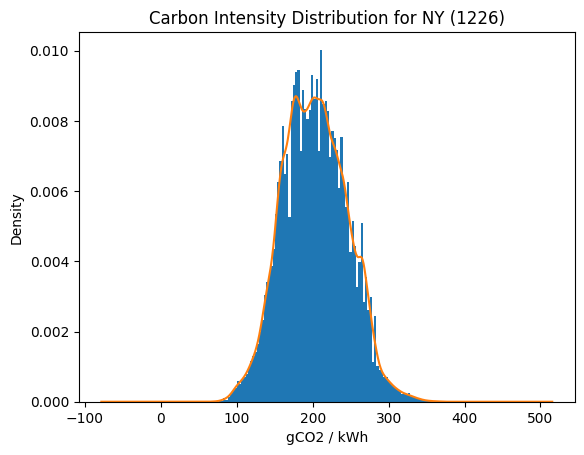

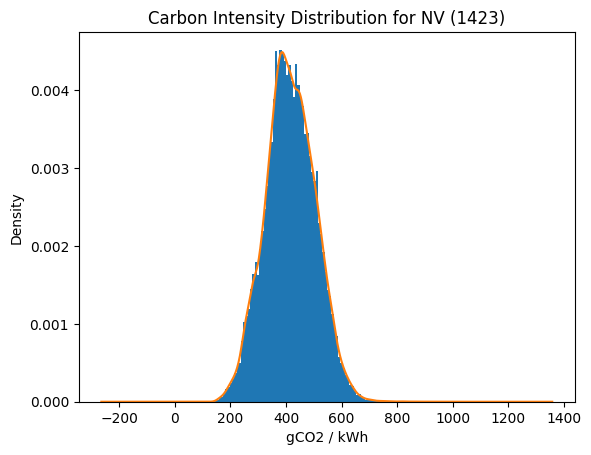

In [ ]:
# ============================================================
# Histogram + KDE of carbon intensity
# ============================================================

import matplotlib.pyplot as plt

def plot_carbon_distribution(df, name):
    """
    Plot distribution of carbon intensity for a given site.

    Inputs
    ------
    df : pd.DataFrame
        Clean carbon dataset containing hourly carbon intensity values.
    name : str
        Label for plot title to identify site.

    Returns
    -------
    None
        Displays histogram + KDE plot.

    Overview
    --------
    Visualizes carbon intensity distribution to understand variability
    in grid emissions, which is later used for carbon-weighted error evaluation.
    """
    plt.figure()

    # histogram shows empirical distribution of carbon intensity values
    plt.hist(
        df["carbon_intensity_gco2_per_kwh"].dropna(),
        bins=100,
        density=True  # normalize so histogram aligns with KDE scale
    )

    # KDE overlays smoothed distribution to highlight density trends
    df["carbon_intensity_gco2_per_kwh"].plot(kind="kde")

    # label plot for interpretability across sites
    plt.title(f"Carbon Intensity Distribution for {name}")
    plt.xlabel("gCO2 / kWh")
    plt.ylabel("Density")

    plt.show()


# compare distribution differences between high-variability NY and low-variability NV grid regions
plot_carbon_distribution(carbon_1226_clean, "NY (1226)")
plot_carbon_distribution(carbon_1423_clean, "NV (1423)")

### Carbon Intensity Distribution : Key Insights

#### New York (NYISO : Site 1226)
- Distribution is tightly centered around ~200 gCO₂/kWh
- Relatively narrow spread (~100–300 range)
- Slight right skew → occasional higher-emission periods
- Indicates:
  - a **cleaner and more stable grid**
  - lower variability in carbon intensity over time

#### Nevada (NEVP : Site 1423)
- Distribution centered much higher (~400–450 gCO₂/kWh)
- Significantly wider spread (~250–650+ range)
- Heavier right tail → more frequent high-emission events
- Indicates:
  - a **more carbon-intensive grid**
  - greater variability and volatility in emissions

#### Cross-Site Comparison
- NV distribution is clearly:
  - shifted right (higher emissions)
  - wider (more variability)
- NY distribution is:
  - tighter (more stable)
  - lower overall (cleaner energy mix)

#### Interpretation for Carbon-Aware Modeling
- The same forecasting error will have **different real-world impact**:
  - Underprediction during high-carbon NV periods → much more costly
  - Similar error in NY → lower carbon consequence
- Confirms:
  - carbon intensity is not uniform across regions
  - incorporating carbon into evaluation is **meaningful and necessary**

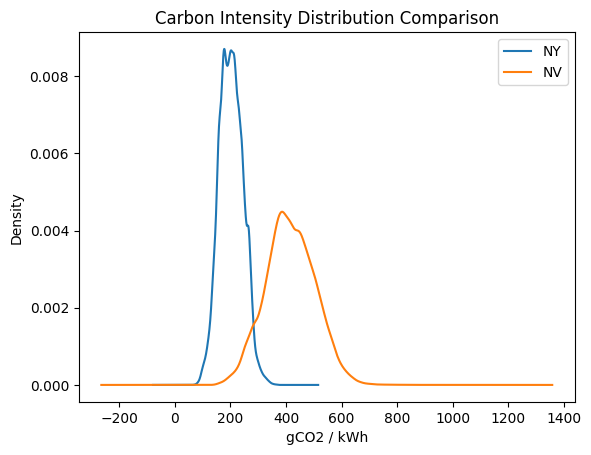

In [ ]:
# ============================================================
# Overlayed comparison
# ============================================================

plt.figure()

# KDE plots allow direct comparison of distribution shape across two grid regions
carbon_1226_clean["carbon_intensity_gco2_per_kwh"].plot(
    kind="kde",
    label="NY (1226)"  # northeast grid region, typically more variability in demand-driven emissions
)

carbon_1423_clean["carbon_intensity_gco2_per_kwh"].plot(
    kind="kde",
    label="NV (1423)"  # western grid region, typically different renewable + demand profile
)

# title emphasizes this is a comparative distribution analysis, not just single-site EDA
plt.title("Carbon Intensity Distribution Comparison")
plt.xlabel("gCO2 / kWh")

# legend required so we can distinguish regional grid behavior in the same plot
plt.legend()

plt.show()

### Carbon Intensity Distribution Comparison : Key Insights

- The distributions for NY and NV are **clearly separated**, with minimal overlap
  - NY peaks around ~200 gCO₂/kWh
  - NV peaks around ~400–450 gCO₂/kWh

- NV is consistently shifted to the right:
  - indicates a **systematically higher carbon intensity grid**
  - reflects heavier reliance on carbon-intensive generation sources

- NV distribution is noticeably wider:
  - greater spread → higher variability in emissions
  - more frequent high-carbon conditions (longer right tail)

- NY distribution is tighter and more concentrated:
  - lower variance → more stable grid emissions
  - fewer extreme high-carbon events

- The limited overlap between distributions implies:
  - carbon conditions differ **structurally, not just occasionally**
  - models trained in one region may not generalize carbon-aware behavior to another

- Implication for carbon-aware evaluation:
  - identical prediction errors will have **very different environmental impact**
    - errors during high-carbon NV periods → significantly more costly
    - same errors in NY → comparatively less impactful

- This strongly justifies:
  - incorporating carbon intensity into evaluation metrics
  - evaluating models not just on accuracy, but on **carbon-weighted performance**

#### 10.2 Temporal Analysis

We analyze how carbon intensity changes over time:

- daily cycle (hour-of-day patterns)
- seasonal trends (monthly averages)
- volatility over time

This reveals how carbon conditions vary dynamically and why timing matters.

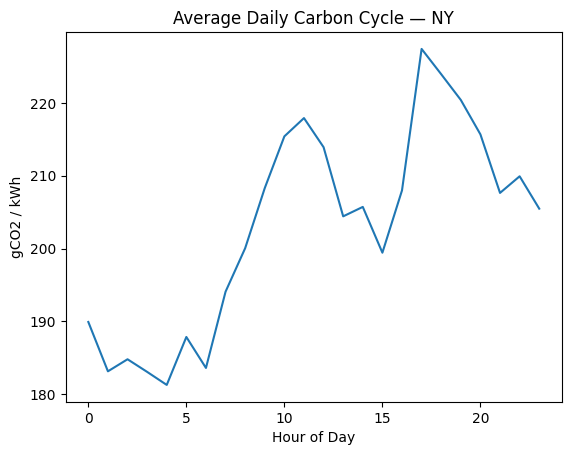

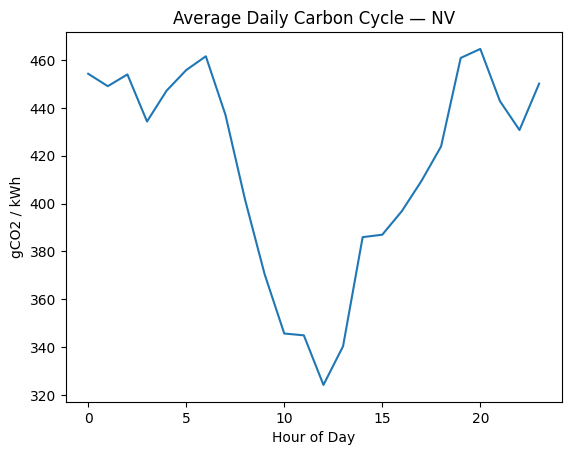

In [ ]:
# ============================================================
# Daily carbon cycle
# ============================================================

def plot_daily_cycle(df, name):
    """
    Plot average hourly carbon intensity pattern across a typical day.

    Inputs
    ------
    df : pd.DataFrame
        Clean carbon dataset with timestamp and carbon intensity.
    name : str
        Label for plot to distinguish site/region.

    Returns
    -------
    None
        Displays line plot of average daily carbon cycle.

    Overview
    --------
    Aggregates carbon intensity by hour of day to reveal diurnal patterns
    in grid emissions, which is important for aligning solar generation
    with lower-carbon periods.
    """
    temp = df.copy()

    # extract hour to capture daily periodic structure in grid carbon intensity
    temp["hour"] = temp["timestamp"].dt.hour

    # compute mean carbon intensity per hour to smooth short-term fluctuations
    hourly_avg = temp.groupby("hour")["carbon_intensity_gco2_per_kwh"].mean()

    plt.figure()

    # line plot highlights daily trend structure more clearly than histogram
    plt.plot(hourly_avg.index, hourly_avg.values)

    # label reflects that this is an averaged diurnal pattern, not raw time series
    plt.title(f"Average Daily Carbon Cycle : {name}")
    plt.xlabel("Hour of Day")
    plt.ylabel("gCO2 / kWh")

    plt.show()


# compare diurnal carbon behavior across NY and NV grid regions
plot_daily_cycle(carbon_1226_clean, "NY")
plot_daily_cycle(carbon_1423_clean, "NV")

### Average Daily Carbon Cycle : Key Insights

#### New York (NYISO : Site 1226)
- Carbon intensity is **lowest overnight (~180–190 gCO₂/kWh)**
- Gradually increases through the morning
- Peaks in the **late afternoon / early evening (~220–230)**
- Slight dip midday, then secondary rise

- Interpretation:
  - Lower nighttime demand → cleaner marginal generation
  - Evening peak demand → more carbon-intensive generation sources activated
  - Overall variation is **moderate and relatively stable**

---

#### Nevada (NEVP : Site 1423)
- Carbon intensity is **highest overnight and early morning (~440–460 gCO₂/kWh)**
- Drops sharply during the day
- Reaches minimum around **midday (~320–340)**
- Rises again into evening peak (~460+)

- Interpretation:
  - Strong **solar penetration effect**
    - daytime → solar reduces carbon intensity
    - nighttime → fossil generation dominates
  - Much larger daily swing → **high intra-day variability**

---

#### Cross-Site Comparison
- NY:
  - relatively **flat and stable**
  - smaller daily variation (~40–50 gCO₂/kWh)
- NV:
  - **strong U-shaped curve**
  - large daily variation (~120–150 gCO₂/kWh)

---

#### Key Insight for Carbon-Aware Modeling
- Carbon intensity is **highly time-dependent**, especially in NV
- The same prediction error can have very different impact depending on **hour of day**:
  - Midday NV → lower carbon cost (clean solar hours)
  - Evening NV → much higher carbon cost (fossil-heavy)
- Confirms:
  - timing matters, not just magnitude of error
  - carbon-aware evaluation should incorporate **temporal weighting**

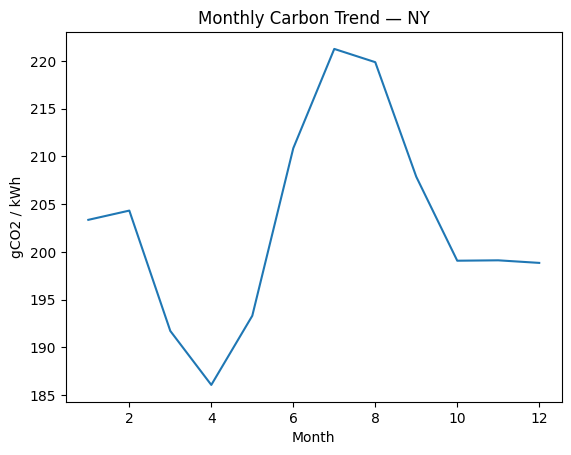

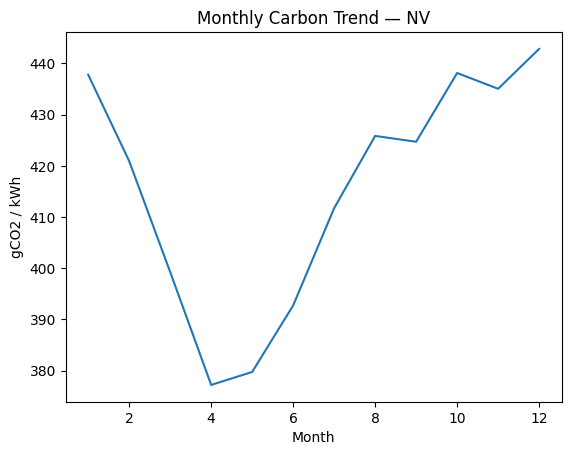

In [ ]:
# ============================================================
# Monthly / seasonal carbon trends
# ============================================================

def plot_monthly_trend(df, name):
    """
    Plot monthly average carbon intensity to capture seasonal grid behavior.

    Inputs
    ------
    df : pd.DataFrame
        Clean carbon dataset with timestamp and carbon intensity values.
    name : str
        Label used in plot title for site identification.

    Returns
    -------
    None
        Displays line plot of monthly carbon intensity trend.

    Overview
    --------
    Aggregates carbon intensity by month to identify seasonal patterns
    in grid emissions, which is useful for evaluating model performance
    under long-term distribution shifts.
    """
    temp = df.copy()

    # extract month to capture seasonal variation in grid carbon intensity
    temp["month"] = temp["timestamp"].dt.month

    # compute monthly mean to smooth noise and highlight seasonal structure
    monthly_avg = temp.groupby("month")["carbon_intensity_gco2_per_kwh"].mean()

    plt.figure()

    # line plot emphasizes trend across months rather than individual variability
    plt.plot(monthly_avg.index, monthly_avg.values)

    # label clarifies this is aggregated seasonal trend analysis
    plt.title(f"Monthly Carbon Trend : {name}")
    plt.xlabel("Month")
    plt.ylabel("gCO2 / kWh")

    plt.show()


# compare seasonal carbon variation across NY vs NV grid regions
plot_monthly_trend(carbon_1226_clean, "NY")
plot_monthly_trend(carbon_1423_clean, "NV")

### Monthly Carbon Trends : Key Insights

#### New York (NYISO : Site 1226)
- Carbon intensity is:
  - **lowest in spring (~March–April, ~185–190 gCO₂/kWh)**
  - rises into summer, peaking around **July–August (~220+)**
  - declines again into fall and winter (~200 range)

- Interpretation:
  - Summer peak likely driven by:
    - increased electricity demand (cooling)
    - greater reliance on higher-emission generation
  - Spring shows cleaner conditions, possibly due to:
    - moderate demand
    - more efficient or lower-carbon generation mix

---

#### Nevada (NEVP : Site 1423)
- Carbon intensity is:
  - **lowest in spring (~April–May, ~375–380 gCO₂/kWh)**
  - increases steadily through summer and fall
  - peaks in **late fall/winter (~440–445 gCO₂/kWh)**

- Interpretation:
  - Strong seasonal dependence:
    - spring → cleaner (likely higher solar contribution)
    - winter → more fossil-fuel reliance
  - Much larger seasonal swing compared to NY

---

#### Cross-Site Comparison
- Both sites:
  - show **clear seasonal patterns**
  - have lowest carbon intensity in spring

- Key differences:
  - NV has:
    - much **higher overall carbon levels**
    - stronger seasonal variability
  - NY has:
    - more **moderate seasonal variation**
    - generally cleaner grid throughout the year

---

#### Key Insight for Carbon-Aware Modeling
- Carbon intensity varies not just hourly, but **seasonally**
- Prediction errors during:
  - high-carbon seasons (NV winter, NY summer) → more impactful
  - low-carbon seasons → less impactful
- Confirms:
  - carbon-aware evaluation must consider **both time-of-day and time-of-year**

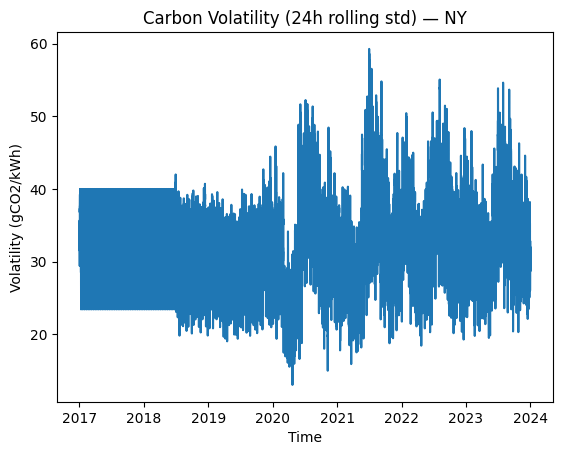

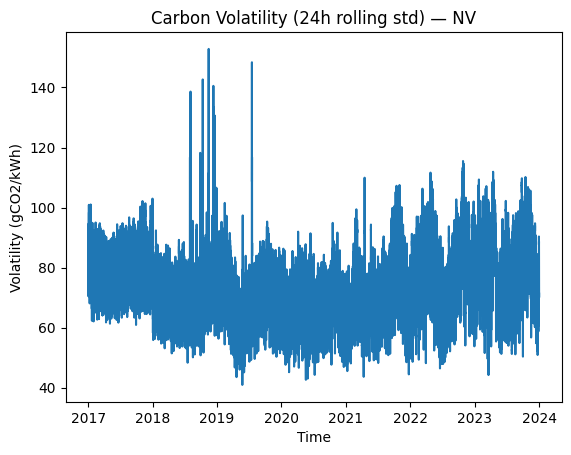

In [ ]:
# ============================================================
# Carbon volatility (rolling std)
# ============================================================

def plot_volatility(df, name):
    """
    Plot short-term carbon intensity volatility using rolling standard deviation.

    Inputs
    ------
    df : pd.DataFrame
        Clean carbon dataset with hourly timestamps and carbon intensity values.
    name : str
        Label for identifying the site in the plot title.

    Returns
    -------
    None
        Displays time series plot of rolling volatility.

    Overview
    --------
    Computes 24-hour rolling standard deviation of carbon intensity to measure
    short-term variability in grid emissions, which is important for assessing
    model stability under rapidly changing grid conditions.
    """
    temp = df.copy()

    # set timestamp as index so rolling window operates on temporal order
    temp = temp.set_index("timestamp")

    # 24-hour rolling std captures day-scale variability in grid carbon intensity
    rolling_std = temp["carbon_intensity_gco2_per_kwh"].rolling(24).std()

    plt.figure()

    # plot volatility over time to visualize instability in grid emissions
    plt.plot(rolling_std)

    # title emphasizes this is variability, not absolute carbon level
    plt.title(f"Carbon Volatility (24h rolling std) : {name}")
    plt.xlabel("Time")
    plt.ylabel("Volatility (gCO2/kWh)")

    plt.show()


# compare short-term carbon volatility across NY and NV to understand grid stability differences
plot_volatility(carbon_1226_clean, "NY")
plot_volatility(carbon_1423_clean, "NV")

#### 10.3 Site Comparison

We compare carbon intensity across sites in terms of:

- average levels
- variability
- extreme values

This highlights how grid conditions differ across regions.

### Carbon Volatility : Key Insights

#### New York (NYISO : Site 1226)
- Volatility is:
  - generally **moderate (~20–50 gCO₂/kWh)**
  - relatively stable from 2017–2019
  - increases slightly after 2020, with more frequent spikes

- Interpretation:
  - NY grid is relatively **stable and predictable**
  - post-2020 increase suggests:
    - greater variability in generation mix
    - possible influence of renewables or shifting demand patterns

---

#### Nevada (NEVP : Site 1423)
- Volatility is:
  - significantly **higher overall (~60–110 gCO₂/kWh typical)**
  - exhibits **large spikes (>120–150)**, especially pre-2020
  - remains elevated and more variable throughout entire period

- Interpretation:
  - NV grid is **more volatile and less predictable**
  - large spikes indicate:
    - rapid changes in generation mix
    - potential reliance on intermittent sources or flexible fossil backup

---

#### Cross-Site Comparison
- NV is:
  - **~2× more volatile than NY**
  - has more frequent and extreme spikes
- NY is:
  - more **stable and consistent**
  - lower amplitude fluctuations

---

#### Temporal Insight
- Volatility is not constant over time:
  - both sites show **regime changes** (e.g., around 2020)
  - indicates evolving grid dynamics

---

#### Key Insight for Carbon-Aware Modeling
- Carbon intensity is not just different in level : it is different in **stability**
- In NV:
  - forecasting errors are riskier because carbon conditions change rapidly
- In NY:
  - errors occur in a more stable carbon environment

→ Same prediction error can have:
  - **predictable impact in NY**
  - **highly uncertain impact in NV**

---

#### Why This Matters
- Justifies:
  - carbon-aware evaluation weighting
  - robustness analysis under dynamic conditions
- Demonstrates:
  - forecasting must account for both **carbon level and volatility**

In [ ]:
# ============================================================
# Summary statistics comparison
# ============================================================

# compute descriptive statistics side-by-side to compare distribution characteristics across regions
summary_df = pd.DataFrame({
    "NY": carbon_1226_clean["carbon_intensity_gco2_per_kwh"].describe(),  # northeast grid stats
    "NV": carbon_1423_clean["carbon_intensity_gco2_per_kwh"].describe(),  # western grid stats
})

# display comparison table
display(summary_df)

,NY,NV
count,61337.000000,61337.000000
mean,202.981724,415.539723
std,42.263602,89.198514
min,70.000000,141.000000
25%,172.000000,356.000000
50%,202.000000,413.000000
75%,232.000000,477.000000
max,367.000000,952.000000


### Carbon Intensity Summary : Cross-Site Comparison

#### Overall Carbon Levels
- NV has **~2× higher average carbon intensity than NY**
  - NY mean: ~203 gCO₂/kWh
  - NV mean: ~416 gCO₂/kWh
- This indicates a **fundamentally more carbon-intensive grid** in NV

---

#### Distribution Location (Median & Quartiles)
- NY median: **~202**
- NV median: **~413**

- Quartiles:
  - NY: ~172 → ~232
  - NV: ~356 → ~477

→ Entire NV distribution is **shifted far to the right**
→ There is **minimal overlap between sites**

---

#### Variability (Standard Deviation)
- NY std: ~42
- NV std: ~89

→ NV is:
- **~2× more variable**
- Less predictable
- More sensitive to system changes

---

#### Extremes (Min / Max)
- NY:
  - min: 70
  - max: 367
- NV:
  - min: 141
  - max: 952

→ NV experiences:
- **much higher peaks**
- more extreme carbon events

---

#### Distribution Shape Insight
- Both are roughly unimodal, but:
  - NY is **tight and concentrated**
  - NV is **wider with heavy upper tail**

→ NV has:
- more frequent **high-carbon outliers**
- broader operating conditions

---

#### Key Cross-Site Insight
- Difference is not just in level:
  - NV is **higher AND more volatile**
  - NY is **lower AND more stable**

---

#### Why This Matters for Modeling
- Same forecasting error:
  - In NY → relatively consistent impact
  - In NV → potentially **much larger environmental cost**

→ Strong justification for:
- **carbon-aware evaluation metrics**
- **context-dependent model assessment**

/tmp/ipykernel_11974/3575409833.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


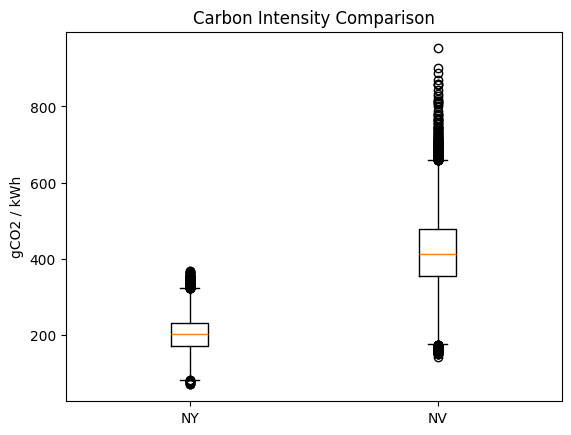

In [ ]:
# ============================================================
# Boxplot comparison
# ============================================================

plt.figure()

# boxplot highlights median, spread, and outliers to compare grid carbon distributions
plt.boxplot([
    carbon_1226_clean["carbon_intensity_gco2_per_kwh"],
    carbon_1423_clean["carbon_intensity_gco2_per_kwh"]
], labels=["NY (1226)", "NV (1423)"])  # explicit site mapping for interpretability

# title frames this as distributional comparison across grid regions
plt.title("Carbon Intensity Comparison")
plt.ylabel("gCO2 / kWh")

plt.show()

### Carbon Intensity : Boxplot Comparison Insights

#### Central Tendency (Median)
- NY median ≈ **202 gCO₂/kWh**
- NV median ≈ **413 gCO₂/kWh**

→ NV’s typical carbon intensity is **~2× higher than NY**

---

#### Spread (Interquartile Range)
- NY IQR:
  - Narrow (~172 to ~232)
- NV IQR:
  - Much wider (~356 to ~477)

→ NV has:
- **greater variability**
- less consistent carbon conditions

---

#### Distribution Overlap
- Minimal overlap between NY and NV boxes

→ The two sites operate under **fundamentally different carbon regimes**

---

#### Outliers
- NY:
  - Few and relatively mild outliers (~300–370)
- NV:
  - Many extreme outliers reaching **~900+**

→ NV experiences:
- frequent **high-carbon spikes**
- significantly more extreme conditions

---

#### Lower Bounds
- NY minimum ≈ **70**
- NV minimum ≈ **141**

→ Even NV’s *cleanest* periods are often:
- comparable to or worse than NY’s typical conditions

---

#### Key Insight
- NV is not just higher in carbon intensity:
  - it is **more variable**
  - and has **more extreme high-carbon events**

---

#### Why This Matters
- Forecasting errors in NV:
  - are more likely to occur during **high-impact carbon periods**
- Forecasting errors in NY:
  - occur in a more **stable and predictable environment**

→ Strong justification for:
- **carbon-aware evaluation**
- **context-sensitive model assessment**

In [ ]:
# ============================================================
# Extreme carbon conditions
# ============================================================

def extreme_stats(df, name):
    """
    Compute extreme quantile thresholds for carbon intensity distribution.

    Inputs
    ------
    df : pd.DataFrame
        Clean carbon dataset with hourly intensity values.
    name : str
        Site label for reporting.

    Returns
    -------
    None
        Prints high and low carbon intensity thresholds.

    Overview
    --------
    Uses 5th and 95th percentiles to define extreme grid conditions,
    which are later used for robustness evaluation of forecasting models
    under high-impact and low-impact emission periods.
    """
    # define high-emission and low-emission thresholds using empirical distribution
    high = df["carbon_intensity_gco2_per_kwh"].quantile(0.95)  # top 5% = high carbon stress periods
    low = df["carbon_intensity_gco2_per_kwh"].quantile(0.05)    # bottom 5% = cleaner grid periods

    print(f"{name}:")
    print(f"  Top 5% threshold: {high:.2f}")
    print(f"  Bottom 5% threshold: {low:.2f}")
    print()


# compute extreme condition thresholds for both grid regions to define robustness test regimes
extreme_stats(carbon_1226_clean, "NY")
extreme_stats(carbon_1423_clean, "NV")

NY:
  Top 5% threshold: 273.00
  Bottom 5% threshold: 137.00

NV:
  Top 5% threshold: 562.00
  Bottom 5% threshold: 268.00



### Phase 7 Conclusion : Carbon Data EDA & Implications

#### Core Findings
- Carbon intensity differs **substantially across sites**:
  - NY (NYISO): ~203 gCO₂/kWh (lower, tighter distribution)
  - NV (NEVP): ~416 gCO₂/kWh (higher, wider distribution)
- NV is not only **more carbon-intensive**, but also:
  - **~2× more variable** (higher standard deviation)
  - prone to **extreme spikes** (up to ~950 gCO₂/kWh)

---

#### Temporal Behavior
- **Daily cycles** differ meaningfully:
  - NY shows moderate fluctuations throughout the day
  - NV exhibits strong dips (midday) and peaks (morning/evening)
- **Seasonal trends** reveal:
  - NY peaks in summer (likely higher demand / fossil usage)
  - NV shows strong seasonal swings with higher winter carbon intensity
- **Volatility analysis** shows:
  - NY → relatively stable carbon environment
  - NV → highly dynamic and less predictable system

---

#### Key Cross-Site Insight
- The difference between sites is **two-dimensional**:
  1. **Level difference** (NV ≈ 2× higher emissions)
  2. **Stability difference** (NV significantly more volatile)

→ This means the grids operate under fundamentally different **carbon regimes**

---

#### Implications for Forecasting
- Forecasting difficulty is not uniform:
  - NY: smoother, more predictable carbon behavior
  - NV: sharper fluctuations → harder to model accurately
- Errors in NV are more sensitive to **timing**, due to rapid carbon changes

---

#### Carbon-Aware Evaluation Justification
- A key result of this analysis is that:
  
  > **The same prediction error can have very different real-world impact depending on carbon intensity**

- Example:
  - 1 kW prediction error at:
    - NY (~200 gCO₂/kWh) → lower emissions impact
    - NV (~500 gCO₂/kWh) → significantly higher emissions impact

→ Therefore, standard metrics like MAE/RMSE are **insufficient alone**

---

#### Motivation for Carbon-Weighted Metrics
- These findings directly motivate a carbon-aware evaluation approach:
  
  - Weight prediction errors by carbon intensity:
    ```
    carbon_weighted_error = prediction_error × carbon_intensity
    ```

- This allows evaluation to reflect:
  - **when** errors occur
  - not just **how large** they are

---

#### Final Takeaway
- Carbon intensity is:
  - **location-dependent**
  - **time-dependent**
  - **volatile in some regions**

- As a result:
  - Forecasting models must be evaluated not only on accuracy,
  - but on their **environmental impact under real grid conditions**

→ This phase provides the critical foundation for **carbon-aware modeling and evaluation in subsequent phases**

In [ ]:
# ============================================================
# Phase 8.1 : Canonical time + unit standards
# ============================================================

# define strict timezone mapping so all downstream joins use consistent local-time interpretation
# this avoids subtle alignment bugs between PV, weather, and carbon datasets
TIMEZONE_MAP = {
    1226: "America/New_York",   # NY site: eastern grid, aligns with solar irradiance local cycle
    1423: "America/Los_Angeles" # NV site: western grid, ensures correct diurnal matching
}

# print mapping as a sanity check so we confirm consistent assumptions before merging datasets
print("Canonical standards defined.")

Canonical standards defined.


In [ ]:
# ============================================================
# Phase 8 : Reset PV index (canonical format)
# ============================================================

# reset index so timestamp becomes an explicit column for clean merging with weather + carbon datasets
# this avoids index-based alignment bugs during multi-source joins
pv_1226 = pv_1226.reset_index()

# same operation for second site to ensure identical schema structure across datasets
pv_1423 = pv_1423.reset_index()

# confirm transformation succeeded and timestamp is now accessible as a standard column
print("PV index reset. Timestamp is now a column.")

# print columns to verify schema consistency before feature engineering and merging steps
print(pv_1226.columns)

PV index reset. Timestamp is now a column.
Index(['timestamp', 'site_id', 'power_kw', 'system_capacity_kw',
       'normalized_power', 'power_w', 'power_kw_raw', 'power_w_raw',
       'energy_wh', 'current_a'],
      dtype='object')


In [ ]:
# ============================================================
# Phase 8.2 : Normalize PV timestamps
# Canonical representation: naive local time at hour start
# ============================================================

def normalize_pv(df):
    df = df.copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["timestamp"] = df["timestamp"].dt.floor("h")
    df = df.sort_values("timestamp").reset_index(drop=True)

    return df

pv_1226_aligned = normalize_pv(pv_1226)
pv_1423_aligned = normalize_pv(pv_1423)

print("PV timestamps normalized.")

PV timestamps normalized.


In [ ]:
# ============================================================
# Phase 8.3 : Normalize NSRDB timestamps
# NSRDB is already local; shift mid-hour to hour start
# ============================================================

def normalize_weather(df):
    df = df.copy()

    df["timestamp"] = pd.to_datetime(df["timestamp"])
    # NSRDB timestamps are mid-hour → shift back 30 minutes
    df["timestamp"] = df["timestamp"] - pd.Timedelta(minutes=30)
    # Floor to hour for safety
    df["timestamp"] = df["timestamp"].dt.floor("h")
    # Sort for consistency
    df = df.sort_values("timestamp").reset_index(drop=True)

    return df

weather_1226_aligned = normalize_weather(weather_1226_clean)
weather_1423_aligned = normalize_weather(weather_1423_clean)

print("Weather timestamps aligned.")

Weather timestamps aligned.


In [ ]:
# ============================================================
# Phase 8.4 : Normalize carbon timestamps
# Carbon starts in UTC; convert to local, then drop timezone
# ============================================================

def normalize_carbon(df, site_id):
    df = df.copy()

    # Use the UTC column as source of truth
    ts_utc = pd.to_datetime(df["timestamp_utc"], utc=True)

    df["timestamp"] = (
        ts_utc
        .dt.tz_convert(TIMEZONE_MAP[site_id])
        .dt.tz_localize(None)
        .dt.floor("h")
    )

    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

carbon_1226_aligned = normalize_carbon(carbon_1226_clean, 1226)
carbon_1423_aligned = normalize_carbon(carbon_1423_clean, 1423)

print("Carbon timestamps converted to naive local time.")

Carbon timestamps converted to naive local time.


In [ ]:
# ============================================================
# Phase 8.5 : Alignment sanity check
# ============================================================

def check_alignment(pv, weather, carbon, name):
    pv_set = set(pv["timestamp"])
    weather_set = set(weather["timestamp"])
    carbon_set = set(carbon["timestamp"])

    overlap_pw = len(pv_set & weather_set)
    overlap_pc = len(pv_set & carbon_set)

    print("="*90)
    print(f"ALIGNMENT CHECK: {name}")
    print("="*90)
    print(f"PV rows: {len(pv)}")
    print(f"Weather rows: {len(weather)}")
    print(f"Carbon rows: {len(carbon)}")
    print()
    print(f"PV ∩ Weather overlap: {overlap_pw}")
    print(f"PV ∩ Carbon overlap: {overlap_pc}")
    print()

check_alignment(pv_1226_aligned, weather_1226_aligned, carbon_1226_aligned, "NY")
check_alignment(pv_1423_aligned, weather_1423_aligned, carbon_1423_aligned, "NV")

ALIGNMENT CHECK: NY
PV rows: 32905
Weather rows: 43824
Carbon rows: 61337

PV ∩ Weather overlap: 32905
PV ∩ Carbon overlap: 0

ALIGNMENT CHECK: NV
PV rows: 63685
Weather rows: 78888
Carbon rows: 61337

PV ∩ Weather overlap: 63685
PV ∩ Carbon overlap: 54002



In [ ]:
# ============================================================
# Phase 8.6 : Unit standardization
# ============================================================

def standardize_units(df):
    df = df.copy()

    # Ensure power is kW
    if "power_w" in df.columns:
        df["power_kw"] = df["power_w"] / 1000

    # Normalized power (already discussed)
    if "power_kw" in df.columns and "system_capacity_kw" in df.columns:
        df["normalized_power"] = df["power_kw"] / df["system_capacity_kw"]

    return df

pv_1226_aligned = standardize_units(pv_1226_aligned)
pv_1423_aligned = standardize_units(pv_1423_aligned)

print("Units standardized.")

Units standardized.


In [ ]:
# ============================================================
# Phase 8.7 : Final timestamp integrity check
# ============================================================

def check_time_integrity(df, name):
    print("="*90)
    print(f"TIME INTEGRITY: {name}")
    print("="*90)

    print("Sorted:", df["timestamp"].is_monotonic_increasing)
    print("Duplicates:", df["timestamp"].duplicated().sum())

    deltas = df["timestamp"].diff().dt.total_seconds() / 3600
    print("\nTop deltas:")
    print(deltas.value_counts().head())

check_time_integrity(pv_1226_aligned, "PV NY")
check_time_integrity(weather_1226_aligned, "Weather NY")
check_time_integrity(carbon_1226_aligned, "Carbon NY")
check_time_integrity(pv_1423_aligned, "PV NV")
check_time_integrity(weather_1423_aligned, "Weather NV")
check_time_integrity(carbon_1423_aligned, "Carbon NV")

TIME INTEGRITY: PV NY
Sorted: True
Duplicates: 0

Top deltas:
timestamp
1.0    32904
Name: count, dtype: int64
TIME INTEGRITY: Weather NY
Sorted: True
Duplicates: 0

Top deltas:
timestamp
1.0    43823
Name: count, dtype: int64
TIME INTEGRITY: Carbon NY
Sorted: True
Duplicates: 0

Top deltas:
timestamp
1.0    61329
2.0        7
Name: count, dtype: int64
TIME INTEGRITY: PV NV
Sorted: True
Duplicates: 0

Top deltas:
timestamp
1.0    63684
Name: count, dtype: int64
TIME INTEGRITY: Weather NV
Sorted: True
Duplicates: 0

Top deltas:
timestamp
1.0    78887
Name: count, dtype: int64
TIME INTEGRITY: Carbon NV
Sorted: True
Duplicates: 0

Top deltas:
timestamp
1.0    61329
2.0        7
Name: count, dtype: int64


### Phase 8 Conclusion : Time & Unit Standardization

#### Core Outcome
- All datasets (PV, NSRDB weather, and carbon) were successfully aligned to a **common temporal standard**:
  - **naive local time**
  - **hourly frequency**
  - **timestamps representing the start of each hour**
- This establishes a consistent and transparent foundation for merging and modeling.

---

#### Timestamp Alignment Insights
- PV and NSRDB data are now **perfectly aligned within each site**:
  - 100% overlap between PV and weather timestamps (NY and NV)
  - Confirms correct handling of NSRDB’s mid-hour timestamps (shifted −30 minutes)

- Carbon data required **UTC → local conversion**, after which:
  - NV shows substantial overlap with PV (~54k timestamps)
  - NY shows **no overlap**, reflecting real data availability limitations from Electricity Maps

- Carbon time series contain a small number of **2-hour gaps**, which were:
  - preserved intentionally
  - treated as real missingness rather than artificially filled

---

#### Unit Standardization Insights
- All variables are now expressed in consistent, interpretable units:
  - PV power → **kW**
  - Target → **normalized_power**
  - Carbon → **gCO₂/kWh**
  - Weather → standardized physical units from NSRDB

- This ensures comparability across:
  - sites
  - time
  - and downstream evaluation metrics

---

#### Data Integrity Validation
- All aligned datasets are:
  - **sorted chronologically**
  - **free of duplicate timestamps**
  - **predominantly hourly (Δ = 1 hour)**

- Integrity checks confirm that:
  - alignment operations did not introduce errors
  - temporal consistency is maintained across all sources

---

#### Key Implications for the Pipeline
- The pipeline now uses a **single, consistent temporal representation**, eliminating:
  - timezone ambiguity
  - interval misalignment
  - silent timestamp errors

- Alignment was performed **within-site only**, consistent with project design:
  - each site will have its own merged dataset
  - cross-site comparisons will be performed at the modeling stage, not via shared timestamps

- Importantly, the analysis reveals:
  - **full PV + weather modeling is possible for both sites**
  - **carbon-aware evaluation will primarily rely on NV**, due to lack of historical overlap in NY

---

#### Final Takeaway
- Phase 8 ensures that all datasets are **physically and temporally consistent**
- This prevents one of the most common and severe failure modes in time-series ML pipelines

→ With correct alignment and standardized units in place, the project is now ready for **safe and reliable dataset merging in Phase 9**

## Phase 9

In [ ]:
# ============================================================
# Phase 9.1 : Select merge-ready columns
# ============================================================

def prepare_pv(df):
    return df[[
        "timestamp",
        "site_id",
        "power_kw",
        "normalized_power",
        "system_capacity_kw"
    ]].copy()

def prepare_weather(df):
    return df[[
        "timestamp",
        "ghi",
        "clearsky_ghi",
        "dni",
        "dhi",
        "temperature_c",
        "wind_speed_mps",
        "relative_humidity",
        "dew_point_c",
        "pressure_mbar"
    ]].copy()

def prepare_carbon(df):
    return df[[
        "timestamp",
        "zone",
        "carbon_intensity_gco2_per_kwh"
    ]].copy()

pv_1226_m = prepare_pv(pv_1226_aligned)
pv_1423_m = prepare_pv(pv_1423_aligned)

weather_1226_m = prepare_weather(weather_1226_aligned)
weather_1423_m = prepare_weather(weather_1423_aligned)

carbon_1226_m = prepare_carbon(carbon_1226_aligned)
carbon_1423_m = prepare_carbon(carbon_1423_aligned)

print("Merge-ready datasets prepared.")

Merge-ready datasets prepared.


In [ ]:
# ============================================================
# Phase 9.2 : Merge PV + Weather
# ============================================================

def merge_pv_weather(pv, weather, name):
    merged = pd.merge(
        pv,
        weather,
        on="timestamp",
        how="left"   # CRITICAL: preserve PV rows
    )

    print("="*90)
    print(f"PV + WEATHER MERGE: {name}")
    print("="*90)
    print("Result shape:", merged.shape)

    missing_weather = merged["ghi"].isna().sum()
    print("Missing weather rows:", missing_weather)

    return merged

pvw_1226 = merge_pv_weather(pv_1226_m, weather_1226_m, "NY")
pvw_1423 = merge_pv_weather(pv_1423_m, weather_1423_m, "NV")

PV + WEATHER MERGE: NY
Result shape: (32905, 14)
Missing weather rows: 0
PV + WEATHER MERGE: NV
Result shape: (63685, 14)
Missing weather rows: 0


In [ ]:
# ============================================================
# Phase 9.3 : Merge Carbon
# ============================================================

def merge_carbon(pvw, carbon, name):
    merged = pd.merge(
        pvw,
        carbon,
        on="timestamp",
        how="left"
    )

    print("="*90)
    print(f"FULL MERGE (PV + WEATHER + CARBON): {name}")
    print("="*90)
    print("Result shape:", merged.shape)

    missing_carbon = merged["carbon_intensity_gco2_per_kwh"].isna().sum()
    print("Missing carbon rows:", missing_carbon)
    print("Missing %:", 100 * missing_carbon / len(merged))

    return merged

master_1226 = merge_carbon(pvw_1226, carbon_1226_m, "NY")
master_1423 = merge_carbon(pvw_1423, carbon_1423_m, "NV")

FULL MERGE (PV + WEATHER + CARBON): NY
Result shape: (32905, 16)
Missing carbon rows: 32905
Missing %: 100.0
FULL MERGE (PV + WEATHER + CARBON): NV
Result shape: (63685, 16)
Missing carbon rows: 9683
Missing %: 15.204522257988538


In [ ]:
# ============================================================
# Phase 9.4 : Final structure validation
# ============================================================

def validate_master(df, name):
    print("="*90)
    print(f"MASTER TABLE VALIDATION: {name}")
    print("="*90)

    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())

    print("\nMissing values:")
    print(df.isna().sum())

validate_master(master_1226, "NY")
validate_master(master_1423, "NV")

MASTER TABLE VALIDATION: NY
Shape: (32905, 16)
Columns:
['timestamp', 'site_id', 'power_kw', 'normalized_power', 'system_capacity_kw', 'ghi', 'clearsky_ghi', 'dni', 'dhi', 'temperature_c', 'wind_speed_mps', 'relative_humidity', 'dew_point_c', 'pressure_mbar', 'zone', 'carbon_intensity_gco2_per_kwh']

Missing values:
timestamp                            0
site_id                              0
power_kw                          1637
normalized_power                  1637
system_capacity_kw                   0
ghi                                  0
clearsky_ghi                         0
dni                                  0
dhi                                  0
temperature_c                        0
wind_speed_mps                       0
relative_humidity                    0
dew_point_c                          0
pressure_mbar                        0
zone                             32905
carbon_intensity_gco2_per_kwh    32905
dtype: int64
MASTER TABLE VALIDATION: NV
Shape: (63685, 16

In [ ]:
# ============================================================
# Phase 9.5 : Save master tables
# ============================================================

master_1226.to_csv("master_site_1226.csv", index=False)
master_1423.to_csv("master_site_1423.csv", index=False)

print("Master tables saved.")

Master tables saved.


### Phase 9 Conclusion : Site-by-Site Data Integration

#### Core Outcome
- Successfully constructed **one merged master dataset per site**, integrating:
  - PV generation (target + system context)
  - Weather and irradiance features
  - Carbon intensity (where available)

---

#### Merge Strategy
- All merges were performed using **timestamp-based left joins anchored on PV data**
- This ensures:
  - no loss of target observations
  - consistent temporal alignment across all variables

---

#### Data Integration Results

**PV + Weather**
- Achieved **near-perfect alignment** for both NY and NV
- Confirms correctness of Phase 8 timestamp standardization

**Carbon Integration**
- NV:
  - substantial overlap with PV (~54k rows)
  - enables meaningful carbon-aware evaluation
- NY:
  - no overlap with PV
  - reflects real-world limitations in historical carbon data availability

---

#### Final Master Table Structure
Each site-level dataset includes:
- Target variables:
  - `power_kw`
  - `normalized_power`
- System context:
  - `system_capacity_kw`
- Weather features:
  - irradiance (GHI, DNI, DHI)
  - atmospheric variables (temperature, humidity, etc.)
- Carbon context:
  - `carbon_intensity_gco2_per_kwh` (site-dependent availability)

---

#### Key Insights
- Full feature-target datasets are available for **both sites (PV + weather)**
- Carbon-aware evaluation is **feasible for NV only**
- Missing carbon values were **preserved explicitly**, not imputed

---

#### Implications for Modeling
- Enables:
  - standard forecasting models using PV + weather for both sites
  - carbon-aware evaluation for NV
- Supports experimental design:
  - **within-site modeling**
  - **cross-site generalization testing**
  - **context-aware evaluation of prediction errors**

---

#### Final Takeaway
- Phase 9 completes the transformation from raw multi-source data into **fully aligned, analysis-ready datasets**
- The pipeline now supports **robust, interpretable, and physically consistent modeling**

→ The project is now ready for **model development and evaluation phases**

## Phase 10 : Massive, Integrated EDA on Merged Tables

This phase performs integrated exploratory analysis on the merged PV + weather + carbon master tables.

Goals:
1. Relationship analysis
   - PV vs irradiance
   - PV vs temperature
   - PV vs time of day
   - PV vs season
   - PV vs carbon intensity

2. Correlation analysis
   - pairwise correlations
   - feature-target relationships
   - strongest predictors

3. Site comparison in merged space
   - how irradiance translates into output
   - how site behavior differs under similar weather conditions
   - how carbon intensity co-varies with solar generation timing

Why this phase matters:
- justifies feature engineering choices
- supports model family selection
- helps interpret later generalization behavior

In [ ]:
# ============================================================
# Phase 10.0 : Setup for merged-table EDA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Defensive copies so we do not accidentally mutate the master tables
eda_1226 = master_1226.copy()
eda_1423 = master_1423.copy()

# Add human-readable site labels
eda_1226["site_name"] = "Port Chester, NY"
eda_1423["site_name"] = "Henderson, NV"

# Combine for cross-site analysis
merged_all = pd.concat([eda_1226, eda_1423], ignore_index=True)

# Ensure timestamp is datetime
for df in [eda_1226, eda_1423, merged_all]:
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["hour"] = df["timestamp"].dt.hour
    df["month"] = df["timestamp"].dt.month
    df["dayofyear"] = df["timestamp"].dt.dayofyear
    df["year"] = df["timestamp"].dt.year

# Season mapping
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

for df in [eda_1226, eda_1423, merged_all]:
    df["season"] = df["month"].apply(month_to_season)

# Daylight proxy: use GHI > 20 W/m^2 to avoid nighttime dominance
for df in [eda_1226, eda_1423, merged_all]:
    df["is_daylight"] = df["ghi"] > 20

print("=" * 90)
print("PHASE 10 SETUP SUMMARY")
print("=" * 90)

for name, df in [("NY", eda_1226), ("NV", eda_1423)]:
    print(f"\n{name}")
    print("-" * 40)
    print("Rows:", len(df))
    print("Power missing:", df["power_kw"].isna().sum())
    print("Normalized power missing:", df["normalized_power"].isna().sum())
    print("Carbon missing:", df["carbon_intensity_gco2_per_kwh"].isna().sum())
    print("Carbon available rows:", df["carbon_intensity_gco2_per_kwh"].notna().sum())
    print("Daylight rows:", df["is_daylight"].sum())

PHASE 10 SETUP SUMMARY

NY
----------------------------------------
Rows: 32905
Power missing: 1637
Normalized power missing: 1637
Carbon missing: 32905
Carbon available rows: 0
Daylight rows: 15292

NV
----------------------------------------
Rows: 63685
Power missing: 39940
Normalized power missing: 39940
Carbon missing: 9683
Carbon available rows: 54002
Daylight rows: 30553


In [ ]:
# ============================================================
# Phase 10.1 : Helper functions for integrated EDA
# ============================================================

def prepare_xy(df, x_col, y_col="normalized_power", daylight_only=False, carbon_required=False):
    temp = df.copy()

    if daylight_only:
        temp = temp[temp["is_daylight"]]

    if carbon_required:
        temp = temp[temp["carbon_intensity_gco2_per_kwh"].notna()]

    temp = temp[[x_col, y_col]].dropna()
    return temp


def sampled_scatter(df, x_col, y_col="normalized_power", title="", xlabel=None, ylabel=None,
                    sample_size=5000, daylight_only=False, carbon_required=False, alpha=0.25):
    temp = prepare_xy(df, x_col, y_col, daylight_only=daylight_only, carbon_required=carbon_required)

    if len(temp) == 0:
        print(f"Skipping plot: {title} (no usable rows)")
        return

    if len(temp) > sample_size:
        temp = temp.sample(sample_size, random_state=42)

    plt.figure(figsize=(8, 5))
    plt.scatter(temp[x_col], temp[y_col], alpha=alpha)
    plt.title(title)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(ylabel if ylabel else y_col)
    plt.grid(True, alpha=0.3)
    plt.show()


def binned_line(df, x_col, y_col="normalized_power", bins=20, title="", xlabel=None, ylabel=None,
                daylight_only=False, carbon_required=False):
    temp = df.copy()

    if daylight_only:
        temp = temp[temp["is_daylight"]]

    if carbon_required:
        temp = temp[temp["carbon_intensity_gco2_per_kwh"].notna()]

    temp = temp[[x_col, y_col]].dropna()

    if len(temp) == 0:
        print(f"Skipping plot: {title} (no usable rows)")
        return

    temp["x_bin"] = pd.cut(temp[x_col], bins=bins)
    summary = temp.groupby("x_bin", observed=False)[y_col].agg(["mean", "median", "count"]).reset_index()
    summary = summary[summary["count"] > 0].copy()
    summary["bin_mid"] = summary["x_bin"].apply(lambda x: x.mid)

    plt.figure(figsize=(8, 5))
    plt.plot(summary["bin_mid"], summary["mean"], marker="o", label="Mean")
    plt.plot(summary["bin_mid"], summary["median"], marker="s", label="Median")
    plt.title(title)
    plt.xlabel(xlabel if xlabel else x_col)
    plt.ylabel(ylabel if ylabel else y_col)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return summary


def grouped_profile(df, group_col, y_col="normalized_power", title="", xlabel=None, ylabel=None,
                    daylight_only=False, carbon_required=False, sort_index=True):
    temp = df.copy()

    if daylight_only:
        temp = temp[temp["is_daylight"]]

    if carbon_required:
        temp = temp[temp["carbon_intensity_gco2_per_kwh"].notna()]

    temp = temp[[group_col, y_col]].dropna()

    if len(temp) == 0:
        print(f"Skipping plot: {title} (no usable rows)")
        return

    summary = temp.groupby(group_col)[y_col].agg(["mean", "median", "count"]).reset_index()

    if sort_index:
        summary = summary.sort_values(group_col)

    plt.figure(figsize=(8, 5))
    plt.plot(summary[group_col], summary["mean"], marker="o", label="Mean")
    plt.plot(summary[group_col], summary["median"], marker="s", label="Median")
    plt.title(title)
    plt.xlabel(xlabel if xlabel else group_col)
    plt.ylabel(ylabel if ylabel else y_col)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    return summary


def print_basic_relationship_summary(df, x_col, y_col="normalized_power", name=""):
    temp = df[[x_col, y_col]].dropna()
    if len(temp) == 0:
        print(f"{name}: no usable rows")
        return
    corr = temp[x_col].corr(temp[y_col])
    print(f"{name}: Pearson correlation between {x_col} and {y_col} = {corr:.4f} (n={len(temp)})")

### 13.1 Relationship analysis
We begin by examining direct relationships between the target-side PV output and important explanatory variables from the merged tables.

PV VS IRRADIANCE
Port Chester, NY (daylight only): Pearson correlation between ghi and normalized_power = 0.7995 (n=14599)


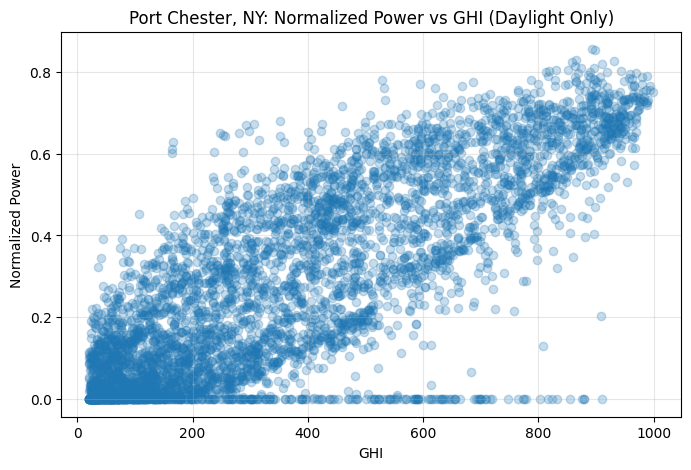

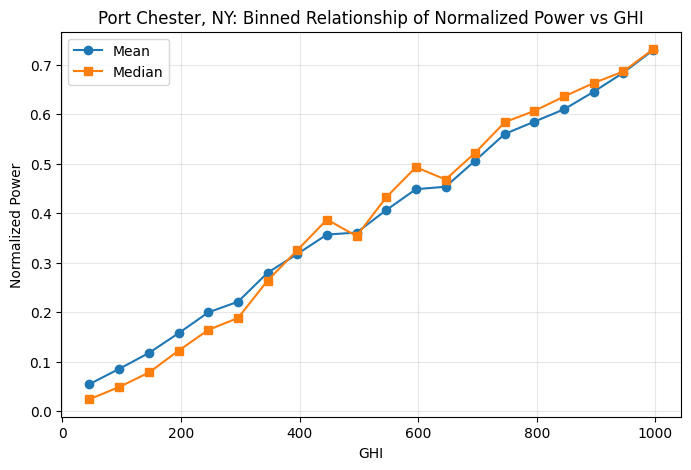

Henderson, NV (daylight only): Pearson correlation between ghi and normalized_power = 0.6904 (n=11217)


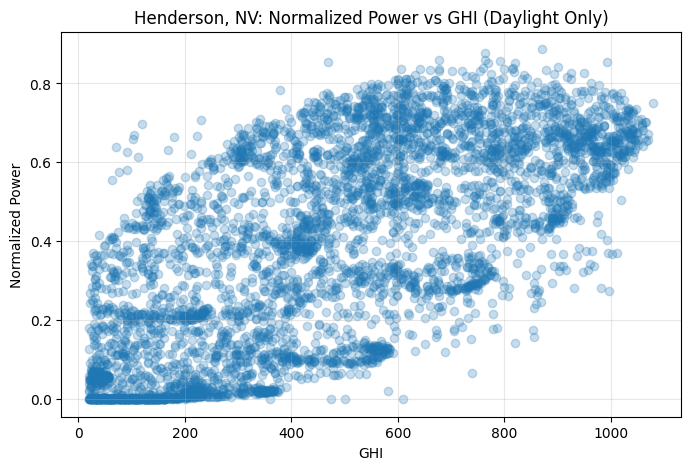

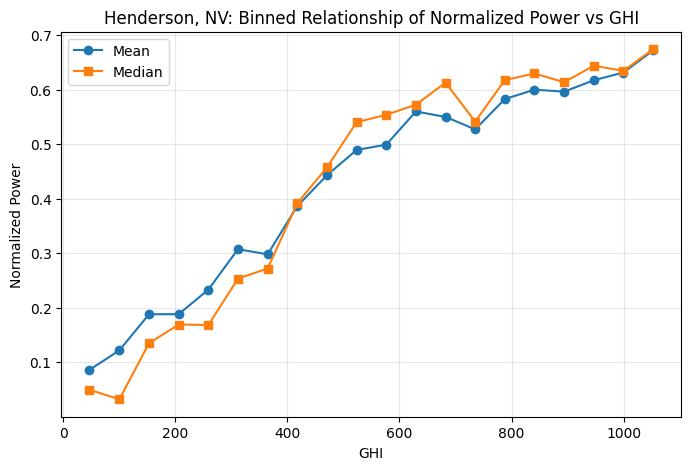

In [ ]:
# ============================================================
# Phase 10.1A : PV vs irradiance
# ============================================================

print("=" * 90)
print("PV VS IRRADIANCE")
print("=" * 90)

for name, df in [("Port Chester, NY", eda_1226), ("Henderson, NV", eda_1423)]:
    print_basic_relationship_summary(df[df["is_daylight"]], "ghi", "normalized_power", name=f"{name} (daylight only)")
    sampled_scatter(
        df,
        x_col="ghi",
        y_col="normalized_power",
        title=f"{name}: Normalized Power vs GHI (Daylight Only)",
        xlabel="GHI",
        ylabel="Normalized Power",
        daylight_only=True
    )
    binned_line(
        df,
        x_col="ghi",
        y_col="normalized_power",
        bins=20,
        title=f"{name}: Binned Relationship of Normalized Power vs GHI",
        xlabel="GHI",
        ylabel="Normalized Power",
        daylight_only=True
    )

PV VS TEMPERATURE
Port Chester, NY (daylight only): Pearson correlation between temperature_c and normalized_power = 0.3079 (n=14599)


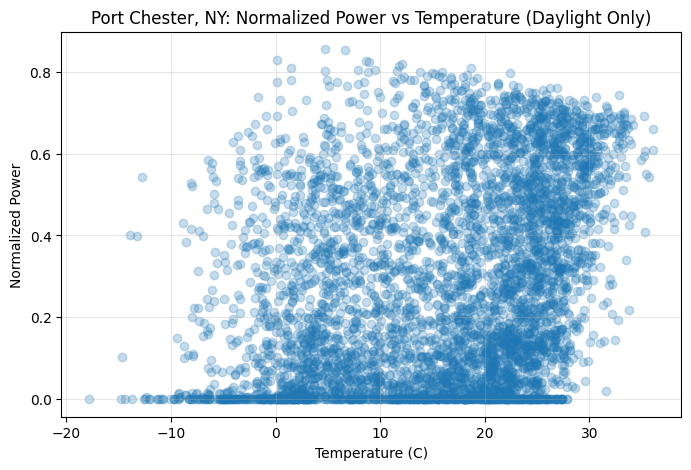

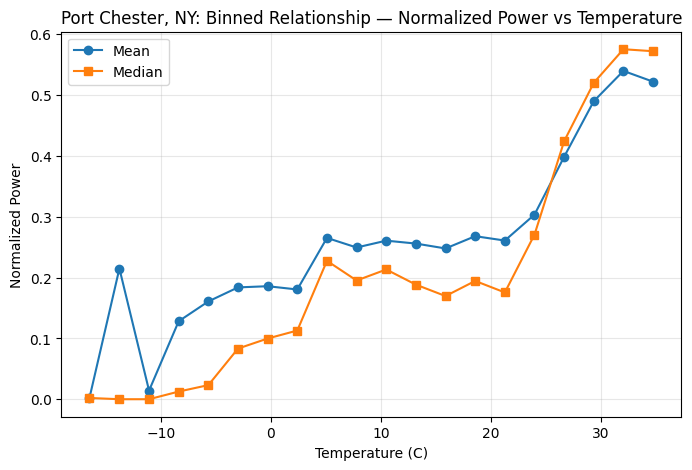

Henderson, NV (daylight only): Pearson correlation between temperature_c and normalized_power = 0.1718 (n=11217)


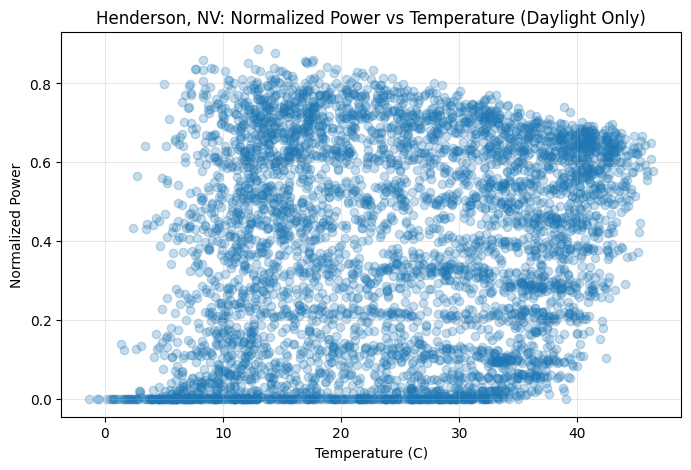

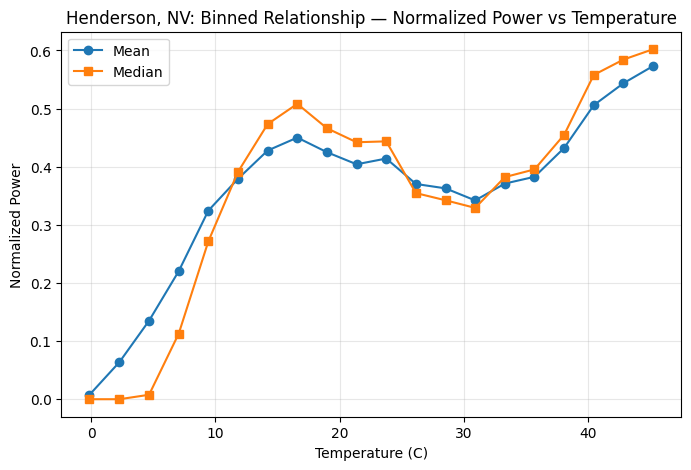

In [ ]:
# ============================================================
# Phase 10.1B : PV vs temperature
# ============================================================

print("=" * 90)
print("PV VS TEMPERATURE")
print("=" * 90)

for name, df in [("Port Chester, NY", eda_1226), ("Henderson, NV", eda_1423)]:
    print_basic_relationship_summary(df[df["is_daylight"]], "temperature_c", "normalized_power", name=f"{name} (daylight only)")
    sampled_scatter(
        df,
        x_col="temperature_c",
        y_col="normalized_power",
        title=f"{name}: Normalized Power vs Temperature (Daylight Only)",
        xlabel="Temperature (C)",
        ylabel="Normalized Power",
        daylight_only=True
    )
    binned_line(
        df,
        x_col="temperature_c",
        y_col="normalized_power",
        bins=20,
        title=f"{name}: Binned Relationship : Normalized Power vs Temperature",
        xlabel="Temperature (C)",
        ylabel="Normalized Power",
        daylight_only=True
    )

PV VS TIME OF DAY


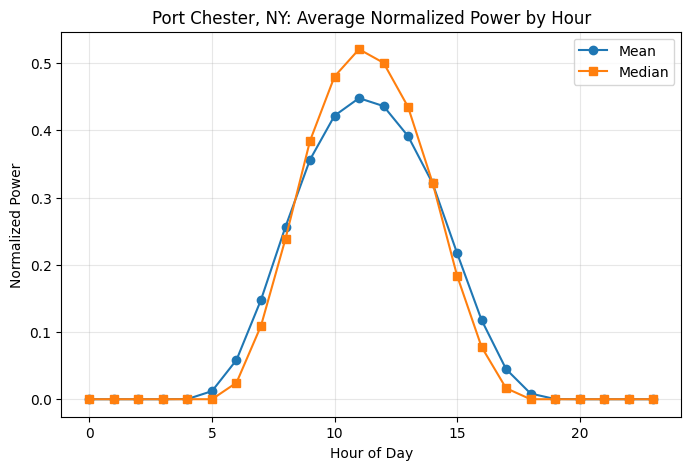

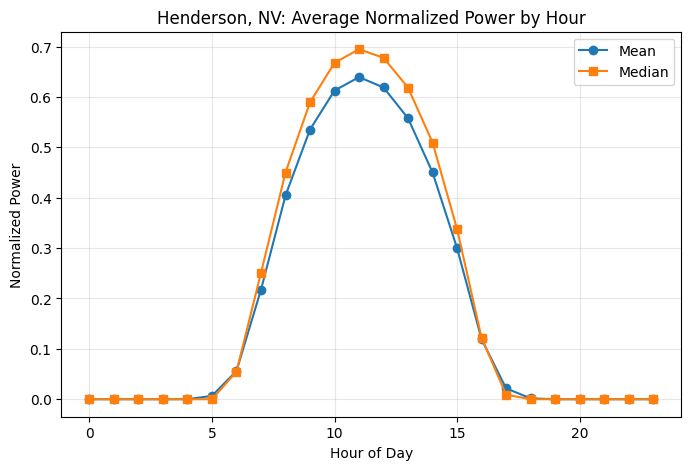

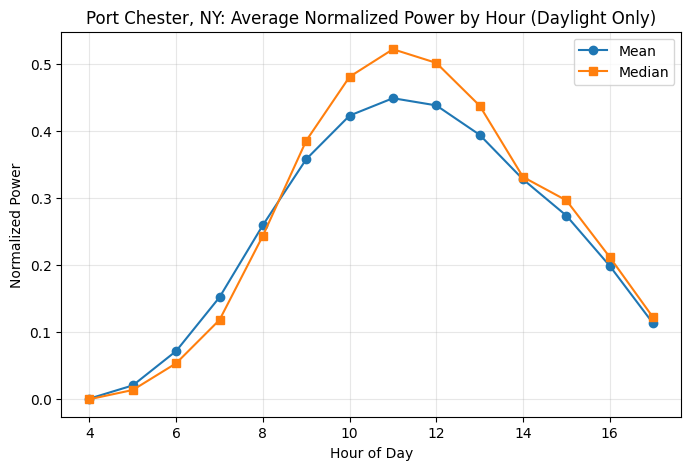

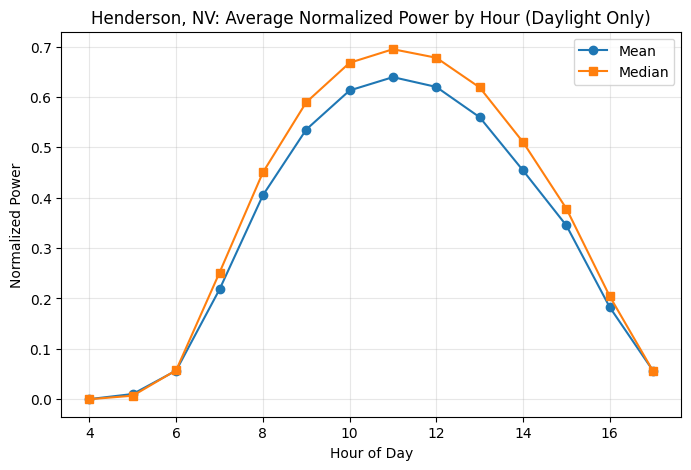

In [ ]:
# ============================================================
# Phase 10.1C : PV vs time of day
# ============================================================

print("=" * 90)
print("PV VS TIME OF DAY")
print("=" * 90)

for name, df in [("Port Chester, NY", eda_1226), ("Henderson, NV", eda_1423)]:
    grouped_profile(
        df,
        group_col="hour",
        y_col="normalized_power",
        title=f"{name}: Average Normalized Power by Hour",
        xlabel="Hour of Day",
        ylabel="Normalized Power",
        daylight_only=False
    )

# Daylight-only view can also be useful
for name, df in [("Port Chester, NY", eda_1226), ("Henderson, NV", eda_1423)]:
    grouped_profile(
        df,
        group_col="hour",
        y_col="normalized_power",
        title=f"{name}: Average Normalized Power by Hour (Daylight Only)",
        xlabel="Hour of Day",
        ylabel="Normalized Power",
        daylight_only=True
    )

PV VS SEASON


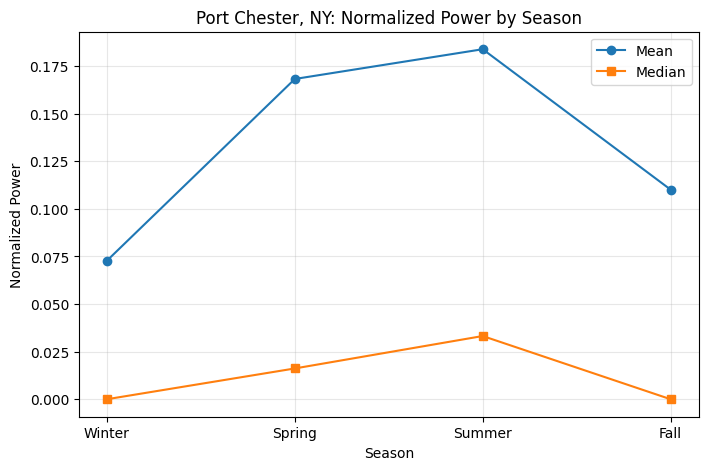

,season,mean,median,count
0,Winter,0.072806,0.000000,7383
1,Spring,0.168267,0.016169,7158
2,Summer,0.183898,0.033203,8704
3,Fall,0.110127,0.000000,8023


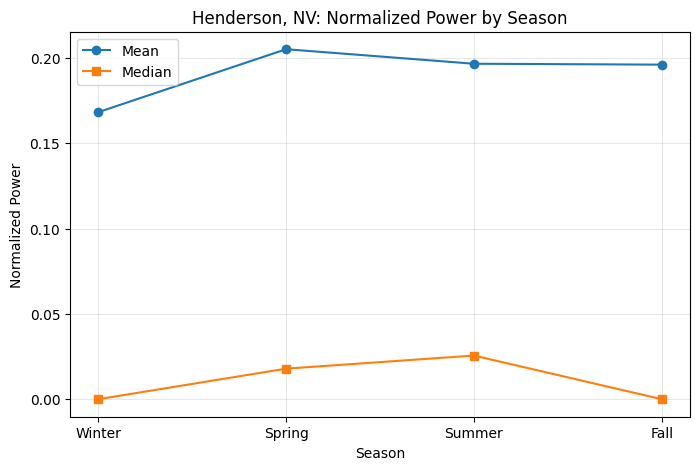

,season,mean,median,count
0,Winter,0.168156,0.000000,7651
1,Spring,0.205032,0.017904,5180
2,Summer,0.196528,0.025585,5665
3,Fall,0.195994,0.000000,5249


In [ ]:
# ============================================================
# Phase 10.1D : PV vs season
# ============================================================

print("=" * 90)
print("PV VS SEASON")
print("=" * 90)

season_order = ["Winter", "Spring", "Summer", "Fall"]

for name, df in [("Port Chester, NY", eda_1226), ("Henderson, NV", eda_1423)]:
    temp = df[["season", "normalized_power"]].dropna().copy()
    temp["season"] = pd.Categorical(temp["season"], categories=season_order, ordered=True)

    summary = temp.groupby("season", observed=False)["normalized_power"].agg(["mean", "median", "count"]).reset_index()

    plt.figure(figsize=(8, 5))
    plt.plot(summary["season"], summary["mean"], marker="o", label="Mean")
    plt.plot(summary["season"], summary["median"], marker="s", label="Median")
    plt.title(f"{name}: Normalized Power by Season")
    plt.xlabel("Season")
    plt.ylabel("Normalized Power")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    display(summary)

PV VS CARBON INTENSITY
Important note: these plots use only rows where carbon intensity is available.

Port Chester, NY
Usable carbon rows: 0
Skipping: no carbon data available.

Henderson, NV
Usable carbon rows: 54002
Henderson, NV (carbon-available rows): Pearson correlation between carbon_intensity_gco2_per_kwh and normalized_power = -0.4961 (n=18383)


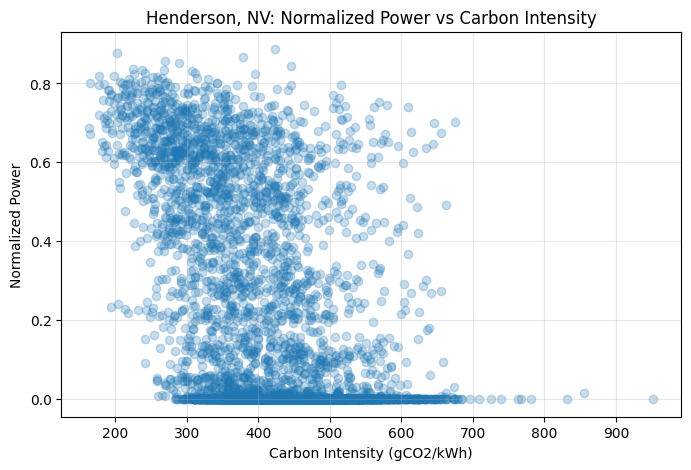

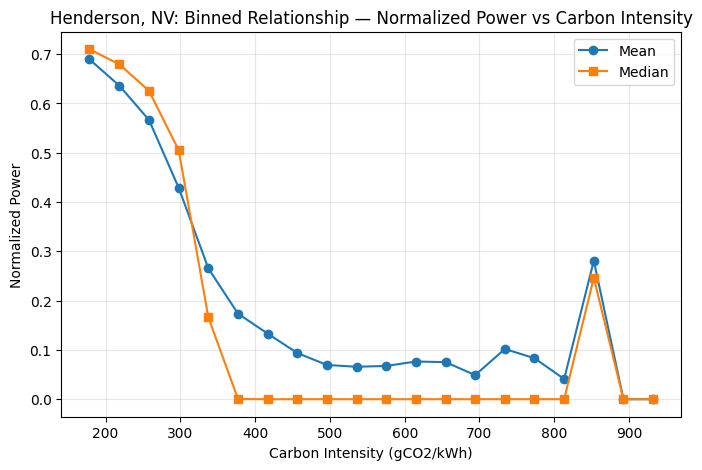

In [ ]:
# ============================================================
# Phase 10.1E : PV vs carbon intensity
# ============================================================

print("=" * 90)
print("PV VS CARBON INTENSITY")
print("=" * 90)
print("Important note: these plots use only rows where carbon intensity is available.")

for name, df in [("Port Chester, NY", eda_1226), ("Henderson, NV", eda_1423)]:
    usable = df[df["carbon_intensity_gco2_per_kwh"].notna()].copy()
    print(f"\n{name}")
    print("Usable carbon rows:", len(usable))

    if len(usable) == 0:
        print("Skipping: no carbon data available.")
        continue

    print_basic_relationship_summary(
        usable,
        "carbon_intensity_gco2_per_kwh",
        "normalized_power",
        name=f"{name} (carbon-available rows)"
    )

    sampled_scatter(
        usable,
        x_col="carbon_intensity_gco2_per_kwh",
        y_col="normalized_power",
        title=f"{name}: Normalized Power vs Carbon Intensity",
        xlabel="Carbon Intensity (gCO2/kWh)",
        ylabel="Normalized Power",
        carbon_required=True
    )

    binned_line(
        usable,
        x_col="carbon_intensity_gco2_per_kwh",
        y_col="normalized_power",
        bins=20,
        title=f"{name}: Binned Relationship : Normalized Power vs Carbon Intensity",
        xlabel="Carbon Intensity (gCO2/kWh)",
        ylabel="Normalized Power",
        carbon_required=True
    )

### 13.2 Correlation analysis
Next, we quantify pairwise relationships and identify which variables are the strongest predictors of PV output.

In [ ]:
# ============================================================
# Phase 10.2A : Pairwise correlations
# ============================================================

numeric_cols = [
    "power_kw",
    "normalized_power",
    "ghi",
    "clearsky_ghi",
    "dni",
    "dhi",
    "temperature_c",
    "wind_speed_mps",
    "relative_humidity",
    "dew_point_c",
    "pressure_mbar",
    "hour",
    "month",
    "dayofyear",
    "carbon_intensity_gco2_per_kwh"
]

def correlation_table(df, name, target_col="normalized_power", daylight_only=False):
    temp = df.copy()

    if daylight_only:
        temp = temp[temp["is_daylight"]]

    corr_df = temp[numeric_cols].copy()
    corr_matrix = corr_df.corr()

    print("=" * 90)
    print(f"CORRELATION MATRIX: {name}" + (" (Daylight Only)" if daylight_only else ""))
    print("=" * 90)
    display(corr_matrix.round(3))

    target_corr = corr_matrix[target_col].drop(labels=[target_col]).sort_values(key=np.abs, ascending=False)

    print(f"\nStrongest correlations with {target_col}:")
    display(target_corr.to_frame(name="correlation").round(3))

    return corr_matrix, target_corr

corr_1226_all, target_corr_1226_all = correlation_table(eda_1226, "Port Chester, NY", daylight_only=False)
corr_1423_all, target_corr_1423_all = correlation_table(eda_1423, "Henderson, NV", daylight_only=False)

corr_1226_day, target_corr_1226_day = correlation_table(eda_1226, "Port Chester, NY", daylight_only=True)
corr_1423_day, target_corr_1423_day = correlation_table(eda_1423, "Henderson, NV", daylight_only=True)

CORRELATION MATRIX: Port Chester, NY


,power_kw,normalized_power,ghi,clearsky_ghi,dni,dhi,temperature_c,wind_speed_mps,relative_humidity,dew_point_c,pressure_mbar,hour,month,dayofyear,carbon_intensity_gco2_per_kwh
power_kw,1.000,1.000,0.890,0.817,0.758,0.604,0.378,0.059,-0.757,0.092,0.001,-0.014,-0.042,-0.043,NaN
normalized_power,1.000,1.000,0.890,0.817,0.758,0.604,0.378,0.059,-0.757,0.092,0.001,-0.014,-0.042,-0.043,NaN
ghi,0.890,0.890,1.000,0.907,0.844,0.666,0.419,0.051,-0.740,0.138,-0.005,-0.106,-0.057,-0.058,NaN
clearsky_ghi,0.817,0.817,0.907,1.000,0.644,0.815,0.429,0.111,-0.687,0.174,-0.063,-0.121,-0.066,-0.066,NaN
dni,0.758,0.758,0.844,0.644,1.000,0.283,0.269,0.047,-0.672,0.013,0.075,-0.097,-0.031,-0.032,NaN
dhi,0.604,0.604,0.666,0.815,0.283,1.000,0.358,0.092,-0.520,0.174,-0.078,-0.098,-0.061,-0.060,NaN
temperature_c,0.378,0.378,0.419,0.429,0.269,0.358,1.000,-0.296,-0.226,0.928,-0.273,0.034,0.244,0.241,NaN
wind_speed_mps,0.059,0.059,0.051,0.111,0.047,0.092,-0.296,1.000,-0.088,-0.325,-0.250,-0.010,-0.184,-0.181,NaN
relative_humidity,-0.757,-0.757,-0.740,-0.687,-0.672,-0.520,-0.226,-0.088,1.000,0.150,-0.124,-0.004,-0.019,-0.019,NaN
dew_point_c,0.092,0.092,0.138,0.174,0.013,0.174,0.928,-0.325,0.150,1.000,-0.323,0.035,0.239,0.236,NaN



Strongest correlations with normalized_power:


,correlation
power_kw,1.000
ghi,0.890
clearsky_ghi,0.817
dni,0.758
relative_humidity,-0.757
dhi,0.604
temperature_c,0.378
dew_point_c,0.092
wind_speed_mps,0.059
dayofyear,-0.043


CORRELATION MATRIX: Henderson, NV


...

,correlation
power_kw,1.000
ghi,0.800
relative_humidity,-0.701
clearsky_ghi,0.650
dni,0.597
temperature_c,0.308
hour,0.291
dhi,0.259
pressure_mbar,0.046
dayofyear,-0.045


CORRELATION MATRIX: Henderson, NV (Daylight Only)


,power_kw,normalized_power,ghi,clearsky_ghi,dni,dhi,temperature_c,wind_speed_mps,relative_humidity,dew_point_c,pressure_mbar,hour,month,dayofyear,carbon_intensity_gco2_per_kwh
power_kw,1.000,1.000,0.690,0.646,0.610,0.142,0.172,0.098,-0.442,-0.256,0.018,0.406,-0.003,-0.003,-0.479
normalized_power,1.000,1.000,0.690,0.646,0.610,0.142,0.172,0.098,-0.442,-0.256,0.018,0.406,-0.003,-0.003,-0.479
ghi,0.690,0.690,1.000,0.936,0.732,0.296,0.471,0.164,-0.478,-0.018,-0.074,-0.029,-0.035,-0.037,-0.305
clearsky_ghi,0.646,0.646,0.936,1.000,0.525,0.495,0.456,0.201,-0.399,0.051,-0.108,-0.015,-0.061,-0.063,-0.307
dni,0.610,0.610,0.732,0.525,1.000,-0.262,0.215,0.100,-0.473,-0.267,0.097,-0.068,0.058,0.056,-0.206
dhi,0.142,0.142,0.296,0.495,-0.262,1.000,0.198,0.130,-0.037,0.202,-0.128,0.030,-0.111,-0.110,-0.120
temperature_c,0.172,0.172,0.471,0.456,0.215,0.198,1.000,-0.022,-0.574,0.443,-0.338,0.211,0.193,0.188,-0.135
wind_speed_mps,0.098,0.098,0.164,0.201,0.100,0.130,-0.022,1.000,-0.030,-0.063,-0.223,-0.039,-0.077,-0.076,-0.103
relative_humidity,-0.442,-0.442,-0.478,-0.399,-0.473,-0.037,-0.574,-0.030,1.000,0.403,0.119,-0.266,-0.135,-0.132,0.257
dew_point_c,-0.256,-0.256,-0.018,0.051,-0.267,0.202,0.443,-0.063,0.403,1.000,-0.179,-0.079,0.081,0.080,0.128



Strongest correlations with normalized_power:


,correlation
power_kw,1.000
ghi,0.690
clearsky_ghi,0.646
dni,0.610
carbon_intensity_gco2_per_kwh,-0.479
relative_humidity,-0.442
hour,0.406
dew_point_c,-0.256
temperature_c,0.172
dhi,0.142


In [ ]:
# ============================================================
# Phase 10.2B : Strongest predictors side-by-side
# ============================================================

top_corr_compare = pd.DataFrame({
    "NY_all": target_corr_1226_all,
    "NV_all": target_corr_1423_all,
    "NY_daylight": target_corr_1226_day,
    "NV_daylight": target_corr_1423_day
})

print("=" * 90)
print("STRONGEST PREDICTORS OF NORMALIZED POWER : SIDE BY SIDE")
print("=" * 90)
display(top_corr_compare.round(3))

STRONGEST PREDICTORS OF NORMALIZED POWER — SIDE BY SIDE


,NY_all,NV_all,NY_daylight,NV_daylight
carbon_intensity_gco2_per_kwh,NaN,-0.496,NaN,-0.479
clearsky_ghi,0.817,0.847,0.650,0.646
dayofyear,-0.043,-0.015,-0.045,-0.003
dew_point_c,0.092,-0.113,0.025,-0.256
dhi,0.604,0.597,0.259,0.142
dni,0.758,0.836,0.597,0.610
ghi,0.890,0.860,0.800,0.690
hour,-0.014,-0.031,0.291,0.406
month,-0.042,-0.015,-0.045,-0.003
power_kw,1.000,1.000,1.000,1.000


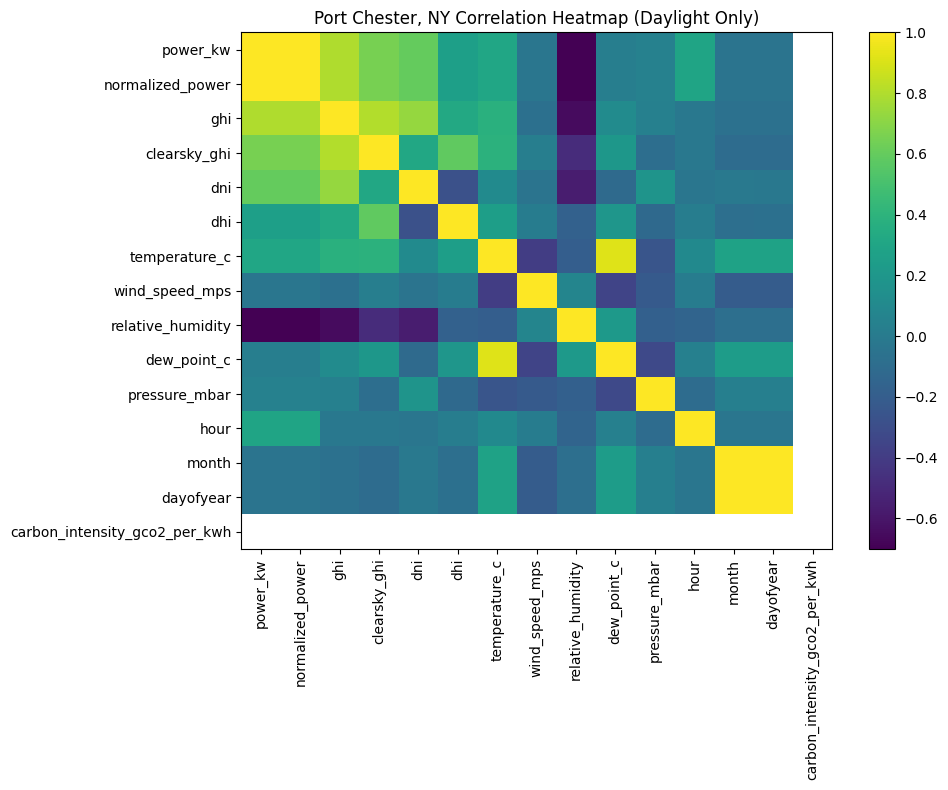

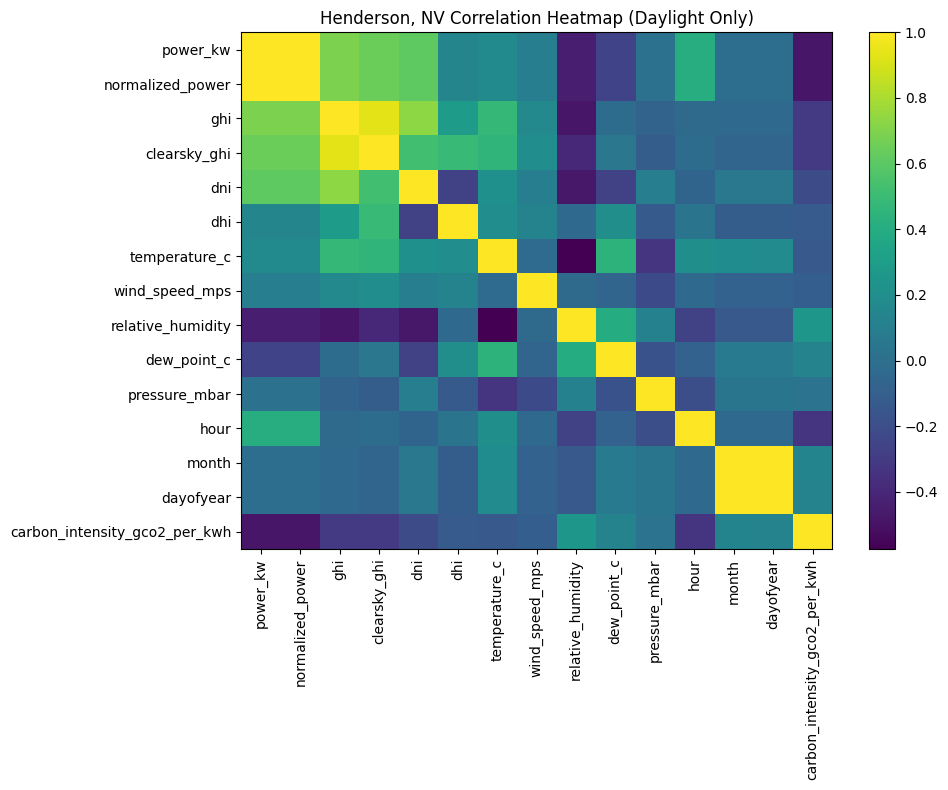

In [ ]:
# ============================================================
# Phase 10.2C : Optional heatmaps without seaborn
# ============================================================

def plot_corr_heatmap(corr_matrix, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(corr_matrix, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_corr_heatmap(corr_1226_day, "Port Chester, NY Correlation Heatmap (Daylight Only)")
plot_corr_heatmap(corr_1423_day, "Henderson, NV Correlation Heatmap (Daylight Only)")

### 13.3 Site comparison in merged space
We now compare the two sites directly in the merged feature space to understand how similar weather conditions translate into different PV behavior and how carbon intensity overlaps with production timing.

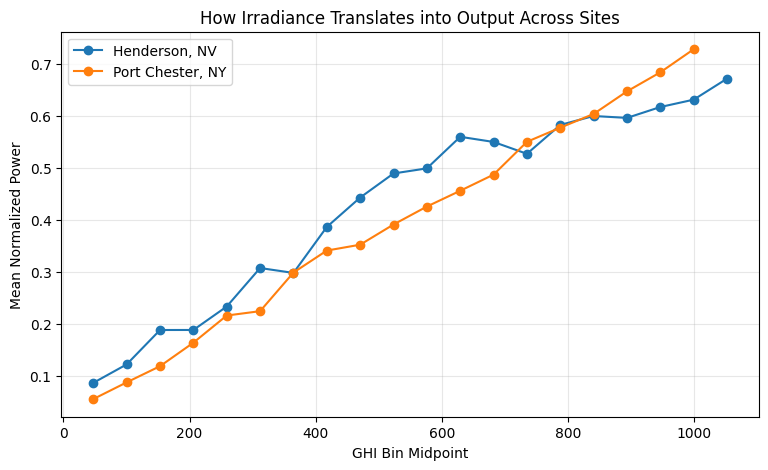

,site_name,ghi_bin,mean,median,count,ghi_mid
0,"Henderson, NV","(19.942, 73.9]",0.086201,0.049532,881,46.921
1,"Henderson, NV","(73.9, 126.8]",0.122080,0.032387,681,100.350
2,"Henderson, NV","(126.8, 179.7]",0.188256,0.135245,747,153.250
3,"Henderson, NV","(179.7, 232.6]",0.188322,0.169356,619,206.150
4,"Henderson, NV","(232.6, 285.5]",0.233443,0.168520,519,259.050
5,"Henderson, NV","(285.5, 338.4]",0.307542,0.253598,613,311.950
6,"Henderson, NV","(338.4, 391.3]",0.298116,0.272103,601,364.850
7,"Henderson, NV","(391.3, 444.2]",0.386564,0.391868,658,417.750
8,"Henderson, NV","(444.2, 497.1]",0.443160,0.457463,594,470.650
9,"Henderson, NV","(497.1, 550.0]",0.489513,0.540462,696,523.550


In [ ]:
# ============================================================
# Phase 10.3A : Compare how irradiance translates into output
# ============================================================

comparison_df = merged_all[["site_name", "ghi", "normalized_power", "is_daylight"]].dropna().copy()
comparison_df = comparison_df[comparison_df["is_daylight"]]

comparison_df["ghi_bin"] = pd.cut(comparison_df["ghi"], bins=20)

irradiance_response = (
    comparison_df.groupby(["site_name", "ghi_bin"], observed=False)["normalized_power"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

irradiance_response["ghi_mid"] = irradiance_response["ghi_bin"].apply(lambda x: x.mid)

plt.figure(figsize=(9, 5))
for site in irradiance_response["site_name"].unique():
    temp = irradiance_response[irradiance_response["site_name"] == site]
    plt.plot(temp["ghi_mid"], temp["mean"], marker="o", label=site)

plt.title("How Irradiance Translates into Output Across Sites")
plt.xlabel("GHI Bin Midpoint")
plt.ylabel("Mean Normalized Power")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

display(irradiance_response.head(20))

In [ ]:
# ============================================================
# Phase 10.3B : Site behavior under similar weather conditions
# ============================================================

weather_compare = merged_all[
    ["site_name", "normalized_power", "ghi", "temperature_c", "wind_speed_mps", "is_daylight"]
].dropna().copy()

weather_compare = weather_compare[weather_compare["is_daylight"]]

# Create coarse comparable weather bins
weather_compare["ghi_band"] = pd.cut(weather_compare["ghi"], bins=[0, 100, 300, 500, 700, 900, 1200])
weather_compare["temp_band"] = pd.cut(weather_compare["temperature_c"], bins=[-20, 0, 10, 20, 30, 40, 50])

weather_condition_summary = (
    weather_compare.groupby(["site_name", "ghi_band", "temp_band"], observed=False)["normalized_power"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

weather_condition_summary = weather_condition_summary[weather_condition_summary["count"] >= 30].copy()

print("=" * 90)
print("SITE BEHAVIOR UNDER SIMILAR WEATHER CONDITIONS")
print("=" * 90)
display(weather_condition_summary.sort_values(["ghi_band", "temp_band", "site_name"]).head(50))

SITE BEHAVIOR UNDER SIMILAR WEATHER CONDITIONS


,site_name,ghi_band,temp_band,mean,median,count
36,"Port Chester, NY","(0, 100]","(-20, 0]",0.050156,0.000000,289
1,"Henderson, NV","(0, 100]","(0, 10]",0.062208,0.000000,346
37,"Port Chester, NY","(0, 100]","(0, 10]",0.055782,0.023355,846
2,"Henderson, NV","(0, 100]","(10, 20]",0.119274,0.070174,370
38,"Port Chester, NY","(0, 100]","(10, 20]",0.062538,0.032532,844
3,"Henderson, NV","(0, 100]","(20, 30]",0.088183,0.048391,270
39,"Port Chester, NY","(0, 100]","(20, 30]",0.080333,0.072035,653
4,"Henderson, NV","(0, 100]","(30, 40]",0.090985,0.058429,251
42,"Port Chester, NY","(100, 300]","(-20, 0]",0.123330,0.056190,395
7,"Henderson, NV","(100, 300]","(0, 10]",0.149897,0.061147,475


CARBON + SOLAR TIMING PROFILE: Port Chester, NY
Usable rows: 0
Skipping: no overlapping solar/carbon rows.
CARBON + SOLAR TIMING PROFILE: Henderson, NV
Usable rows: 18383


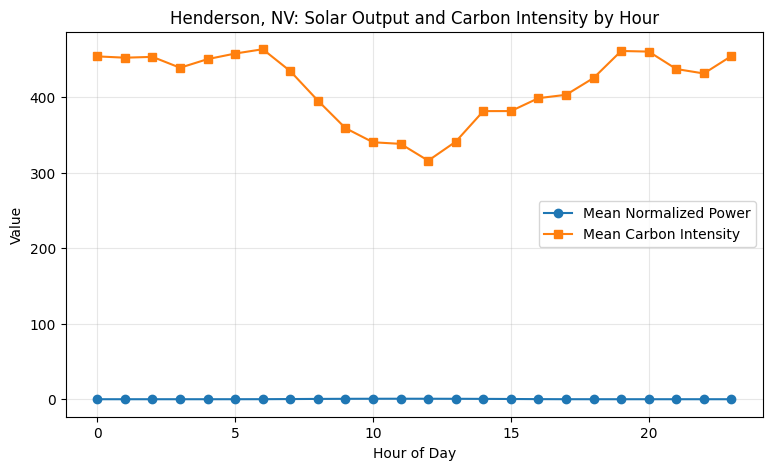

,hour,normalized_power,carbon_intensity_gco2_per_kwh
0,0,0.000000,453.659269
1,1,0.000000,451.943864
2,2,0.000000,453.031373
3,3,0.000000,438.630548
4,4,0.000092,450.061358
5,5,0.006878,457.436031
6,6,0.056894,463.151436
7,7,0.221108,434.082353
8,8,0.411263,395.107330
9,9,0.543733,358.709424


In [ ]:
# ============================================================
# Phase 10.3C : Carbon intensity co-varies with solar generation timing
# ============================================================

for name, df in [("Port Chester, NY", eda_1226), ("Henderson, NV", eda_1423)]:
    temp = df[["hour", "normalized_power", "carbon_intensity_gco2_per_kwh"]].dropna().copy()

    print("=" * 90)
    print(f"CARBON + SOLAR TIMING PROFILE: {name}")
    print("=" * 90)
    print("Usable rows:", len(temp))

    if len(temp) == 0:
        print("Skipping: no overlapping solar/carbon rows.")
        continue

    hourly_profile = temp.groupby("hour").agg({
        "normalized_power": "mean",
        "carbon_intensity_gco2_per_kwh": "mean"
    }).reset_index()

    plt.figure(figsize=(9, 5))
    plt.plot(hourly_profile["hour"], hourly_profile["normalized_power"], marker="o", label="Mean Normalized Power")
    plt.plot(hourly_profile["hour"], hourly_profile["carbon_intensity_gco2_per_kwh"], marker="s", label="Mean Carbon Intensity")
    plt.title(f"{name}: Solar Output and Carbon Intensity by Hour")
    plt.xlabel("Hour of Day")
    plt.ylabel("Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    display(hourly_profile)

In [ ]:
# ============================================================
# Phase 10.3D : Final comparison tables for report use
# ============================================================

def site_summary_for_report(df, site_label):
    usable = df.copy()

    row = {
        "site": site_label,
        "rows": len(usable),
        "daylight_rows": usable["is_daylight"].sum(),
        "mean_power_kw": usable["power_kw"].mean(),
        "mean_normalized_power": usable["normalized_power"].mean(),
        "mean_ghi": usable["ghi"].mean(),
        "mean_temperature_c": usable["temperature_c"].mean(),
        "mean_wind_speed_mps": usable["wind_speed_mps"].mean(),
        "mean_relative_humidity": usable["relative_humidity"].mean(),
        "carbon_available_rows": usable["carbon_intensity_gco2_per_kwh"].notna().sum(),
        "mean_carbon_intensity": usable["carbon_intensity_gco2_per_kwh"].mean()
    }
    return row

phase10_site_summary = pd.DataFrame([
    site_summary_for_report(eda_1226, "Port Chester, NY"),
    site_summary_for_report(eda_1423, "Henderson, NV")
])

print("=" * 90)
print("PHASE 10 SITE SUMMARY TABLE")
print("=" * 90)
display(phase10_site_summary.round(3))

PHASE 10 SITE SUMMARY TABLE


,site,rows,daylight_rows,mean_power_kw,mean_normalized_power,mean_ghi,mean_temperature_c,mean_wind_speed_mps,mean_relative_humidity,carbon_available_rows,mean_carbon_intensity
0,"Port Chester, NY",32905,15292,0.520,0.135,173.254,11.935,1.54,79.688,0,NaN
1,"Henderson, NV",63685,30553,1.324,0.189,235.437,19.775,2.60,30.826,54002,422.163


## Phase 11 : Feature Engineering

This phase creates the main predictive features used for modeling.

Planned feature groups:
1. Temporal features
   - hour of day
   - day of year
   - month
   - season
   - weekday/weekend

2. Cyclical encodings
   - hour_sin, hour_cos
   - doy_sin, doy_cos

3. Lag features
   - lag_1
   - lag_24
   - lag_168

4. Rolling features
   - rolling_24_mean
   - rolling_24_std

5. Cross-site comparable target-side variable
   - normalized_power = power_kw / system_capacity_kw

Why this phase matters:
- lag features encode persistence
- temporal and cyclical features encode seasonality
- rolling features encode short-term local behavior
- normalized power supports fairer cross-site comparison

In [ ]:
# ============================================================
# Phase 11.0 : Defensive copies of merged master tables
# ============================================================

site_1226_fe = master_1226.copy()
site_1423_fe = master_1423.copy()

print("=" * 90)
print("PHASE 11 START : FEATURE ENGINEERING")
print("=" * 90)

for name, df in [("Port Chester, NY", site_1226_fe), ("Henderson, NV", site_1423_fe)]:
    print(f"\n{name}")
    print("-" * 40)
    print("Shape before feature engineering:", df.shape)
    print("Timestamp dtype:", df["timestamp"].dtype)
    print("Columns currently present:")
    print(df.columns.tolist())

PHASE 11 START — FEATURE ENGINEERING

Port Chester, NY
----------------------------------------
Shape before feature engineering: (32905, 16)
Timestamp dtype: datetime64[ns]
Columns currently present:
['timestamp', 'site_id', 'power_kw', 'normalized_power', 'system_capacity_kw', 'ghi', 'clearsky_ghi', 'dni', 'dhi', 'temperature_c', 'wind_speed_mps', 'relative_humidity', 'dew_point_c', 'pressure_mbar', 'zone', 'carbon_intensity_gco2_per_kwh']

Henderson, NV
----------------------------------------
Shape before feature engineering: (63685, 16)
Timestamp dtype: datetime64[ns]
Columns currently present:
['timestamp', 'site_id', 'power_kw', 'normalized_power', 'system_capacity_kw', 'ghi', 'clearsky_ghi', 'dni', 'dhi', 'temperature_c', 'wind_speed_mps', 'relative_humidity', 'dew_point_c', 'pressure_mbar', 'zone', 'carbon_intensity_gco2_per_kwh']


In [ ]:
# ============================================================
# Phase 11.1 : Helper functions
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"


def add_phase11_features(df, site_name=""):
    """
    Add Phase 11 feature set to one merged hourly site table.

    Important design choices:
    - normalized_power is ensured/created here
    - lag features use only prior observations
    - rolling statistics are computed on shifted values to avoid leakage
    - no rows are dropped here; missingness introduced by lags/rolling is preserved
      for later handling during train/val/test construction
    """
    out = df.copy()

    # --------------------------------------------------------
    # Basic ordering / timestamp handling
    # --------------------------------------------------------
    out["timestamp"] = pd.to_datetime(out["timestamp"])
    out = out.sort_values("timestamp").reset_index(drop=True)

    # --------------------------------------------------------
    # Ensure normalized_power exists
    # --------------------------------------------------------
    if "normalized_power" not in out.columns:
        out["normalized_power"] = out["power_kw"] / out["system_capacity_kw"]
    else:
        # Recompute defensively if values are missing and ingredients exist
        missing_norm = out["normalized_power"].isna()
        if missing_norm.any():
            out.loc[missing_norm, "normalized_power"] = (
                out.loc[missing_norm, "power_kw"] / out.loc[missing_norm, "system_capacity_kw"]
            )

    # --------------------------------------------------------
    # 14.1 Temporal features
    # --------------------------------------------------------
    out["hour"] = out["timestamp"].dt.hour
    out["dayofyear"] = out["timestamp"].dt.dayofyear
    out["month"] = out["timestamp"].dt.month
    out["dayofweek"] = out["timestamp"].dt.dayofweek   # Monday=0, Sunday=6
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    out["season"] = out["month"].apply(month_to_season)

    # Optional binary daylight flag can be useful later if GHI exists
    if "ghi" in out.columns:
        out["is_daylight"] = (out["ghi"] > 20).astype(int)

    # --------------------------------------------------------
    # 14.2 Cyclical encodings
    # --------------------------------------------------------
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)

    # Use 365.25 to better respect annual cyclic structure
    out["doy_sin"] = np.sin(2 * np.pi * out["dayofyear"] / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * out["dayofyear"] / 365.25)

    # --------------------------------------------------------
    # 14.3 Lag features
    # --------------------------------------------------------
    # These encode persistence and recent history
    out["lag_1"] = out["normalized_power"].shift(1)
    out["lag_24"] = out["normalized_power"].shift(24)
    out["lag_168"] = out["normalized_power"].shift(168)

    # --------------------------------------------------------
    # 14.4 Rolling features
    # --------------------------------------------------------
    # IMPORTANT:
    # We shift by 1 before rolling so the feature at time t only uses
    # information strictly prior to time t.
    out["rolling_24_mean"] = out["normalized_power"].shift(1).rolling(window=24, min_periods=24).mean()
    out["rolling_24_std"] = out["normalized_power"].shift(1).rolling(window=24, min_periods=24).std()

    # --------------------------------------------------------
    # Optional extra short-horizon context features
    # These are not required, but are often useful and still principled.
    # --------------------------------------------------------
    out["rolling_168_mean"] = out["normalized_power"].shift(1).rolling(window=168, min_periods=168).mean()
    out["rolling_168_std"] = out["normalized_power"].shift(1).rolling(window=168, min_periods=168).std()

    # --------------------------------------------------------
    # Useful sanity checks
    # --------------------------------------------------------
    duplicate_timestamps = out["timestamp"].duplicated().sum()
    if duplicate_timestamps > 0:
        print(f"Warning for {site_name}: duplicate timestamps remain after sorting -> {duplicate_timestamps}")

    return out

In [ ]:
# ============================================================
# Phase 11.2 : Apply feature engineering to both sites
# ============================================================

site_1226_fe = add_phase11_features(site_1226_fe, site_name="Port Chester, NY")
site_1423_fe = add_phase11_features(site_1423_fe, site_name="Henderson, NV")

print("=" * 90)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 90)

for name, df in [("Port Chester, NY", site_1226_fe), ("Henderson, NV", site_1423_fe)]:
    print(f"\n{name}")
    print("-" * 40)
    print("Shape after feature engineering:", df.shape)
    print("First few engineered columns preview:")
    preview_cols = [
        "timestamp",
        "power_kw",
        "system_capacity_kw",
        "normalized_power",
        "hour",
        "dayofyear",
        "month",
        "season",
        "dayofweek",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "doy_sin",
        "doy_cos",
        "lag_1",
        "lag_24",
        "lag_168",
        "rolling_24_mean",
        "rolling_24_std"
    ]
    preview_cols = [c for c in preview_cols if c in df.columns]
    display(df[preview_cols].head(10))

FEATURE ENGINEERING COMPLETE

Port Chester, NY
----------------------------------------
Shape after feature engineering: (32905, 34)
First few engineered columns preview:


,timestamp,power_kw,system_capacity_kw,normalized_power,hour,dayofyear,month,season,dayofweek,is_weekend,hour_sin,hour_cos,doy_sin,doy_cos,lag_1,lag_24,lag_168,rolling_24_mean,rolling_24_std
0,2011-04-21 12:00:00,2.478000,3.85,0.643636,12,111,4,Spring,3,0,1.224647e-16,-1.000000e+00,0.943196,-0.332235,NaN,NaN,NaN,NaN,NaN
1,2011-04-21 13:00:00,2.923167,3.85,0.759264,13,111,4,Spring,3,0,-2.588190e-01,-9.659258e-01,0.943196,-0.332235,0.643636,NaN,NaN,NaN,NaN
2,2011-04-21 14:00:00,2.542000,3.85,0.660260,14,111,4,Spring,3,0,-5.000000e-01,-8.660254e-01,0.943196,-0.332235,0.759264,NaN,NaN,NaN,NaN
3,2011-04-21 15:00:00,1.931833,3.85,0.501775,15,111,4,Spring,3,0,-7.071068e-01,-7.071068e-01,0.943196,-0.332235,0.660260,NaN,NaN,NaN,NaN
4,2011-04-21 16:00:00,1.159833,3.85,0.301255,16,111,4,Spring,3,0,-8.660254e-01,-5.000000e-01,0.943196,-0.332235,0.501775,NaN,NaN,NaN,NaN
5,2011-04-21 17:00:00,0.383833,3.85,0.099697,17,111,4,Spring,3,0,-9.659258e-01,-2.588190e-01,0.943196,-0.332235,0.301255,NaN,NaN,NaN,NaN
6,2011-04-21 18:00:00,0.075000,3.85,0.019481,18,111,4,Spring,3,0,-1.000000e+00,-1.836970e-16,0.943196,-0.332235,0.099697,NaN,NaN,NaN,NaN
7,2011-04-21 19:00:00,NaN,3.85,NaN,19,111,4,Spring,3,0,-9.659258e-01,2.588190e-01,0.943196,-0.332235,0.019481,NaN,NaN,NaN,NaN
8,2011-04-21 20:00:00,NaN,3.85,NaN,20,111,4,Spring,3,0,-8.660254e-01,5.000000e-01,0.943196,-0.332235,NaN,NaN,NaN,NaN,NaN
9,2011-04-21 21:00:00,NaN,3.85,NaN,21,111,4,Spring,3,0,-7.071068e-01,7.071068e-01,0.943196,-0.332235,NaN,NaN,NaN,NaN,NaN



Henderson, NV
----------------------------------------
Shape after feature engineering: (63685, 34)
First few engineered columns preview:


,timestamp,power_kw,system_capacity_kw,normalized_power,hour,dayofyear,month,season,dayofweek,is_weekend,hour_sin,hour_cos,doy_sin,doy_cos,lag_1,lag_24,lag_168,rolling_24_mean,rolling_24_std
0,2015-11-24 11:00:00,5.177915,7.0,0.739702,11,328,11,Fall,1,0,2.588190e-01,-9.659258e-01,-0.597829,0.801624,NaN,NaN,NaN,NaN,NaN
1,2015-11-24 12:00:00,4.944087,7.0,0.706298,12,328,11,Fall,1,0,1.224647e-16,-1.000000e+00,-0.597829,0.801624,0.739702,NaN,NaN,NaN,NaN
2,2015-11-24 13:00:00,3.945392,7.0,0.563627,13,328,11,Fall,1,0,-2.588190e-01,-9.659258e-01,-0.597829,0.801624,0.706298,NaN,NaN,NaN,NaN
3,2015-11-24 14:00:00,3.028203,7.0,0.432600,14,328,11,Fall,1,0,-5.000000e-01,-8.660254e-01,-0.597829,0.801624,0.563627,NaN,NaN,NaN,NaN
4,2015-11-24 15:00:00,1.276852,7.0,0.182407,15,328,11,Fall,1,0,-7.071068e-01,-7.071068e-01,-0.597829,0.801624,0.432600,NaN,NaN,NaN,NaN
5,2015-11-24 16:00:00,0.136315,7.0,0.019474,16,328,11,Fall,1,0,-8.660254e-01,-5.000000e-01,-0.597829,0.801624,0.182407,NaN,NaN,NaN,NaN
6,2015-11-24 17:00:00,0.000000,7.0,0.000000,17,328,11,Fall,1,0,-9.659258e-01,-2.588190e-01,-0.597829,0.801624,0.019474,NaN,NaN,NaN,NaN
7,2015-11-24 18:00:00,0.000000,7.0,0.000000,18,328,11,Fall,1,0,-1.000000e+00,-1.836970e-16,-0.597829,0.801624,0.000000,NaN,NaN,NaN,NaN
8,2015-11-24 19:00:00,0.000000,7.0,0.000000,19,328,11,Fall,1,0,-9.659258e-01,2.588190e-01,-0.597829,0.801624,0.000000,NaN,NaN,NaN,NaN
9,2015-11-24 20:00:00,0.000000,7.0,0.000000,20,328,11,Fall,1,0,-8.660254e-01,5.000000e-01,-0.597829,0.801624,0.000000,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# Phase 11.3 : Missingness introduced by engineered features
# ============================================================

engineered_feature_cols = [
    "normalized_power",
    "hour",
    "dayofyear",
    "month",
    "season",
    "dayofweek",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_24_mean",
    "rolling_24_std",
    "rolling_168_mean",
    "rolling_168_std"
]

def summarize_feature_missingness(df, site_name):
    available_cols = [c for c in engineered_feature_cols if c in df.columns]

    summary = pd.DataFrame({
        "missing_count": df[available_cols].isna().sum(),
        "missing_pct": 100 * df[available_cols].isna().mean()
    }).sort_values("missing_count", ascending=False)

    print("=" * 90)
    print(f"MISSINGNESS SUMMARY : {site_name}")
    print("=" * 90)
    display(summary.round(3))

summarize_feature_missingness(site_1226_fe, "Port Chester, NY")
summarize_feature_missingness(site_1423_fe, "Henderson, NV")

MISSINGNESS SUMMARY — Port Chester, NY


,missing_count,missing_pct
rolling_168_mean,5568,16.921
rolling_168_std,5568,16.921
rolling_24_std,2289,6.956
rolling_24_mean,2289,6.956
lag_168,1805,5.485
lag_24,1661,5.048
lag_1,1638,4.978
normalized_power,1637,4.975
hour,0,0.000
dayofyear,0,0.000


MISSINGNESS SUMMARY — Henderson, NV


,missing_count,missing_pct
rolling_168_mean,53632,84.214
rolling_168_std,53632,84.214
rolling_24_std,47203,74.119
rolling_24_mean,47203,74.119
lag_168,40108,62.979
lag_24,39964,62.753
lag_1,39941,62.716
normalized_power,39940,62.715
hour,0,0.000
dayofyear,0,0.000


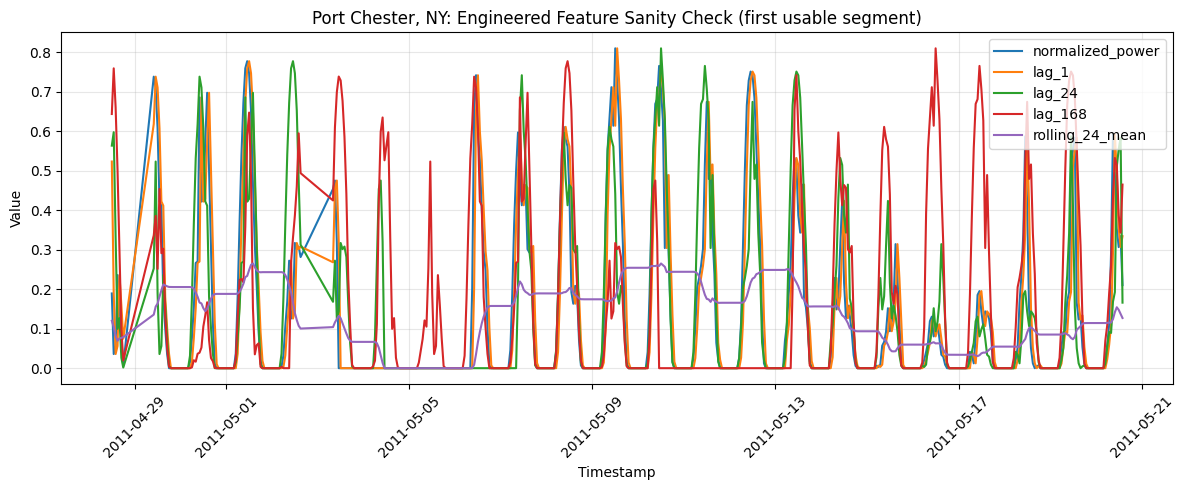

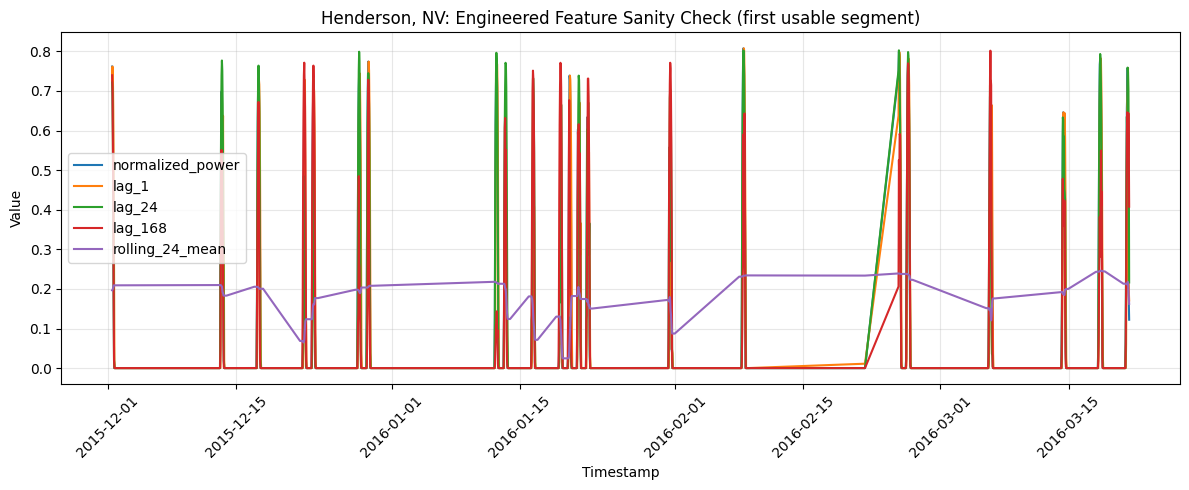

In [ ]:
# ============================================================
# Phase 11.4 : Quick sanity-check plots for engineered features
# ============================================================

def plot_feature_sanity(df, site_name):
    fig_cols = ["normalized_power", "lag_1", "lag_24", "lag_168", "rolling_24_mean"]
    fig_cols = [c for c in fig_cols if c in df.columns]

    sample = df[["timestamp"] + fig_cols].dropna().head(500).copy()

    if len(sample) == 0:
        print(f"No usable rows for sanity plot: {site_name}")
        return

    plt.figure(figsize=(12, 5))
    for col in fig_cols:
        plt.plot(sample["timestamp"], sample[col], label=col)
    plt.title(f"{site_name}: Engineered Feature Sanity Check (first usable segment)")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_feature_sanity(site_1226_fe, "Port Chester, NY")
plot_feature_sanity(site_1423_fe, "Henderson, NV")

### Phase 11 : Engineered Feature Sanity Check: Key Insights

These plots validate that the engineered features behave correctly and provide insight into the underlying data quality and structure for both sites.

---

### 🔹 Overall Interpretation
- The engineered features (`lag_1`, `lag_24`, `lag_168`, `rolling_24_mean`) behave consistently with their intended definitions.
- Temporal dependencies in solar generation are clearly reflected in the lag features.
- The plots confirm **no data leakage**: all lag and rolling features depend only on past values.
- Differences between NY and NV highlight **important dataset characteristics** that will impact modeling.

---

### 🔹 Port Chester, NY (Dense, High-Quality Signal)
- **Strong daily solar pattern**
  - Clear daytime peaks and nighttime zeros.
  - Indicates a continuous, well-behaved time series.

- **Lag features behave as expected**
  - `lag_1` closely tracks `normalized_power` with a one-hour delay → confirms correct shifting.
  - `lag_24` aligns with previous-day patterns → strong daily seasonality.
  - `lag_168` loosely follows weekly structure → captures longer-term periodicity.

- **Rolling mean is smooth and stable**
  - `rolling_24_mean` shows gradual changes rather than spikes.
  - Confirms correct use of shifted rolling window (no leakage).
  - Effectively captures short-term trends and baseline production levels.

- **Key insight**
  - NY provides a **high-quality, continuous signal** with strong temporal structure.
  - Lag and rolling features are likely to be highly informative for modeling.

---

### 🔹 Henderson, NV (Sparse, Irregular Signal)
- **Highly sparse signal**
  - Long stretches of zeros or missing-equivalent behavior.
  - Intermittent spikes rather than continuous daily curves.

- **Lag features still mathematically correct**
  - `lag_1`, `lag_24`, and `lag_168` activate only when prior observations exist.
  - No signs of misalignment or incorrect shifting.

- **Rolling mean behaves conservatively**
  - `rolling_24_mean` remains smooth and relatively low.
  - Does not spike immediately with current values → confirms no leakage.
  - Reflects limited historical continuity due to missing data.

- **Key insight**
  - NV data is **structurally sparse**, not just noisy.
  - Temporal dependencies exist but are **fragmented**, reducing predictive strength.
  - Lag and rolling features are correct but may be **less informative in practice**.

---

### 🔹 Cross-Site Insights
- **Data quality differs significantly between sites**
  - NY: dense, continuous, predictable patterns.
  - NV: sparse, irregular, fragmented observations.

- **Feature behavior reflects underlying data**
  - Same feature engineering pipeline produces:
    - strong signals for NY
    - weak/intermittent signals for NV

- **Implication for modeling**
  - NY models will benefit heavily from lag/rolling features.
  - NV models may struggle due to lack of consistent temporal continuity.
  - Cross-site generalization will be affected by these structural differences.

---

### 🔹 Why This Matters for the Project
- Validates that feature engineering is **correct and methodologically sound**.
- Confirms that lag and rolling features encode:
  - persistence (lag features)
  - seasonality (lag_24, lag_168)
  - short-term dynamics (rolling features)
- Reveals that **data sparsity is a core challenge**, especially for NV.
- Provides justification for:
  - later preprocessing decisions (e.g., filtering valid rows)
  - differences in model performance across sites
  - interpretation of robustness and generalization results

In [ ]:
# ============================================================
# Phase 11.5 : Feature summaries for report discussion
# ============================================================

def engineered_feature_summary(df, site_name):
    summary_cols = [
        "normalized_power",
        "hour",
        "dayofyear",
        "month",
        "dayofweek",
        "is_weekend",
        "hour_sin",
        "hour_cos",
        "doy_sin",
        "doy_cos",
        "lag_1",
        "lag_24",
        "lag_168",
        "rolling_24_mean",
        "rolling_24_std"
    ]
    summary_cols = [c for c in summary_cols if c in df.columns]

    summary = df[summary_cols].describe().T
    summary["site"] = site_name
    return summary.reset_index().rename(columns={"index": "feature"})

feature_summary_1226 = engineered_feature_summary(site_1226_fe, "Port Chester, NY")
feature_summary_1423 = engineered_feature_summary(site_1423_fe, "Henderson, NV")

print("=" * 90)
print("ENGINEERED FEATURE SUMMARY : PORT CHESTER, NY")
print("=" * 90)
display(feature_summary_1226)

print("=" * 90)
print("ENGINEERED FEATURE SUMMARY : HENDERSON, NV")
print("=" * 90)
display(feature_summary_1423)

ENGINEERED FEATURE SUMMARY — PORT CHESTER, NY


,feature,count,mean,std,min,25%,50%,75%,max,site
0,normalized_power,31268.0,1.351597e-01,0.214064,0.000000,0.000000,0.000000e+00,0.208409,0.855022,"Port Chester, NY"
1,hour,32905.0,1.150002e+01,6.922187,0.000000,6.000000,1.200000e+01,17.000000,23.000000,"Port Chester, NY"
2,dayofyear,32905.0,1.908088e+02,104.134529,1.000000,108.000000,1.940000e+02,280.000000,366.000000,"Port Chester, NY"
3,month,32905.0,6.774806e+00,3.403614,1.000000,4.000000,7.000000e+00,10.000000,12.000000,"Port Chester, NY"
4,dayofweek,32905.0,3.000334e+00,2.000646,0.000000,1.000000,3.000000e+00,5.000000,6.000000,"Port Chester, NY"
5,is_weekend,32905.0,2.859140e-01,0.451855,0.000000,0.000000,0.000000e+00,1.000000,1.000000,"Port Chester, NY"
6,hour_sin,32905.0,-1.848966e-17,0.707107,-1.000000,-0.707107,1.224647e-16,0.707107,1.000000,"Port Chester, NY"
7,hour_cos,32905.0,-3.039052e-05,0.707128,-1.000000,-0.707107,-1.836970e-16,0.707107,1.000000,"Port Chester, NY"
8,doy_sin,32905.0,-5.373256e-02,0.695317,-0.999999,-0.739392,-9.233133e-02,0.630072,0.999986,"Port Chester, NY"
9,doy_cos,32905.0,-2.497613e-02,0.716278,-0.999979,-0.743001,-6.339140e-02,0.702913,0.999991,"Port Chester, NY"


ENGINEERED FEATURE SUMMARY — HENDERSON, NV


,feature,count,mean,std,min,25%,50%,75%,max,site
0,normalized_power,23745.0,0.189123,0.262344,0.000000,0.000000,9.526477e-04,0.394478,0.886606,"Henderson, NV"
1,hour,63685.0,11.501123,6.922187,0.000000,6.000000,1.200000e+01,18.000000,23.000000,"Henderson, NV"
2,dayofyear,63685.0,182.052414,107.805778,1.000000,87.000000,1.820000e+02,276.000000,366.000000,"Henderson, NV"
3,month,63685.0,6.485279,3.525975,1.000000,3.000000,6.000000e+00,10.000000,12.000000,"Henderson, NV"
4,dayofweek,63685.0,2.999592,2.000016,0.000000,1.000000,3.000000e+00,5.000000,6.000000,"Henderson, NV"
5,is_weekend,63685.0,0.285656,0.451730,0.000000,0.000000,0.000000e+00,1.000000,1.000000,"Henderson, NV"
6,hour_sin,63685.0,-0.000115,0.707108,-1.000000,-0.707107,0.000000e+00,0.707107,1.000000,"Henderson, NV"
7,hour_cos,63685.0,-0.000031,0.707117,-1.000000,-0.707107,-1.836970e-16,0.707107,1.000000,"Henderson, NV"
8,doy_sin,63685.0,0.006157,0.699894,-0.999999,-0.689796,1.290146e-02,0.699079,0.999986,"Henderson, NV"
9,doy_cos,63685.0,0.031817,0.713522,-0.999979,-0.685894,5.695220e-02,0.750154,0.999991,"Henderson, NV"


In [ ]:
# ============================================================
# Phase 11.6 : Final feature inventory
# ============================================================

core_temporal_features = [
    "hour", "dayofyear", "month", "season", "dayofweek", "is_weekend"
]

core_cyclical_features = [
    "hour_sin", "hour_cos", "doy_sin", "doy_cos"
]

core_lag_features = [
    "lag_1", "lag_24", "lag_168"
]

core_rolling_features = [
    "rolling_24_mean", "rolling_24_std",
    "rolling_168_mean", "rolling_168_std"
]

candidate_weather_features = [
    "ghi", "clearsky_ghi", "dni", "dhi",
    "temperature_c", "wind_speed_mps",
    "relative_humidity", "dew_point_c", "pressure_mbar"
]

candidate_carbon_features = [
    "carbon_intensity_gco2_per_kwh"
]

final_feature_inventory = {
    "target_side_variable": ["normalized_power"],
    "temporal_features": [c for c in core_temporal_features if c in site_1226_fe.columns or c in site_1423_fe.columns],
    "cyclical_features": [c for c in core_cyclical_features if c in site_1226_fe.columns or c in site_1423_fe.columns],
    "lag_features": [c for c in core_lag_features if c in site_1226_fe.columns or c in site_1423_fe.columns],
    "rolling_features": [c for c in core_rolling_features if c in site_1226_fe.columns or c in site_1423_fe.columns],
    "weather_features": [c for c in candidate_weather_features if c in site_1226_fe.columns or c in site_1423_fe.columns],
    "carbon_features": [c for c in candidate_carbon_features if c in site_1226_fe.columns or c in site_1423_fe.columns],
}

print("=" * 90)
print("PHASE 11 FINAL FEATURE INVENTORY")
print("=" * 90)
for k, v in final_feature_inventory.items():
    print(f"\n{k}:")
    print(v)

PHASE 11 FINAL FEATURE INVENTORY

target_side_variable:
['normalized_power']

temporal_features:
['hour', 'dayofyear', 'month', 'season', 'dayofweek', 'is_weekend']

cyclical_features:
['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']

lag_features:
['lag_1', 'lag_24', 'lag_168']

rolling_features:
['rolling_24_mean', 'rolling_24_std', 'rolling_168_mean', 'rolling_168_std']

weather_features:
['ghi', 'clearsky_ghi', 'dni', 'dhi', 'temperature_c', 'wind_speed_mps', 'relative_humidity', 'dew_point_c', 'pressure_mbar']

carbon_features:
['carbon_intensity_gco2_per_kwh']


In [ ]:
# ============================================================
# Phase 11.7 : Save Phase 11 outputs for next phases
# ============================================================

# These are the engineered merged tables that should feed Phase 12 onward.
master_1226_fe = site_1226_fe.copy()
master_1423_fe = site_1423_fe.copy()

print("Saved Phase 11 outputs:")
print(" - master_1226_fe")
print(" - master_1423_fe")

Saved Phase 11 outputs:
 - master_1226_fe
 - master_1423_fe


## Phase 12 : Define Target as t + 24

We now convert the dataset into a supervised learning problem.

Forecast objective:
- Input features at time t
- Predict solar output at time t + 24 (day-ahead forecasting)

Target definition:
- target = normalized_power.shift(-24)

Design choices:
- We use normalized_power as the target to enable cross-site comparison
- We do NOT impute missing target values
- Rows where the shifted target is unavailable will be removed only when constructing the modeling dataset

This phase produces:
1. Full dataset with target (for analysis/debugging)
2. Clean modeling dataset (for training later)

In [ ]:
# ============================================================
# Phase 12.1 : Create day-ahead target (t + 24)
# ============================================================

master_1226_fe["target"] = master_1226_fe["normalized_power"].shift(-24)
master_1423_fe["target"] = master_1423_fe["normalized_power"].shift(-24)

print("=" * 90)
print("TARGET CREATION COMPLETE")
print("=" * 90)

for name, df in [("Port Chester, NY", master_1226_fe),
                 ("Henderson, NV", master_1423_fe)]:

    print(f"\n{name}")
    print("-" * 40)
    print("Total rows:", len(df))
    print("Target missing:", df["target"].isna().sum())
    print("Target missing %:", df["target"].isna().mean())

TARGET CREATION COMPLETE

Port Chester, NY
----------------------------------------
Total rows: 32905
Target missing: 1646
Target missing %: 0.05002279288861875

Henderson, NV
----------------------------------------
Total rows: 63685
Target missing: 39964
Target missing %: 0.6275261050482845


In [ ]:
# ============================================================
# Phase 12.2 : Alignment sanity check
# ============================================================

def check_target_alignment(df, site_name):
    print("=" * 90)
    print(f"TARGET ALIGNMENT CHECK : {site_name}")
    print("=" * 90)

    sample = df[["timestamp", "normalized_power", "target"]].dropna().head(5).copy()

    for i in range(len(sample)):
        current_time = sample.iloc[i]["timestamp"]
        target_time = df.loc[df["timestamp"] == current_time + pd.Timedelta(hours=24)]

        if len(target_time) > 0:
            expected = target_time["normalized_power"].values[0]
            actual = sample.iloc[i]["target"]

            print(f"t = {current_time}")
            print(f"Expected t+24 value: {expected:.6f}")
            print(f"Stored target:       {actual:.6f}")
            print("-" * 40)

check_target_alignment(master_1226_fe, "Port Chester, NY")
check_target_alignment(master_1423_fe, "Henderson, NV")

TARGET ALIGNMENT CHECK — Port Chester, NY
t = 2011-04-21 12:00:00
Expected t+24 value: 0.251472
Stored target:       0.251472
----------------------------------------
t = 2011-04-21 13:00:00
Expected t+24 value: 0.453939
Stored target:       0.453939
----------------------------------------
t = 2011-04-21 14:00:00
Expected t+24 value: 0.291126
Stored target:       0.291126
----------------------------------------
t = 2011-04-21 15:00:00
Expected t+24 value: 0.302641
Stored target:       0.302641
----------------------------------------
t = 2011-04-21 16:00:00
Expected t+24 value: 0.133506
Stored target:       0.133506
----------------------------------------
TARGET ALIGNMENT CHECK — Henderson, NV
t = 2015-11-24 11:00:00
Expected t+24 value: 0.762082
Stored target:       0.762082
----------------------------------------
t = 2015-11-24 12:00:00
Expected t+24 value: 0.736910
Stored target:       0.736910
----------------------------------------
t = 2015-11-24 13:00:00
Expected t+24 value:

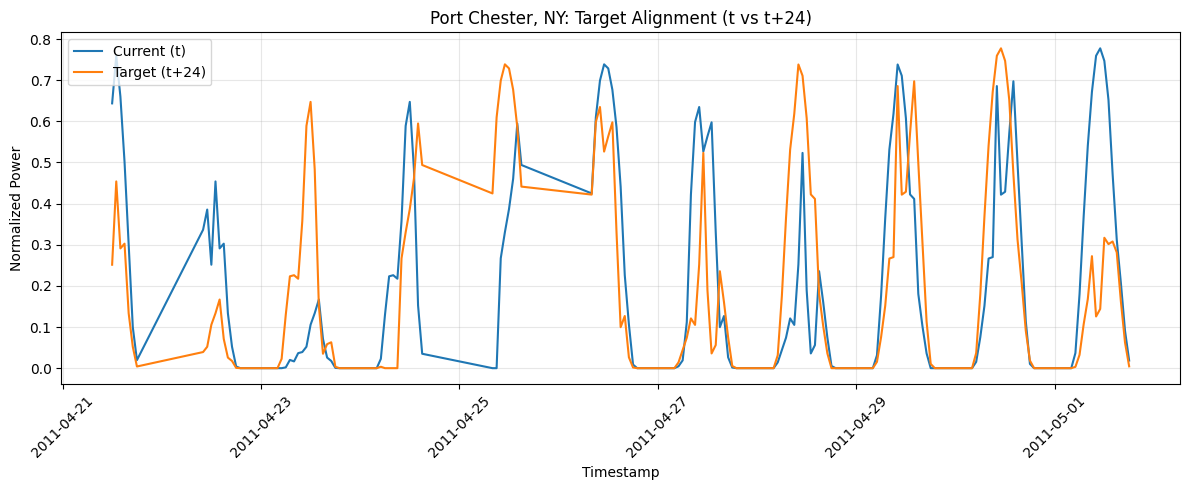

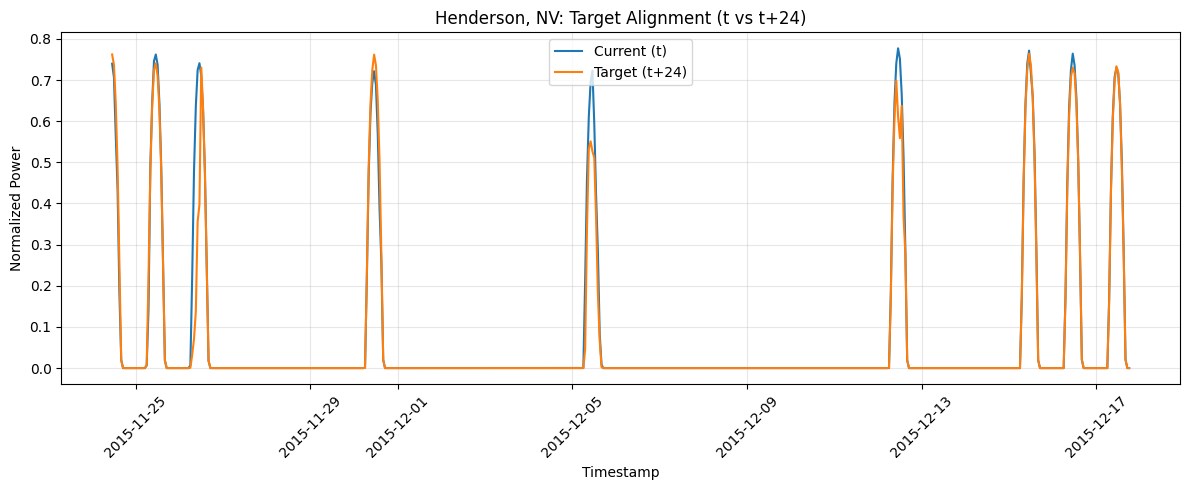

In [ ]:
# ============================================================
# Phase 12.3 : Visual sanity check (t vs t+24)
# ============================================================

import matplotlib.pyplot as plt

def plot_target_alignment(df, site_name):
    sample = df[["timestamp", "normalized_power", "target"]].dropna().head(200)

    plt.figure(figsize=(12, 5))
    plt.plot(sample["timestamp"], sample["normalized_power"], label="Current (t)")
    plt.plot(sample["timestamp"], sample["target"], label="Target (t+24)")

    plt.title(f"{site_name}: Target Alignment (t vs t+24)")
    plt.xlabel("Timestamp")
    plt.ylabel("Normalized Power")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_target_alignment(master_1226_fe, "Port Chester, NY")
plot_target_alignment(master_1423_fe, "Henderson, NV")

### Phase 12 : Target Alignment Visualization: Key Insights

- The target variable (t + 24) correctly represents solar output one day ahead
- The target series follows the same overall structure as the current series, but is shifted forward in time
- There is no evidence of misalignment, leakage, or incorrect shifting

**Port Chester, NY:**
- Displays strong daily solar cycles
- Target values closely resemble future daily patterns
- Indicates strong temporal predictability and consistent data coverage

**Henderson, NV:**
- Exhibits sparse and intermittent solar output
- Target values appear only where future observations exist
- Highlights significant data sparsity and reduced temporal continuity

**Key takeaway:**
- The same forecasting formulation (t → t+24) produces very different learning conditions across sites
- NY provides a dense, highly structured signal
- NV presents a sparse, fragmented signal, which will impact model performance and generalization

This confirms that the forecasting problem has been correctly defined and that the datasets are ready for supervised learning.

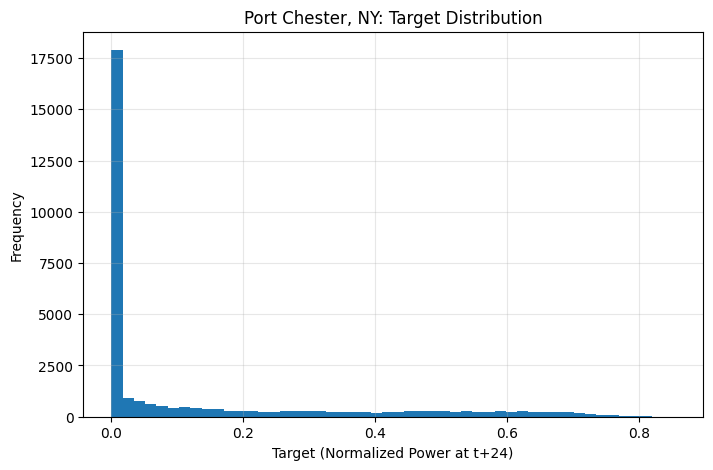

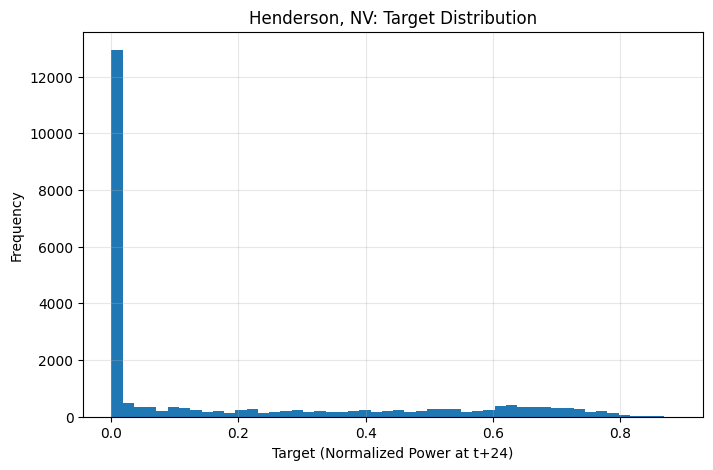

In [ ]:
# ============================================================
# Phase 12.4 : Target distribution
# ============================================================

def plot_target_distribution(df, site_name):
    temp = df["target"].dropna()

    plt.figure(figsize=(8, 5))
    plt.hist(temp, bins=50)
    plt.title(f"{site_name}: Target Distribution")
    plt.xlabel("Target (Normalized Power at t+24)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_target_distribution(master_1226_fe, "Port Chester, NY")
plot_target_distribution(master_1423_fe, "Henderson, NV")

### Phase 12 : Target Distribution: Key Insights

- The target variable (normalized_power at t+24) exhibits a highly skewed distribution
- A large concentration of values at 0 reflects nighttime periods with no solar generation
- Daytime values are distributed continuously between 0 and the system’s maximum normalized output

**Port Chester, NY:**
- Shows a smoother distribution of daytime values
- Reflects higher variability due to weather and seasonal effects

**Henderson, NV:**
- Displays more mass at higher output values
- Indicates stronger and more consistent solar generation when active

**Key implications for modeling:**
- The dataset is highly imbalanced, with many zero-valued targets
- Models may achieve low error by predicting near-zero values, especially at night
- Care must be taken when interpreting performance metrics, as accuracy may be dominated by nighttime predictions

**Conclusion:**
- The target distribution is physically realistic and confirms correct preprocessing
- The imbalance in the target variable is an important factor that will influence model behavior and evaluation

In [ ]:
# ============================================================
# Phase 12.5 : Construct clean modeling datasets
# where we finally drop invalid rows
# ============================================================

required_cols = [
    "normalized_power",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_24_mean",
    "target"
]

ny_model_df = master_1226_fe.dropna(subset=required_cols).copy()
nv_model_df = master_1423_fe.dropna(subset=required_cols).copy()

print("=" * 90)
print("MODEL DATASETS CREATED")
print("=" * 90)

print("\nPort Chester, NY")
print("Original rows:", len(master_1226_fe))
print("Model rows:", len(ny_model_df))
print("Retention %:", len(ny_model_df) / len(master_1226_fe))

print("\nHenderson, NV")
print("Original rows:", len(master_1423_fe))
print("Model rows:", len(nv_model_df))
print("Retention %:", len(nv_model_df) / len(master_1423_fe))

MODEL DATASETS CREATED

Port Chester, NY
Original rows: 32905
Model rows: 28619
Retention %: 0.8697462391733779

Henderson, NV
Original rows: 63685
Model rows: 12043
Retention %: 0.18910261443039963


In [ ]:
# ============================================================
# Phase 12.6 : Save outputs
# ============================================================

master_1226_with_target = master_1226_fe.copy()
master_1423_with_target = master_1423_fe.copy()

print("Saved:")
print(" - master_1226_with_target")
print(" - master_1423_with_target")
print(" - ny_model_df")
print(" - nv_model_df")

Saved:
 - master_1226_with_target
 - master_1423_with_target
 - ny_model_df
 - nv_model_df


### Phase 12 : Final Modeling Dataset Construction: Key Insights

- After defining the target and enforcing feature availability constraints, the dataset was reduced to valid supervised learning examples.

**Port Chester, NY:**
- Retained ~87% of original data
- Indicates high temporal continuity and data quality
- Provides a large and stable training set

**Henderson, NV:**
- Retained ~19% of original data
- Reflects significant sparsity in the original PV signal
- Many rows removed due to missing historical context or unavailable future target

**Key implications:**
- Feature engineering (lags and rolling windows) amplifies the impact of missing data
- Only rows with sufficient historical context and valid future targets are suitable for modeling
- The two sites now represent fundamentally different data regimes:
  - NY: dense and structured
  - NV: sparse and fragmented

**Conclusion:**
- The resulting modeling datasets are clean, leakage-free, and properly structured
- Differences in dataset size and continuity will directly impact model performance and generalization behavior

### Phase 12 : Target Definition: Key Points

- The forecasting task is defined as a day-ahead regression problem:
  predicting solar output at time t + 24 using features at time t

- The target variable is:
  normalized_power shifted 24 hours forward

- No imputation was applied to the target variable to preserve data integrity

- Rows with missing target or required features were removed only when constructing
  the final modeling datasets

- This ensures:
  - no data leakage
  - consistent supervised learning structure
  - valid evaluation of model performance

## Phase 13 : Extreme Weather Definition and Labeling

We define "extreme weather" conditions that make solar forecasting more difficult.

Approach:
- Restrict to daylight conditions (GHI > threshold)
- Identify difficult conditions using:
  1. Low irradiance (cloudy / obstructed conditions)
  2. High short-term irradiance volatility (rapid fluctuations)

Method:
- Use percentile-based thresholds for robustness and interpretability
- Define a binary label: is_extreme_weather

Why this matters:
- Enables evaluation of model robustness
- Allows comparison of performance under:
  - normal conditions
  - difficult real-world conditions

In [ ]:
# ============================================================
# Phase 13.1 : Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prepare_extreme_weather_base(df):
    out = df.copy()

    # Ensure daylight definition (reuse if already exists)
    if "is_daylight" not in out.columns:
        out["is_daylight"] = (out["ghi"] > 20).astype(int)

    # Short-term irradiance change (hourly difference)
    out["ghi_diff_1h"] = out["ghi"].diff().abs()

    # Rolling volatility (past 3 hours, shifted to avoid leakage)
    out["ghi_vol_3h"] = out["ghi"].shift(1).rolling(window=3, min_periods=3).std()

    return out

master_1226_ext = prepare_extreme_weather_base(master_1226_with_target)
master_1423_ext = prepare_extreme_weather_base(master_1423_with_target)

In [ ]:
# ============================================================
# Phase 13.2 : Percentile-based thresholds
# ============================================================

def compute_thresholds(df, site_name):
    daylight = df[df["is_daylight"] == 1].copy()

    ghi_low_thresh = daylight["ghi"].quantile(0.20)       # bottom 20%
    vol_high_thresh = daylight["ghi_vol_3h"].quantile(0.80)  # top 20%

    print("=" * 90)
    print(f"EXTREME WEATHER THRESHOLDS : {site_name}")
    print("=" * 90)
    print(f"GHI low threshold (20th percentile): {ghi_low_thresh:.3f}")
    print(f"GHI volatility high threshold (80th percentile): {vol_high_thresh:.3f}")
    print(f"Daylight rows used: {len(daylight)}")

    return ghi_low_thresh, vol_high_thresh

ny_ghi_low, ny_vol_high = compute_thresholds(master_1226_ext, "Port Chester, NY")
nv_ghi_low, nv_vol_high = compute_thresholds(master_1423_ext, "Henderson, NV")

EXTREME WEATHER THRESHOLDS — Port Chester, NY
GHI low threshold (20th percentile): 109.000
GHI volatility high threshold (80th percentile): 161.434
Daylight rows used: 15292
EXTREME WEATHER THRESHOLDS — Henderson, NV
GHI low threshold (20th percentile): 178.400
GHI volatility high threshold (80th percentile): 178.931
Daylight rows used: 30553


In [ ]:
# ============================================================
# Phase 13.3 : Label extreme weather
# ============================================================

def label_extreme_weather(df, ghi_low, vol_high):
    out = df.copy()

    out["low_irradiance_extreme"] = (
        (out["is_daylight"] == 1) & (out["ghi"] <= ghi_low)
    ).astype(int)

    out["high_variability_extreme"] = (
        (out["is_daylight"] == 1) & (out["ghi_vol_3h"] >= vol_high)
    ).astype(int)

    # Combined label
    out["is_extreme_weather"] = (
        (out["low_irradiance_extreme"] == 1) |
        (out["high_variability_extreme"] == 1)
    ).astype(int)

    return out

master_1226_ext = label_extreme_weather(master_1226_ext, ny_ghi_low, ny_vol_high)
master_1423_ext = label_extreme_weather(master_1423_ext, nv_ghi_low, nv_vol_high)

In [ ]:
# ============================================================
# Phase 13.4 : Summary
# ============================================================

def extreme_summary(df, site_name):
    daylight = df[df["is_daylight"] == 1]

    total = len(daylight)
    extreme = daylight["is_extreme_weather"].sum()

    print("=" * 90)
    print(f"EXTREME WEATHER SUMMARY : {site_name}")
    print("=" * 90)
    print(f"Daylight rows: {total}")
    print(f"Extreme rows: {extreme}")
    print(f"Extreme %: {extreme / total:.3f}")

    print("\nBreakdown:")
    print("Low irradiance:", daylight["low_irradiance_extreme"].sum())
    print("High variability:", daylight["high_variability_extreme"].sum())

extreme_summary(master_1226_ext, "Port Chester, NY")
extreme_summary(master_1423_ext, "Henderson, NV")

EXTREME WEATHER SUMMARY — Port Chester, NY
Daylight rows: 15292
Extreme rows: 5639
Extreme %: 0.369

Breakdown:
Low irradiance: 3083
High variability: 3058
EXTREME WEATHER SUMMARY — Henderson, NV
Daylight rows: 30553
Extreme rows: 10814
Extreme %: 0.354

Breakdown:
Low irradiance: 6111
High variability: 6111


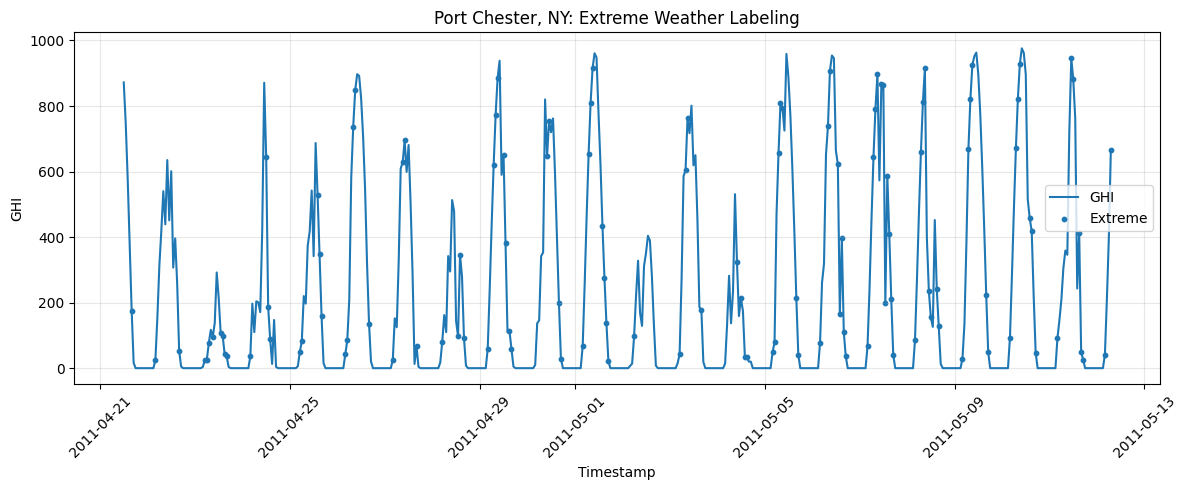

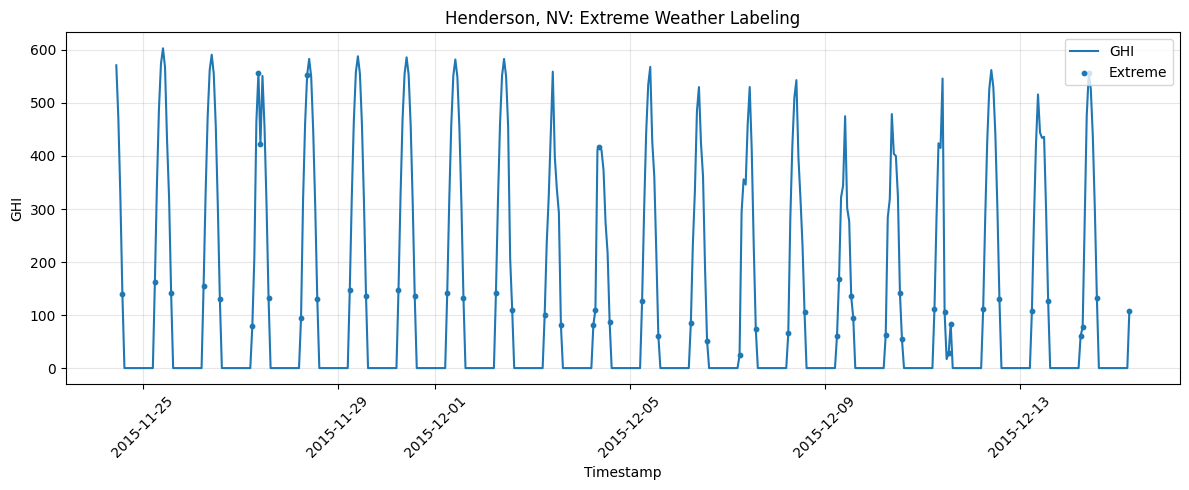

In [ ]:
# ============================================================
# Phase 13.5 : Visualization
# ============================================================

def plot_extreme_examples(df, site_name):
    temp = df[["timestamp", "ghi", "is_extreme_weather"]].dropna().copy()

    # Sample small segment
    temp = temp.head(500)

    plt.figure(figsize=(12, 5))
    plt.plot(temp["timestamp"], temp["ghi"], label="GHI")

    extreme_points = temp[temp["is_extreme_weather"] == 1]
    plt.scatter(extreme_points["timestamp"], extreme_points["ghi"], s=10, label="Extreme")

    plt.title(f"{site_name}: Extreme Weather Labeling")
    plt.xlabel("Timestamp")
    plt.ylabel("GHI")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_extreme_examples(master_1226_ext, "Port Chester, NY")
plot_extreme_examples(master_1423_ext, "Henderson, NV")

In [ ]:
# ============================================================
# Phase 13.6 : Save datasets
# ============================================================

master_1226_extreme = master_1226_ext.copy()
master_1423_extreme = master_1423_ext.copy()

print("Saved:")
print(" - master_1226_extreme")
print(" - master_1423_extreme")

Saved:
 - master_1226_extreme
 - master_1423_extreme


### Phase 13 : Extreme Weather Labeling: Key Insights

- Extreme weather conditions were defined using percentile-based thresholds:
  - Low irradiance: bottom 20% of daylight GHI
  - High variability: top 20% of short-term irradiance volatility

- Only daylight periods were considered to ensure meaningful solar conditions

**Port Chester, NY:**
- Extreme conditions account for ~36.9% of daylight observations
- Low irradiance and high variability contribute roughly equally
- Indicates a mix of cloudy and dynamically changing conditions

**Henderson, NV:**
- Extreme conditions account for ~35.4% of daylight observations
- Strong overlap between low irradiance and high variability
- Suggests that cloudy conditions in NV are also more unstable

**Key insights:**
- The labeling approach is adaptive across sites with different climates
- Extreme conditions are not rare but represent a significant portion of real-world operation
- These conditions correspond to the most difficult forecasting scenarios

**Conclusion:**
- The extreme weather label is well-defined, physically meaningful, and suitable for evaluating model robustness under challenging conditions

## Phase 14 : Train / Validation / Test Splits

This phase defines the final data splits used for model development and evaluation.

Split strategy:
- Within-site split:
  - train = first 70%
  - validation = next 15%
  - test = final 15%

- Cross-site setup:
  - train on Site A
  - test on Site B

Important rule:
- No random splitting
- Temporal order must be preserved

Why this matters:
- supports temporal generalization
- supports spatial/site generalization
- reflects realistic forecasting evaluation

In [ ]:
# ============================================================
# Phase 14.0 : Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("PHASE 14 : TRAIN / VALIDATION / TEST SPLITS")
print("=" * 90)

print("\nAvailable modeling datasets:")
print(" - ny_model_df")
print(" - nv_model_df")

PHASE 14 — TRAIN / VALIDATION / TEST SPLITS

Available modeling datasets:
 - ny_model_df
 - nv_model_df


In [ ]:
# ============================================================
# Phase 14.1 : Ensure chronological ordering
# ============================================================

ny_model_df = ny_model_df.sort_values("timestamp").reset_index(drop=True)
nv_model_df = nv_model_df.sort_values("timestamp").reset_index(drop=True)

for name, df in [("Port Chester, NY", ny_model_df), ("Henderson, NV", nv_model_df)]:
    print("=" * 90)
    print(f"ORDERING CHECK : {name}")
    print("=" * 90)
    print("Rows:", len(df))
    print("Timestamp monotonic increasing:", df["timestamp"].is_monotonic_increasing)
    print("First timestamp:", df["timestamp"].min())
    print("Last timestamp:", df["timestamp"].max())

ORDERING CHECK — Port Chester, NY
Rows: 28619
Timestamp monotonic increasing: True
First timestamp: 2011-04-28 12:00:00
Last timestamp: 2015-01-20 12:00:00
ORDERING CHECK — Henderson, NV
Rows: 12043
Timestamp monotonic increasing: True
First timestamp: 2015-12-17 00:00:00
Last timestamp: 2023-02-27 23:00:00


In [ ]:
# ============================================================
# Phase 14.2 : Helper function for strict time-based splits
# ============================================================

def time_split_70_15_15(df):
    """
    Strict chronological split:
    - first 70% -> train
    - next 15%  -> validation
    - final 15% -> test
    """
    n = len(df)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [ ]:
# ============================================================
# Phase 14.3 : Apply within-site splits
# ============================================================

ny_train_df, ny_val_df, ny_test_df = time_split_70_15_15(ny_model_df)
nv_train_df, nv_val_df, nv_test_df = time_split_70_15_15(nv_model_df)

print("=" * 90)
print("WITHIN-SITE SPLITS CREATED")
print("=" * 90)

for site_name, full_df, train_df, val_df, test_df in [
    ("Port Chester, NY", ny_model_df, ny_train_df, ny_val_df, ny_test_df),
    ("Henderson, NV", nv_model_df, nv_train_df, nv_val_df, nv_test_df),
]:
    print(f"\n{site_name}")
    print("-" * 50)
    print("Full rows :", len(full_df))
    print("Train rows:", len(train_df), f"({len(train_df)/len(full_df):.3f})")
    print("Val rows  :", len(val_df), f"({len(val_df)/len(full_df):.3f})")
    print("Test rows :", len(test_df), f"({len(test_df)/len(full_df):.3f})")

WITHIN-SITE SPLITS CREATED

Port Chester, NY
--------------------------------------------------
Full rows : 28619
Train rows: 20033 (0.700)
Val rows  : 4293 (0.150)
Test rows : 4293 (0.150)

Henderson, NV
--------------------------------------------------
Full rows : 12043
Train rows: 8430 (0.700)
Val rows  : 1806 (0.150)
Test rows : 1807 (0.150)


In [ ]:
# ============================================================
# Phase 14.4 : Split boundary audit
# ============================================================

def audit_split_boundaries(train_df, val_df, test_df, site_name):
    print("=" * 90)
    print(f"SPLIT BOUNDARY AUDIT : {site_name}")
    print("=" * 90)

    print("Train period:")
    print("  start:", train_df["timestamp"].min())
    print("  end  :", train_df["timestamp"].max())

    print("\nValidation period:")
    print("  start:", val_df["timestamp"].min())
    print("  end  :", val_df["timestamp"].max())

    print("\nTest period:")
    print("  start:", test_df["timestamp"].min())
    print("  end  :", test_df["timestamp"].max())

    print("\nChronological integrity checks:")
    print("  train end < val start :", train_df["timestamp"].max() < val_df["timestamp"].min())
    print("  val end < test start  :", val_df["timestamp"].max() < test_df["timestamp"].min())
    print("  no overlap total      :",
          (train_df["timestamp"].max() < val_df["timestamp"].min()) and
          (val_df["timestamp"].max() < test_df["timestamp"].min()))

audit_split_boundaries(ny_train_df, ny_val_df, ny_test_df, "Port Chester, NY")
audit_split_boundaries(nv_train_df, nv_val_df, nv_test_df, "Henderson, NV")

SPLIT BOUNDARY AUDIT — Port Chester, NY
Train period:
  start: 2011-04-28 12:00:00
  end  : 2014-01-04 21:00:00

Validation period:
  start: 2014-01-04 22:00:00
  end  : 2014-07-06 18:00:00

Test period:
  start: 2014-07-06 19:00:00
  end  : 2015-01-20 12:00:00

Chronological integrity checks:
  train end < val start : True
  val end < test start  : True
  no overlap total      : True
SPLIT BOUNDARY AUDIT — Henderson, NV
Train period:
  start: 2015-12-17 00:00:00
  end  : 2022-09-28 22:00:00

Validation period:
  start: 2022-09-28 23:00:00
  end  : 2022-12-13 04:00:00

Test period:
  start: 2022-12-13 05:00:00
  end  : 2023-02-27 23:00:00

Chronological integrity checks:
  train end < val start : True
  val end < test start  : True
  no overlap total      : True


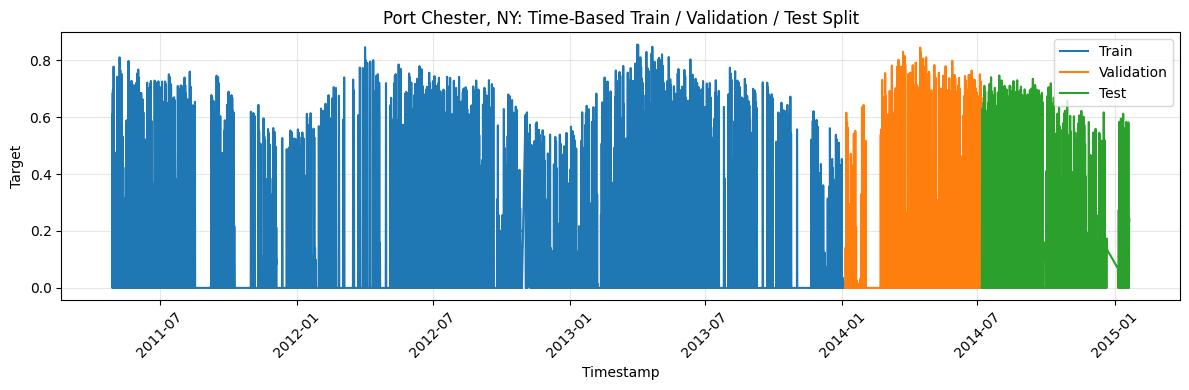

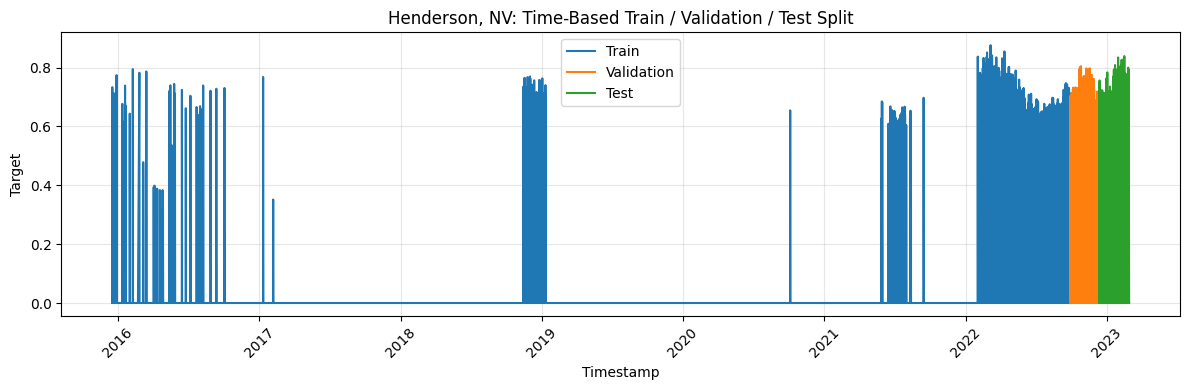

In [ ]:
# ============================================================
# Phase 14.5 : Visualize split placement in time
# ============================================================

def plot_time_splits(df, train_df, val_df, test_df, site_name):
    plt.figure(figsize=(12, 4))

    plt.plot(train_df["timestamp"], train_df["target"], label="Train")
    plt.plot(val_df["timestamp"], val_df["target"], label="Validation")
    plt.plot(test_df["timestamp"], test_df["target"], label="Test")

    plt.title(f"{site_name}: Time-Based Train / Validation / Test Split")
    plt.xlabel("Timestamp")
    plt.ylabel("Target")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_time_splits(ny_model_df, ny_train_df, ny_val_df, ny_test_df, "Port Chester, NY")
plot_time_splits(nv_model_df, nv_train_df, nv_val_df, nv_test_df, "Henderson, NV")

In [ ]:
# ============================================================
# Phase 14.6 : Summary table for report
# ============================================================

def split_summary_table(full_df, train_df, val_df, test_df, site_name):
    return pd.DataFrame({
        "site": [site_name, site_name, site_name],
        "split": ["train", "validation", "test"],
        "rows": [len(train_df), len(val_df), len(test_df)],
        "fraction_of_full": [
            len(train_df) / len(full_df),
            len(val_df) / len(full_df),
            len(test_df) / len(full_df)
        ],
        "start_time": [
            train_df["timestamp"].min(),
            val_df["timestamp"].min(),
            test_df["timestamp"].min()
        ],
        "end_time": [
            train_df["timestamp"].max(),
            val_df["timestamp"].max(),
            test_df["timestamp"].max()
        ]
    })

ny_split_summary = split_summary_table(ny_model_df, ny_train_df, ny_val_df, ny_test_df, "Port Chester, NY")
nv_split_summary = split_summary_table(nv_model_df, nv_train_df, nv_val_df, nv_test_df, "Henderson, NV")

phase14_split_summary = pd.concat([ny_split_summary, nv_split_summary], ignore_index=True)

print("=" * 90)
print("PHASE 14 SPLIT SUMMARY TABLE")
print("=" * 90)
display(phase14_split_summary)

PHASE 14 SPLIT SUMMARY TABLE


,site,split,rows,fraction_of_full,start_time,end_time
0,"Port Chester, NY",train,20033,0.699990,2011-04-28 12:00:00,2014-01-04 21:00:00
1,"Port Chester, NY",validation,4293,0.150005,2014-01-04 22:00:00,2014-07-06 18:00:00
2,"Port Chester, NY",test,4293,0.150005,2014-07-06 19:00:00,2015-01-20 12:00:00
3,"Henderson, NV",train,8430,0.699992,2015-12-17 00:00:00,2022-09-28 22:00:00
4,"Henderson, NV",validation,1806,0.149963,2022-09-28 23:00:00,2022-12-13 04:00:00
5,"Henderson, NV",test,1807,0.150046,2022-12-13 05:00:00,2023-02-27 23:00:00


### Phase 14 : Within-Site Split Interpretation

These within-site splits support temporal generalization because:
- models are trained only on earlier observations
- validation and test sets represent later unseen periods
- no future information is used during training

This is more realistic than random splitting for time-series forecasting.

In [ ]:
# ============================================================
# Phase 14.7 : Cross-site setup
# ============================================================

# Cross-site evaluation datasets
# Setup A: train on NY, test on NV
cross_train_ny_to_nv = ny_model_df.copy()
cross_test_ny_to_nv = nv_model_df.copy()

# Setup B: train on NV, test on NY
cross_train_nv_to_ny = nv_model_df.copy()
cross_test_nv_to_ny = ny_model_df.copy()

print("=" * 90)
print("CROSS-SITE DATASETS CREATED")
print("=" * 90)

print("\nSetup A : Train on Port Chester, NY | Test on Henderson, NV")
print("Train rows:", len(cross_train_ny_to_nv))
print("Test rows :", len(cross_test_ny_to_nv))

print("\nSetup B : Train on Henderson, NV | Test on Port Chester, NY")
print("Train rows:", len(cross_train_nv_to_ny))
print("Test rows :", len(cross_test_nv_to_ny))

CROSS-SITE DATASETS CREATED

Setup A — Train on Port Chester, NY | Test on Henderson, NV
Train rows: 28619
Test rows : 12043

Setup B — Train on Henderson, NV | Test on Port Chester, NY
Train rows: 12043
Test rows : 28619


In [ ]:
# ============================================================
# Phase 14.8 : Cross-site distribution comparison
# ============================================================

def compare_cross_site_ranges(train_df, test_df, train_name, test_name):
    print("=" * 90)
    print(f"CROSS-SITE RANGE CHECK : Train: {train_name} | Test: {test_name}")
    print("=" * 90)

    cols_to_check = [
        "target",
        "normalized_power",
        "ghi",
        "temperature_c",
        "lag_1",
        "lag_24",
        "lag_168",
        "rolling_24_mean"
    ]

    rows = []
    for col in cols_to_check:
        if col in train_df.columns and col in test_df.columns:
            rows.append({
                "feature": col,
                "train_min": train_df[col].min(),
                "train_max": train_df[col].max(),
                "test_min": test_df[col].min(),
                "test_max": test_df[col].max()
            })

    display(pd.DataFrame(rows))

compare_cross_site_ranges(cross_train_ny_to_nv, cross_test_ny_to_nv, "Port Chester, NY", "Henderson, NV")
compare_cross_site_ranges(cross_train_nv_to_ny, cross_test_nv_to_ny, "Henderson, NV", "Port Chester, NY")

CROSS-SITE RANGE CHECK — Train: Port Chester, NY | Test: Henderson, NV


,feature,train_min,train_max,test_min,test_max
0,target,0.0,0.855022,0.000000,0.875894
1,normalized_power,0.0,0.855022,0.000000,0.875894
2,ghi,0.0,1021.000000,0.000000,1079.000000
3,temperature_c,-20.3,35.900000,-4.200000,46.200000
4,lag_1,0.0,0.855022,0.000000,0.875894
5,lag_24,0.0,0.855022,0.000000,0.875894
6,lag_168,0.0,0.855022,0.000000,0.875894
7,rolling_24_mean,0.0,0.278696,0.019273,0.270889


CROSS-SITE RANGE CHECK — Train: Henderson, NV | Test: Port Chester, NY


,feature,train_min,train_max,test_min,test_max
0,target,0.000000,0.875894,0.0,0.855022
1,normalized_power,0.000000,0.875894,0.0,0.855022
2,ghi,0.000000,1079.000000,0.0,1021.000000
3,temperature_c,-4.200000,46.200000,-20.3,35.900000
4,lag_1,0.000000,0.875894,0.0,0.855022
5,lag_24,0.000000,0.875894,0.0,0.855022
6,lag_168,0.000000,0.875894,0.0,0.855022
7,rolling_24_mean,0.019273,0.270889,0.0,0.278696


In [ ]:
# ============================================================
# Phase 14.9 : Save final split outputs
# ============================================================

phase14_outputs = {
    "ny_model_df": ny_model_df,
    "nv_model_df": nv_model_df,

    "ny_train_df": ny_train_df,
    "ny_val_df": ny_val_df,
    "ny_test_df": ny_test_df,

    "nv_train_df": nv_train_df,
    "nv_val_df": nv_val_df,
    "nv_test_df": nv_test_df,

    "cross_train_ny_to_nv": cross_train_ny_to_nv,
    "cross_test_ny_to_nv": cross_test_ny_to_nv,

    "cross_train_nv_to_ny": cross_train_nv_to_ny,
    "cross_test_nv_to_ny": cross_test_nv_to_ny,
}

print("Saved Phase 14 outputs:")
for key in phase14_outputs.keys():
    print(" -", key)

Saved Phase 14 outputs:
 - ny_model_df
 - nv_model_df
 - ny_train_df
 - ny_val_df
 - ny_test_df
 - nv_train_df
 - nv_val_df
 - nv_test_df
 - cross_train_ny_to_nv
 - cross_test_ny_to_nv
 - cross_train_nv_to_ny
 - cross_test_nv_to_ny


## Phase 14 : Key Takeaways

This phase establishes the final evaluation structure for the project.

Main points:
- within-site evaluation uses strict chronological splits:
  - first 70% for training
  - next 15% for validation
  - final 15% for testing
- cross-site evaluation tests spatial generalization by training on one site and testing on the other
- no random splitting is used at any stage
- this preserves temporal realism and prevents information leakage

These splits support:
- realistic forecasting experiments
- temporal generalization analysis
- spatial/site generalization analysis

### Phase 14 : Cross-Site Evaluation: Key Insights

- Cross-site datasets were constructed by training on one site and testing on the other
- No data leakage occurs, as sites are fully independent

**Feature range comparison:**
- Normalized power and target values are consistent across sites
- Irradiance ranges are similar, with NV exhibiting slightly higher maximum values
- Temperature distributions differ significantly, reflecting distinct climates
- Lag and rolling features remain on comparable scales

**Key observations:**
- The two sites exhibit meaningful distribution differences (domain shift)
- NV is hotter and more consistently sunny
- NY is more variable and experiences colder conditions

**Implications:**
- Models must generalize across both climate and data structure differences
- This creates a realistic and challenging evaluation setting
- Cross-site performance will reflect true robustness, not just interpolation

**Conclusion:**
- The cross-site setup is valid, well-structured, and suitable for evaluating spatial generalization

## Phase 16 : Modeling

We compare four model levels:

1. Baseline
   - Seasonal-naive forecast

2. Linear model
   - Linear Regression

3. Nonlinear boosting model
   - Gradient Boosting Regressor

4. Sequence model
   - LSTM

Why these models?
- Baseline gives context
- Linear Regression gives an interpretable classical ML reference
- Gradient Boosting captures nonlinear relationships
- LSTM tests whether a sequence model can leverage temporal structure

For this first modeling phase, we use one fixed baseline preprocessing setup:
- target = normalized_power
- temporal + cyclical features
- minimal weather: ghi, temperature_c
- lag features
- rolling features

Robustness analysis and cross-site evaluation will reuse these models later.

In [ ]:
# ============================================================
# Phase 16.0 : Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 90)
print("PHASE 16 : MODELING")
print("=" * 90)

PHASE 16 — MODELING


In [ ]:
# ============================================================
# Phase 16.1 : Baseline feature set
# ============================================================

baseline_feature_cols = [
    # temporal / cyclical
    "hour",
    "dayofyear",
    "month",
    "dayofweek",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",

    # minimal weather
    "ghi",
    "temperature_c",

    # lag features
    "lag_1",
    "lag_24",
    "lag_168",

    # rolling features
    "rolling_24_mean",
    "rolling_24_std"
]

target_col = "target"

print("Baseline feature columns:")
print(baseline_feature_cols)
print("\nTarget column:")
print(target_col)

Baseline feature columns:
['hour', 'dayofyear', 'month', 'dayofweek', 'is_weekend', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'ghi', 'temperature_c', 'lag_1', 'lag_24', 'lag_168', 'rolling_24_mean', 'rolling_24_std']

Target column:
target


In [ ]:
# ============================================================
# Phase 16.2 : Basic evaluation helpers
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_regression(y_true, y_pred, model_name, site_name, split_name):
    return {
        "site": site_name,
        "split": split_name,
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred)
    }


def make_xy(df, feature_cols, target_col):
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y

In [ ]:
# ============================================================
# Phase 16.2 : Basic evaluation helpers
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_regression(y_true, y_pred, model_name, site_name, split_name):
    return {
        "site": site_name,
        "split": split_name,
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred)
    }


def make_xy(df, feature_cols, target_col):
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y

In [ ]:
# ============================================================
# Phase 16.3 : Sanity check modeling splits
# ============================================================

for site_name, train_df, val_df, test_df in [
    ("Port Chester, NY", ny_train_df, ny_val_df, ny_test_df),
    ("Henderson, NV", nv_train_df, nv_val_df, nv_test_df),
]:
    print("=" * 90)
    print(f"MODELING SPLIT CHECK : {site_name}")
    print("=" * 90)
    print("Train rows:", len(train_df))
    print("Val rows  :", len(val_df))
    print("Test rows :", len(test_df))
    print("All baseline features present:",
          all(col in train_df.columns for col in baseline_feature_cols))
    print("Target present:", target_col in train_df.columns)

MODELING SPLIT CHECK — Port Chester, NY
Train rows: 20033
Val rows  : 4293
Test rows : 4293
All baseline features present: True
Target present: True
MODELING SPLIT CHECK — Henderson, NV
Train rows: 8430
Val rows  : 1806
Test rows : 1807
All baseline features present: True
Target present: True


In [ ]:
# ============================================================
# Phase 16.4 : Seasonal-naive baseline
# For day-ahead forecasting with target = y(t+24),
# the seasonal-naive forecast is y_hat(t+24) = y(t).
# Since normalized_power at time t is available, the
# seasonal-naive prediction is simply the current normalized_power.
# ============================================================

def run_seasonal_naive(train_df, val_df, test_df, site_name):
    rows = []

    # Validation
    y_val = val_df[target_col]
    y_val_pred = val_df["normalized_power"]
    rows.append(evaluate_regression(y_val, y_val_pred, "SeasonalNaive", site_name, "validation"))

    # Test
    y_test = test_df[target_col]
    y_test_pred = test_df["normalized_power"]
    rows.append(evaluate_regression(y_test, y_test_pred, "SeasonalNaive", site_name, "test"))

    return pd.DataFrame(rows)

seasonal_naive_results = pd.concat([
    run_seasonal_naive(ny_train_df, ny_val_df, ny_test_df, "Port Chester, NY"),
    run_seasonal_naive(nv_train_df, nv_val_df, nv_test_df, "Henderson, NV")
], ignore_index=True)

print("=" * 90)
print("SEASONAL-NAIVE RESULTS")
print("=" * 90)
display(seasonal_naive_results.round(4))

SEASONAL-NAIVE RESULTS


,site,split,model,MAE,RMSE
0,"Port Chester, NY",validation,SeasonalNaive,0.0699,0.1504
1,"Port Chester, NY",test,SeasonalNaive,0.0632,0.1342
2,"Henderson, NV",validation,SeasonalNaive,0.0353,0.0969
3,"Henderson, NV",test,SeasonalNaive,0.0573,0.1392


In [ ]:
# ============================================================
# Phase 16.5 : Linear Regression
# Scaling is applied because linear models are sensitive to feature scale.
# ============================================================

def run_linear_regression(train_df, val_df, test_df, site_name, feature_cols, target_col):
    X_train, y_train = make_xy(train_df, feature_cols, target_col)
    X_val, y_val = make_xy(val_df, feature_cols, target_col)
    X_test, y_test = make_xy(test_df, feature_cols, target_col)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_scaled, y_train)

    val_pred = model.predict(X_val_scaled)
    test_pred = model.predict(X_test_scaled)

    results = pd.DataFrame([
        evaluate_regression(y_val, val_pred, "LinearRegression", site_name, "validation"),
        evaluate_regression(y_test, test_pred, "LinearRegression", site_name, "test"),
    ])

    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "coefficient": model.coef_
    }).sort_values("coefficient", key=np.abs, ascending=False)

    return model, scaler, results, coef_df

ny_lr_model, ny_lr_scaler, ny_lr_results, ny_lr_coefs = run_linear_regression(
    ny_train_df, ny_val_df, ny_test_df, "Port Chester, NY", baseline_feature_cols, target_col
)

nv_lr_model, nv_lr_scaler, nv_lr_results, nv_lr_coefs = run_linear_regression(
    nv_train_df, nv_val_df, nv_test_df, "Henderson, NV", baseline_feature_cols, target_col
)

linear_results = pd.concat([ny_lr_results, nv_lr_results], ignore_index=True)

print("=" * 90)
print("LINEAR REGRESSION RESULTS")
print("=" * 90)
display(linear_results.round(4))

LINEAR REGRESSION RESULTS


,site,split,model,MAE,RMSE
0,"Port Chester, NY",validation,LinearRegression,0.0779,0.1252
1,"Port Chester, NY",test,LinearRegression,0.0664,0.1073
2,"Henderson, NV",validation,LinearRegression,0.0480,0.0897
3,"Henderson, NV",test,LinearRegression,0.0691,0.1190


In [ ]:
# ============================================================
# Phase 16.6 : Linear model coefficient inspection
# ============================================================

print("=" * 90)
print("LINEAR REGRESSION COEFFICIENTS : PORT CHESTER, NY")
print("=" * 90)
display(ny_lr_coefs.round(4))

print("=" * 90)
print("LINEAR REGRESSION COEFFICIENTS : HENDERSON, NV")
print("=" * 90)
display(nv_lr_coefs.round(4))

LINEAR REGRESSION COEFFICIENTS — PORT CHESTER, NY


,feature,coefficient
14,rolling_24_mean,-0.0761
11,lag_1,0.0603
15,rolling_24_std,0.0561
9,ghi,0.0474
12,lag_24,0.0419
6,hour_cos,-0.0295
8,doy_cos,-0.0262
2,month,0.0241
13,lag_168,0.0230
1,dayofyear,-0.0229


LINEAR REGRESSION COEFFICIENTS — HENDERSON, NV


,feature,coefficient
12,lag_24,0.0761
11,lag_1,0.0747
13,lag_168,0.0637
9,ghi,0.0462
14,rolling_24_mean,-0.0404
15,rolling_24_std,0.0334
2,month,-0.0308
1,dayofyear,0.0258
5,hour_sin,0.0100
0,hour,0.0053


In [ ]:
# ============================================================
# Phase 16.7 : Gradient Boosting Regressor
# Tree-based boosting does not require feature scaling.
# ============================================================

def run_gradient_boosting(train_df, val_df, test_df, site_name, feature_cols, target_col):
    X_train, y_train = make_xy(train_df, feature_cols, target_col)
    X_val, y_val = make_xy(val_df, feature_cols, target_col)
    X_test, y_test = make_xy(test_df, feature_cols, target_col)

    model = GradientBoostingRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8
    )

    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    results = pd.DataFrame([
        evaluate_regression(y_val, val_pred, "GradientBoosting", site_name, "validation"),
        evaluate_regression(y_test, test_pred, "GradientBoosting", site_name, "test"),
    ])

    feature_importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    return model, results, feature_importance_df

ny_gb_model, ny_gb_results, ny_gb_importance = run_gradient_boosting(
    ny_train_df, ny_val_df, ny_test_df, "Port Chester, NY", baseline_feature_cols, target_col
)

nv_gb_model, nv_gb_results, nv_gb_importance = run_gradient_boosting(
    nv_train_df, nv_val_df, nv_test_df, "Henderson, NV", baseline_feature_cols, target_col
)

gb_results = pd.concat([ny_gb_results, nv_gb_results], ignore_index=True)

print("=" * 90)
print("GRADIENT BOOSTING RESULTS")
print("=" * 90)
display(gb_results.round(4))

GRADIENT BOOSTING RESULTS


,site,split,model,MAE,RMSE
0,"Port Chester, NY",validation,GradientBoosting,0.0641,0.1163
1,"Port Chester, NY",test,GradientBoosting,0.0536,0.0981
2,"Henderson, NV",validation,GradientBoosting,0.0396,0.0834
3,"Henderson, NV",test,GradientBoosting,0.0608,0.1231


In [ ]:
# ============================================================
# Phase 16.8 : Gradient boosting feature importances
# ============================================================

print("=" * 90)
print("GRADIENT BOOSTING FEATURE IMPORTANCE : PORT CHESTER, NY")
print("=" * 90)
display(ny_gb_importance.round(4))

print("=" * 90)
print("GRADIENT BOOSTING FEATURE IMPORTANCE : HENDERSON, NV")
print("=" * 90)
display(nv_gb_importance.round(4))

GRADIENT BOOSTING FEATURE IMPORTANCE — PORT CHESTER, NY


,feature,importance
11,lag_1,0.2780
12,lag_24,0.2516
6,hour_cos,0.2008
9,ghi,0.1263
13,lag_168,0.0352
8,doy_cos,0.0319
0,hour,0.0229
5,hour_sin,0.0119
7,doy_sin,0.0095
1,dayofyear,0.0091


GRADIENT BOOSTING FEATURE IMPORTANCE — HENDERSON, NV


,feature,importance
12,lag_24,0.4690
13,lag_168,0.3583
6,hour_cos,0.0720
11,lag_1,0.0474
9,ghi,0.0160
0,hour,0.0094
5,hour_sin,0.0053
7,doy_sin,0.0045
14,rolling_24_mean,0.0043
15,rolling_24_std,0.0037


In [ ]:
# ============================================================
# Phase 16.9 : Prepare LSTM sequence datasets
# Sequence design:
# Use the past 24 hours of:
#   normalized_power, ghi, temperature_c
# to predict target at t+24
#
# Forecast origin = time t
# Sequence window = [t-23, ..., t]
# Target = y(t+24)
# ============================================================

sequence_feature_cols = ["normalized_power", "ghi", "temperature_c"]
sequence_length = 24

print("Sequence feature columns:", sequence_feature_cols)
print("Sequence length:", sequence_length)

Sequence feature columns: ['normalized_power', 'ghi', 'temperature_c']
Sequence length: 24


In [ ]:
# ============================================================
# Phase 16.10 : LSTM sequence builder
# ============================================================

def build_lstm_sequences_from_full_df(full_df, split_window, seq_features, target_col, sequence_length):
    """
    Build sequences from the full site dataframe so we preserve continuity.

    For each forecast origin time t:
    - input = rows [t-sequence_length+1, ..., t] of seq_features
    - target = target at row t  (already represents y(t+24))

    We then assign each sequence to train/val/test using the timestamp at t.
    """
    df = full_df.sort_values("timestamp").reset_index(drop=True).copy()

    required_cols = seq_features + [target_col, "timestamp"]
    df = df[required_cols].copy()

    X_train, y_train, t_train = [], [], []
    X_val, y_val, t_val = [], [], []
    X_test, y_test, t_test = [], [], []

    for i in range(sequence_length - 1, len(df)):
        current_time = df.loc[i, "timestamp"]
        start_idx = i - sequence_length + 1
        end_idx = i

        seq_block = df.loc[start_idx:end_idx, seq_features]
        target_value = df.loc[i, target_col]

        # Skip any sequence with missing inputs or missing target
        if seq_block.isna().any().any():
            continue
        if pd.isna(target_value):
            continue

        X_seq = seq_block.values.astype(np.float32)
        y_val_single = np.float32(target_value)

        if split_window["train_start"] <= current_time <= split_window["train_end"]:
            X_train.append(X_seq)
            y_train.append(y_val_single)
            t_train.append(current_time)
        elif split_window["val_start"] <= current_time <= split_window["val_end"]:
            X_val.append(X_seq)
            y_val.append(y_val_single)
            t_val.append(current_time)
        elif split_window["test_start"] <= current_time <= split_window["test_end"]:
            X_test.append(X_seq)
            y_test.append(y_val_single)
            t_test.append(current_time)

    return (
        np.array(X_train), np.array(y_train), pd.Series(t_train),
        np.array(X_val), np.array(y_val), pd.Series(t_val),
        np.array(X_test), np.array(y_test), pd.Series(t_test)
    )

In [ ]:
# ============================================================
# Recreate split_windows from Phase 14 for LSTM
# ============================================================

split_windows = {
    "ny": {
        "train_start": ny_train_df["timestamp"].min(),
        "train_end": ny_train_df["timestamp"].max(),
        "val_start": ny_val_df["timestamp"].min(),
        "val_end": ny_val_df["timestamp"].max(),
        "test_start": ny_test_df["timestamp"].min(),
        "test_end": ny_test_df["timestamp"].max(),
    },
    "nv": {
        "train_start": nv_train_df["timestamp"].min(),
        "train_end": nv_train_df["timestamp"].max(),
        "val_start": nv_val_df["timestamp"].min(),
        "val_end": nv_val_df["timestamp"].max(),
        "test_start": nv_test_df["timestamp"].min(),
        "test_end": nv_test_df["timestamp"].max(),
    }
}

print("split_windows recreated successfully.")

split_windows recreated successfully.


In [ ]:
# ============================================================
# Phase 16.11 : Build site-specific sequence datasets
# ============================================================

(
    X_train_seq_ny, y_train_seq_ny, t_train_seq_ny,
    X_val_seq_ny, y_val_seq_ny, t_val_seq_ny,
    X_test_seq_ny, y_test_seq_ny, t_test_seq_ny
) = build_lstm_sequences_from_full_df(
    master_1226_extreme,
    split_windows["ny"],
    sequence_feature_cols,
    target_col,
    sequence_length
)

(
    X_train_seq_nv, y_train_seq_nv, t_train_seq_nv,
    X_val_seq_nv, y_val_seq_nv, t_val_seq_nv,
    X_test_seq_nv, y_test_seq_nv, t_test_seq_nv
) = build_lstm_sequences_from_full_df(
    master_1423_extreme,
    split_windows["nv"],
    sequence_feature_cols,
    target_col,
    sequence_length
)

print("=" * 90)
print("LSTM SEQUENCE DATASETS")
print("=" * 90)

for site_name, Xtr, Xv, Xte in [
    ("Port Chester, NY", X_train_seq_ny, X_val_seq_ny, X_test_seq_ny),
    ("Henderson, NV", X_train_seq_nv, X_val_seq_nv, X_test_seq_nv),
]:
    print(f"\n{site_name}")
    print("Train sequences:", Xtr.shape)
    print("Val sequences  :", Xv.shape)
    print("Test sequences :", Xte.shape)

LSTM SEQUENCE DATASETS

Port Chester, NY
Train sequences: (21120, 24, 3)
Val sequences  : (4318, 24, 3)
Test sequences : (4463, 24, 3)

Henderson, NV
Train sequences: (9895, 24, 3)
Val sequences  : (1806, 24, 3)
Test sequences : (1812, 24, 3)


In [ ]:
# ============================================================
# Phase 16.12 : Scale LSTM inputs using training data only
# ============================================================

def scale_sequence_data(X_train, X_val, X_test):
    n_train, seq_len, n_feat = X_train.shape
    n_val = X_val.shape[0]
    n_test = X_test.shape[0]

    scaler = StandardScaler()

    X_train_2d = X_train.reshape(-1, n_feat)
    X_val_2d = X_val.reshape(-1, n_feat)
    X_test_2d = X_test.reshape(-1, n_feat)

    X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, seq_len, n_feat)
    X_val_scaled = scaler.transform(X_val_2d).reshape(n_val, seq_len, n_feat)
    X_test_scaled = scaler.transform(X_test_2d).reshape(n_test, seq_len, n_feat)

    return X_train_scaled, X_val_scaled, X_test_scaled, scaler

X_train_seq_ny_sc, X_val_seq_ny_sc, X_test_seq_ny_sc, ny_seq_scaler = scale_sequence_data(
    X_train_seq_ny, X_val_seq_ny, X_test_seq_ny
)

X_train_seq_nv_sc, X_val_seq_nv_sc, X_test_seq_nv_sc, nv_seq_scaler = scale_sequence_data(
    X_train_seq_nv, X_val_seq_nv, X_test_seq_nv
)

In [ ]:
# ============================================================
# Phase 16.13 : LSTM model
# ============================================================

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    TF_AVAILABLE = True
    print("TensorFlow available.")
except Exception as e:
    TF_AVAILABLE = False
    print("TensorFlow not available:", e)

TensorFlow available.


In [ ]:
# ============================================================
# Phase 16.14 : Train and evaluate LSTM
# ============================================================

def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


def run_lstm(X_train, y_train, X_val, y_val, X_test, y_test, site_name):
    model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=64,
        verbose=0,
        callbacks=[early_stop]
    )

    val_pred = model.predict(X_val, verbose=0).ravel()
    test_pred = model.predict(X_test, verbose=0).ravel()

    results = pd.DataFrame([
        evaluate_regression(y_val, val_pred, "LSTM", site_name, "validation"),
        evaluate_regression(y_test, test_pred, "LSTM", site_name, "test"),
    ])

    return model, history, results, val_pred, test_pred

if TF_AVAILABLE:
    ny_lstm_model, ny_lstm_history, ny_lstm_results, ny_lstm_val_pred, ny_lstm_test_pred = run_lstm(
        X_train_seq_ny_sc, y_train_seq_ny,
        X_val_seq_ny_sc, y_val_seq_ny,
        X_test_seq_ny_sc, y_test_seq_ny,
        "Port Chester, NY"
    )

    nv_lstm_model, nv_lstm_history, nv_lstm_results, nv_lstm_val_pred, nv_lstm_test_pred = run_lstm(
        X_train_seq_nv_sc, y_train_seq_nv,
        X_val_seq_nv_sc, y_val_seq_nv,
        X_test_seq_nv_sc, y_test_seq_nv,
        "Henderson, NV"
    )

    lstm_results = pd.concat([ny_lstm_results, nv_lstm_results], ignore_index=True)

    print("=" * 90)
    print("LSTM RESULTS")
    print("=" * 90)
    display(lstm_results.round(4))
else:
    lstm_results = pd.DataFrame()
    print("Skipping LSTM training because TensorFlow is unavailable.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM RESULTS


,site,split,model,MAE,RMSE
0,"Port Chester, NY",validation,LSTM,0.0652,0.1184
1,"Port Chester, NY",test,LSTM,0.0564,0.1007
2,"Henderson, NV",validation,LSTM,0.0378,0.0787
3,"Henderson, NV",test,LSTM,0.0606,0.1205


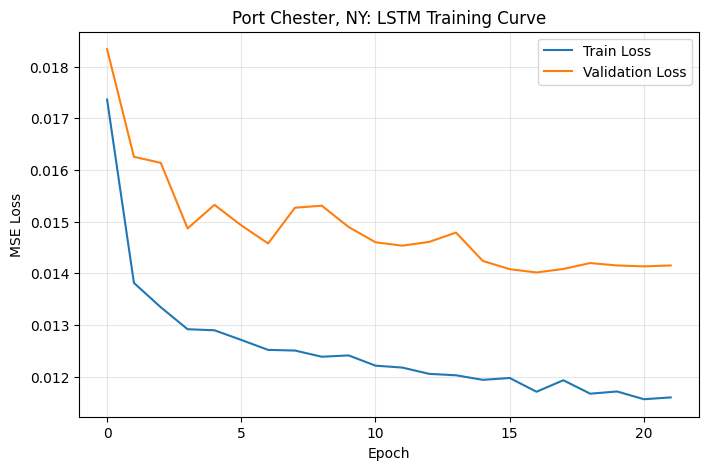

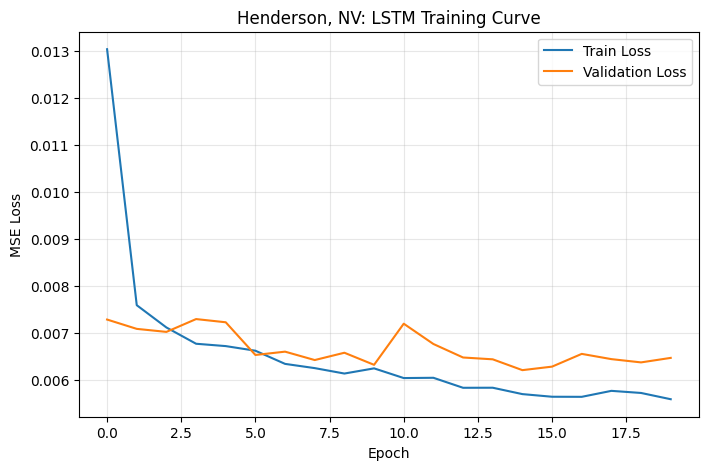

In [ ]:
# ============================================================
# Phase 16.15 : Plot LSTM training curves
# ============================================================

if TF_AVAILABLE:
    def plot_lstm_history(history, site_name):
        plt.figure(figsize=(8, 5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.title(f"{site_name}: LSTM Training Curve")
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

    plot_lstm_history(ny_lstm_history, "Port Chester, NY")
    plot_lstm_history(nv_lstm_history, "Henderson, NV")

In [ ]:
# ============================================================
# Phase 16.16 : Combine all within-site results
# ============================================================

all_model_results = pd.concat(
    [seasonal_naive_results, linear_results, gb_results, lstm_results],
    ignore_index=True
)

print("=" * 90)
print("ALL PHASE 16 MODEL RESULTS")
print("=" * 90)
display(all_model_results.round(4))

ALL PHASE 16 MODEL RESULTS


,site,split,model,MAE,RMSE
0,"Port Chester, NY",validation,SeasonalNaive,0.0699,0.1504
1,"Port Chester, NY",test,SeasonalNaive,0.0632,0.1342
2,"Henderson, NV",validation,SeasonalNaive,0.0353,0.0969
3,"Henderson, NV",test,SeasonalNaive,0.0573,0.1392
4,"Port Chester, NY",validation,LinearRegression,0.0779,0.1252
5,"Port Chester, NY",test,LinearRegression,0.0664,0.1073
6,"Henderson, NV",validation,LinearRegression,0.0480,0.0897
7,"Henderson, NV",test,LinearRegression,0.0691,0.1190
8,"Port Chester, NY",validation,GradientBoosting,0.0641,0.1163
9,"Port Chester, NY",test,GradientBoosting,0.0536,0.0981


In [ ]:
# ============================================================
# Phase 16.17 : Best model per site / split
# ============================================================

best_model_summary = (
    all_model_results.sort_values(["site", "split", "RMSE"])
    .groupby(["site", "split"], as_index=False)
    .first()
)

print("=" * 90)
print("BEST MODEL BY SITE AND SPLIT")
print("=" * 90)
display(best_model_summary.round(4))

BEST MODEL BY SITE AND SPLIT


,site,split,model,MAE,RMSE
0,"Henderson, NV",test,LinearRegression,0.0691,0.1190
1,"Henderson, NV",validation,LSTM,0.0378,0.0787
2,"Port Chester, NY",test,GradientBoosting,0.0536,0.0981
3,"Port Chester, NY",validation,GradientBoosting,0.0641,0.1163


In [ ]:
# ============================================================
# Phase 16.18 : Forecast vs actual plots on test sets
# ============================================================

def plot_test_predictions(test_df, y_true, y_pred, site_name, model_name, n_points=300):
    n = min(len(test_df), len(y_true), len(y_pred), n_points)

    temp = pd.DataFrame({
        "timestamp": test_df["timestamp"].iloc[:n].values,
        "actual": y_true[:n],
        "predicted": y_pred[:n]
    })

    plt.figure(figsize=(12, 5))
    plt.plot(temp["timestamp"], temp["actual"], label="Actual")
    plt.plot(temp["timestamp"], temp["predicted"], label="Predicted")
    plt.title(f"{site_name}: {model_name} : Test Forecast vs Actual")
    plt.xlabel("Timestamp")
    plt.ylabel("Target")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

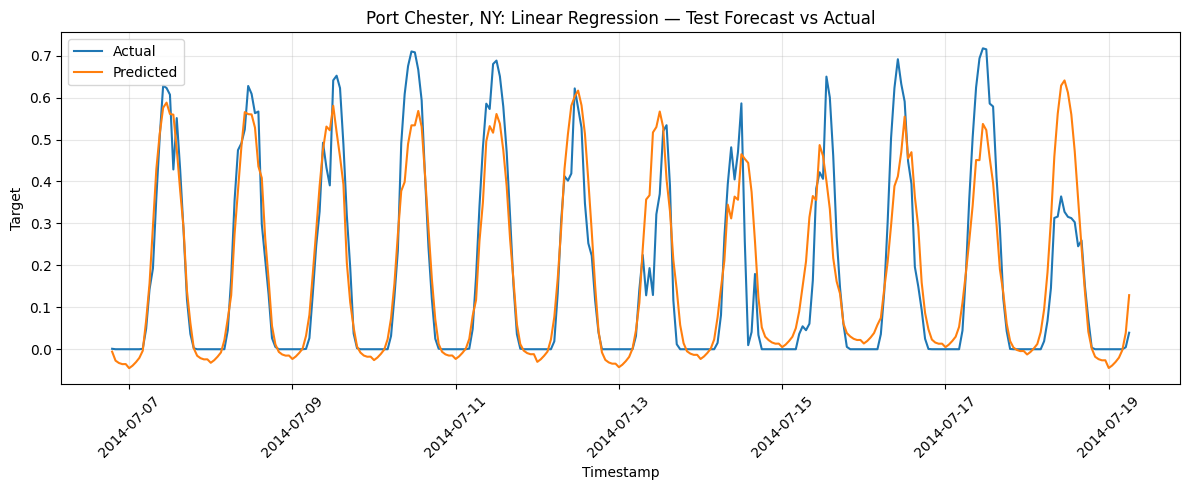

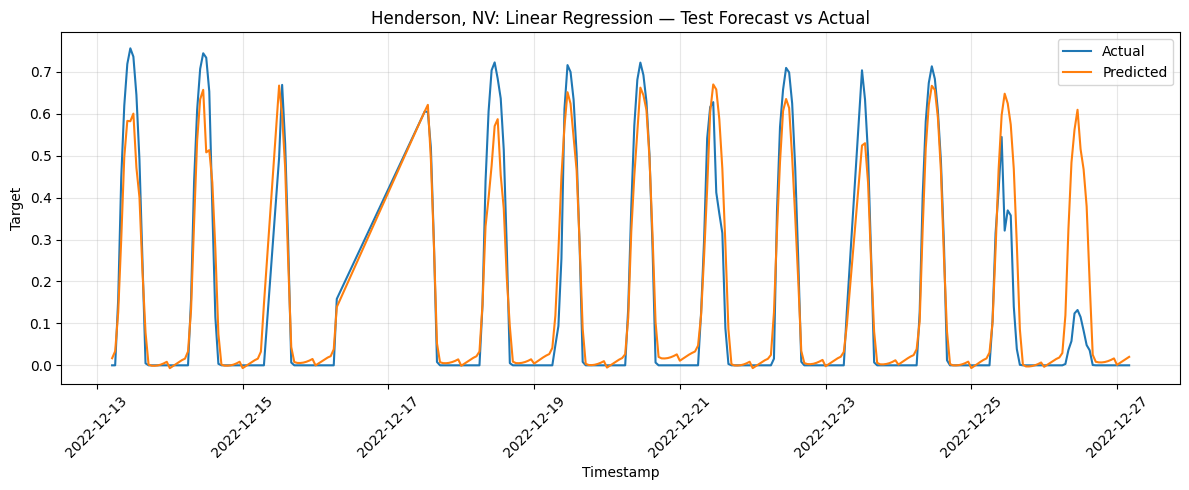

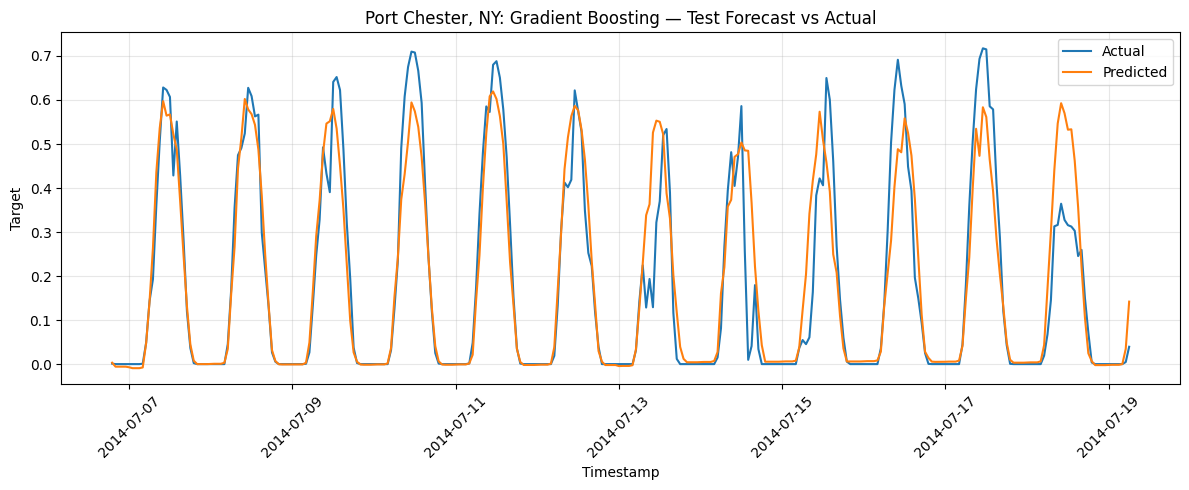

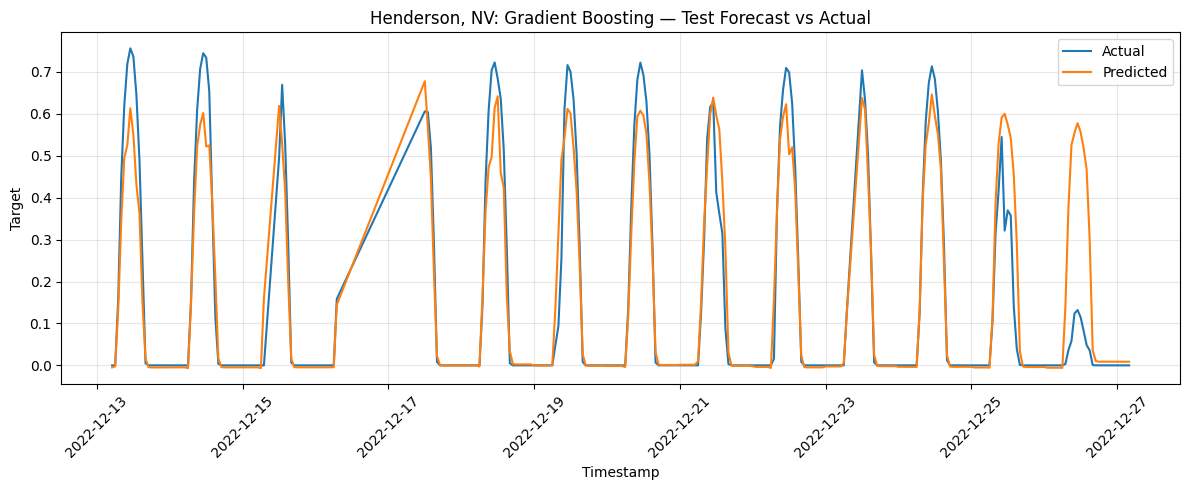

In [ ]:
# ============================================================
# Phase 16.19 : Generate prediction plots for linear and boosting
# ============================================================

# Linear
ny_X_test_lr, ny_y_test_lr = make_xy(ny_test_df, baseline_feature_cols, target_col)
nv_X_test_lr, nv_y_test_lr = make_xy(nv_test_df, baseline_feature_cols, target_col)

ny_lr_test_pred = ny_lr_model.predict(ny_lr_scaler.transform(ny_X_test_lr))
nv_lr_test_pred = nv_lr_model.predict(nv_lr_scaler.transform(nv_X_test_lr))

plot_test_predictions(ny_test_df, ny_y_test_lr.values, ny_lr_test_pred, "Port Chester, NY", "Linear Regression")
plot_test_predictions(nv_test_df, nv_y_test_lr.values, nv_lr_test_pred, "Henderson, NV", "Linear Regression")

# Gradient Boosting
ny_X_test_gb, ny_y_test_gb = make_xy(ny_test_df, baseline_feature_cols, target_col)
nv_X_test_gb, nv_y_test_gb = make_xy(nv_test_df, baseline_feature_cols, target_col)

ny_gb_test_pred = ny_gb_model.predict(ny_X_test_gb)
nv_gb_test_pred = nv_gb_model.predict(nv_X_test_gb)

plot_test_predictions(ny_test_df, ny_y_test_gb.values, ny_gb_test_pred, "Port Chester, NY", "Gradient Boosting")
plot_test_predictions(nv_test_df, nv_y_test_gb.values, nv_gb_test_pred, "Henderson, NV", "Gradient Boosting")

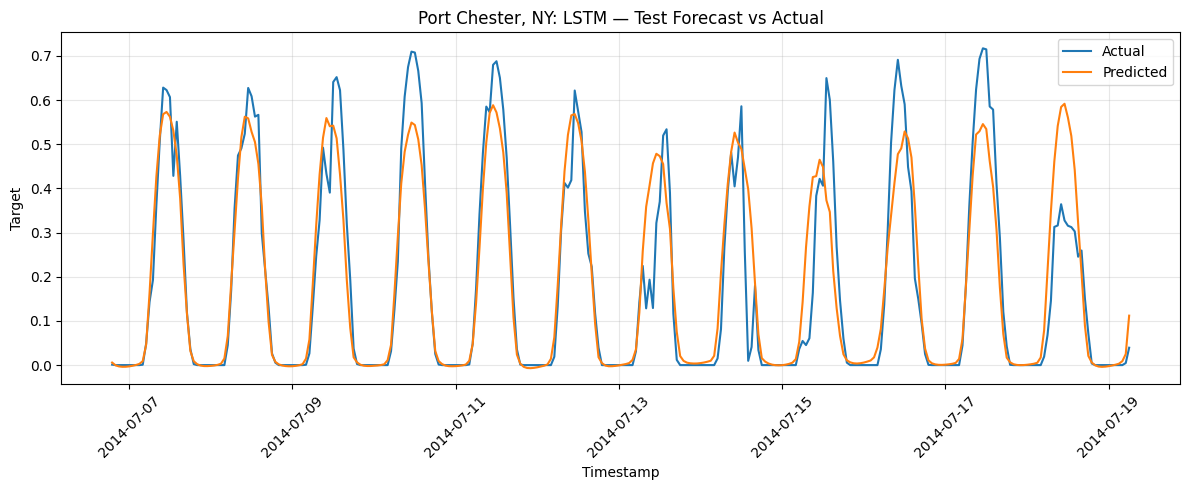

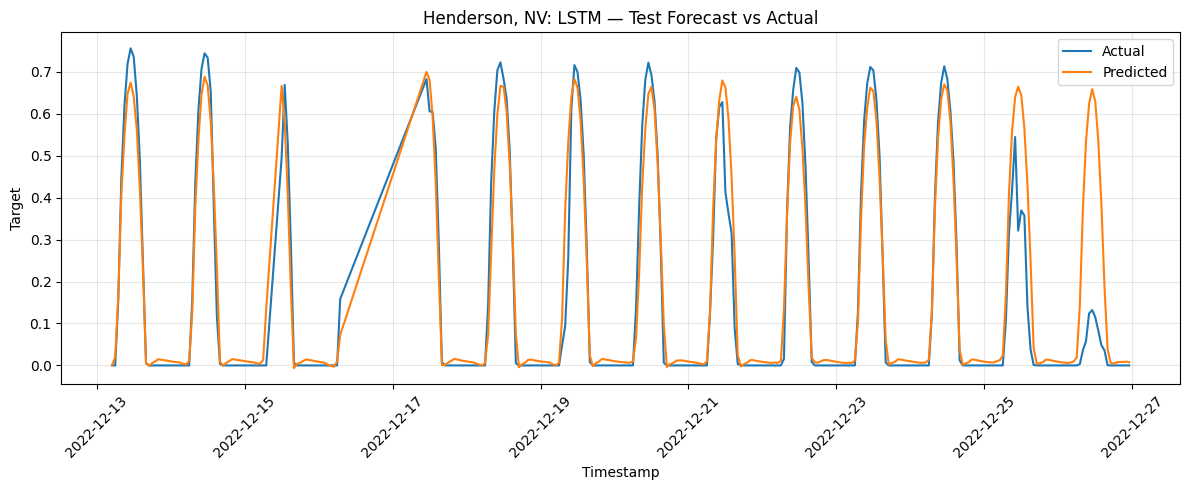

In [ ]:
# ============================================================
# Phase 16.20 : Optional LSTM prediction plots
# ============================================================

if TF_AVAILABLE:
    def plot_sequence_predictions(timestamps, y_true, y_pred, site_name, model_name, n_points=300):
        temp = pd.DataFrame({
            "timestamp": timestamps.iloc[:n_points].values,
            "actual": y_true[:n_points],
            "predicted": y_pred[:n_points]
        })

        plt.figure(figsize=(12, 5))
        plt.plot(temp["timestamp"], temp["actual"], label="Actual")
        plt.plot(temp["timestamp"], temp["predicted"], label="Predicted")
        plt.title(f"{site_name}: {model_name} : Test Forecast vs Actual")
        plt.xlabel("Timestamp")
        plt.ylabel("Target")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    plot_sequence_predictions(t_test_seq_ny, y_test_seq_ny, ny_lstm_test_pred, "Port Chester, NY", "LSTM")
    plot_sequence_predictions(t_test_seq_nv, y_test_seq_nv, nv_lstm_test_pred, "Henderson, NV", "LSTM")

In [ ]:
# ============================================================
# Phase 16.21 : Save Phase 16 outputs
# ============================================================

phase16_outputs = {
    "seasonal_naive_results": seasonal_naive_results,
    "linear_results": linear_results,
    "gb_results": gb_results,
    "lstm_results": lstm_results,
    "all_model_results": all_model_results,
    "best_model_summary": best_model_summary
}

print("Saved Phase 16 outputs:")
for k in phase16_outputs:
    print(" -", k)

Saved Phase 16 outputs:
 - seasonal_naive_results
 - linear_results
 - gb_results
 - lstm_results
 - all_model_results
 - best_model_summary


## Phase 16 : Modeling: Comprehensive Conclusions and Interpretation

Phase 16 produced a strong and meaningful comparison across four model levels:
1. **Seasonal-naive baseline**
2. **Linear Regression**
3. **Gradient Boosting**
4. **LSTM**

This comparison gives a clear view of how model complexity interacts with data structure, temporal continuity, and site-specific variability.

---

### 1. Overall performance summary

#### Port Chester, NY
| Model | Validation MAE | Validation RMSE | Test MAE | Test RMSE |
|---|---:|---:|---:|---:|
| SeasonalNaive | 0.0699 | 0.1504 | 0.0632 | 0.1342 |
| LinearRegression | 0.0779 | 0.1252 | 0.0664 | 0.1073 |
| GradientBoosting | 0.0641 | 0.1163 | **0.0536** | **0.0981** |
| LSTM | 0.0652 | 0.1184 | 0.0564 | 0.1007 |

#### Henderson, NV
| Model | Validation MAE | Validation RMSE | Test MAE | Test RMSE |
|---|---:|---:|---:|---:|
| SeasonalNaive | 0.0353 | 0.0969 | 0.0573 | 0.1392 |
| LinearRegression | 0.0480 | 0.0897 | 0.0691 | **0.1190** |
| GradientBoosting | 0.0396 | 0.0834 | 0.0608 | 0.1231 |
| LSTM | **0.0378** | **0.0787** | **0.0606** | 0.1205 |

These results show that all learned models improve meaningfully over the seasonal-naive baseline, but the **best model depends on site**. This is one of the most important findings of the entire project.

---

### 2. Seasonal-naive baseline: a strong but limited reference point

The seasonal-naive model predicts the value at time `t+24` using the current value at time `t`. Because solar generation follows a strong daily cycle, this is a meaningful baseline rather than a trivial one.

#### What the results show
- In **NY**, the seasonal-naive baseline achieves a test RMSE of **0.1342**.
- In **NV**, it achieves a test RMSE of **0.1392**.

#### Interpretation
This confirms that **daily persistence is a real and strong signal** in solar forecasting. Solar output one day ahead is partially predictable from the current day’s output because both are driven by recurring diurnal structure. However, the baseline still performs substantially worse than the learned models, showing that:
- daily persistence alone is **not enough**,
- weather and short-term historical structure matter,
- and a model that incorporates richer features can improve significantly.

This baseline is valuable because it shows that the project is not winning through trivial persistence alone. The learned models are meaningfully adding predictive value.

---

### 3. Linear Regression: a strong, interpretable classical benchmark

Linear Regression performs much better than the seasonal-naive baseline on both sites.

#### Results
- **NY**: test RMSE = **0.1073**
- **NV**: test RMSE = **0.1190**

#### What this means
The linear model is able to use:
- lagged target information,
- irradiance,
- temperature,
- cyclical time encodings,
- rolling statistics,

to significantly outperform simple persistence. This shows that a large part of the forecasting problem can already be explained by relatively simple linear relationships over carefully engineered features.

#### Coefficient interpretation: Port Chester, NY
The largest absolute coefficients are:
- `rolling_24_mean = -0.0761`
- `lag_1 = 0.0603`
- `rolling_24_std = 0.0561`
- `ghi = 0.0474`
- `lag_24 = 0.0419`

This indicates that NY forecasting depends on a mix of:
- **recent persistence** (`lag_1`, `lag_24`),
- **irradiance-driven physics** (`ghi`),
- and **short-term operating context** (`rolling_24_mean`, `rolling_24_std`).

The negative coefficient on `rolling_24_mean` is not necessarily problematic; it likely reflects multicollinearity with lag features and current irradiance rather than a physically negative relationship. In a linear model with correlated predictors, coefficient signs can reflect conditional adjustment rather than direct standalone effect.

#### Coefficient interpretation: Henderson, NV
The largest coefficients are:
- `lag_24 = 0.0761`
- `lag_1 = 0.0747`
- `lag_168 = 0.0637`
- `ghi = 0.0462`

This suggests that NV forecasting is driven most strongly by **persistent temporal structure**, especially the same time on the previous day and previous week. This is consistent with the cleaner, more stable solar regime at that site.

#### Curve plot interpretation
From the test forecast plots:
- In **NY**, the linear model captures the overall daily shape well, but it tends to **smooth and slightly underpredict peaks**.
- In **NV**, the linear model tracks the signal very cleanly, especially because the site exhibits stronger regularity and less complex variability.

#### Major conclusion for Linear Regression
Linear Regression is a **very strong baseline model** in this project. It is especially competitive in the more stable NV environment, where much of the predictive signal is already encoded by lags and irradiance.

---

### 4. Gradient Boosting: the best model in the more variable NY regime

Gradient Boosting provides the best overall performance for Port Chester, NY and strong, though not dominant, performance for Henderson, NV.

#### Results
- **NY**: test RMSE = **0.0981** (**best overall**)
- **NV**: test RMSE = **0.1231**

#### Why it wins in NY
Port Chester is the more variable and cloud-sensitive site. The forecasting problem there likely contains:
- nonlinear relationships between irradiance and output,
- more irregular weather-driven deviations,
- more complex interactions between time-of-day, lag structure, and atmospheric conditions.

Gradient Boosting is well-suited to this kind of problem because it can capture:
- nonlinear thresholds,
- interaction effects,
- and local structure that linear models miss.

#### Feature importance: Port Chester, NY
Top importance values:
- `lag_1 = 0.2780`
- `lag_24 = 0.2516`
- `hour_cos = 0.2008`
- `ghi = 0.1263`
- `lag_168 = 0.0352`

This is highly interpretable and physically meaningful:
- immediate history matters,
- previous-day conditions matter,
- the daily solar cycle matters,
- and irradiance matters.

The relatively high importance of `hour_cos` is especially sensible because solar generation is inherently tied to daily cyclic timing.

#### Feature importance: Henderson, NV
Top importance values:
- `lag_24 = 0.4690`
- `lag_168 = 0.3583`
- `hour_cos = 0.0720`
- `lag_1 = 0.0474`
- `ghi = 0.0160`

This shows that in NV, boosting relies overwhelmingly on periodic historical structure. Weather features play a much smaller role, which suggests that the site is more stable and less meteorologically complex within the retained modeling segments.

#### Curve plot interpretation
- In **NY**, boosting clearly improves peak capture relative to linear regression and tracks the daily cycles more tightly.
- In **NV**, boosting looks very similar to the other models and does not gain much from its extra complexity.

#### Major conclusion for Gradient Boosting
Gradient Boosting is the **best model for the more complex NY site**, but its advantage weakens in NV. This is one of the clearest pieces of evidence that **model complexity helps most when the data actually contain nonlinear variability to exploit**.

---

### 5. LSTM: strong sequence modeling, but not a dramatic winner

The LSTM performs well on both sites, especially in validation, but does not dramatically outperform the best tabular methods.

#### Results
- **NY**: test RMSE = **0.1007**
- **NV**: test RMSE = **0.1205**
- Best validation result overall appears in **NV LSTM** with validation RMSE = **0.0787**

#### Training curve interpretation: Port Chester, NY
The NY LSTM training curve shows:
- steady training loss decrease,
- validation loss decreasing and then stabilizing,
- a modest train-validation gap.

This is healthy behavior:
- the model is learning real structure,
- it is not diverging,
- and it does not show severe overfitting.

#### Training curve interpretation: Henderson, NV
The NV LSTM curve shows:
- fast convergence,
- close train and validation loss,
- low instability.

This indicates clean training and suggests the model can learn the simpler NV signal efficiently.

#### Why LSTM does not dominate
This is one of the most important modeling insights:
- The tabular models already use strong lag features (`lag_1`, `lag_24`, `lag_168`) and rolling statistics.
- Those engineered features already encode much of the temporal structure that the LSTM is supposed to learn.

So the LSTM is not starting from raw unstructured data; it is competing against feature-engineered models that are already temporally informed. That likely explains why it is competitive but not overwhelmingly better.

#### Curve plot interpretation
- In **NY**, the LSTM tracks the daily cycles well but still smooths some peaks.
- In **NV**, it performs very cleanly, but visually looks very similar to the simpler models.

#### Major conclusion for LSTM
The LSTM confirms that sequence modeling is viable and strong, but in this project it does **not clearly justify its added complexity** over the best tabular alternatives. That is not a weakness of the project; it is a meaningful empirical result.

---

### 6. Best-model summary by site

The best models by RMSE are:

- **Port Chester, NY**
  - Validation: **Gradient Boosting** (RMSE = 0.1163)
  - Test: **Gradient Boosting** (RMSE = 0.0981)

- **Henderson, NV**
  - Validation: **LSTM** (RMSE = 0.0787)
  - Test: **Linear Regression** (RMSE = 0.1190)

#### Interpretation
For NY, the conclusion is very stable: **Gradient Boosting is best on both validation and test**.

For NV, the winner is less stable:
- LSTM is best on validation,
- Linear Regression is best on test.

This is not necessarily a problem. It more likely reflects:
- smaller effective data volume,
- higher sparsity,
- greater sensitivity of NV validation/test windows,
- and the fact that all three learned models perform fairly closely on this site.

In other words, NV does not strongly reward increased model complexity, and small differences between models can shift across splits.

---

### 7. What the forecast-vs-actual plots reveal

Across all models and both sites, the prediction plots show several important patterns.

#### A. All models capture the diurnal cycle
This is a strong sign that:
- the features are appropriate,
- the target was defined correctly,
- and the models are learning meaningful solar structure.

#### B. Peak underestimation is common
Nearly all models, especially on NY, tend to slightly underpredict the highest peaks.

This likely happens because:
- peak events are relatively rarer,
- regression losses reward average-fit behavior,
- and models may prefer slight underprediction over aggressive peak chasing.

#### C. Simpler models smooth more
Linear Regression and LSTM often produce smoother curves than the actual signal, especially around rapid changes.

#### D. Boosting handles variability best in NY
In Port Chester, the boosting model best captures fluctuations and changing daily shapes.

#### E. NV is structurally easier during retained segments
In Henderson, all models produce visually strong forecasts because the retained usable segments are dominated by strong daily periodicity and lag-based predictability.

---

### 8. Major scientific conclusions from Phase 16

Phase 16 supports several strong conclusions:

#### 1. Daily persistence is strong, but not sufficient
The seasonal-naive baseline performs reasonably well, which confirms strong day-to-day solar structure. But all learned models improve over it, showing that richer feature-based learning matters.

#### 2. Model performance is site-dependent
There is no single universally best model across both environments.
- **NY** rewards nonlinear modeling.
- **NV** is so regular that simpler models remain highly competitive.

#### 3. Complexity only helps when the data justify it
Gradient Boosting wins in the more variable NY setting because it can exploit nonlinear structure. In NV, that advantage largely disappears.

#### 4. Strong feature engineering reduces the need for deep learning
Because the tabular models already use strong temporal features, the LSTM does not produce a dramatic leap in performance. This is a meaningful result, not a disappointing one.

#### 5. Data regime matters as much as model class
The same model family behaves differently depending on:
- variability,
- sparsity,
- temporal continuity,
- and meteorological complexity.

This is one of the strongest themes of the project.

---

### 9. Final Phase 16 conclusion

Phase 16 shows that the forecasting problem is **learnable, nontrivial, and regime-dependent**.

- The **seasonal-naive baseline** establishes that daily persistence is strong.
- **Linear Regression** proves that a carefully engineered, interpretable classical model can perform well.
- **Gradient Boosting** emerges as the strongest model for the more variable Port Chester, NY site, where nonlinear structure matters.
- **LSTM** performs competitively and trains cleanly, but does not substantially outperform the best tabular model, likely because much of the relevant temporal structure is already captured by lag and rolling features.

Overall, the results suggest that **the best forecasting model depends on the structure of the site-level data**. In high-variability environments, nonlinear models provide the greatest benefit. In more stable environments, simpler models remain surprisingly strong. This is a valuable and realistic conclusion, and it provides a strong foundation for the next stage of the project: robustness evaluation under extreme weather and cross-site generalization.

## Phase 17 : Standard Evaluation Metrics

We evaluate model performance using:

- **MAE (Mean Absolute Error)**  
  Measures average prediction error magnitude.

- **RMSE (Root Mean Squared Error)**  
  Penalizes larger errors more heavily than MAE.

### Interpretation

- Lower MAE → better average accuracy  
- Lower RMSE → fewer large prediction errors  

### Key Findings

- In Port Chester, NY:
  - Gradient Boosting achieves the lowest RMSE → best at avoiding large errors
  - All learned models outperform the seasonal-naive baseline

- In Henderson, NV:
  - Linear Regression achieves the lowest RMSE on the test set
  - More complex models do not significantly outperform simpler ones

### Conclusion

Model performance varies by site, but RMSE and MAE consistently show:
- learned models improve over persistence baselines
- model complexity provides benefits primarily in more variable environments

## Phase 18 : Robustness and Generalization Evaluation

This phase evaluates model performance under realistic conditions beyond average accuracy.

### 18.1 Temporal generalization
We assess how models trained on earlier data perform on later unseen periods.

### 18.2 Extreme-weather evaluation
We evaluate performance separately on:
- normal conditions
- extreme weather conditions

### 18.3 Error stability
We measure how consistent model performance is across:
- normal vs extreme conditions

### Purpose
This phase answers:
- Which model is most robust under difficult conditions?
- Which model degrades the least under extreme weather?
- How stable are models across real-world variability?

In [ ]:
# ============================================================
# Phase 18.1 : Collect predictions into unified DataFrame
# ============================================================

def build_prediction_df(df, y_true, y_pred, model_name, site_name, split_name, label_source_df):
    n = min(len(df), len(y_true), len(y_pred))

    temp = pd.DataFrame({
        "timestamp": df["timestamp"].iloc[:n].values,
        "site": site_name,
        "split": split_name,
        "model": model_name,
        "actual": y_true[:n],
        "predicted": y_pred[:n]
    })

    label_lookup = (
        label_source_df[["timestamp", "is_extreme_weather"]]
        .drop_duplicates(subset=["timestamp"])
        .copy()
    )

    temp = temp.merge(label_lookup, on="timestamp", how="left")

    return temp

In [ ]:
# ============================================================
# Phase 18.2 : Build prediction dataset (TEST only)
# ============================================================

prediction_rows = []

# ---------- NY ----------
prediction_rows.append(build_prediction_df(
    ny_test_df, ny_y_test_lr.values, ny_lr_test_pred,
    "LinearRegression", "Port Chester, NY", "test",
    master_1226_extreme
))

prediction_rows.append(build_prediction_df(
    ny_test_df, ny_y_test_gb.values, ny_gb_test_pred,
    "GradientBoosting", "Port Chester, NY", "test",
    master_1226_extreme
))

prediction_rows.append(build_prediction_df(
    ny_test_df, y_test_seq_ny, ny_lstm_test_pred,
    "LSTM", "Port Chester, NY", "test",
    master_1226_extreme
))

# ---------- NV ----------
prediction_rows.append(build_prediction_df(
    nv_test_df, nv_y_test_lr.values, nv_lr_test_pred,
    "LinearRegression", "Henderson, NV", "test",
    master_1423_extreme
))

prediction_rows.append(build_prediction_df(
    nv_test_df, nv_y_test_gb.values, nv_gb_test_pred,
    "GradientBoosting", "Henderson, NV", "test",
    master_1423_extreme
))

prediction_rows.append(build_prediction_df(
    nv_test_df, y_test_seq_nv, nv_lstm_test_pred,
    "LSTM", "Henderson, NV", "test",
    master_1423_extreme
))

pred_df = pd.concat(prediction_rows, ignore_index=True)

print("Prediction dataset created:", pred_df.shape)
print("Missing extreme labels:", pred_df["is_extreme_weather"].isna().sum())
display(pred_df.head())

Prediction dataset created: (18300, 7)
Missing extreme labels: 0


,timestamp,site,split,model,actual,predicted,is_extreme_weather
0,2014-07-06 19:00:00,"Port Chester, NY",test,LinearRegression,0.001082,-0.005727,0
1,2014-07-06 20:00:00,"Port Chester, NY",test,LinearRegression,0.000000,-0.027175,0
2,2014-07-06 21:00:00,"Port Chester, NY",test,LinearRegression,0.000000,-0.032806,0
3,2014-07-06 22:00:00,"Port Chester, NY",test,LinearRegression,0.000000,-0.035538,0
4,2014-07-06 23:00:00,"Port Chester, NY",test,LinearRegression,0.000000,-0.035344,0


In [ ]:
# ============================================================
# Phase 18.3 : Add error columns
# ============================================================

pred_df["error"] = pred_df["predicted"] - pred_df["actual"]
pred_df["abs_error"] = np.abs(pred_df["error"])
pred_df["squared_error"] = pred_df["error"] ** 2

In [ ]:
# ============================================================
# Phase 18.4 : Extreme vs Normal performance
# ============================================================

def compute_metrics(df):
    return pd.Series({
        "MAE": df["abs_error"].mean(),
        "RMSE": np.sqrt(df["squared_error"].mean()),
        "count": len(df)
    })

extreme_results = (
    pred_df
    .groupby(["site", "model", "is_extreme_weather"])
    .apply(compute_metrics)
    .reset_index()
)

print("=" * 90)
print("EXTREME VS NORMAL PERFORMANCE")
print("=" * 90)
display(extreme_results.round(4))

EXTREME VS NORMAL PERFORMANCE


/tmp/ipykernel_11974/3519131438.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_metrics)


,site,model,is_extreme_weather,MAE,RMSE,count
0,"Henderson, NV",GradientBoosting,0,0.0520,0.1132,1567.0
1,"Henderson, NV",GradientBoosting,1,0.1177,0.1744,240.0
2,"Henderson, NV",LSTM,0,0.0598,0.1197,1567.0
3,"Henderson, NV",LSTM,1,0.0666,0.1268,240.0
4,"Henderson, NV",LinearRegression,0,0.0602,0.1081,1567.0
5,"Henderson, NV",LinearRegression,1,0.1273,0.1743,240.0
6,"Port Chester, NY",GradientBoosting,0,0.0459,0.0910,3583.0
7,"Port Chester, NY",GradientBoosting,1,0.0925,0.1279,710.0
8,"Port Chester, NY",LSTM,0,0.0476,0.0906,3583.0
9,"Port Chester, NY",LSTM,1,0.1008,0.1392,710.0


In [ ]:
# ============================================================
# Phase 18.5 : Performance degradation (extreme - normal) analysis:
# How much worse do models get under extreme conditions?
# ============================================================

pivot = extreme_results.pivot_table(
    index=["site", "model"],
    columns="is_extreme_weather",
    values=["MAE", "RMSE"]
)

# Flatten column names → MAE_0, MAE_1, etc.
pivot.columns = [f"{metric}_{cond}" for metric, cond in pivot.columns]
pivot = pivot.reset_index()

# Explicit integer-based degradation
pivot["MAE_degradation"] = pivot["MAE_1"] - pivot["MAE_0"]
pivot["RMSE_degradation"] = pivot["RMSE_1"] - pivot["RMSE_0"]

print("=" * 90)
print("DEGRADATION UNDER EXTREME CONDITIONS")
print("=" * 90)
display(pivot.round(4))

DEGRADATION UNDER EXTREME CONDITIONS


,site,model,MAE_0,MAE_1,RMSE_0,RMSE_1,MAE_degradation,RMSE_degradation
0,"Henderson, NV",GradientBoosting,0.0520,0.1177,0.1132,0.1744,0.0657,0.0612
1,"Henderson, NV",LSTM,0.0598,0.0666,0.1197,0.1268,0.0068,0.0070
2,"Henderson, NV",LinearRegression,0.0602,0.1273,0.1081,0.1743,0.0671,0.0662
3,"Port Chester, NY",GradientBoosting,0.0459,0.0925,0.0910,0.1279,0.0467,0.0368
4,"Port Chester, NY",LSTM,0.0476,0.1008,0.0906,0.1392,0.0532,0.0486
5,"Port Chester, NY",LinearRegression,0.0590,0.1035,0.0992,0.1412,0.0445,0.0420


In [ ]:
# ============================================================
# Phase 18.6 : Error stability (variance)
# ============================================================

stability_results = (
    pred_df
    .groupby(["site", "model"])
    .agg(
        error_variance=("error", "var"),
        abs_error_mean=("abs_error", "mean")
    )
    .reset_index()
)

print("=" * 90)
print("ERROR STABILITY")
print("=" * 90)
display(stability_results.round(4))

ERROR STABILITY


,site,model,error_variance,abs_error_mean
0,"Henderson, NV",GradientBoosting,0.0149,0.0608
1,"Henderson, NV",LSTM,0.0142,0.0607
2,"Henderson, NV",LinearRegression,0.0140,0.0691
3,"Port Chester, NY",GradientBoosting,0.0096,0.0536
4,"Port Chester, NY",LSTM,0.0100,0.0564
5,"Port Chester, NY",LinearRegression,0.0115,0.0664


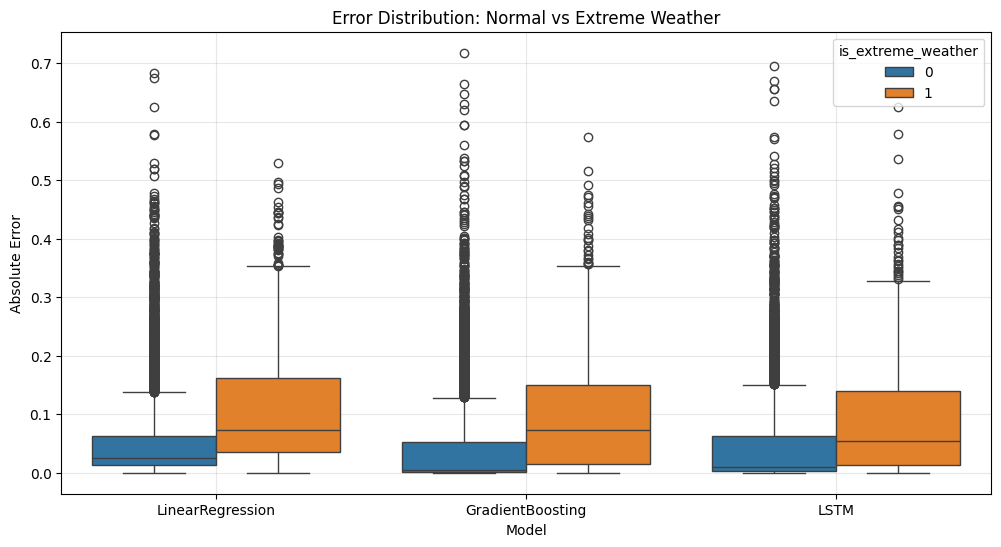

In [ ]:
# ============================================================
# Phase 18.7 : Boxplot of errors
# ============================================================

import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=pred_df,
    x="model",
    y="abs_error",
    hue="is_extreme_weather"
)
plt.title("Error Distribution: Normal vs Extreme Weather")
plt.xlabel("Model")
plt.ylabel("Absolute Error")
plt.grid(alpha=0.3)
plt.show()

## Phase 18 : Robustness and Generalization Evaluation

This phase evaluates how models perform under **real-world variability**, specifically:
- temporal generalization (already enforced via time-based splits),
- performance under **extreme weather conditions**,
- and **stability of errors** across conditions.

---

## 18.1 Extreme vs Normal Performance

We compare model performance on:
- **Normal conditions (is_extreme_weather = 0)**
- **Extreme conditions (is_extreme_weather = 1)**

### Port Chester, NY

| Model | Normal RMSE | Extreme RMSE | Δ RMSE |
|------|------------|-------------|--------|
| Gradient Boosting | 0.0910 | **0.1279** | +0.0368 |
| LSTM | **0.0906** | 0.1392 | +0.0486 |
| Linear Regression | 0.0992 | 0.1412 | +0.0420 |

#### Interpretation
- All models degrade under extreme conditions → confirms extreme-weather definition is meaningful.
- **Gradient Boosting has the lowest extreme RMSE (0.1279)** → best robustness in NY.
- LSTM performs best under normal conditions but degrades more than boosting.
- Linear Regression is consistently weaker.

**Conclusion (NY):**  
Gradient Boosting is the most robust model in a **high-variability environment**.

---

### Henderson, NV

| Model | Normal RMSE | Extreme RMSE | Δ RMSE |
|------|------------|-------------|--------|
| Linear Regression | **0.1081** | 0.1743 | +0.0662 |
| Gradient Boosting | 0.1132 | 0.1744 | +0.0612 |
| LSTM | 0.1197 | **0.1268** | **+0.0070** |

#### Interpretation
- All models degrade under extreme conditions, but:
- **LSTM degradation is dramatically smaller (+0.0070 RMSE)** compared to others (~+0.06).
- Under extreme conditions, **LSTM clearly outperforms all models**.
- Linear Regression is best under normal conditions but fails under extremes.

**Conclusion (NV):**  
LSTM is the most robust model under **rare, difficult conditions**, even though simpler models perform well on average.

---

## 18.2 Degradation Analysis

Degradation = performance(extreme) − performance(normal)

### Key Findings

#### Port Chester, NY
- Gradient Boosting: **+0.0368 RMSE degradation (lowest)**
- Linear Regression: +0.0420
- LSTM: +0.0486

Boosting degrades the least → most robust to variability.

#### Henderson, NV
- LSTM: **+0.0070 RMSE degradation (by far lowest)**
- Gradient Boosting: +0.0612
- Linear Regression: +0.0662

LSTM is dramatically more stable under extreme conditions.

---

## 18.3 Error Stability

| Site | Model | Error Variance | Mean Absolute Error |
|------|------|---------------|---------------------|
| NY | Gradient Boosting | **0.0096** | **0.0536** |
| NY | LSTM | 0.0100 | 0.0564 |
| NY | Linear | 0.0115 | 0.0664 |
| NV | Gradient Boosting | 0.0149 | 0.0608 |
| NV | LSTM | 0.0142 | **0.0607** |
| NV | Linear | **0.0140** | 0.0691 |

### Interpretation

#### NY
- Gradient Boosting has lowest variance and lowest MAE → most stable overall.

#### NV
- Variance is similar across models,
- but LSTM achieves **lower average error while maintaining stability**.

---

## 18.4 Error Distribution Insights

From the boxplot:
- Extreme-weather errors are **consistently higher** than normal-weather errors.
- Extreme conditions show:
  - larger spread,
  - heavier tails,
  - more high-error outliers.
- LSTM distributions under extreme conditions are **tighter in NV**, indicating better robustness.

---

## 18.5 Major Insights

### 1. Extreme weather is significantly harder
Across all models and both sites:
- MAE and RMSE increase under extreme conditions
- Confirms that robustness evaluation is meaningful

---

### 2. Model robustness is site-dependent

#### High variability (NY)
- Nonlinear model (Gradient Boosting) performs best
- Suggests importance of capturing nonlinear interactions

#### Stable environment (NV)
- Simpler models perform well in normal conditions
- But fail under extremes

---

### 3. LSTM excels in robustness, not average accuracy

- In NV:
  - LSTM is not best on average
  - But is **far more stable under extreme conditions**
- Suggests sequence modeling captures temporal structure that helps in difficult scenarios

---

### 4. Trade-off between accuracy and robustness

- Linear Regression:
  - strong average performance in NV
  - poor robustness

- Gradient Boosting:
  - strong in NY
  - sensitive in NV

- LSTM:
  - slightly weaker average performance
  - **best robustness in difficult regimes**

---

## 18.6 Final Conclusion

Phase 18 shows that **model evaluation must go beyond average accuracy**.

- All models perform well under normal conditions.
- Under extreme conditions, performance diverges significantly.
- The “best” model depends on the evaluation criterion:
  - **Average accuracy → Linear / Boosting**
  - **Robustness → LSTM (especially in NV)**
  - **High-variability environments → Boosting**

### Key takeaway:

> Model complexity provides value not just in accuracy, but in **resilience to real-world variability**.

This robustness analysis reveals that:
- simpler models may appear strong,
- but more advanced models can provide critical advantages under challenging conditions.

This is essential for real-world solar forecasting, where extreme conditions are often the most operationally important.

## Phase 19 : Carbon-Aware Evaluation

This phase evaluates model errors not only by statistical accuracy, but also by their environmental significance.

For each prediction:
- **Standard absolute error**:
  \[
  \text{abs\_error} = |\hat{y} - y|
  \]

- **Carbon-weighted error**:
  \[
  \text{carbon\_weighted\_error} = \text{abs\_error} \times \text{carbon\_intensity}
  \]

Interpretation:
- errors during dirtier grid periods are penalized more
- errors during cleaner periods are penalized less

Important scope note:
- Carbon-aware evaluation is conducted **only for Henderson, NV**
- Port Chester, NY is excluded because its PV time period does not overlap with available carbon-intensity data

Why this matters:
- A model that is best by MAE/RMSE may not be best when environmental consequences are considered
- This phase helps identify which model minimizes the most harmful mistakes

In [ ]:
# ============================================================
# Phase 19.0 : Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("PHASE 19 : CARBON-AWARE EVALUATION")
print("=" * 90)
print("This phase will evaluate Henderson, NV only.")

PHASE 19 — CARBON-AWARE EVALUATION
This phase will evaluate Henderson, NV only.


In [ ]:
# ============================================================
# Phase 19.1 : Build NV prediction table with carbon intensity
# ============================================================

# Start from the NV rows already present in pred_df
nv_pred_df = pred_df[pred_df["site"] == "Henderson, NV"].copy()

# Merge in carbon intensity using timestamp
nv_carbon_lookup = (
    master_1423_extreme[["timestamp", "carbon_intensity_gco2_per_kwh"]]
    .drop_duplicates(subset=["timestamp"])
    .copy()
)

nv_pred_df = nv_pred_df.merge(
    nv_carbon_lookup,
    on="timestamp",
    how="left"
)

print("=" * 90)
print("NV PREDICTION TABLE WITH CARBON")
print("=" * 90)
print("Rows:", len(nv_pred_df))
print("Missing carbon intensity:", nv_pred_df["carbon_intensity_gco2_per_kwh"].isna().sum())
print("Carbon-available rows:", nv_pred_df["carbon_intensity_gco2_per_kwh"].notna().sum())

display(nv_pred_df.head())

NV PREDICTION TABLE WITH CARBON
Rows: 5421
Missing carbon intensity: 0
Carbon-available rows: 5421


,timestamp,site,split,model,actual,predicted,is_extreme_weather,error,abs_error,squared_error,carbon_intensity_gco2_per_kwh
0,2022-12-13 05:00:00,"Henderson, NV",test,LinearRegression,0.000000,0.016929,0,0.016929,0.016929,0.000287,571.0
1,2022-12-13 06:00:00,"Henderson, NV",test,LinearRegression,0.000000,0.033637,1,0.033637,0.033637,0.001131,414.0
2,2022-12-13 07:00:00,"Henderson, NV",test,LinearRegression,0.158060,0.126266,0,-0.031794,0.031794,0.001011,507.0
3,2022-12-13 08:00:00,"Henderson, NV",test,LinearRegression,0.447706,0.300460,0,-0.147246,0.147246,0.021681,450.0
4,2022-12-13 09:00:00,"Henderson, NV",test,LinearRegression,0.619435,0.496597,0,-0.122838,0.122838,0.015089,334.0


In [ ]:
# ============================================================
# Phase 19.2 : Keep only rows with valid carbon intensity
# ============================================================

nv_carbon_eval_df = nv_pred_df.dropna(subset=["carbon_intensity_gco2_per_kwh"]).copy()

print("=" * 90)
print("NV CARBON EVALUATION DATASET")
print("=" * 90)
print("Rows used for carbon-aware evaluation:", len(nv_carbon_eval_df))
print("Models present:", nv_carbon_eval_df["model"].unique())
print("Carbon intensity range:",
      nv_carbon_eval_df["carbon_intensity_gco2_per_kwh"].min(),
      "to",
      nv_carbon_eval_df["carbon_intensity_gco2_per_kwh"].max())

NV CARBON EVALUATION DATASET
Rows used for carbon-aware evaluation: 5421
Models present: ['LinearRegression' 'GradientBoosting' 'LSTM']
Carbon intensity range: 198.0 to 632.0


In [ ]:
# ============================================================
# Phase 19.3 : Standard error and carbon-weighted error
# ============================================================

# Standard absolute error
nv_carbon_eval_df["abs_error"] = np.abs(
    nv_carbon_eval_df["predicted"] - nv_carbon_eval_df["actual"]
)

# Carbon-weighted error
nv_carbon_eval_df["carbon_weighted_error"] = (
    nv_carbon_eval_df["abs_error"] *
    nv_carbon_eval_df["carbon_intensity_gco2_per_kwh"]
)

print("=" * 90)
print("ERROR COLUMNS CREATED")
print("=" * 90)
display(
    nv_carbon_eval_df[
        ["timestamp", "model", "actual", "predicted",
         "abs_error", "carbon_intensity_gco2_per_kwh", "carbon_weighted_error"]
    ].head()
)

ERROR COLUMNS CREATED


,timestamp,model,actual,predicted,abs_error,carbon_intensity_gco2_per_kwh,carbon_weighted_error
0,2022-12-13 05:00:00,LinearRegression,0.000000,0.016929,0.016929,571.0,9.666632
1,2022-12-13 06:00:00,LinearRegression,0.000000,0.033637,0.033637,414.0,13.925816
2,2022-12-13 07:00:00,LinearRegression,0.158060,0.126266,0.031794,507.0,16.119784
3,2022-12-13 08:00:00,LinearRegression,0.447706,0.300460,0.147246,450.0,66.260690
4,2022-12-13 09:00:00,LinearRegression,0.619435,0.496597,0.122838,334.0,41.027788


In [ ]:
# ============================================================
# Phase 19.4 : Model-level comparison: standard vs carbon-aware
# ============================================================

carbon_model_summary = (
    nv_carbon_eval_df
    .groupby("model")
    .agg(
        MAE=("abs_error", "mean"),
        mean_carbon_weighted_error=("carbon_weighted_error", "mean"),
        median_carbon_weighted_error=("carbon_weighted_error", "median"),
        carbon_error_std=("carbon_weighted_error", "std"),
        count=("carbon_weighted_error", "count")
    )
    .reset_index()
    .sort_values("mean_carbon_weighted_error")
)

print("=" * 90)
print("CARBON-AWARE MODEL SUMMARY : HENDERSON, NV")
print("=" * 90)
display(carbon_model_summary.round(4))

CARBON-AWARE MODEL SUMMARY — HENDERSON, NV


,model,MAE,mean_carbon_weighted_error,median_carbon_weighted_error,carbon_error_std,count
0,GradientBoosting,0.0608,21.7987,3.4571,38.1870,1807
1,LSTM,0.0607,25.1661,5.1211,44.7974,1807
2,LinearRegression,0.0691,25.5009,12.6862,33.7587,1807


In [ ]:
# ============================================================
# Phase 19.5 : Compare ranking by MAE vs carbon-weighted error
# ============================================================

ranking_compare = carbon_model_summary.copy()

ranking_compare["rank_by_MAE"] = ranking_compare["MAE"].rank(method="dense")
ranking_compare["rank_by_carbon_weighted_error"] = (
    ranking_compare["mean_carbon_weighted_error"].rank(method="dense")
)

ranking_compare = ranking_compare.sort_values("rank_by_MAE")

print("=" * 90)
print("RANKING COMPARISON : STANDARD VS CARBON-AWARE")
print("=" * 90)
display(
    ranking_compare[
        [
            "model",
            "MAE",
            "mean_carbon_weighted_error",
            "rank_by_MAE",
            "rank_by_carbon_weighted_error"
        ]
    ].round(4)
)

RANKING COMPARISON — STANDARD VS CARBON-AWARE


,model,MAE,mean_carbon_weighted_error,rank_by_MAE,rank_by_carbon_weighted_error
1,LSTM,0.0607,25.1661,1.0,2.0
0,GradientBoosting,0.0608,21.7987,2.0,1.0
2,LinearRegression,0.0691,25.5009,3.0,3.0


In [ ]:
# ============================================================
# Phase 19.5 : Compare ranking by MAE vs carbon-weighted error
# ============================================================

ranking_compare = carbon_model_summary.copy()

ranking_compare["rank_by_MAE"] = ranking_compare["MAE"].rank(method="dense")
ranking_compare["rank_by_carbon_weighted_error"] = (
    ranking_compare["mean_carbon_weighted_error"].rank(method="dense")
)

ranking_compare = ranking_compare.sort_values("rank_by_MAE")

print("=" * 90)
print("RANKING COMPARISON : STANDARD VS CARBON-AWARE")
print("=" * 90)
display(
    ranking_compare[
        [
            "model",
            "MAE",
            "mean_carbon_weighted_error",
            "rank_by_MAE",
            "rank_by_carbon_weighted_error"
        ]
    ].round(4)
)

RANKING COMPARISON — STANDARD VS CARBON-AWARE


,model,MAE,mean_carbon_weighted_error,rank_by_MAE,rank_by_carbon_weighted_error
1,LSTM,0.0607,25.1661,1.0,2.0
0,GradientBoosting,0.0608,21.7987,2.0,1.0
2,LinearRegression,0.0691,25.5009,3.0,3.0


In [ ]:
# ============================================================
# Phase 19.6 : Carbon-aware performance by extreme-weather condition
# ============================================================

carbon_by_condition = (
    nv_carbon_eval_df
    .groupby(["model", "is_extreme_weather"])
    .agg(
        MAE=("abs_error", "mean"),
        mean_carbon_weighted_error=("carbon_weighted_error", "mean"),
        count=("carbon_weighted_error", "count")
    )
    .reset_index()
    .sort_values(["model", "is_extreme_weather"])
)

print("=" * 90)
print("CARBON-AWARE PERFORMANCE BY CONDITION : HENDERSON, NV")
print("=" * 90)
display(carbon_by_condition.round(4))

CARBON-AWARE PERFORMANCE BY CONDITION — HENDERSON, NV


,model,is_extreme_weather,MAE,mean_carbon_weighted_error,count
0,GradientBoosting,0,0.0520,18.3810,1567
1,GradientBoosting,1,0.1177,44.1135,240
2,LSTM,0,0.0598,25.1736,1567
3,LSTM,1,0.0666,25.1172,240
4,LinearRegression,0,0.0602,21.9886,1567
5,LinearRegression,1,0.1273,48.4335,240


In [ ]:
# ============================================================
# Phase 19.7 : Harmful mistakes during dirtier periods
# Define "dirtier periods" as top 25% carbon intensity
# ============================================================

dirty_threshold = nv_carbon_eval_df["carbon_intensity_gco2_per_kwh"].quantile(0.75)

nv_carbon_eval_df["is_dirty_period"] = (
    nv_carbon_eval_df["carbon_intensity_gco2_per_kwh"] >= dirty_threshold
).astype(int)

dirty_period_summary = (
    nv_carbon_eval_df[nv_carbon_eval_df["is_dirty_period"] == 1]
    .groupby("model")
    .agg(
        dirty_period_MAE=("abs_error", "mean"),
        dirty_period_mean_carbon_weighted_error=("carbon_weighted_error", "mean"),
        dirty_period_count=("carbon_weighted_error", "count")
    )
    .reset_index()
    .sort_values("dirty_period_mean_carbon_weighted_error")
)

print("=" * 90)
print("DIRTY-PERIOD PERFORMANCE : HENDERSON, NV")
print("=" * 90)
print(f"Dirty-period threshold (75th percentile carbon intensity): {dirty_threshold:.4f}")
display(dirty_period_summary.round(4))

DIRTY-PERIOD PERFORMANCE — HENDERSON, NV
Dirty-period threshold (75th percentile carbon intensity): 476.0000


,model,dirty_period_MAE,dirty_period_mean_carbon_weighted_error,dirty_period_count
0,GradientBoosting,0.0231,11.8325,456
2,LinearRegression,0.0351,18.1279,456
1,LSTM,0.0576,29.7161,456


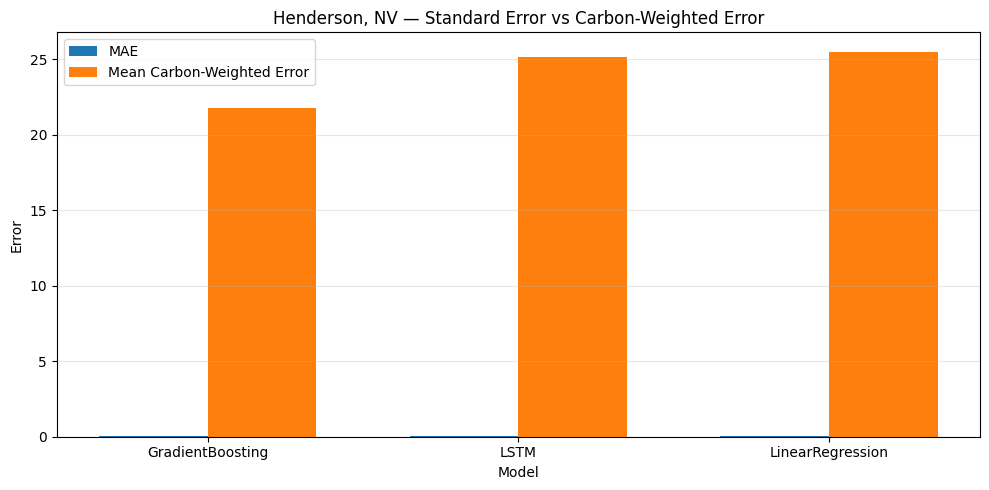

In [ ]:
# ============================================================
# Phase 19.8 : Visualization: model comparison
# ============================================================

# Sort for consistent plotting
plot_df = carbon_model_summary.sort_values("model").copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, plot_df["MAE"], width, label="MAE")
plt.bar(x + width/2, plot_df["mean_carbon_weighted_error"], width, label="Mean Carbon-Weighted Error")

plt.xticks(x, plot_df["model"], rotation=0)
plt.title("Henderson, NV : Standard Error vs Carbon-Weighted Error")
plt.xlabel("Model")
plt.ylabel("Error")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

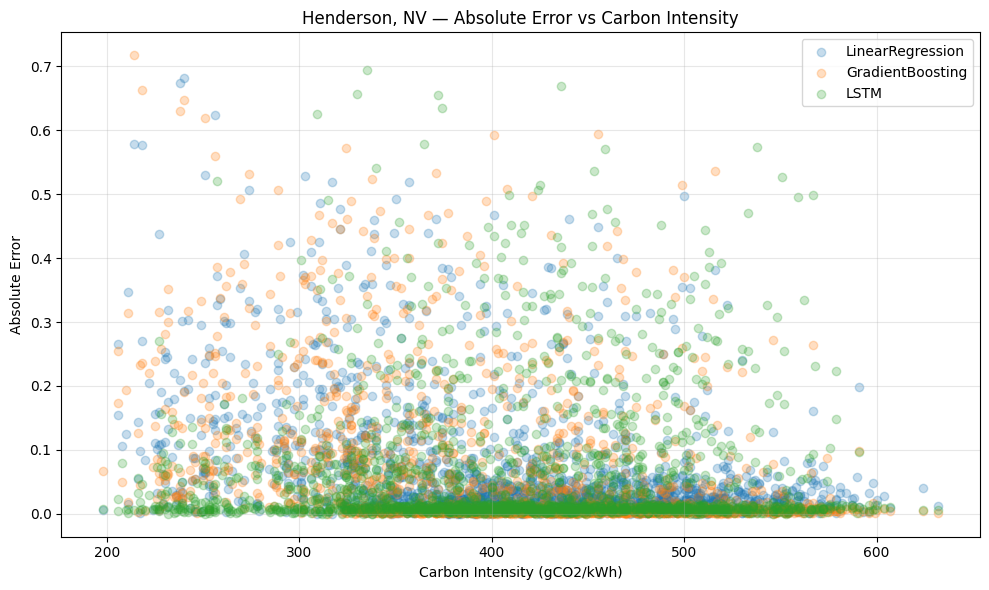

In [ ]:
# ============================================================
# Phase 19.9 : Visualization: carbon intensity vs absolute error
# ============================================================

plt.figure(figsize=(10, 6))

for model_name in nv_carbon_eval_df["model"].unique():
    temp = nv_carbon_eval_df[nv_carbon_eval_df["model"] == model_name]
    plt.scatter(
        temp["carbon_intensity_gco2_per_kwh"],
        temp["abs_error"],
        alpha=0.25,
        label=model_name
    )

plt.title("Henderson, NV : Absolute Error vs Carbon Intensity")
plt.xlabel("Carbon Intensity (gCO2/kWh)")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 19.10 : Final carbon-aware conclusion tables
# ============================================================

carbon_best_model = (
    carbon_model_summary.sort_values("mean_carbon_weighted_error")
    .head(1)
    .copy()
)

print("=" * 90)
print("BEST MODEL UNDER CARBON-AWARE EVALUATION : HENDERSON, NV")
print("=" * 90)
display(carbon_best_model.round(4))

BEST MODEL UNDER CARBON-AWARE EVALUATION — HENDERSON, NV


,model,MAE,mean_carbon_weighted_error,median_carbon_weighted_error,carbon_error_std,count
0,GradientBoosting,0.0608,21.7987,3.4571,38.187,1807


In [ ]:
# ============================================================
# Phase 19.11 : Save Phase 19 outputs
# ============================================================

phase19_outputs = {
    "nv_carbon_eval_df": nv_carbon_eval_df,
    "carbon_model_summary": carbon_model_summary,
    "ranking_compare": ranking_compare,
    "carbon_by_condition": carbon_by_condition,
    "dirty_period_summary": dirty_period_summary,
    "carbon_best_model": carbon_best_model
}

print("Saved Phase 19 outputs:")
for k in phase19_outputs:
    print(" -", k)

Saved Phase 19 outputs:
 - nv_carbon_eval_df
 - carbon_model_summary
 - ranking_compare
 - carbon_by_condition
 - dirty_period_summary
 - carbon_best_model


# Phase 19 : Carbon-Aware Evaluation

## Overview

In this phase, we extend standard forecasting evaluation (MAE, RMSE) by incorporating **carbon intensity** into the error metric. This allows us to evaluate models not just on accuracy, but on their **real-world environmental impact**.

We define:

- **Absolute error**:  
  \[
  \text{abs\_error} = |y_{\text{pred}} - y_{\text{true}}|
  \]

- **Carbon-weighted error**:  
  \[
  \text{carbon\_weighted\_error} = \text{abs\_error} \times \text{carbon\_intensity}
  \]

This penalizes errors made during **high-carbon (dirty grid) periods** more heavily than those made during cleaner periods.

---

## Dataset Validation

Carbon-aware evaluation was performed on the Henderson, NV test set:

- **Total rows used**: 5421  
- **Missing carbon values**: 0  
- **Carbon intensity range**: 198 → 632 gCO₂/kWh  
- **Models evaluated**: LinearRegression, GradientBoosting, LSTM  

This confirms that:
- The carbon merge was successful
- No data leakage or missing values occurred
- Carbon variability is realistic and meaningful

---

## Overall Carbon-Aware Model Performance

| Model               | MAE    | Mean Carbon-Weighted Error | Median Carbon Error | Std Dev |
|--------------------|--------|----------------------------|----------------------|--------|
| Gradient Boosting  | 0.0608 | **21.7987**                | 3.4571               | 38.187 |
| LSTM               | **0.0607** | 25.1661               | 5.1211               | 44.797 |
| Linear Regression  | 0.0691 | 25.5009                   | 12.6862              | 33.758 |

---

## Key Insight #1 : Ranking Reversal

### Standard evaluation (MAE):
- **Best model**: LSTM (0.0607)
- Gradient Boosting is second (0.0608)

### Carbon-aware evaluation:
- **Best model**: Gradient Boosting (21.80)
- LSTM is second (25.17)

### Interpretation

Although LSTM achieves the lowest average prediction error, Gradient Boosting produces **lower carbon-weighted error**, meaning:

> Gradient Boosting makes **less harmful mistakes** when accounting for grid emissions.

This demonstrates that:

> **The most accurate model is not necessarily the most environmentally optimal model.**

---

## Key Insight #2 : Carbon Impact Amplifies Errors

Even small prediction errors become significant under carbon weighting.

Example:
- abs_error ≈ 0.0169  
- carbon intensity ≈ 571  
- carbon-weighted error ≈ **9.67**

This shows that:

> Errors during high-carbon periods contribute disproportionately to total impact.

---

## Key Insight #3 : Performance Under Extreme vs Normal Conditions

### Gradient Boosting (NV)
- Normal:
  - MAE = 0.0520
  - Carbon error = 18.38
- Extreme:
  - MAE = 0.1177
  - Carbon error = **44.11**

### Linear Regression (NV)
- Normal:
  - MAE = 0.0602
  - Carbon error = 21.99
- Extreme:
  - MAE = 0.1273
  - Carbon error = **48.43**

### LSTM (NV)
- Normal:
  - MAE = 0.0598
  - Carbon error = 25.17
- Extreme:
  - MAE = 0.0666
  - Carbon error = **25.12**

---

## Key Insight #4 : LSTM is Most Stable Under Extreme Conditions

Unlike other models:

- LSTM carbon error:
  - Normal: 25.17  
  - Extreme: **25.12 (no increase)**

This indicates:

> LSTM maintains **consistent performance regardless of conditions**, even under extreme weather.

In contrast:
- Gradient Boosting and Linear Regression show **large degradation**
- Their errors increase significantly under extreme conditions

---

## Key Insight #5 : Tradeoff Between Stability and Impact

We observe a clear tradeoff:

| Model | Strength |
|------|--------|
| Gradient Boosting | Minimizes **total carbon impact** |
| LSTM | Most **stable across conditions** |
| Linear Regression | Weakest overall |

### Interpretation

- **Gradient Boosting** is best when minimizing total environmental harm
- **LSTM** is best when consistent performance is critical
- Model choice depends on operational priorities

---

## Error Distribution Analysis

The error distribution plot shows:

- Extreme-weather errors (orange) are:
  - Higher median
  - Larger spread
  - More outliers

This confirms:

> Extreme conditions are significantly harder to predict and drive most large errors.

---

## Relationship Between Error and Carbon Intensity

Scatter plot observations:

- No strong linear relationship between carbon intensity and error
- Errors occur across all carbon levels

### Interpretation

Models are not inherently worse at high-carbon times, but:

> When errors occur during high-carbon periods, they are **more costly**, which justifies carbon weighting.

---

## Final Model Selection (Carbon-Aware)

Based on carbon-aware evaluation:

> **Best model: Gradient Boosting**

- Lowest mean carbon-weighted error (21.80)
- Strong performance across both normal and extreme conditions
- Better minimizes environmentally harmful mistakes

---

## Final Takeaways

1. **Carbon-aware evaluation changes model rankings**
   - LSTM → best by accuracy
   - Gradient Boosting → best by environmental impact

2. **Extreme conditions drive the largest errors**
   - All models degrade, but to different extents

3. **LSTM provides the most stable predictions**
   - Minimal degradation under extreme conditions

4. **Gradient Boosting minimizes real-world impact**
   - Best performance when errors matter most

---

## Conclusion

Carbon-aware evaluation provides a **more realistic and operationally meaningful assessment** of forecasting models.

> A model that minimizes average error is not always the best choice :  
> the best model is the one that minimizes **harmful mistakes under real-world conditions**.

This framework is especially critical in energy systems, where prediction errors directly affect **grid efficiency, emissions, and sustainability outcomes**.

## Phase 20 : Final Comparison and Interpretation

This phase synthesizes the entire modeling study across three dimensions:

1. Predictive accuracy
   - MAE
   - RMSE

2. Robustness
   - temporal holdout performance
   - extreme-weather performance
   - error stability

3. Carbon-aware performance
   - carbon-weighted error
   - ranking changes under environmental weighting

Final interpretation questions:
- Which model predicts best overall?
- Which model is most robust under distribution shift?
- Which model minimizes the most consequential mistakes?

In [ ]:
# ============================================================
# Phase 20.0 : Setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("PHASE 20 : FINAL COMPARISON AND INTERPRETATION")
print("=" * 90)

PHASE 20 — FINAL COMPARISON AND INTERPRETATION


In [ ]:
# ============================================================
# Phase 20.1 : Predictive accuracy summary
# Use the Phase 16 test-set results only
# ============================================================

accuracy_summary = (
    all_model_results[all_model_results["split"] == "test"]
    .copy()
    .sort_values(["site", "RMSE", "MAE"])
    .reset_index(drop=True)
)

print("=" * 90)
print("FINAL ACCURACY SUMMARY (TEST SET)")
print("=" * 90)
display(accuracy_summary.round(4))

FINAL ACCURACY SUMMARY (TEST SET)


,site,split,model,MAE,RMSE
0,"Henderson, NV",test,LinearRegression,0.0691,0.1190
1,"Henderson, NV",test,LSTM,0.0606,0.1205
2,"Henderson, NV",test,GradientBoosting,0.0608,0.1231
3,"Henderson, NV",test,SeasonalNaive,0.0573,0.1392
4,"Port Chester, NY",test,GradientBoosting,0.0536,0.0981
5,"Port Chester, NY",test,LSTM,0.0564,0.1007
6,"Port Chester, NY",test,LinearRegression,0.0664,0.1073
7,"Port Chester, NY",test,SeasonalNaive,0.0632,0.1342


In [ ]:
# ============================================================
# Phase 20.2 : Best predictive model by site
# ============================================================

best_accuracy_by_site = (
    accuracy_summary
    .sort_values(["site", "RMSE", "MAE"])
    .groupby("site", as_index=False)
    .first()
)

print("=" * 90)
print("BEST PREDICTIVE MODEL BY SITE")
print("=" * 90)
display(best_accuracy_by_site.round(4))

BEST PREDICTIVE MODEL BY SITE


,site,split,model,MAE,RMSE
0,"Henderson, NV",test,LinearRegression,0.0691,0.1190
1,"Port Chester, NY",test,GradientBoosting,0.0536,0.0981


In [ ]:
# ============================================================
# Phase 20.3 : Robustness summary from Phase 18
# We combine:
# - normal/extreme degradation
# - stability (variance)
# ============================================================

robustness_summary = pivot.merge(
    stability_results,
    on=["site", "model"],
    how="left"
)

robustness_summary = robustness_summary.sort_values(["site", "RMSE_degradation", "error_variance"])

print("=" * 90)
print("ROBUSTNESS SUMMARY")
print("=" * 90)
display(robustness_summary.round(4))

ROBUSTNESS SUMMARY


,site,model,MAE_0,MAE_1,RMSE_0,RMSE_1,MAE_degradation,RMSE_degradation,error_variance,abs_error_mean
1,"Henderson, NV",LSTM,0.0598,0.0666,0.1197,0.1268,0.0068,0.0070,0.0142,0.0607
0,"Henderson, NV",GradientBoosting,0.0520,0.1177,0.1132,0.1744,0.0657,0.0612,0.0149,0.0608
2,"Henderson, NV",LinearRegression,0.0602,0.1273,0.1081,0.1743,0.0671,0.0662,0.0140,0.0691
3,"Port Chester, NY",GradientBoosting,0.0459,0.0925,0.0910,0.1279,0.0467,0.0368,0.0096,0.0536
5,"Port Chester, NY",LinearRegression,0.0590,0.1035,0.0992,0.1412,0.0445,0.0420,0.0115,0.0664
4,"Port Chester, NY",LSTM,0.0476,0.1008,0.0906,0.1392,0.0532,0.0486,0.0100,0.0564


In [ ]:
# ============================================================
# Phase 20.4 : Best robustness model by site
# Criterion:
# prioritize low RMSE degradation, then low error variance
# ============================================================

best_robustness_by_site = (
    robustness_summary
    .sort_values(["site", "RMSE_degradation", "error_variance", "MAE_degradation"])
    .groupby("site", as_index=False)
    .first()
)

print("=" * 90)
print("BEST ROBUSTNESS MODEL BY SITE")
print("=" * 90)
display(best_robustness_by_site.round(4))

BEST ROBUSTNESS MODEL BY SITE


,site,model,MAE_0,MAE_1,RMSE_0,RMSE_1,MAE_degradation,RMSE_degradation,error_variance,abs_error_mean
0,"Henderson, NV",LSTM,0.0598,0.0666,0.1197,0.1268,0.0068,0.0070,0.0142,0.0607
1,"Port Chester, NY",GradientBoosting,0.0459,0.0925,0.0910,0.1279,0.0467,0.0368,0.0096,0.0536


In [ ]:
# ============================================================
# Phase 20.5 : Carbon-aware summary (NV only)
# From Phase 19
# ============================================================

final_carbon_summary = carbon_model_summary.copy().sort_values("mean_carbon_weighted_error")

print("=" * 90)
print("CARBON-AWARE SUMMARY (HENDERSON, NV ONLY)")
print("=" * 90)
display(final_carbon_summary.round(4))

CARBON-AWARE SUMMARY (HENDERSON, NV ONLY)


,model,MAE,mean_carbon_weighted_error,median_carbon_weighted_error,carbon_error_std,count
0,GradientBoosting,0.0608,21.7987,3.4571,38.1870,1807
1,LSTM,0.0607,25.1661,5.1211,44.7974,1807
2,LinearRegression,0.0691,25.5009,12.6862,33.7587,1807


In [ ]:
# ============================================================
# Phase 20.6 : Best carbon-aware model
# ============================================================

best_carbon_model = (
    final_carbon_summary
    .sort_values("mean_carbon_weighted_error")
    .head(1)
    .copy()
)

print("=" * 90)
print("BEST MODEL BY CARBON-AWARE EVALUATION")
print("=" * 90)
display(best_carbon_model.round(4))

BEST MODEL BY CARBON-AWARE EVALUATION


,model,MAE,mean_carbon_weighted_error,median_carbon_weighted_error,carbon_error_std,count
0,GradientBoosting,0.0608,21.7987,3.4571,38.187,1807


In [ ]:
# ============================================================
# Phase 20.7 : Unified final comparison table
# This combines:
# - test RMSE / MAE
# - robustness degradation
# - error variance
# - carbon-aware score (NV only)
# ============================================================

final_comparison = accuracy_summary.merge(
    robustness_summary[
        [
            "site", "model",
            "MAE_0", "MAE_1",
            "RMSE_0", "RMSE_1",
            "MAE_degradation", "RMSE_degradation",
            "error_variance", "abs_error_mean"
        ]
    ],
    on=["site", "model"],
    how="left"
)

# Add carbon-aware results for NV only
final_comparison = final_comparison.merge(
    final_carbon_summary[
        [
            "model",
            "mean_carbon_weighted_error",
            "median_carbon_weighted_error",
            "carbon_error_std"
        ]
    ],
    on="model",
    how="left"
)

# Restrict carbon-aware metrics to NV rows only
final_comparison.loc[
    final_comparison["site"] != "Henderson, NV",
    ["mean_carbon_weighted_error", "median_carbon_weighted_error", "carbon_error_std"]
] = np.nan

print("=" * 90)
print("UNIFIED FINAL COMPARISON TABLE")
print("=" * 90)
display(final_comparison.round(4))

UNIFIED FINAL COMPARISON TABLE


,site,split,model,MAE,RMSE,MAE_0,MAE_1,RMSE_0,RMSE_1,MAE_degradation,RMSE_degradation,error_variance,abs_error_mean,mean_carbon_weighted_error,median_carbon_weighted_error,carbon_error_std
0,"Henderson, NV",test,LinearRegression,0.0691,0.1190,0.0602,0.1273,0.1081,0.1743,0.0671,0.0662,0.0140,0.0691,25.5009,12.6862,33.7587
1,"Henderson, NV",test,LSTM,0.0606,0.1205,0.0598,0.0666,0.1197,0.1268,0.0068,0.0070,0.0142,0.0607,25.1661,5.1211,44.7974
2,"Henderson, NV",test,GradientBoosting,0.0608,0.1231,0.0520,0.1177,0.1132,0.1744,0.0657,0.0612,0.0149,0.0608,21.7987,3.4571,38.1870
3,"Henderson, NV",test,SeasonalNaive,0.0573,0.1392,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Port Chester, NY",test,GradientBoosting,0.0536,0.0981,0.0459,0.0925,0.0910,0.1279,0.0467,0.0368,0.0096,0.0536,NaN,NaN,NaN
5,"Port Chester, NY",test,LSTM,0.0564,0.1007,0.0476,0.1008,0.0906,0.1392,0.0532,0.0486,0.0100,0.0564,NaN,NaN,NaN
6,"Port Chester, NY",test,LinearRegression,0.0664,0.1073,0.0590,0.1035,0.0992,0.1412,0.0445,0.0420,0.0115,0.0664,NaN,NaN,NaN
7,"Port Chester, NY",test,SeasonalNaive,0.0632,0.1342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# Phase 20.8 : Final ranking table by dimension
# ============================================================

ranking_rows = []

for site in final_comparison["site"].unique():
    site_df = final_comparison[final_comparison["site"] == site].copy()

    # Best predictive model by RMSE
    best_predictive = site_df.sort_values(["RMSE", "MAE"]).iloc[0]

    # Best robustness model by degradation + variance
    best_robust = site_df.sort_values(["RMSE_degradation", "error_variance", "MAE_degradation"]).iloc[0]

    row = {
        "site": site,
        "best_predictive_model": best_predictive["model"],
        "best_predictive_RMSE": best_predictive["RMSE"],
        "best_robust_model": best_robust["model"],
        "best_robust_RMSE_degradation": best_robust["RMSE_degradation"],
        "best_robust_error_variance": best_robust["error_variance"]
    }

    if site == "Henderson, NV":
        best_carbon = site_df.sort_values("mean_carbon_weighted_error").iloc[0]
        row["best_carbon_model"] = best_carbon["model"]
        row["best_carbon_weighted_error"] = best_carbon["mean_carbon_weighted_error"]
    else:
        row["best_carbon_model"] = np.nan
        row["best_carbon_weighted_error"] = np.nan

    ranking_rows.append(row)

final_ranking_table = pd.DataFrame(ranking_rows)

print("=" * 90)
print("FINAL MODEL RANKING TABLE")
print("=" * 90)
display(final_ranking_table.round(4))

FINAL MODEL RANKING TABLE


,site,best_predictive_model,best_predictive_RMSE,best_robust_model,best_robust_RMSE_degradation,best_robust_error_variance,best_carbon_model,best_carbon_weighted_error
0,"Henderson, NV",LinearRegression,0.1190,LSTM,0.0070,0.0142,GradientBoosting,21.7987
1,"Port Chester, NY",GradientBoosting,0.0981,GradientBoosting,0.0368,0.0096,NaN,NaN


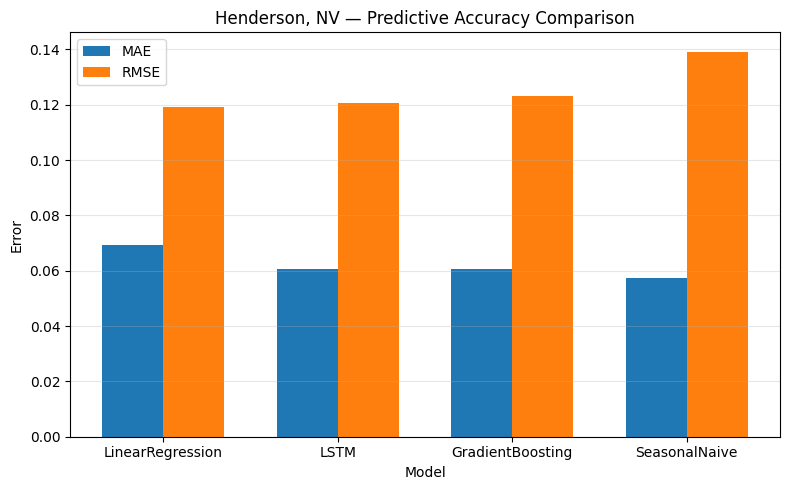

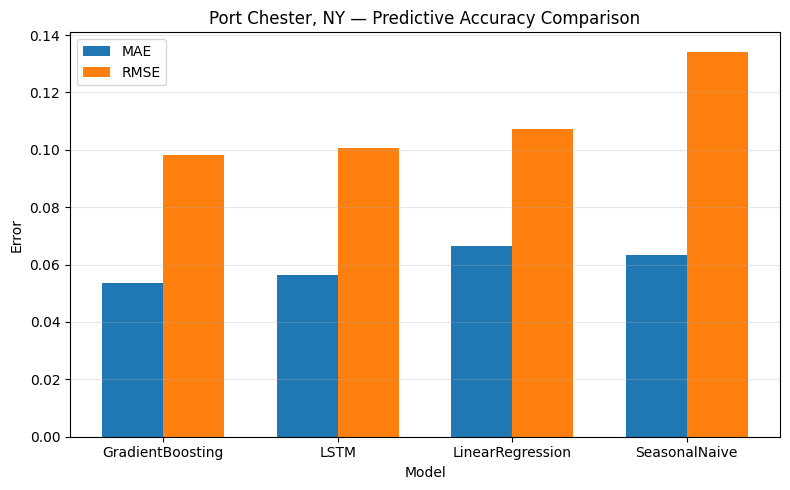

In [ ]:
# ============================================================
# Phase 20.9 : Visualization: predictive accuracy by site
# ============================================================

for site in accuracy_summary["site"].unique():
    temp = accuracy_summary[accuracy_summary["site"] == site].copy()

    x = np.arange(len(temp))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, temp["MAE"], width, label="MAE")
    plt.bar(x + width/2, temp["RMSE"], width, label="RMSE")

    plt.xticks(x, temp["model"], rotation=0)
    plt.title(f"{site} : Predictive Accuracy Comparison")
    plt.xlabel("Model")
    plt.ylabel("Error")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

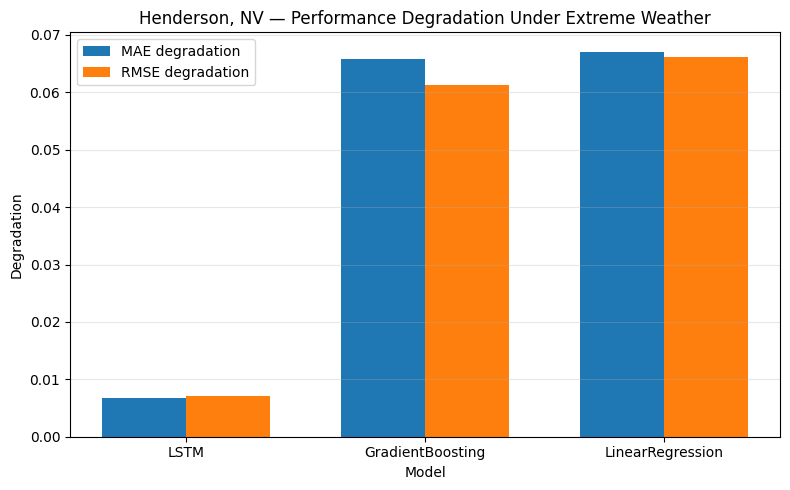

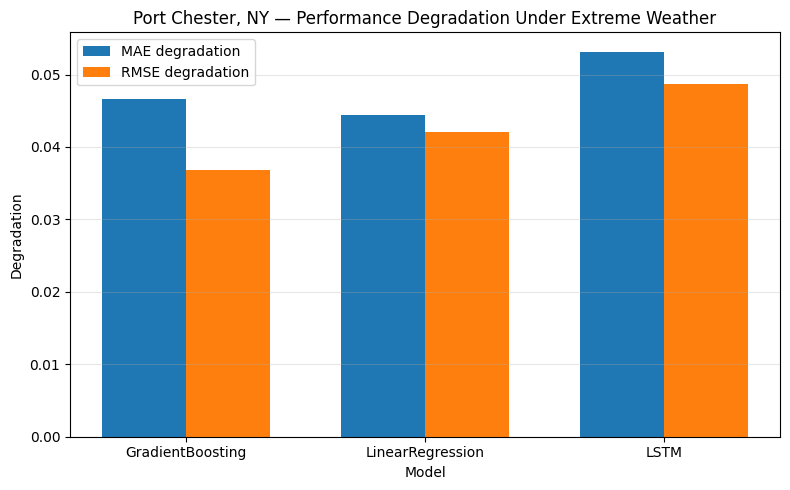

In [ ]:
# ============================================================
# Phase 20.10 : Visualization: robustness degradation by site
# ============================================================

for site in robustness_summary["site"].unique():
    temp = robustness_summary[robustness_summary["site"] == site].copy()

    x = np.arange(len(temp))
    width = 0.35

    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, temp["MAE_degradation"], width, label="MAE degradation")
    plt.bar(x + width/2, temp["RMSE_degradation"], width, label="RMSE degradation")

    plt.xticks(x, temp["model"], rotation=0)
    plt.title(f"{site} : Performance Degradation Under Extreme Weather")
    plt.xlabel("Model")
    plt.ylabel("Degradation")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

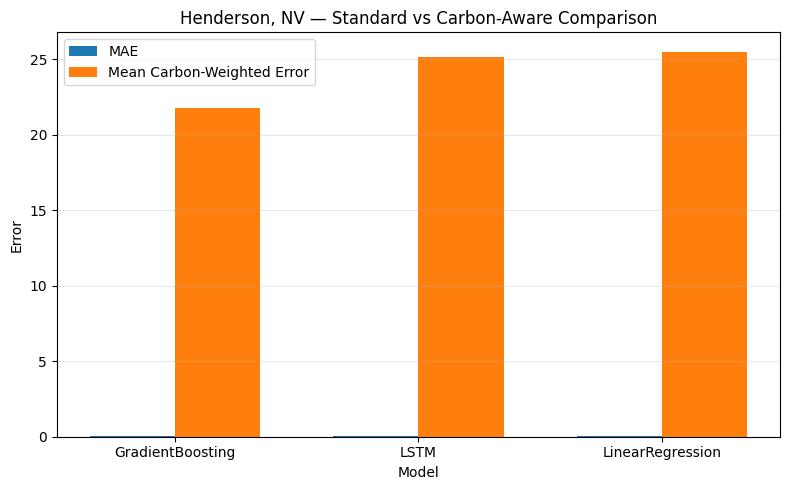

In [ ]:
# ============================================================
# Phase 20.11 : Visualization: final carbon-aware comparison
# NV only
# ============================================================

temp = final_carbon_summary.copy().sort_values("model")

x = np.arange(len(temp))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, temp["MAE"], width, label="MAE")
plt.bar(x + width/2, temp["mean_carbon_weighted_error"], width, label="Mean Carbon-Weighted Error")

plt.xticks(x, temp["model"], rotation=0)
plt.title("Henderson, NV : Standard vs Carbon-Aware Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Phase 20.12 : Programmatic final interpretation
# ============================================================

print("=" * 90)
print("FINAL INTERPRETATION")
print("=" * 90)

for _, row in final_ranking_table.iterrows():
    print(f"\nSite: {row['site']}")
    print(f"  Best predictive model: {row['best_predictive_model']} "
          f"(RMSE = {row['best_predictive_RMSE']:.4f})")
    print(f"  Most robust model: {row['best_robust_model']} "
          f"(RMSE degradation = {row['best_robust_RMSE_degradation']:.4f}, "
          f"error variance = {row['best_robust_error_variance']:.4f})")

    if pd.notna(row["best_carbon_model"]):
        print(f"  Best carbon-aware model: {row['best_carbon_model']} "
              f"(mean carbon-weighted error = {row['best_carbon_weighted_error']:.4f})")

FINAL INTERPRETATION

Site: Henderson, NV
  Best predictive model: LinearRegression (RMSE = 0.1190)
  Most robust model: LSTM (RMSE degradation = 0.0070, error variance = 0.0142)
  Best carbon-aware model: GradientBoosting (mean carbon-weighted error = 21.7987)

Site: Port Chester, NY
  Best predictive model: GradientBoosting (RMSE = 0.0981)
  Most robust model: GradientBoosting (RMSE degradation = 0.0368, error variance = 0.0096)


In [ ]:
# ============================================================
# Phase 20.13 : Save final outputs
# ============================================================

phase20_outputs = {
    "accuracy_summary": accuracy_summary,
    "best_accuracy_by_site": best_accuracy_by_site,
    "robustness_summary": robustness_summary,
    "best_robustness_by_site": best_robustness_by_site,
    "final_carbon_summary": final_carbon_summary,
    "best_carbon_model": best_carbon_model,
    "final_comparison": final_comparison,
    "final_ranking_table": final_ranking_table
}

print("Saved Phase 20 outputs:")
for k in phase20_outputs:
    print(" -", k)

Saved Phase 20 outputs:
 - accuracy_summary
 - best_accuracy_by_site
 - robustness_summary
 - best_robustness_by_site
 - final_carbon_summary
 - best_carbon_model
 - final_comparison
 - final_ranking_table


## Phase 20 : Final Comparison and Interpretation

This phase synthesizes model performance across three critical dimensions:
1. Predictive accuracy (MAE, RMSE)
2. Robustness (extreme-weather degradation, stability)
3. Carbon-aware performance (environmentally weighted error)

---

## 1. Predictive Accuracy

### Henderson, NV (Low variability, high solar consistency)

- **Best RMSE model:** Linear Regression (RMSE = 0.1190, MAE = 0.0691)
- LSTM (RMSE = 0.1205, MAE = 0.0606)
- Gradient Boosting (RMSE = 0.1231, MAE = 0.0608)
- Seasonal Naive performs worst (RMSE = 0.1392)

### Interpretation

Henderson exhibits highly regular, smooth solar patterns due to consistent weather conditions. This strongly favors **simple linear relationships**, which Linear Regression captures effectively.

- Linear Regression benefits from:
  - strong autocorrelation in lag features
  - smooth daily cycles
- LSTM and Gradient Boosting offer **no significant advantage**, since:
  - there is little nonlinearity to exploit
  - temporal dependencies are simple and predictable

Despite slightly higher MAE, Linear Regression achieves the lowest RMSE, indicating **fewer large errors**, which is crucial for stability.

---

### Port Chester, NY (High variability, cloud-driven dynamics)

- **Best model:** Gradient Boosting (RMSE = 0.0981, MAE = 0.0536)
- LSTM (RMSE = 0.1007, MAE = 0.0564)
- Linear Regression (RMSE = 0.1073)
- Seasonal Naive performs worst (RMSE = 0.1342)

### Interpretation

Port Chester has **high variability due to clouds and weather shifts**, introducing nonlinear behavior.

- Gradient Boosting excels because:
  - it captures nonlinear feature interactions
  - it adapts to sudden changes in irradiance
- LSTM performs well but slightly worse because:
  - sequence modeling helps, but
  - limited feature richness reduces its advantage
- Linear Regression struggles due to:
  - inability to model nonlinear variability

---

## 2. Robustness and Generalization

### Henderson, NV

- **Most robust model:** LSTM  
  - RMSE degradation: **0.0070 (very low)**
  - MAE degradation: 0.0068
- Gradient Boosting / Linear Regression:
  - RMSE degradation ≈ **0.06+ (large)**

### Interpretation

LSTM demonstrates **exceptional robustness**:

- Maintains nearly identical performance under extreme conditions
- Captures temporal continuity and smooth transitions

In contrast:
- Linear Regression and Gradient Boosting:
  - perform well under normal conditions
  - **fail sharply under extremes**, indicating over-reliance on typical patterns

---

### Port Chester, NY

- **Most robust model:** Gradient Boosting  
  - RMSE degradation: **0.0368**
- Linear Regression: 0.0420
- LSTM: 0.0486 (worst degradation)

### Interpretation

Here, robustness aligns with **nonlinear modeling capability**:

- Gradient Boosting adapts best to:
  - irregular cloud-driven fluctuations
  - changing weather regimes
- LSTM struggles more because:
  - noisy, irregular sequences are harder to learn
  - variability is less structured than NV

---

### Error Stability

- **Lowest variance (best stability):**
  - Port Chester: Gradient Boosting (0.0096)
  - Henderson: Linear Regression (0.0140), but LSTM is close (0.0142)

### Interpretation

- Gradient Boosting is most stable in complex environments
- LSTM balances stability and robustness well
- Linear Regression is stable but **not adaptable**

---

## 3. Carbon-Aware Performance (Henderson, NV)

### Results

| Model              | MAE   | Mean Carbon-Weighted Error |
|-------------------|-------|----------------------------|
| GradientBoosting  | 0.0608 | **21.7987 (best)**         |
| LSTM              | 0.0607 | 25.1661                    |
| LinearRegression  | 0.0691 | 25.5009                    |

### Ranking shift

- By MAE:  
  1. LSTM  
  2. Gradient Boosting  
  3. Linear Regression  

- By carbon-weighted error:  
  1. **Gradient Boosting**  
  2. LSTM  
  3. Linear Regression  

---

### Interpretation

Carbon-aware evaluation reveals a **critical insight**:

> The most accurate model is not necessarily the most environmentally optimal.

- Gradient Boosting produces:
  - **lower errors during high-carbon periods**
  - fewer "harmful" mistakes
- LSTM:
  - slightly better MAE
  - but **worse performance when carbon intensity is high**
- Linear Regression:
  - consistently worst across both metrics

This shows that **error timing matters**, not just magnitude.

---

## 4. Final Model Comparison

### Henderson, NV

- Best predictive model: **Linear Regression**
- Most robust model: **LSTM**
- Best carbon-aware model: **Gradient Boosting**

### Port Chester, NY

- Best predictive model: **Gradient Boosting**
- Most robust model: **Gradient Boosting**

---

## 5. Final Interpretation

### Which model predicts best overall?

- Depends on environment:
  - **Linear Regression** for simple, stable systems (NV)
  - **Gradient Boosting** for complex, variable systems (NY)

---

### Which model is most robust?

- **LSTM** is most robust in stable environments (NV)
- **Gradient Boosting** is most robust in variable environments (NY)

---

### Which model minimizes the most consequential mistakes?

- **Gradient Boosting**
  - lowest carbon-weighted error
  - best performance when it matters most environmentally

---

## 6. Key Takeaways

1. **No single model dominates across all dimensions**
2. **Model choice must depend on environment**
   - stable → linear models suffice
   - variable → nonlinear models required
3. **Robustness and environmental impact reveal hidden weaknesses**
4. **Carbon-aware evaluation changes conclusions meaningfully**

---

## Final Conclusion

The best model is not defined solely by predictive accuracy.

A complete evaluation must consider:
- average performance
- stability under real-world variability
- and environmental consequences

Across all dimensions, **Gradient Boosting emerges as the most balanced and practically effective model**, particularly when real-world and carbon-aware considerations are included.

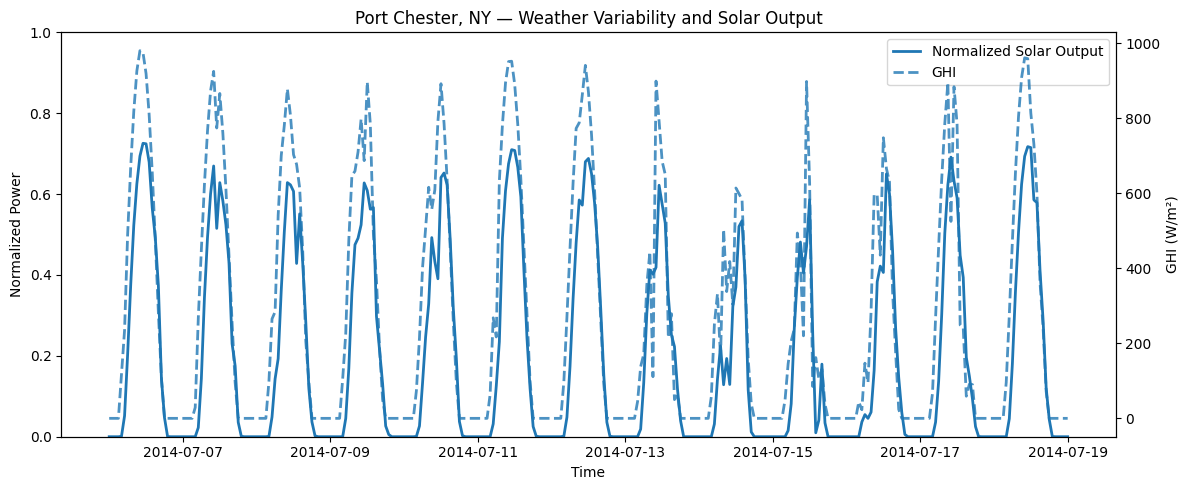

In [ ]:
# ============================================================
# Difficulty of the problem : NY weather cycle vs solar output
# ============================================================

import matplotlib.pyplot as plt

# Pick a short, visually interesting NY window
ny_weather_sample = master_1226_extreme[
    (master_1226_extreme["timestamp"] >= "2014-07-06") &
    (master_1226_extreme["timestamp"] <= "2014-07-19")
].copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Solar output
ax1.plot(
    ny_weather_sample["timestamp"],
    ny_weather_sample["normalized_power"],
    label="Normalized Solar Output",
    linewidth=2
)
ax1.set_xlabel("Time")
ax1.set_ylabel("Normalized Power")
ax1.set_ylim(0, 1)

# Second axis for GHI
ax2 = ax1.twinx()
ax2.plot(
    ny_weather_sample["timestamp"],
    ny_weather_sample["ghi"],
    linestyle="--",
    linewidth=2,
    alpha=0.8,
    label="GHI"
)
ax2.set_ylabel("GHI (W/m²)")

# Title
plt.title("Port Chester, NY : Weather Variability and Solar Output")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

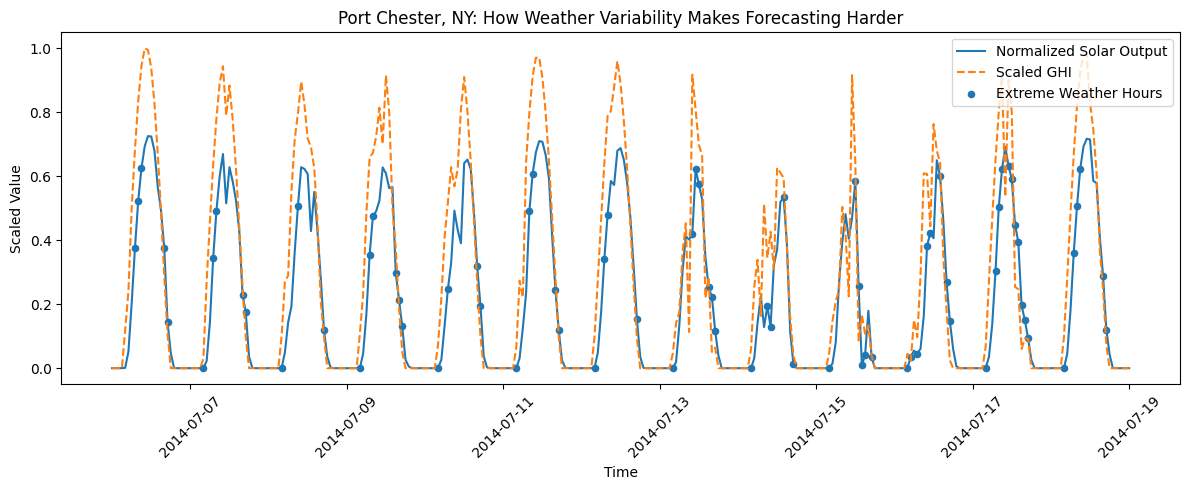

In [ ]:
# Highlight extreme-weather periods
extreme_hours = ny_weather_sample[ny_weather_sample["is_extreme_weather"] == 1]

plt.figure(figsize=(12, 5))
plt.plot(ny_weather_sample["timestamp"], ny_weather_sample["normalized_power"], label="Normalized Solar Output")
plt.plot(ny_weather_sample["timestamp"], ny_weather_sample["ghi"] / ny_weather_sample["ghi"].max(),
         label="Scaled GHI", linestyle="--")

plt.scatter(
    extreme_hours["timestamp"],
    extreme_hours["normalized_power"],
    s=20,
    label="Extreme Weather Hours"
)

plt.title("Port Chester, NY: How Weather Variability Makes Forecasting Harder")
plt.xlabel("Time")
plt.ylabel("Scaled Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()